# Temporal autocorrelation of all six targets

**Purpose.** Quantify how quickly each target changes over time, independently
of any predictive model. Requested by Prof. Lüdtke (meeting 2026-07-29) as a
model-free measure of how hard the forecasting task is for each target.

**Targets (6).** Phase 1: Temperature, Salinity, Chlorophyll a.
Phase 3: Caffeine, Metoprolol, Atrazine (`zero` censoring scheme).

**Design.**
- Autocorrelation computed *within each site*, then aggregated across sites.
- Lags defined in sampling steps (k = 1, 2, 3), matching the forecasting horizons.
- Both Pearson and Spearman reported; Spearman is the primary statistic for the
  sparse censored targets.

**Outputs.** Per-target time-series plots by site, an autocorrelation table,
and a scatter of lag-1 autocorrelation against best forecasting R².

**Note.** This notebook is standalone and rebuilds all inputs from disk. It does
not depend on the state of the Phase 1 or Phase 3 notebooks.

In [2]:
# ── CELL 1a: locate the data files — discovery only, reads nothing ──
from pathlib import Path

PROJ = Path.home() / 'tabpfn_project'
print(f'PROJ = {PROJ}   exists={PROJ.exists()}\n')

# ---- 1. top-level layout of the project ----
print('=== top level of tabpfn_project ===')
for p in sorted(PROJ.iterdir()):
    kind = 'DIR ' if p.is_dir() else 'file'
    print(f'  {kind} {p.name}')

# ---- 2. every tabular file anywhere in the project (depth-limited) ----
print('\n=== all .csv / .tsv / .parquet under the project ===')
pats = ('*.csv', '*.tsv', '*.parquet')
found = sorted({f for pat in pats for f in PROJ.rglob(pat)
                if '.ipynb_checkpoints' not in str(f)})
if not found:
    print('  (none found — the data may live outside the project folder)')
for f in found:
    rel = f.relative_to(PROJ)
    mb  = f.stat().st_size / 1e6
    print(f'  {mb:>8.2f} MB   {rel}')

# ---- 3. anything whose name hints at metadata ----
print('\n=== filename matches for meta / clean / hplc / trace ===')
for key in ['meta', 'clean', 'hplc', 'trace', '16s', '18s', 'asv', 'otu']:
    hits = [f.relative_to(PROJ) for f in found if key in f.name.lower()]
    print(f'  {key:<7s} -> {hits if hits else "—"}')

PROJ = /mnt/data/home/tv2414/tabpfn_project   exists=True

=== top level of tabpfn_project ===
  DIR  .git
  file .gitignore
  file README.md
  file _all_nb.py
  file _dumpall.py
  file conda_v26_freeze.txt
  DIR  data
  file env_v26_freeze.txt
  file environment.yml
  DIR  notebooks
  DIR  old_scripts
  DIR  results
  DIR  resultscd
  DIR  src

=== all .csv / .tsv / .parquet under the project ===
      0.27 MB   data/collected_algae_data.csv
      0.26 MB   data/collected_bacteria_data.csv
      0.32 MB   data/combined_meta_data.csv
      0.23 MB   data/hplc_submission.csv
      4.49 MB   data/otus_16s_filtered.csv
    239.37 MB   data/otus_16s_full.csv
      3.71 MB   data/otus_18s_filtered.csv
    113.77 MB   data/otus_18s_full.csv
      0.33 MB   data/processed/meta_clean.csv
      0.31 MB   data/processed/meta_master.csv
      4.31 MB   data/processed/otu_16s_clean.csv
      4.46 MB   data/processed/otu_16s_master.csv
      3.57 MB   data/processed/otu_18s_clean.csv
      3.68 MB 

In [3]:
# ── CELL 1b: inspect meta_clean.csv and the raw HPLC file ──
#   Determines (a) the site/date column names, (b) whether the Phase-3
#   targets already live in meta_clean, (c) how the HPLC file is structured
#   in case the censored targets must be rebuilt.
from pathlib import Path
import numpy as np
import pandas as pd

PROJ    = Path.home() / 'tabpfn_project'
DATA    = PROJ / 'data'
PROC    = DATA / 'processed'
RESULTS = PROJ / 'results'

# ================= PART A: meta_clean =================
meta = pd.read_csv(PROC / 'meta_clean.csv')
print(f'=== meta_clean.csv · shape = {meta.shape} ===\n')
print('--- all columns ---')
print('  ' + '\n  '.join(f'{i:>3d}. {c}' for i, c in enumerate(meta.columns)))

KEYS = ['temp', 'salin', 'chl', 'caffein', 'metoprol', 'atrazin',
        'date', 'time', 'site', 'station', 'location', 'sample']
print('\n--- loose name matches ---')
for k in KEYS:
    hits = [c for c in meta.columns if k in c.lower()]
    print(f'  {k:<10s} -> {hits if hits else "—"}')

num = meta.select_dtypes(include=[np.number]).columns
tgt = [c for c in meta.columns
       if any(k in c.lower() for k in
              ['temp', 'salin', 'chl', 'caffein', 'metoprol', 'atrazin'])]
if tgt:
    print('\n--- target-like columns ---')
    print(pd.DataFrame({
        'dtype':    [meta[c].dtype for c in tgt],
        'n_notna':  [meta[c].notna().sum() for c in tgt],
        'pct_miss': [100 * meta[c].isna().mean() for c in tgt],
        'n_zero':   [(meta[c] == 0).sum() if c in num else np.nan for c in tgt],
        'min':      [meta[c].min() if c in num else np.nan for c in tgt],
        'max':      [meta[c].max() if c in num else np.nan for c in tgt],
    }, index=tgt).round(2).to_string())

print('\n--- first 3 rows ---')
print(meta.head(3).to_string())

# ================= PART B: raw HPLC =================
hplc = pd.read_csv(DATA / 'hplc_submission.csv')
print(f'\n\n=== hplc_submission.csv · shape = {hplc.shape} ===\n')
print('--- first 12 columns ---')
print('  ' + '\n  '.join(f'{i:>3d}. {c}' for i, c in enumerate(hplc.columns[:12])))
print(f'  ... ({len(hplc.columns)} columns total)')

print('\n--- columns matching our three compounds ---')
for k in ['caffein', 'metoprol', 'atrazin']:
    print(f'  {k:<10s} -> {[c for c in hplc.columns if k in c.lower()]}')

print('\n--- first 3 rows (first 8 columns) ---')
print(hplc.iloc[:3, :8].to_string())

=== meta_clean.csv · shape = (1538, 25) ===

--- all columns ---
    0. Unnamed: 0
    1. location_id
    2. day_id
    3. cw_id
    4. year_id
    5. location_name
    6. rough_lat_long
    7. date
    8. PO4
    9. NOx
   10. NH4
   11. NO2
   12. NO3
   13. temperature
   14. salinity
   15. Chl_a
   16. Phaeo
   17. Chl_a_conc
   18. f0
   19. fa
   20. volume
   21. time
   22. month
   23. year_full
   24. Chl_a_log1p

--- loose name matches ---
  temp       -> ['temperature']
  salin      -> ['salinity']
  chl        -> ['Chl_a', 'Chl_a_conc', 'Chl_a_log1p']
  caffein    -> —
  metoprol   -> —
  atrazin    -> —
  date       -> ['date']
  time       -> ['time']
  site       -> —
  station    -> —
  location   -> ['location_id', 'location_name']
  sample     -> —

--- target-like columns ---
               dtype  n_notna  pct_miss  n_zero   min     max
temperature  float64     1223     20.48       0  0.30   24.46
salinity     float64     1217     20.87       0 -0.01   23.80
Chl_a 

In [5]:
# ── CELL 1c: HPLC value structure, join key integrity, sampling cadence ──
#   Still discovery only. Nothing is rebuilt or saved yet.
from pathlib import Path
import numpy as np
import pandas as pd

PROJ = Path.home() / 'tabpfn_project'
DATA = PROJ / 'data'
PROC = DATA / 'processed'

meta = pd.read_csv(PROC / 'meta_clean.csv').rename(columns={'Unnamed: 0': 'sample_id'})
hplc = pd.read_csv(DATA / 'hplc_submission.csv').rename(columns={'Unnamed: 0': 'sample_id'})

# ================= A. join key integrity =================
print('=== A. join key ===')
print(f'  meta: n={len(meta):<5d} unique_ids={meta.sample_id.nunique():<5d} '
      f'is_unique={meta.sample_id.is_unique}')
print(f'  hplc: n={len(hplc):<5d} unique_ids={hplc.sample_id.nunique():<5d} '
      f'is_unique={hplc.sample_id.is_unique}')
m_ids, h_ids = set(meta.sample_id), set(hplc.sample_id)
print(f'  matched (meta ∩ hplc) = {len(m_ids & h_ids)}')
print(f'  in hplc but NOT in meta = {len(h_ids - m_ids)}  '
      f'{sorted(h_ids - m_ids)[:5]}')

# ================= B. raw value structure =================
GRADIENT = ['Caffeine', 'Metoprolol', 'Atrazine']
print('\n=== B. raw HPLC value structure ===')
for c in GRADIENT:
    s   = hplc[c].astype(str).str.strip()
    num = pd.to_numeric(s, errors='coerce')
    n   = len(s)
    print(f'\n  --- {c} ---')
    print(f'    n={n}  numeric={num.notna().sum()} ({100*num.notna().mean():.1f}%)  '
          f'starts_with_"<"={s.str.startswith("<").sum()}  '
          f'contains_"#"={s.str.contains("#", regex=False).sum()}  '
          f'literal_nan={s.isin(["nan", "", "NaN"]).sum()}')
    toks = sorted(
    set(
        s[num.isna()]
        .dropna()
        .astype(str)
    )
)
    print(f'    distinct non-numeric tokens ({len(toks)}): {toks[:8]}')

# ================= C. site structure =================
print('\n=== C. sites ===')
vc = meta.location_name.value_counts()
print(f'  n_sites = {len(vc)}')
print(vc.to_string())

# ================= D. sampling cadence within site =================
print('\n=== D. sampling cadence ===')
meta['date'] = pd.to_datetime(meta['date'])
print(f"  date range: {meta['date'].min().date()} -> {meta['date'].max().date()}")
print(f"  day_id values: {meta.day_id.value_counts().to_dict()}")
print(f"  weekday x day_id crosstab:")
print(pd.crosstab(meta['date'].dt.day_name(), meta['day_id']).to_string())

gaps = (meta.sort_values(['location_name', 'date'])
            .groupby('location_name')['date'].diff().dt.days.dropna())
print(f'\n  within-site consecutive gaps (days):')
print(f'    median={gaps.median():.1f}  mean={gaps.mean():.2f}  '
      f'min={gaps.min():.0f}  max={gaps.max():.0f}')
print(f'    distribution: {gaps.value_counts().sort_index().head(10).to_dict()}')

=== A. join key ===
  meta: n=1538  unique_ids=1538  is_unique=True
  hplc: n=1433  unique_ids=1433  is_unique=True
  matched (meta ∩ hplc) = 1424
  in hplc but NOT in meta = 9  ['s02M3222', 's05M1423', 's06M4422', 's08T2122', 's11M2522']

=== B. raw HPLC value structure ===

  --- Caffeine ---
    n=1433  numeric=1300 (90.7%)  starts_with_"<"=0  contains_"#"=0  literal_nan=0
    distinct non-numeric tokens (0): []

  --- Metoprolol ---
    n=1433  numeric=391 (27.3%)  starts_with_"<"=679  contains_"#"=232  literal_nan=0
    distinct non-numeric tokens (2): ['#17.5', '<11.7']

  --- Atrazine ---
    n=1433  numeric=57 (4.0%)  starts_with_"<"=884  contains_"#"=357  literal_nan=0
    distinct non-numeric tokens (2): ['#2.5', '<1.6']

=== C. sites ===
  n_sites = 14
location_name
Stadthafen Rostock         111
Schwimmhalle Gehlsdorf     111
Neptun-Werft               111
Mittelmole Warnemuende     111
Boergerende Strand         110
Steilkueste Nienhagen      110
Diedrichshagen            

In [6]:
# ── CELL 2: build the six-target analysis frame ──
#   Reconstructs the Phase-3 targets under the locked `zero` censoring scheme,
#   merges them with the Phase-1 targets, and verifies the reconstruction
#   against the frozen Phase-3 numbers before anything downstream is computed.
from pathlib import Path
import numpy as np
import pandas as pd

PROJ, DATA = Path.home() / 'tabpfn_project', Path.home() / 'tabpfn_project' / 'data'
PROC = DATA / 'processed'

SITE, DATE = 'location_name', 'date'
PHASE1  = ['temperature', 'salinity', 'Chl_a']
PHASE3  = ['Caffeine', 'Metoprolol', 'Atrazine']
TARGETS = PHASE1 + PHASE3

meta = pd.read_csv(PROC / 'meta_clean.csv').rename(columns={'Unnamed: 0': 'sample_id'})
hplc = pd.read_csv(DATA / 'hplc_submission.csv').rename(columns={'Unnamed: 0': 'sample_id'})
meta[DATE] = pd.to_datetime(meta[DATE])

# ---------- censoring: `zero` scheme (primary analysis, per Dr. Sperlea) ----------
def parse_censored(series, scheme='zero'):
    """Return (values, LOD, LOQ, n_below_lod, n_between). NaN stays NaN."""
    s     = series.astype(str).str.strip()
    out   = pd.to_numeric(s, errors='coerce')          # quantified values only
    below = s.str.startswith('<').fillna(False)        # < LOD
    betw  = s.str.startswith('#').fillna(False)        # LOD <= x < LOQ
    lod   = loq = np.nan
    if below.any():
        u = pd.to_numeric(s[below].str[1:]).unique()
        assert len(u) == 1, f'multiple LOD thresholds: {u}'
        lod = float(u[0])
    if betw.any():
        u = pd.to_numeric(s[betw].str[1:]).unique()
        assert len(u) == 1, f'multiple LOQ thresholds: {u}'
        loq = float(u[0])
    fill = {'zero': 0.0,
            'half_lod':  lod / 2        if lod == lod else 0.0,
            'sqrt2_lod': lod / np.sqrt(2) if lod == lod else 0.0}[scheme]
    out.loc[below | betw] = fill
    return out, lod, loq, int(below.sum()), int(betw.sum())

print('=== reconstructing Phase-3 targets · scheme = zero ===')
hp = hplc[['sample_id']].copy()
audit = []
for c in PHASE3:
    vals, lod, loq, nb, nt = parse_censored(hplc[c], 'zero')
    hp[c] = vals
    n_q = pd.to_numeric(hplc[c].astype(str).str.strip(), errors='coerce').notna().sum()
    audit.append({'compound': c, 'LOD': lod, 'LOQ': loq, 'n_quantified': n_q,
                  'pct_quantified': 100 * n_q / len(hplc),
                  'n_below_LOD': nb, 'n_between': nt,
                  'n_missing': len(hplc) - n_q - nb - nt})
audit = pd.DataFrame(audit)
print(audit.round(2).to_string(index=False))

# ---------- verification against the frozen Phase-3 figures ----------
EXPECTED = {'Caffeine': 90.7, 'Metoprolol': 27.3, 'Atrazine': 4.0}
print('\n--- reconstruction check (must match Phase 3) ---')
ok = True
for _, r in audit.iterrows():
    hit = abs(r.pct_quantified - EXPECTED[r.compound]) < 0.15
    ok &= hit
    print(f"  {r.compound:<11s} got {r.pct_quantified:5.1f}%  "
          f"expected {EXPECTED[r.compound]:5.1f}%   {'PASS' if hit else 'FAIL'}")
print(f'  => reconstruction {"MATCHES Phase 3" if ok else "DIFFERS — STOP"}')

# ---------- merge into one analysis frame ----------
df = meta[['sample_id', SITE, DATE, 'day_id'] + PHASE1].merge(hp, on='sample_id', how='left')
df = df.sort_values([SITE, DATE]).reset_index(drop=True)
print(f'\n=== analysis frame · shape = {df.shape} ===')

cov = pd.DataFrame({
    'n_notna': [df[c].notna().sum() for c in TARGETS],
    'pct_cov': [100 * df[c].notna().mean() for c in TARGETS],
    'n_zero':  [(df[c] == 0).sum() for c in TARGETS],
    'pct_zero':[100 * (df[c] == 0).sum() / df[c].notna().sum() for c in TARGETS],
    'median':  [df[c].median() for c in TARGETS],
}, index=TARGETS)
print(cov.round(2).to_string())

# ---------- how many sites have usable variance per target? ----------
print('\n--- sites with >=30 values AND >=5 distinct values (usable for correlation) ---')
for c in TARGETS:
    g = df.groupby(SITE)[c]
    usable = ((g.count() >= 30) & (g.nunique() >= 5)).sum()
    print(f'  {c:<12s} {usable:2d} / {df[SITE].nunique()} sites')

# ---------- real day-gap behind each positional lag ----------
print('\n--- actual day gap per positional lag k (within site) ---')
rows = []
for k in (1, 2, 3):
    d = df.groupby(SITE)[DATE].diff(k).dt.days.dropna()
    rows.append({'k': k, 'median_days': d.median(), 'mean_days': round(d.mean(), 2),
                 'p05': d.quantile(.05), 'p95': d.quantile(.95),
                 'n_pairs': len(d)})
print(pd.DataFrame(rows).to_string(index=False))

=== reconstructing Phase-3 targets · scheme = zero ===
  compound  LOD  LOQ  n_quantified  pct_quantified  n_below_LOD  n_between  n_missing
  Caffeine  NaN  NaN          1300           90.72            0          0        133
Metoprolol 11.7 17.5           391           27.29          679        232        131
  Atrazine  1.6  2.5            57            3.98          884        357        135

--- reconstruction check (must match Phase 3) ---
  Caffeine    got  90.7%  expected  90.7%   PASS
  Metoprolol  got  27.3%  expected  27.3%   PASS
  Atrazine    got   4.0%  expected   4.0%   PASS
  => reconstruction MATCHES Phase 3

=== analysis frame · shape = (1538, 10) ===
             n_notna  pct_cov  n_zero  pct_zero  median
temperature     1223    79.52       0      0.00    9.70
salinity        1217    79.13       0      0.00   13.30
Chl_a           1437    93.43       1      0.07    1.54
Caffeine        1291    83.94       0      0.00   24.70
Metoprolol      1293    84.07     906     

In [7]:
# ── CELL 3: within-site temporal autocorrelation for all six targets ──
#   Model-free measure of how fast each target changes, at the exact
#   positional lags used by the forecasting design (k = 1, 2, 3).
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

RESULTS = PROJ / 'results'

TOL          = {1: 5, 2: 8, 3: 12}   # max real day-gap allowed per lag k
MIN_PAIRS    = 20                    # per-site minimum to report a correlation
MIN_DISTINCT = 5                     # guard against all-tied (censored) series

per_site = []
for c in TARGETS:
    for k in (1, 2, 3):
        for site, g in df.groupby(SITE, sort=True):
            g = g.sort_values(DATE)
            if len(g) <= k:
                continue
            y   = g[c].to_numpy(dtype=float)
            dt  = g[DATE].reset_index(drop=True)
            y0, y1 = y[:-k], y[k:]
            gap = (dt[k:].reset_index(drop=True) - dt[:-k].reset_index(drop=True)).dt.days.to_numpy()

            m = ~np.isnan(y0) & ~np.isnan(y1) & (gap <= TOL[k])
            a, b = y0[m], y1[m]
            rec = {'target': c, 'k': k, 'site': site, 'n_pairs': int(m.sum()),
                   'n_dropped_gap': int(((gap > TOL[k]) & ~np.isnan(y0) & ~np.isnan(y1)).sum()),
                   'n_distinct': int(min(len(np.unique(a)), len(np.unique(b)))),
                   'pct_zero': 100 * np.mean(a == 0) if len(a) else np.nan,
                   'pearson': np.nan, 'spearman': np.nan, 'usable': False}
            if rec['n_pairs'] >= MIN_PAIRS and rec['n_distinct'] >= MIN_DISTINCT:
                rec['pearson']  = pearsonr(a, b)[0]
                rec['spearman'] = spearmanr(a, b)[0]
                rec['usable']   = True
            per_site.append(rec)

ac = pd.DataFrame(per_site)
ac.to_csv(RESULTS / 'temporal_autocorr_per_site.csv', index=False)

# ---------- aggregate across sites (median = robust to one odd site) ----------
u = ac[ac.usable]
summary = (u.groupby(['target', 'k'])
             .agg(n_sites=('site', 'nunique'),
                  n_pairs=('n_pairs', 'sum'),
                  pearson_med=('pearson', 'median'),
                  pearson_q1=('pearson', lambda s: s.quantile(.25)),
                  pearson_q3=('pearson', lambda s: s.quantile(.75)),
                  spearman_med=('spearman', 'median'),
                  spearman_q1=('spearman', lambda s: s.quantile(.25)),
                  spearman_q3=('spearman', lambda s: s.quantile(.75)))
             .reset_index())
summary['target'] = pd.Categorical(summary.target, categories=TARGETS, ordered=True)
summary = summary.sort_values(['target', 'k'])
summary.to_csv(RESULTS / 'temporal_autocorr_summary.csv', index=False)

print('=== how many sites were usable per target/lag (of 14) ===')
print(ac.groupby(['target', 'k']).usable.sum()
        .unstack().reindex(TARGETS).to_string())

print('\n=== Spearman autocorrelation · median over sites [Q1–Q3] ===')
for c in TARGETS:
    s = summary[summary.target == c]
    if s.empty:
        print(f'  {c:<12s} (no usable sites)'); continue
    line = f'  {c:<12s}'
    for _, r in s.iterrows():
        line += (f'  k={r.k}: {r.spearman_med:+.2f} '
                 f'[{r.spearman_q1:+.2f},{r.spearman_q3:+.2f}] (n={r.n_sites:2d})')
    print(line)

print('\n=== Pearson autocorrelation · median over sites ===')
print(summary.pivot(index='target', columns='k', values='pearson_med')
             .reindex(TARGETS).round(3).to_string())

print('\n=== pairs excluded because the real day-gap exceeded tolerance ===')
print(ac.groupby('k').n_dropped_gap.sum().to_string())

print('\n=== fraction of zeros among lagged pairs (censoring context) ===')
print(u.groupby('target').pct_zero.median().reindex(TARGETS).round(1).to_string())

print(f'\nsaved -> temporal_autocorr_per_site.csv · temporal_autocorr_summary.csv')

=== how many sites were usable per target/lag (of 14) ===
k             1   2   3
target                 
temperature  14  14  14
salinity     14  14  14
Chl_a        14  14  14
Caffeine     14  14  14
Metoprolol    9   9   9
Atrazine      5   5   4

=== Spearman autocorrelation · median over sites [Q1–Q3] ===
  temperature   k=1: +0.96 [+0.95,+0.97] (n=14)  k=2: +0.92 [+0.91,+0.94] (n=14)  k=3: +0.87 [+0.86,+0.89] (n=14)
  salinity      k=1: +0.77 [+0.59,+0.81] (n=14)  k=2: +0.70 [+0.47,+0.80] (n=14)  k=3: +0.64 [+0.35,+0.76] (n=14)
  Chl_a         k=1: +0.39 [+0.22,+0.53] (n=14)  k=2: +0.31 [+0.16,+0.40] (n=14)  k=3: +0.28 [+0.15,+0.37] (n=14)
  Caffeine      k=1: +0.49 [+0.43,+0.62] (n=14)  k=2: +0.44 [+0.35,+0.48] (n=14)  k=3: +0.39 [+0.30,+0.43] (n=14)
  Metoprolol    k=1: +0.43 [+0.27,+0.61] (n= 9)  k=2: +0.46 [+0.04,+0.50] (n= 9)  k=3: +0.44 [+0.27,+0.50] (n= 9)
  Atrazine      k=1: +0.31 [+0.21,+0.34] (n= 5)  k=2: +0.26 [+0.25,+0.35] (n= 5)  k=3: +0.17 [+0.16,+0.25] (n= 4)

===

In [8]:
# ── CELL 4: disambiguate autocorrelation for the censored targets ──
#   Splits the ambiguous Metoprolol/Atrazine autocorrelation into two parts:
#     (a) detection persistence — does the on/off state carry over?
#     (b) concentration persistence — given detection at both ends, does the
#         magnitude carry over?
#   Also recomputes Chl_a on the log1p scale used as the Phase-1 target.
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

CENSORED = ['Metoprolol', 'Atrazine']

# ================= A. detection persistence =================
rows = []
for c in CENSORED:
    for k in (1, 2, 3):
        for site, g in df.groupby(SITE, sort=True):
            g = g.sort_values(DATE)
            y, dt = g[c].to_numpy(float), g[DATE].reset_index(drop=True)
            if len(y) <= k:
                continue
            y0, y1 = y[:-k], y[k:]
            gap = (dt[k:].reset_index(drop=True) - dt[:-k].reset_index(drop=True)).dt.days.to_numpy()
            m = ~np.isnan(y0) & ~np.isnan(y1) & (gap <= TOL[k])
            if m.sum() < MIN_PAIRS:
                continue
            d0, d1 = (y0[m] > 0), (y1[m] > 0)
            if d0.all() or (~d0).all():          # no variation -> phi undefined
                phi = np.nan
            else:
                phi = pearsonr(d0.astype(float), d1.astype(float))[0]
            rows.append({
                'target': c, 'k': k, 'site': site, 'n_pairs': int(m.sum()),
                'base_rate': d0.mean(),
                'p_det_given_det':  d1[d0].mean()  if d0.any()  else np.nan,
                'p_det_given_none': d1[~d0].mean() if (~d0).any() else np.nan,
                'phi': phi,
            })
det = pd.DataFrame(rows)
det['lift'] = det.p_det_given_det - det.p_det_given_none

print('=== A. DETECTION persistence (median over sites) ===')
print('  base = P(detect)   |   P(det|det) vs P(det|none)   |   lift   |   phi')
for c in CENSORED:
    for k in (1, 2, 3):
        s = det[(det.target == c) & (det.k == k)]
        if s.empty:
            print(f'  {c:<11s} k={k}  (insufficient)'); continue
        print(f'  {c:<11s} k={k}  base={s.base_rate.median():.2f}   '
              f'{s.p_det_given_det.median():.2f} vs {s.p_det_given_none.median():.2f}   '
              f'lift={s.lift.median():+.2f}   phi={s.phi.median():+.2f}   '
              f'(n_sites={len(s)})')

# ================= B. concentration persistence | both detected =================
rows = []
for c in CENSORED:
    for k in (1, 2, 3):
        pooled_a, pooled_b = [], []
        for site, g in df.groupby(SITE, sort=True):
            g = g.sort_values(DATE)
            y, dt = g[c].to_numpy(float), g[DATE].reset_index(drop=True)
            if len(y) <= k:
                continue
            y0, y1 = y[:-k], y[k:]
            gap = (dt[k:].reset_index(drop=True) - dt[:-k].reset_index(drop=True)).dt.days.to_numpy()
            m = (~np.isnan(y0) & ~np.isnan(y1) & (gap <= TOL[k]) & (y0 > 0) & (y1 > 0))
            pooled_a.append(y0[m]); pooled_b.append(y1[m])
        a, b = np.concatenate(pooled_a), np.concatenate(pooled_b)
        rows.append({
            'target': c, 'k': k, 'n_pairs_both_detected': len(a),
            'spearman': spearmanr(a, b)[0] if len(a) >= MIN_PAIRS else np.nan,
            'pearson':  pearsonr(a, b)[0]  if len(a) >= MIN_PAIRS else np.nan,
        })
conc = pd.DataFrame(rows)
print('\n=== B. CONCENTRATION persistence, pairs where BOTH ends detected ===')
print('    (pooled across sites — too few per-site pairs to split)')
print(conc.round(3).to_string(index=False))

# ================= C. Chl_a on the Phase-1 log1p scale =================
print('\n=== C. Chl_a: raw vs log1p (Pearson, median over sites) ===')
df['_chl_log1p'] = np.log1p(df['Chl_a'])
rows = []
for col, lab in [('Chl_a', 'raw'), ('_chl_log1p', 'log1p')]:
    for k in (1, 2, 3):
        vals = []
        for site, g in df.groupby(SITE, sort=True):
            g = g.sort_values(DATE)
            y, dt = g[col].to_numpy(float), g[DATE].reset_index(drop=True)
            y0, y1 = y[:-k], y[k:]
            gap = (dt[k:].reset_index(drop=True) - dt[:-k].reset_index(drop=True)).dt.days.to_numpy()
            m = ~np.isnan(y0) & ~np.isnan(y1) & (gap <= TOL[k])
            if m.sum() >= MIN_PAIRS:
                vals.append(pearsonr(y0[m], y1[m])[0])
        rows.append({'scale': lab, 'k': k, 'pearson_med': np.median(vals), 'n_sites': len(vals)})
chl = pd.DataFrame(rows)
print(chl.round(3).to_string(index=False))

det.to_csv(RESULTS / 'temporal_detection_persistence.csv', index=False)
conc.to_csv(RESULTS / 'temporal_concentration_persistence.csv', index=False)
print('\nsaved -> temporal_detection_persistence.csv · temporal_concentration_persistence.csv')

=== A. DETECTION persistence (median over sites) ===
  base = P(detect)   |   P(det|det) vs P(det|none)   |   lift   |   phi
  Metoprolol  k=1  base=0.27   0.71 vs 0.17   lift=+0.26   phi=+0.26   (n_sites=14)
  Metoprolol  k=2  base=0.27   0.65 vs 0.24   lift=+0.15   phi=+0.16   (n_sites=14)
  Metoprolol  k=3  base=0.29   0.63 vs 0.23   lift=+0.19   phi=+0.19   (n_sites=14)
  Atrazine    k=1  base=0.05   0.25 vs 0.04   lift=+0.21   phi=+0.21   (n_sites=14)
  Atrazine    k=2  base=0.05   0.29 vs 0.04   lift=+0.24   phi=+0.24   (n_sites=14)
  Atrazine    k=3  base=0.05   0.24 vs 0.02   lift=+0.18   phi=+0.17   (n_sites=14)

=== B. CONCENTRATION persistence, pairs where BOTH ends detected ===
    (pooled across sites — too few per-site pairs to split)
    target  k  n_pairs_both_detected  spearman  pearson
Metoprolol  1                    260     0.484    0.344
Metoprolol  2                    229     0.411    0.474
Metoprolol  3                    220     0.411    0.365
  Atrazine  1    

saved -> temporal_overview_six_targets.png / .pdf


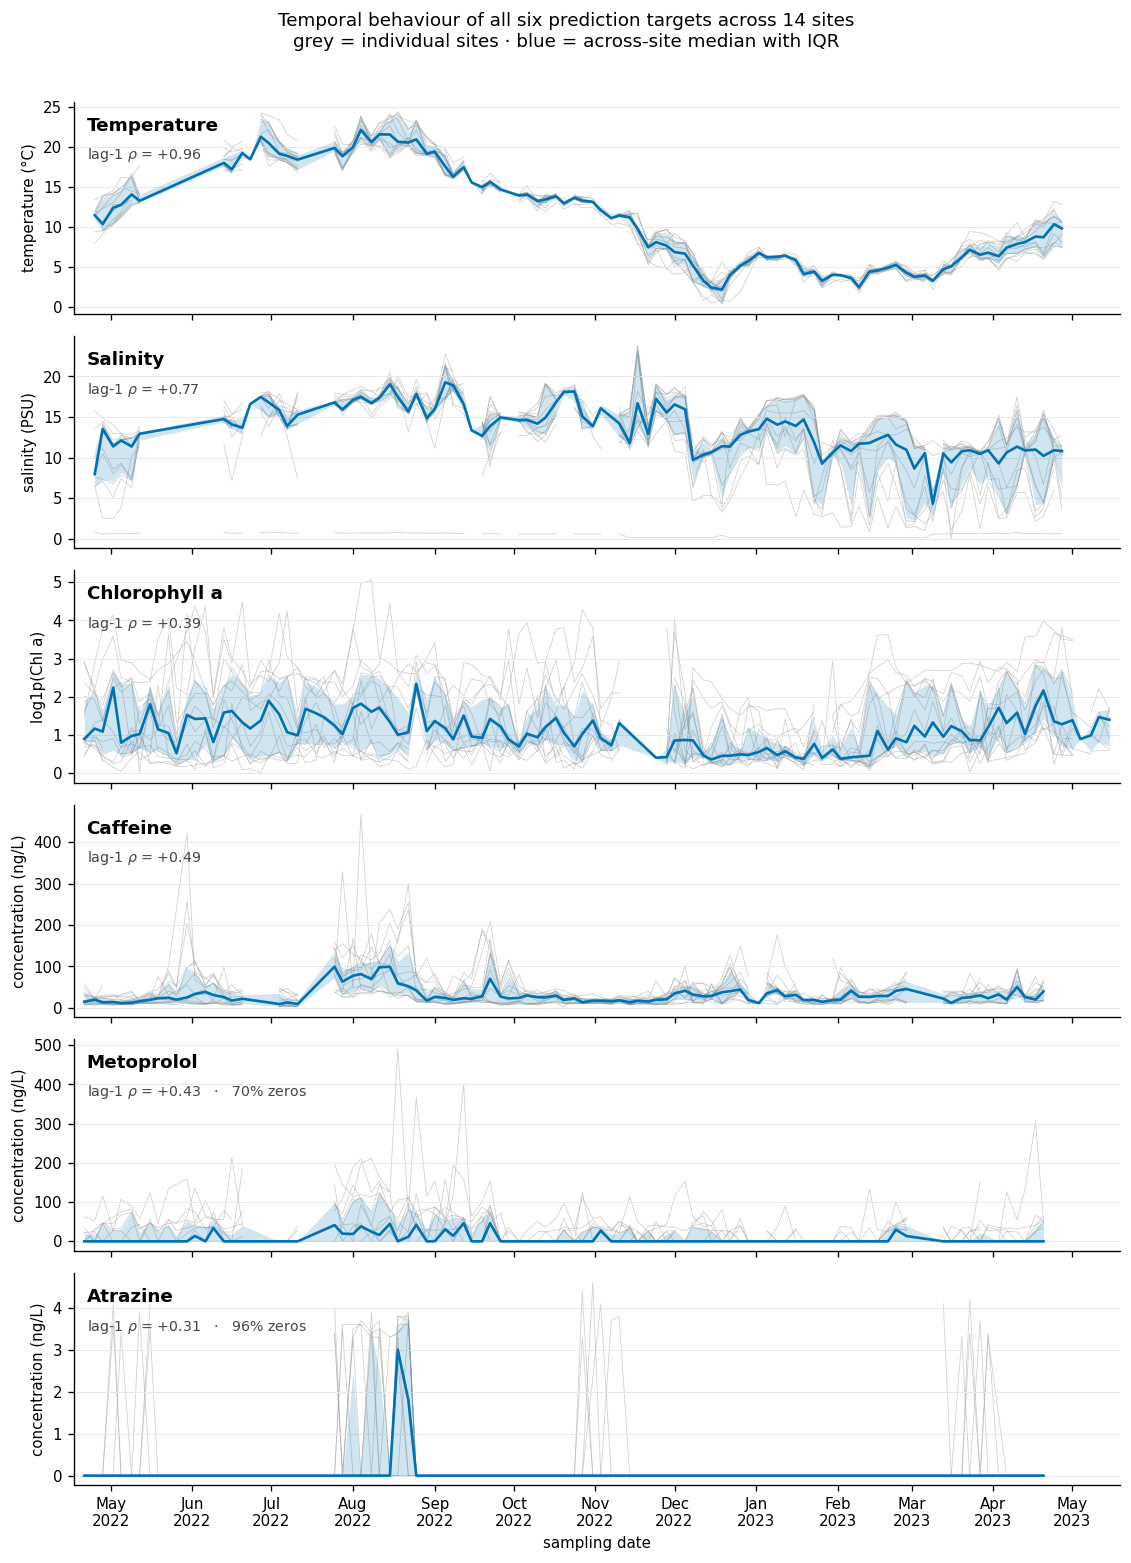

In [9]:
# ── CELL 5: time-series overview of all six targets, across sites ──
#   Directly answers Prof. Lüdtke's request to "plot it over time and over
#   the locations". Individual sites are drawn as thin grey lines; the bold
#   line is the across-site median with an interquartile band.
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

FIGS = PROJ / 'results'
mpl.rcParams.update({'font.size': 9, 'axes.spines.top': False,
                     'axes.spines.right': False, 'figure.dpi': 120})

ACCENT, BAND, SITE_C = '#0072B2', '#0072B2', '#9a9a9a'   # Okabe-Ito safe

# (column, display label, y-axis label, autocorr rho for the annotation)
PANELS = [
    ('temperature', 'Temperature',        'temperature (°C)',      0.96),
    ('salinity',    'Salinity',           'salinity (PSU)',        0.77),
    ('_chl_log1p',  'Chlorophyll a',      'log1p(Chl a)',          0.39),
    ('Caffeine',    'Caffeine',           'concentration (ng/L)',  0.49),
    ('Metoprolol',  'Metoprolol',         'concentration (ng/L)',  0.43),
    ('Atrazine',    'Atrazine',           'concentration (ng/L)',  0.31),
]

fig, axes = plt.subplots(6, 1, figsize=(9.5, 13), sharex=True)

for ax, (col, label, ylab, rho) in zip(axes, PANELS):
    # --- one thin line per site ---
    for site, g in df.groupby(SITE, sort=True):
        g = g.sort_values(DATE)
        ax.plot(g[DATE], g[col], color=SITE_C, lw=0.5, alpha=0.45, zorder=1)

    # --- across-site median + IQR ---
    q = (df.groupby(DATE)[col]
           .agg(med='median', q1=lambda s: s.quantile(.25),
                q3=lambda s: s.quantile(.75))
           .dropna(subset=['med']).sort_index())
    ax.fill_between(q.index, q.q1, q.q3, color=BAND, alpha=0.18, lw=0, zorder=2)
    ax.plot(q.index, q.med, color=ACCENT, lw=1.6, zorder=3)

    # --- annotation: how persistent is this target? ---
    pct0 = 100 * (df[col] == 0).sum() / df[col].notna().sum()
    txt  = f'lag-1 $\\rho$ = {rho:+.2f}'
    if pct0 > 1:
        txt += f'   ·   {pct0:.0f}% zeros'
    ax.text(0.012, 0.93, label, transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top')
    ax.text(0.012, 0.79, txt, transform=ax.transAxes,
            fontsize=8.5, va='top', color='#444444')

    ax.set_ylabel(ylab)
    ax.margins(x=0.01)
    ax.grid(axis='y', color='#e8e8e8', lw=0.6, zorder=0)

axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
axes[-1].set_xlabel('sampling date')

fig.suptitle('Temporal behaviour of all six prediction targets across 14 sites\n'
             'grey = individual sites · blue = across-site median with IQR',
             fontsize=11, y=0.997)
fig.tight_layout(rect=[0, 0, 1, 0.985])

for ext in ('png', 'pdf'):
    fig.savefig(FIGS / f'temporal_overview_six_targets.{ext}',
                bbox_inches='tight', dpi=200)
print(f'saved -> temporal_overview_six_targets.png / .pdf')
plt.show()

In [10]:
# ── CELL 6: is the forecasting test window a different regime? ──
#   The forecasting split uses a fixed global cutoff. This cell quantifies,
#   per target, how the pre- and post-cutoff windows differ in spread,
#   sparsity and persistence — context required to interpret forecasting R².
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

CUTOFF = pd.Timestamp('2023-01-19')
PLOTCOL = {'temperature': 'temperature', 'salinity': 'salinity',
           'Chl_a': '_chl_log1p', 'Caffeine': 'Caffeine',
           'Metoprolol': 'Metoprolol', 'Atrazine': 'Atrazine'}

def window_stats(sub, col):
    v = sub[col].dropna()
    return {'n': len(v), 'std': v.std(), 'var': v.var(),
            'median': v.median(), 'max': v.max(),
            'pct_zero': 100 * (v == 0).mean() if len(v) else np.nan}

def within_site_lag1(sub, col):
    """Spearman lag-1 autocorrelation, pooled over sites, gap-filtered."""
    A, B = [], []
    for _, g in sub.groupby(SITE):
        g = g.sort_values(DATE)
        y  = g[col].to_numpy(float)
        dt = g[DATE].reset_index(drop=True)
        if len(y) <= 1:
            continue
        y0, y1 = y[:-1], y[1:]
        gap = (dt[1:].reset_index(drop=True) - dt[:-1].reset_index(drop=True)).dt.days.to_numpy()
        m = ~np.isnan(y0) & ~np.isnan(y1) & (gap <= TOL[1])
        A.append(y0[m]); B.append(y1[m])
    a, b = np.concatenate(A), np.concatenate(B)
    if len(a) < 30 or len(np.unique(a)) < 5:
        return np.nan, len(a)
    return spearmanr(a, b)[0], len(a)

rows = []
for name, col in PLOTCOL.items():
    tr = df[df[DATE] <  CUTOFF]
    te = df[df[DATE] >= CUTOFF]
    s_tr, s_te = window_stats(tr, col), window_stats(te, col)
    r_tr, n_tr = within_site_lag1(tr, col)
    r_te, n_te = within_site_lag1(te, col)
    rows.append({
        'target': name,
        'n_tr': s_tr['n'], 'n_te': s_te['n'],
        'std_tr': s_tr['std'], 'std_te': s_te['std'],
        'std_ratio': s_te['std'] / s_tr['std'] if s_tr['std'] else np.nan,
        'max_tr': s_tr['max'], 'max_te': s_te['max'],
        'pct0_tr': s_tr['pct_zero'], 'pct0_te': s_te['pct_zero'],
        'rho1_tr': r_tr, 'rho1_te': r_te,
    })
reg = pd.DataFrame(rows)

print('=== spread: does the test window still contain variation? ===')
print(reg[['target', 'n_tr', 'n_te', 'std_tr', 'std_te', 'std_ratio',
           'max_tr', 'max_te']].round(2).to_string(index=False))

print('\n=== sparsity: share of zeros before vs after the cutoff ===')
print(reg[['target', 'pct0_tr', 'pct0_te']].round(1).to_string(index=False))

print('\n=== persistence: lag-1 rho before vs after the cutoff ===')
print(reg[['target', 'rho1_tr', 'rho1_te']].round(3).to_string(index=False))

# ---- detection events surviving into the test window ----
print('\n=== detections after the cutoff (censored targets) ===')
for c in ['Metoprolol', 'Atrazine']:
    te = df[df[DATE] >= CUTOFF]
    d  = (te[c] > 0)
    print(f'  {c:<11s} {d.sum():3d} detections / {te[c].notna().sum():3d} measured '
          f'({100*d.mean():.1f}%)  ·  across {te.loc[d, SITE].nunique()} sites')

reg.to_csv(RESULTS / 'forecast_window_regime_check.csv', index=False)
print('\nsaved -> forecast_window_regime_check.csv')

=== spread: does the test window still contain variation? ===
     target  n_tr  n_te  std_tr  std_te  std_ratio  max_tr  max_te
temperature   829   394    6.05    2.24       0.37   24.46   13.21
   salinity   822   395    4.91    4.62       0.94   23.80   17.80
      Chl_a  1006   431    0.95    0.91       0.96    5.06    3.98
   Caffeine   975   316   43.09   24.28       0.56  467.60  296.60
 Metoprolol   975   318   42.83   27.34       0.64  491.90  306.40
   Atrazine   973   316    0.80    0.54       0.67    4.60    4.20

=== sparsity: share of zeros before vs after the cutoff ===
     target  pct0_tr  pct0_te
temperature      0.0      0.0
   salinity      0.0      0.0
      Chl_a      0.1      0.0
   Caffeine      0.0      0.0
 Metoprolol     67.2     78.9
   Atrazine     94.9     97.8

=== persistence: lag-1 rho before vs after the cutoff ===
     target  rho1_tr  rho1_te
temperature    0.972    0.835
   salinity    0.739    0.756
      Chl_a    0.707    0.713
   Caffeine    0.77

In [11]:
# ── CELL 7: per-site regime check (consistent with Cell 3) + persistence baseline ──
#   (a) recomputes the train/test regime comparison per site, so the numbers
#       are comparable with the Cell-3 autocorrelation table;
#   (b) computes the model-free persistence baseline for all six targets at
#       k = 1,2,3 on the exact forecasting split, giving the reference against
#       which the TabPFN/baseline forecasts will be scored.
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

CUTOFF = pd.Timestamp('2023-01-19')
COL = {'temperature': 'temperature', 'salinity': 'salinity', 'Chl_a': '_chl_log1p',
       'Caffeine': 'Caffeine', 'Metoprolol': 'Metoprolol', 'Atrazine': 'Atrazine'}

def per_site_lag1(sub, col, min_pairs=20, min_distinct=5):
    """Median over sites of the lag-1 Spearman autocorrelation."""
    vals = []
    for _, g in sub.groupby(SITE):
        g  = g.sort_values(DATE)
        y  = g[col].to_numpy(float)
        dt = g[DATE].reset_index(drop=True)
        if len(y) <= 1:
            continue
        y0, y1 = y[:-1], y[1:]
        gap = (dt[1:].reset_index(drop=True) - dt[:-1].reset_index(drop=True)).dt.days.to_numpy()
        m   = ~np.isnan(y0) & ~np.isnan(y1) & (gap <= TOL[1])
        a, b = y0[m], y1[m]
        if len(a) >= min_pairs and min(len(np.unique(a)), len(np.unique(b))) >= min_distinct:
            vals.append(spearmanr(a, b)[0])
    return (np.median(vals) if vals else np.nan), len(vals)

# ================= A. regime check, per site =================
rows = []
for name, col in COL.items():
    tr, te = df[df[DATE] < CUTOFF], df[df[DATE] >= CUTOFF]
    r_tr, n_str = per_site_lag1(tr, col)
    r_te, n_ste = per_site_lag1(te, col)
    rows.append({'target': name,
                 'std_tr': tr[col].std(), 'std_te': te[col].std(),
                 'std_ratio': te[col].std() / tr[col].std(),
                 'rho1_tr': r_tr, 'sites_tr': n_str,
                 'rho1_te': r_te, 'sites_te': n_ste})
reg = pd.DataFrame(rows)
print('=== A. regime check · PER SITE (comparable with the Cell-3 table) ===')
print(reg.round(3).to_string(index=False))
print('\n  note: test window = 2023-01-19 .. 2023-05-15 (winter/spring only).')

# ================= B. persistence baseline on the forecasting split =================
def persistence(col, k):
    """Persistence forecast y_hat(t+k) = y(t), evaluated on test-window pairs only."""
    A, B = [], []
    for _, g in df.groupby(SITE):
        g  = g.sort_values(DATE)
        y  = g[col].to_numpy(float)
        dt = g[DATE].reset_index(drop=True)
        if len(y) <= k:
            continue
        y0, y1 = y[:-k], y[k:]
        d0 = dt[:-k].reset_index(drop=True)
        d1 = dt[k:].reset_index(drop=True)
        gap = (d1 - d0).dt.days.to_numpy()
        m = (~np.isnan(y0) & ~np.isnan(y1) & (gap <= TOL[k])
             & (d0 >= CUTOFF).to_numpy())          # feature date in the test window
        A.append(y0[m]); B.append(y1[m])
    a, b = np.concatenate(A), np.concatenate(B)
    if len(a) < 10:
        return {'n_test_pairs': len(a), 'r2': np.nan, 'mae': np.nan,
                'rho': np.nan, 'std_y': np.nan, 'pct_nonzero': np.nan}
    ss_res, ss_tot = np.sum((b - a) ** 2), np.sum((b - b.mean()) ** 2)
    return {'n_test_pairs': len(a),
            'r2':  1 - ss_res / ss_tot if ss_tot > 0 else np.nan,
            'mae': np.mean(np.abs(b - a)),
            'rho': spearmanr(a, b)[0] if len(np.unique(a)) >= 5 else np.nan,
            'std_y': b.std(),
            'pct_nonzero': 100 * np.mean(b > 0)}

rows = []
for name, col in COL.items():
    for k in (1, 2, 3):
        rows.append({'target': name, 'k': k, **persistence(col, k)})
pers = pd.DataFrame(rows)
pers['target'] = pd.Categorical(pers.target, categories=list(COL), ordered=True)
pers = pers.sort_values(['target', 'k'])

print('\n=== B. persistence baseline · test window only ===')
print(pers.round(3).to_string(index=False))

print('\n=== persistence R² grid (this is the bar every model must clear) ===')
print(pers.pivot(index='target', columns='k', values='r2').round(3).to_string())

print('\n=== usable test pairs per target/horizon ===')
print(pers.pivot(index='target', columns='k', values='n_test_pairs').to_string())

pers.to_csv(RESULTS / 'persistence_baseline_six_targets.csv', index=False)
reg.to_csv(RESULTS / 'forecast_window_regime_persite.csv', index=False)
print('\nsaved -> persistence_baseline_six_targets.csv · forecast_window_regime_persite.csv')

=== A. regime check · PER SITE (comparable with the Cell-3 table) ===
     target  std_tr  std_te  std_ratio  rho1_tr  sites_tr  rho1_te  sites_te
temperature   6.047   2.244      0.371    0.962        14    0.822        14
   salinity   4.912   4.616      0.940    0.659        14    0.153        14
      Chl_a   0.953   0.914      0.960    0.380        14    0.340        14
   Caffeine  43.089  24.283      0.564    0.538        14   -0.050         8
 Metoprolol  42.833  27.344      0.638    0.457         9    0.168         1
   Atrazine   0.802   0.537      0.670    0.320         5      NaN         0

  note: test window = 2023-01-19 .. 2023-05-15 (winter/spring only).

=== B. persistence baseline · test window only ===
     target  k  n_test_pairs     r2    mae    rho  std_y  pct_nonzero
temperature  1           373  0.783  0.811  0.835  2.274      100.000
temperature  2           357  0.692  1.035  0.757  2.297      100.000
temperature  3           341  0.555  1.220  0.653  2.280   

In [12]:
# ── CELL 8: decompose the persistence baseline ──
#   Persistence pools pairs across sites, so part of its apparent skill comes
#   from between-site level differences rather than temporal continuity.
#   Scoring a site-mean baseline on the IDENTICAL pairs isolates the two.
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

def build_pairs(col, k):
    """All (t, t+k) pairs whose feature date lies in the test window."""
    recs = []
    for site, g in df.groupby(SITE):
        g  = g.sort_values(DATE)
        y  = g[col].to_numpy(float)
        dt = g[DATE].reset_index(drop=True)
        if len(y) <= k:
            continue
        y0, y1 = y[:-k], y[k:]
        d0, d1 = dt[:-k].reset_index(drop=True), dt[k:].reset_index(drop=True)
        gap = (d1 - d0).dt.days.to_numpy()
        m = (~np.isnan(y0) & ~np.isnan(y1) & (gap <= TOL[k])
             & (d0 >= CUTOFF).to_numpy())
        for i in np.where(m)[0]:
            recs.append({'site': site, 'y_t': y0[i], 'y_tk': y1[i]})
    return pd.DataFrame(recs)

def score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return {'r2': 1 - ss_res / ss_tot if ss_tot > 0 else np.nan,
            'mae': np.mean(np.abs(y_true - y_pred))}

rows = []
for name, col in COL.items():
    train = df[df[DATE] < CUTOFF]
    site_mean   = train.groupby(SITE)[col].mean()
    global_mean = train[col].mean()
    for k in (1, 2, 3):
        P = build_pairs(col, k)
        if len(P) < 10:
            continue
        y = P.y_tk.to_numpy()
        preds = {
            'persistence': P.y_t.to_numpy(),
            'site_mean':   P.site.map(site_mean).to_numpy(),
            'global_mean': np.full(len(P), global_mean),
        }
        rec = {'target': name, 'k': k, 'n_pairs': len(P)}
        for lab, p in preds.items():
            s = score(y, p)
            rec[f'r2_{lab}']  = s['r2']
            rec[f'mae_{lab}'] = s['mae']
        # temporal contribution = what persistence adds over knowing the site
        rec['temporal_gain'] = rec['r2_persistence'] - rec['r2_site_mean']
        rows.append(rec)

B = pd.DataFrame(rows)
B['target'] = pd.Categorical(B.target, categories=list(COL), ordered=True)
B = B.sort_values(['target', 'k'])

print('=== R² of three model-free baselines on identical test pairs ===')
print(B[['target', 'k', 'n_pairs', 'r2_global_mean', 'r2_site_mean',
         'r2_persistence', 'temporal_gain']].round(3).to_string(index=False))

print('\n=== does persistence add anything beyond knowing the site? ===')
print('    temporal_gain = R2(persistence) - R2(site_mean)')
print(B.pivot(index='target', columns='k', values='temporal_gain').round(3).to_string())

print('\n=== strongest model-free baseline per target/horizon ===')
for _, r in B.iterrows():
    cand = {'global_mean': r.r2_global_mean, 'site_mean': r.r2_site_mean,
            'persistence': r.r2_persistence}
    best = max(cand, key=cand.get)
    print(f'  {r.target:<12s} k={r.k}  best = {best:<12s} '
          f'R2={cand[best]:+.3f}   (pers={r.r2_persistence:+.3f}, '
          f'site={r.r2_site_mean:+.3f}, mean={r.r2_global_mean:+.3f})')

B.to_csv(RESULTS / 'baselines_modelfree_decomposition.csv', index=False)
print('\nsaved -> baselines_modelfree_decomposition.csv')

=== R² of three model-free baselines on identical test pairs ===
     target  k  n_pairs  r2_global_mean  r2_site_mean  r2_persistence  temporal_gain
temperature  1      373         -11.583       -11.540           0.783         12.323
temperature  2      357         -11.208       -11.163           0.692         11.855
temperature  3      341         -11.195       -11.143           0.555         11.698
   salinity  1      374          -1.035        -0.528           0.517          1.045
   salinity  2      358          -1.090        -0.576           0.429          1.005
   salinity  3      342          -1.045        -0.522           0.510          1.032
      Chl_a  1      391          -0.001         0.594           0.527         -0.067
      Chl_a  2      378          -0.003         0.608           0.532         -0.076
      Chl_a  3      365          -0.003         0.604           0.462         -0.141
   Caffeine  1      272          -0.167         0.043          -0.239         -0.282


In [13]:
# ── CELL 9: inspect the existing Phase-3 forecasting result files ──
#   Needed before the Phase-3 numbers can be re-scored against the
#   model-free baselines computed in Cell 8. Discovery only.
import pandas as pd

FILES = [
    'phase3_forecasting_full_table.csv',
    'phase3_forecasting_shared_mask_splitB.csv',
    'phase3_forecasting_all_models_splitB.csv',
    'phase3_forecasting_tabpfn_vs_persistence.csv',
    'table_forecasting_r2_wide.csv',
    'table_forecasting_best_per_cell.csv',
]

for f in FILES:
    p = RESULTS / f
    print('=' * 78)
    print(f'### {f}   exists={p.exists()}')
    if not p.exists():
        continue
    d = pd.read_csv(p)
    print(f'  shape = {d.shape}')
    print(f'  columns = {list(d.columns)}')
    for c in d.columns:
        if d[c].dtype == object or d[c].nunique() <= 8:
            u = sorted(d[c].dropna().unique().tolist())[:8]
            print(f'    {c:<24s} -> {u}')
    print('  --- head(6) ---')
    print(d.head(6).to_string())
    print()

### phase3_forecasting_full_table.csv   exists=True
  shape = (108, 15)
  columns = ['target', 'horizon', 'input', 'model', 'n_train', 'n_test', 'r2', 'mae', 'rmse', 'persistence_r2', 'persistence_mae', 'delta_r2', 'beats_persistence', 'rank_in_cell', 'seconds']
    target                   -> ['Atrazine', 'Caffeine', 'Metoprolol']
    horizon                  -> [1, 2, 3]
    input                    -> ['16S', '16S+18S', '18S']
    model                    -> ['Lasso', 'Random Forest', 'TabPFN', 'XGBoost']
    n_train                  -> [892, 894, 914, 916, 937, 939]
    n_test                   -> [230, 232, 264, 266, 282, 286]
    beats_persistence        -> [False, True]
  --- head(6) ---
     target  horizon input          model  n_train  n_test      r2      mae     rmse  persistence_r2  persistence_mae  delta_r2  beats_persistence  rank_in_cell   seconds
0  Caffeine        1   16S         TabPFN      939     282  0.0171  14.4014  18.8924          -0.238          13.2333    0.25

In [17]:
# ── CELL 10: honest skill scoring on the exact shared mask + mask diagnosis ──
#   (a) confirms build_pairs reproduces `n_shared_eval` / `per_shared_r2`;
#   (b) adds site-mean and global-mean baselines on that IDENTICAL mask;
#   (c) rescores TabPFN(16S) against the strongest model-free baseline;
#   (d) tests whether the day-gap filter explains the 282-vs-272 discrepancy.
import numpy as np
import pandas as pd

tvp = pd.read_csv(RESULTS / 'phase3_forecasting_tabpfn_vs_persistence.csv')
tvp = tvp[(tvp.split == 'B') & (tvp.input == '16S')]

def build_pairs_flag(col, k, use_gap_filter=True):
    recs = []
    for site, g in df.groupby(SITE):
        g  = g.sort_values(DATE)
        y  = g[col].to_numpy(float)
        dt = g[DATE].reset_index(drop=True)
        if len(y) <= k:
            continue
        y0, y1 = y[:-k], y[k:]
        d0, d1 = dt[:-k].reset_index(drop=True), dt[k:].reset_index(drop=True)
        gap = (d1 - d0).dt.days.to_numpy()
        m = ~np.isnan(y0) & ~np.isnan(y1) & (d0 >= CUTOFF).to_numpy()
        if use_gap_filter:
            m &= (gap <= TOL[k])
        for i in np.where(m)[0]:
            recs.append({'site': site, 'y_t': y0[i], 'y_tk': y1[i]})
    return pd.DataFrame(recs)

def r2(y, p):
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1 - np.sum((y - p) ** 2) / ss_tot if ss_tot > 0 else np.nan

# ================= A. verify the mask reproduction =================
print('=== A. does build_pairs reproduce n_shared_eval / per_shared_r2? ===')
rows = []
for _, r in tvp.iterrows():
    col = COL[r.target]
    P   = build_pairs_flag(col, int(r.horizon_k))
    mine_n, mine_r2 = len(P), r2(P.y_tk.to_numpy(), P.y_t.to_numpy())
    rows.append({'target': r.target, 'k': int(r.horizon_k),
                 'n_mine': mine_n, 'n_file': int(r.n_shared_eval),
                 'r2_mine': mine_r2, 'r2_file': r.per_shared_r2,
                 'n_ok': mine_n == int(r.n_shared_eval),
                 'r2_ok': abs(mine_r2 - r.per_shared_r2) < 1e-3})
V = pd.DataFrame(rows)
print(V.round(4).to_string(index=False))
print(f"\n  => all masks match: {V.n_ok.all()}   all R² match: {V.r2_ok.all()}")

# ================= B. mask diagnosis: is the gap filter the cause? =================
print('\n=== B. why does the 108-row table use 282/264/230 instead? ===')
for c in ['Caffeine', 'Metoprolol', 'Atrazine']:
    for k in (1, 2, 3):
        Pg = build_pairs_flag(COL[c], k, use_gap_filter=True)
        Pn = build_pairs_flag(COL[c], k, use_gap_filter=False)
        print(f'  {c:<11s} k={k}   with gap filter n={len(Pg):3d} '
              f'(R²={r2(Pg.y_tk.to_numpy(), Pg.y_t.to_numpy()):+.4f})   '
              f'without n={len(Pn):3d} '
              f'(R²={r2(Pn.y_tk.to_numpy(), Pn.y_t.to_numpy()):+.4f})')

# ================= C. all model-free baselines on the shared mask =================
print('\n=== C. TabPFN(16S) vs the strongest model-free baseline, same pairs ===')
rows = []
for _, r in tvp.iterrows():
    c, k = r.target, int(r.horizon_k)
    col  = COL[c]
    P    = build_pairs_flag(col, k)
    y    = P.y_tk.to_numpy()
    train = df[df[DATE] < CUTOFF]
    sm, gm = train.groupby(SITE)[col].mean(), train[col].mean()

    base = {'persistence': r2(y, P.y_t.to_numpy()),
            'site_mean':   r2(y, P.site.map(sm).to_numpy()),
            'global_mean': r2(y, np.full(len(y), gm))}
    best_name = max(base, key=base.get)
    rows.append({'target': c, 'k': k, 'n': len(P),
                 'tabpfn': r.tab_shared_r2,
                 **{f'r2_{n}': v for n, v in base.items()},
                 'best_baseline': best_name, 'r2_best': base[best_name],
                 'skill_vs_best': r.tab_shared_r2 - base[best_name],
                 'skill_vs_pers': r.tab_shared_r2 - base['persistence']})
S = pd.DataFrame(rows).sort_values(['target', 'k'])
print(S.round(3).to_string(index=False))

print('\n=== verdict per cell ===')
for _, r in S.iterrows():
    ok = 'BEATS' if r.skill_vs_best > 0 else 'does NOT beat'
    print(f'  {r.target:<11s} k={r.k}  TabPFN {r.tabpfn:+.3f}  {ok} '
          f'best baseline ({r.best_baseline} {r.r2_best:+.3f})  '
          f'skill = {r.skill_vs_best:+.3f}')

S.to_csv(RESULTS / 'phase3_tabpfn_vs_modelfree_baselines.csv', index=False)
print('\nsaved -> phase3_tabpfn_vs_modelfree_baselines.csv')

=== A. does build_pairs reproduce n_shared_eval / per_shared_r2? ===
    target  k  n_mine  n_file  r2_mine  r2_file  n_ok  r2_ok
  Caffeine  1     272     272  -0.2390  -0.2390  True   True
  Caffeine  2     250     250  -1.1356  -1.1356  True   True
  Caffeine  3     222     222  -0.9595  -0.9595  True   True
Metoprolol  1     276     276  -0.0039  -0.0039  True   True
Metoprolol  2     252     252   0.0392   0.0392  True   True
Metoprolol  3     224     224   0.3456   0.3456  True   True
  Atrazine  1     272     272  -1.1241  -1.1241  True   True
  Atrazine  2     250     250  -0.4430  -0.4430  True   True
  Atrazine  3     222     222  -0.6914  -0.6914  True   True

  => all masks match: True   all R² match: True

=== B. why does the 108-row table use 282/264/230 instead? ===
  Caffeine    k=1   with gap filter n=272 (R²=-0.2390)   without n=274 (R²=-0.2331)
  Caffeine    k=2   with gap filter n=250 (R²=-1.1356)   without n=254 (R²=-1.1082)
  Caffeine    k=3   with gap filter n=22

In [18]:
# ── CELL 11: honest headline table for the thesis (16S · TabPFN vs best baseline) ──
#   Formats the Cell-10 results into the table that should REPLACE
#   table_forecasting_best_per_cell.csv as the primary forecasting result.
import pandas as pd

S = pd.read_csv(RESULTS / 'phase3_tabpfn_vs_modelfree_baselines.csv')
S['target'] = pd.Categorical(S.target, categories=['Caffeine', 'Metoprolol', 'Atrazine'], ordered=True)
S = S.sort_values(['target', 'k'])

out = S[['target', 'k', 'n', 'tabpfn', 'best_baseline', 'r2_best', 'skill_vs_best']].copy()
out.columns = ['Target', 'Horizon k', 'n_pairs', 'TabPFN R²', 'Best baseline',
               'Baseline R²', 'Skill (TabPFN - baseline)']
out['Verdict'] = out['Skill (TabPFN - baseline)'].apply(
    lambda x: 'real skill' if x > 0.03 else ('negligible' if x > -0.03 else 'loses to baseline'))

print(out.round(3).to_string(index=False))
out.to_csv(RESULTS / 'phase3_forecasting_honest_headline.csv', index=False)
print('\nsaved -> phase3_forecasting_honest_headline.csv')
print('\nThis table should replace table_forecasting_best_per_cell.csv as the')
print('primary forecasting result reported in Chapter 8.')

    Target  Horizon k  n_pairs  TabPFN R² Best baseline  Baseline R²  Skill (TabPFN - baseline)           Verdict
  Caffeine          1      272      0.123     site_mean        0.043                      0.081        real skill
  Caffeine          2      250      0.228     site_mean        0.066                      0.163        real skill
  Caffeine          3      222      0.135     site_mean        0.156                     -0.021        negligible
Metoprolol          1      276      0.021     site_mean        0.144                     -0.122 loses to baseline
Metoprolol          2      252      0.075     site_mean        0.119                     -0.044 loses to baseline
Metoprolol          3      224      0.033   persistence        0.346                     -0.313 loses to baseline
  Atrazine          1      272      0.004   global_mean       -0.042                      0.046        real skill
  Atrazine          2      250      0.007   global_mean       -0.034                    

In [2]:
import pandas as pd
from pathlib import Path
R = Path('/mnt/data/home/tv2414/tabpfn_project/results')
ac = pd.read_csv(R / 'temporal_autocorr_summary.csv')
print(ac.to_string(index=False))

     target  k  n_sites  n_pairs  pearson_med  pearson_q1  pearson_q3  spearman_med  spearman_q1  spearman_q3
temperature  1       14     1103     0.979054    0.975354    0.983064      0.958225     0.952801     0.969376
temperature  2       14     1046     0.964011    0.960784    0.965124      0.922302     0.905646     0.935165
temperature  3       14     1010     0.944417    0.941215    0.950116      0.871448     0.861717     0.888504
   salinity  1       14     1091     0.688733    0.533301    0.801439      0.765553     0.593907     0.805443
   salinity  2       14     1040     0.648673    0.442508    0.780552      0.700738     0.467783     0.804352
   salinity  3       14      999     0.599577    0.386096    0.747866      0.635298     0.354371     0.763562
      Chl_a  1       14     1361     0.182943    0.031624    0.389596      0.386637     0.224269     0.527575
      Chl_a  2       14     1328     0.083208    0.012669    0.222589      0.308421     0.163628     0.404550
      Chl_

merged 18 cells (expect 18)
saved -> shift_effect_vs_autocorrelation.png / .pdf


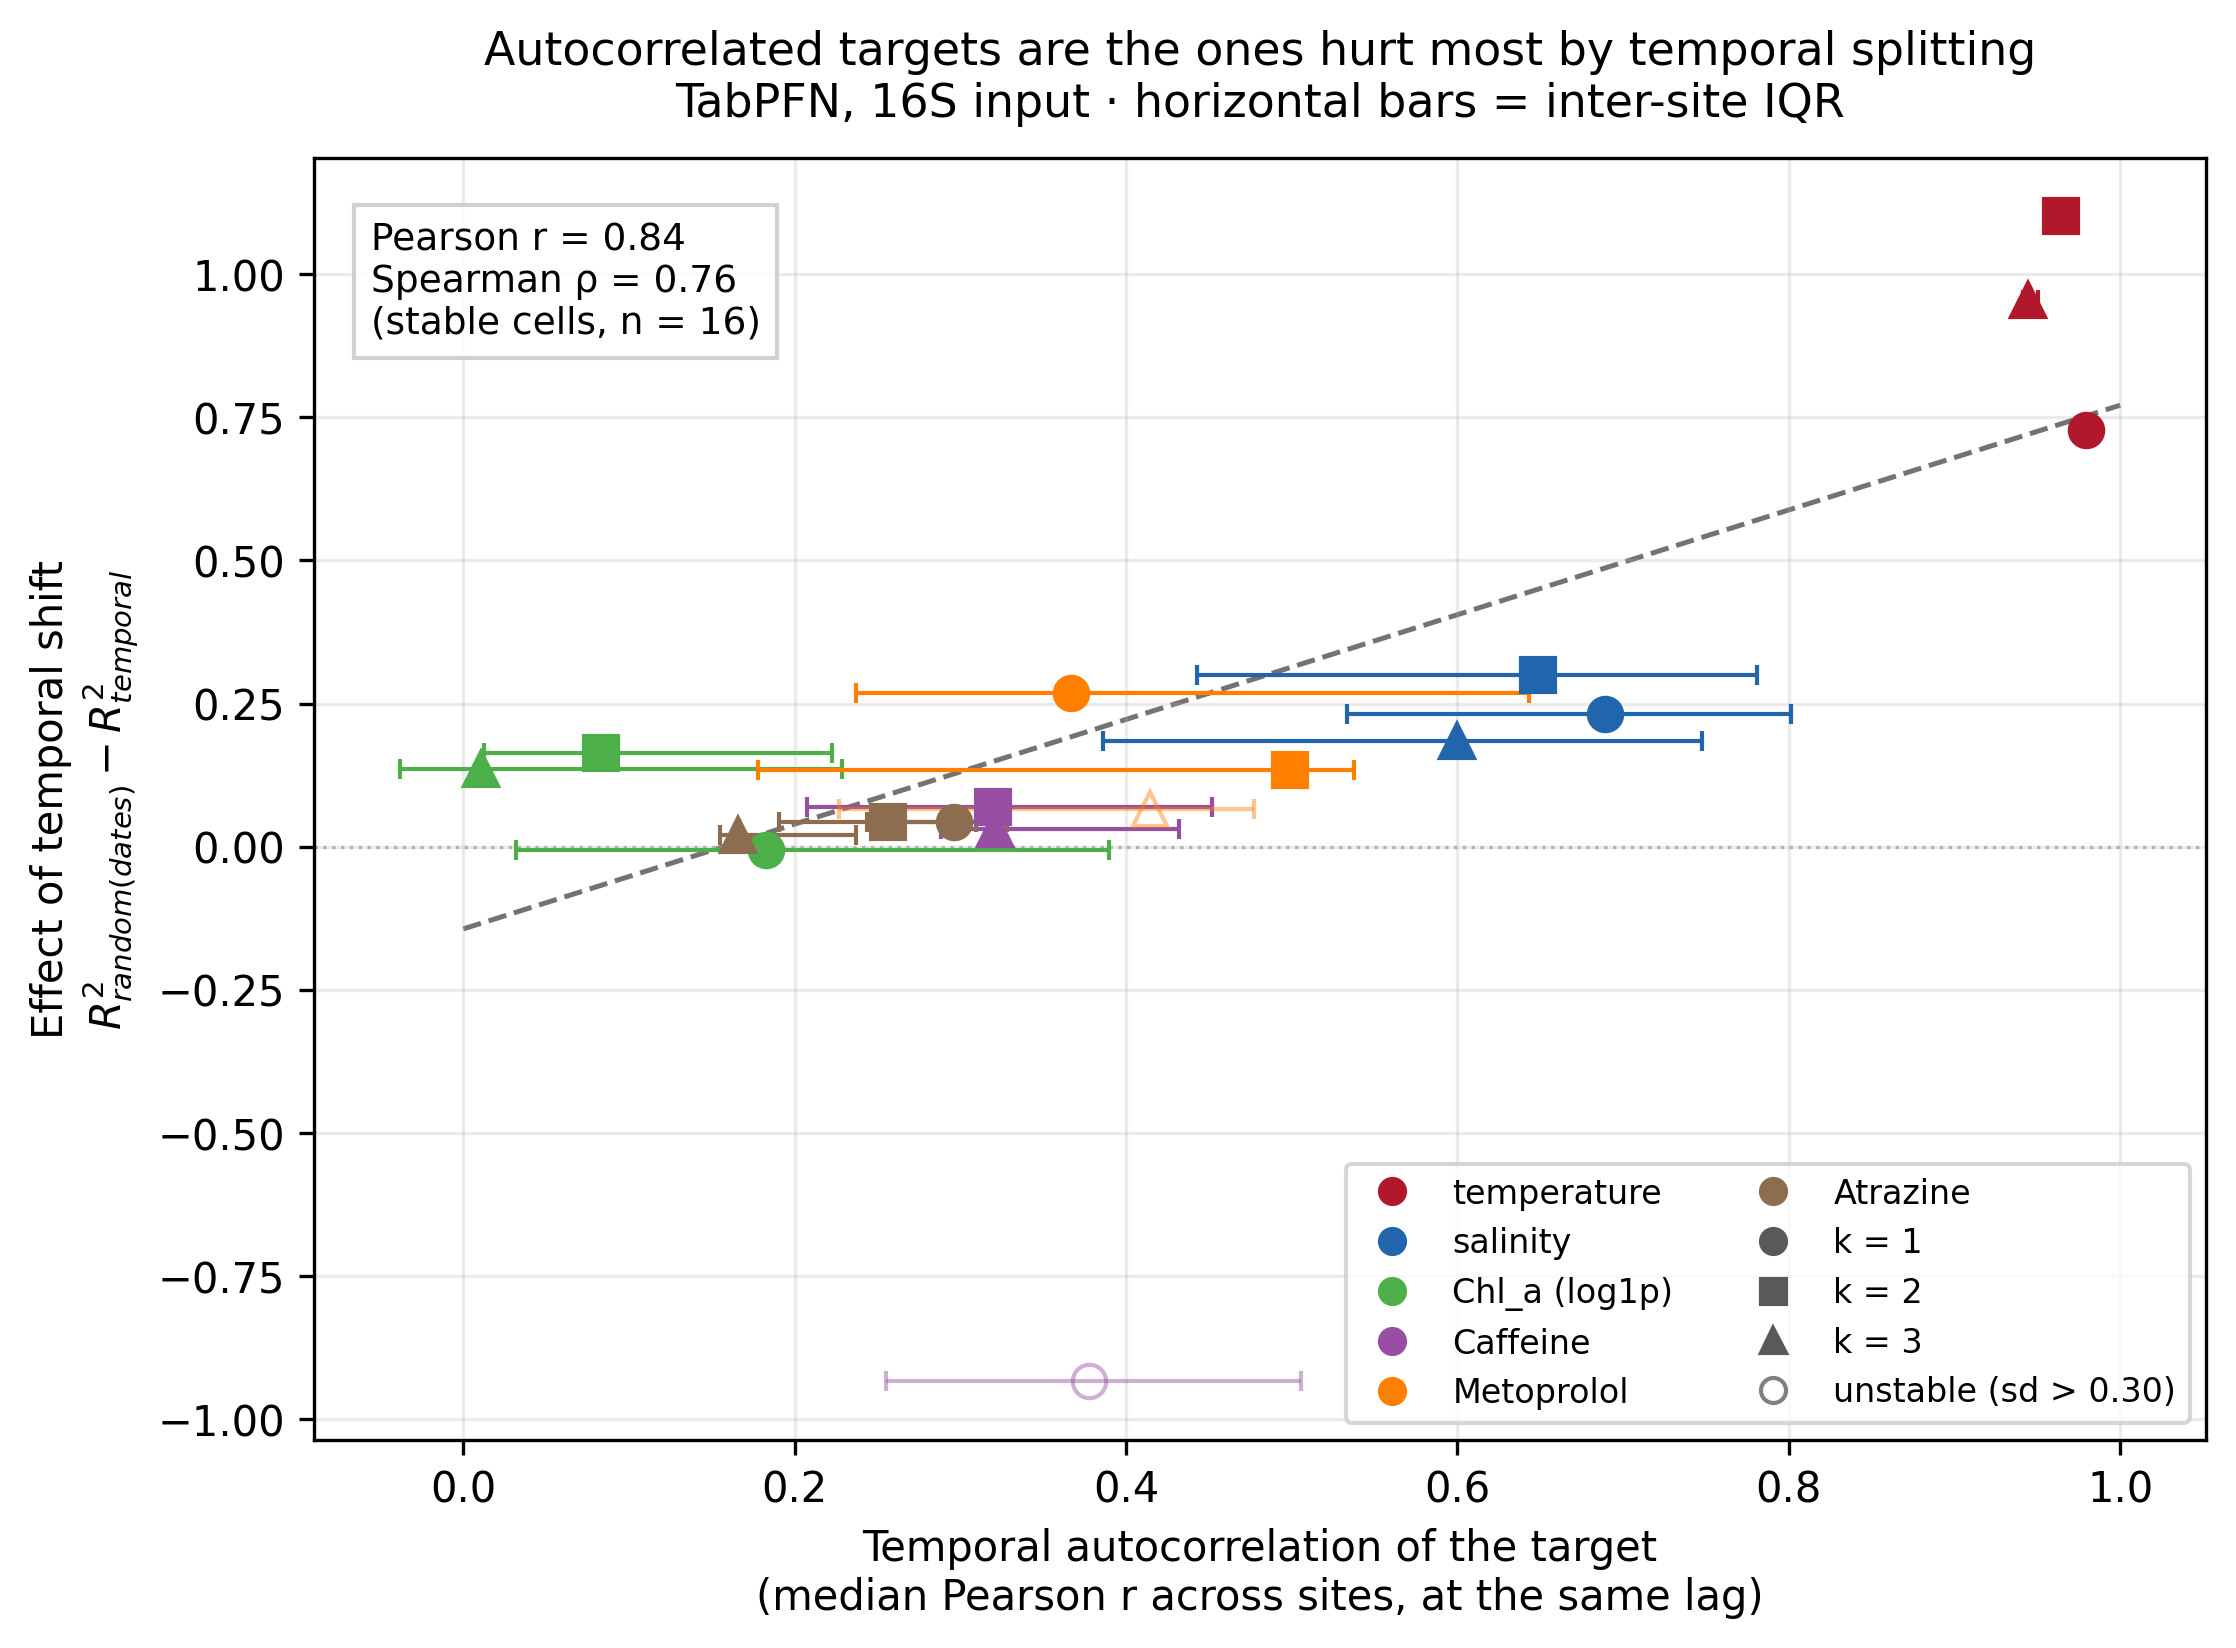

In [6]:
# === Autocorrelation vs. the effect of temporal shift ===
import warnings; warnings.filterwarnings('ignore')
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np, pandas as pd
from pathlib import Path
from IPython.display import Image, display

R = Path('/mnt/data/home/tv2414/tabpfn_project/results')
ac = pd.read_csv(R / 'temporal_autocorr_summary.csv')
sp = pd.read_csv(R / 'phase3_random_split_multiseed.csv')

ac = ac.rename(columns={'k': 'horizon_k'})
ac['target'] = ac['target'].replace({'Chl_a': 'Chl_a_log1p'})

g    = sp.groupby(['target', 'horizon_k', 'regime'])['r2']
mean, sd = g.mean().unstack('regime'), g.std().unstack('regime')
eff = (mean['random_dates'] - mean['temporal']).rename('shift_eff').reset_index()
eff['sd_rd'] = sd['random_dates'].values

D = ac.merge(eff, on=['target', 'horizon_k'], how='inner')
D['unstable'] = D.sd_rd > 0.30
print(f"merged {len(D)} cells (expect 18)")

COL = {'temperature': '#b2182b', 'salinity': '#2166ac', 'Chl_a_log1p': '#4daf4a',
       'Caffeine': '#984ea3', 'Metoprolol': '#ff7f00', 'Atrazine': '#8c6d4f'}
MRK = {1: 'o', 2: 's', 3: '^'}

fig, ax = plt.subplots(figsize=(7.6, 5.6))
for _, r in D.iterrows():
    c = COL[r['target']]
    ax.errorbar(float(r['pearson_med']), float(r['shift_eff']),
                xerr=[[float(r['pearson_med'] - r['pearson_q1'])],
                      [float(r['pearson_q3'] - r['pearson_med'])]],
                fmt=MRK[int(r['horizon_k'])], ms=8, color=c, capsize=2.5, lw=1.0,
                alpha=0.45 if r['unstable'] else 1.0,
                mfc='none' if r['unstable'] else c, zorder=3)

S = D[~D['unstable']]
sl, ic = np.polyfit(S['pearson_med'], S['shift_eff'], 1)
xs = np.linspace(0, 1, 50)
ax.plot(xs, sl * xs + ic, '--', color='0.45', lw=1.2, zorder=1)
r_p = S[['pearson_med', 'shift_eff']].corr().iloc[0, 1]
rho = S[['pearson_med', 'shift_eff']].corr(method='spearman').iloc[0, 1]
ax.text(0.03, 0.95,
        f'Pearson r = {r_p:.2f}\nSpearman ρ = {rho:.2f}\n(stable cells, n = {len(S)})',
        transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(fc='white', ec='0.8', alpha=0.9))

ax.axhline(0, color='0.7', lw=0.8, ls=':')
ax.set_xlabel('Temporal autocorrelation of the target\n'
              '(median Pearson r across sites, at the same lag)', fontsize=10)
ax.set_ylabel('Effect of temporal shift\n$R^2_{random(dates)} - R^2_{temporal}$', fontsize=10)
ax.set_title('Autocorrelated targets are the ones hurt most by temporal splitting\n'
             'TabPFN, 16S input · horizontal bars = inter-site IQR', fontsize=11, pad=10)
ax.grid(alpha=0.25)

from matplotlib.lines import Line2D
h1 = [Line2D([0], [0], marker='o', ls='', color=COL[t],
             label=t.replace('_log1p', ' (log1p)')) for t in COL]
h2 = [Line2D([0], [0], marker=MRK[k], ls='', color='0.35', label=f'k = {k}') for k in MRK]
h3 = [Line2D([0], [0], marker='o', ls='', mfc='none', color='0.5', label='unstable (sd > 0.30)')]
ax.legend(handles=h1 + h2 + h3, fontsize=8, loc='lower right', frameon=True, ncol=2)

fig.tight_layout()
for ext in ('png', 'pdf'):
    fig.savefig(R / f'shift_effect_vs_autocorrelation.{ext}', dpi=300, bbox_inches='tight')
plt.close(fig)
print('saved -> shift_effect_vs_autocorrelation.png / .pdf')
display(Image(str(R / 'shift_effect_vs_autocorrelation.png')))

In [7]:
S2 = S[S['target'] != 'temperature']
print("without temperature: r =",
      round(S2[['pearson_med','shift_eff']].corr().iloc[0,1], 2),
      " n =", len(S2))

without temperature: r = 0.58  n = 13


In [1]:
# ── CELL 16: what exists for the chemical grid? (before deciding on any re-run) ──
import pandas as pd
from pathlib import Path

RESULTS = Path('../results')
files = {
    'Lasso'  : 'phase3_lasso_3targets_3inputs_4strategies.csv',
    'RF'     : 'phase3_random_forest_3targets_3inputs_4strategies.csv',
    'TabPFN' : 'phase3_tabpfn_3targets_3inputs_4strategies.csv',
    'XGB(16S only)': 'phase3_xgboost_16S_2strategies.csv',
    'RF(16S only)' : 'phase3_random_forest_16S_2strategies.csv',
    'Lasso(16S only)': 'phase3_lasso_16S_2strategies.csv',
}
for label, f in files.items():
    p = RESULTS / f
    if not p.exists():
        print(f'{label:16s} MISSING  ({f})')
        continue
    d = pd.read_csv(p)
    tcol = next((c for c in d.columns if 'target' in c), None)
    print(f'\n{label:16s} shape={d.shape}  file={f}')
    print(f'   targets   : {sorted(d[tcol].unique())}')
    print(f'   inputs    : {sorted(d["input"].unique()) if "input" in d else "n/a"}')
    print(f'   strategies: {sorted(d["strategy"].unique()) if "strategy" in d else "n/a"}')
    if 'input' in d and 'strategy' in d:
        print(f'   cells     : {len(d.drop_duplicates([tcol,"input","strategy"]))} / 36')

print('\n=== is there ANY full-grid xgboost file for the chemical targets? ===')
for p in sorted(RESULTS.glob('*.csv')):
    if 'xgb' in p.name.lower() and ('phase3' in p.name or 'hplc' in p.name):
        print(' ', p.name)


Lasso            shape=(23, 15)  file=phase3_lasso_3targets_3inputs_4strategies.csv
   targets   : ['Caffeine', 'Metoprolol']
   inputs    : ['16S', '16S+18S', '18S']
   strategies: ['leave_one_site_out', 'random_kfold', 'temporal_blocked_kfold', 'temporal_holdout']
   cells     : 23 / 36

RF               shape=(2, 15)  file=phase3_random_forest_3targets_3inputs_4strategies.csv
   targets   : ['Caffeine']
   inputs    : ['16S']
   strategies: ['random_kfold', 'temporal_holdout']
   cells     : 2 / 36

TabPFN           shape=(36, 15)  file=phase3_tabpfn_3targets_3inputs_4strategies.csv
   targets   : ['Atrazine', 'Caffeine', 'Metoprolol']
   inputs    : ['16S', '16S+18S', '18S']
   strategies: ['leave_one_site_out', 'random_kfold', 'temporal_blocked_kfold', 'temporal_holdout']
   cells     : 36 / 36

XGB(16S only)    shape=(6, 15)  file=phase3_xgboost_16S_2strategies.csv
   targets   : ['Atrazine', 'Caffeine', 'Metoprolol']
   inputs    : ['16S']
   strategies: ['random_kfold', 'tempo

In [2]:
# ── CELL 17: recover the exact Phase 3 data recipe (targets, censoring, alignment) ──
import json
from pathlib import Path

PROJ = Path('/mnt/data/home/tv2414/tabpfn_project')

print('--- notebooks matching 13/14/phase3 ---')
for p in sorted(PROJ.glob('notebooks/*.ipynb')):
    print(' ', p.name)

# find the notebook that produced phase3_xgboost_16S_2strategies.csv
print('\n=== searching notebooks for the XGBoost chemical run ===')
for nbp in sorted(PROJ.glob('notebooks/*.ipynb')):
    nb = json.load(open(nbp))
    for i, cell in enumerate(nb['cells']):
        if cell['cell_type'] != 'code':
            continue
        s = ''.join(cell['source'])
        if 'phase3_xgboost_16S_2strategies' in s:
            print(f'\n>>> FOUND in {nbp.name}, cell [{i}]')
            print(s[:4000])
            break

--- notebooks matching 13/14/phase3 ---
  01_data_exploration copy.ipynb
  01_data_exploration.ipynb
  02_first_baseline.ipynb
  02_preprocessing.ipynb
  03_lasso_baselines.ipynb
  04_test_cv_strategies.ipynb
  05_lasso_evaluation_strategies.ipynb
  06_xgboost_evaluation_strategies.ipynb
  07_random_forest_evaluation_strategies.ipynb
  07_random_forest_evaluation_strategies_executed.ipynb
  08_tabpfn_evaluation_strategies.ipynb
  09_missingness_check.ipynb
  10_tabpfn_evaluation_strategies_v3.ipynb
  11_phase2_embeddings.ipynb
  12_phase2_taxonomy.ipynb
  13_phase2_clean.ipynb
  14_phase3_hplc.ipynb
  14_tabpfn_hplc.ipynb
  15_temporal_autocorrelation_all_targets.ipynb

=== searching notebooks for the XGBoost chemical run ===

>>> FOUND in 14_phase3_hplc.ipynb, cell [7]
# ── CELL 2c (light, RESUME-SAFE): XGBoost · 16S · 2 key strategies ──────────
from src.xgboost_evaluator import run_xgboost_with_splits

KEY_STRATEGIES = ['random_kfold', 'temporal_blocked_kfold']
KEY_INPUT      = '16S

In [3]:
# ── CELL 1: print the Phase 3 setup cells verbatim (no execution) ───────────
import json
from pathlib import Path

nb = json.load(open('/mnt/data/home/tv2414/tabpfn_project/notebooks/14_phase3_hplc.ipynb'))
for i in [0, 1, 2, 3, 4]:
    c = nb['cells'][i]
    if c['cell_type'] != 'code':
        continue
    print('=' * 78)
    print(f'CELL [{i}]')
    print('=' * 78)
    print(''.join(c['source']))
    print()

CELL [0]
# ── suppress noisy Lasso convergence warnings (does NOT touch src/) ─────────
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

CELL [1]
# ═══════════════════════════════════════════════════════════════════════════
# NOTEBOOK 14 · PHASE 3 — Transfer of the TabPFN pipeline to anthropogenic
# pollutants, and comparison of their signal types.
#
# Targets / difficulty gradient:
#   Caffeine    — easy, data-rich        (quant ~91%)  : strong, transferable
#   Metoprolol  — sparse, site-dependent (quant ~27%)  : point-source signal
#   Atrazine    — very sparse, hard      (quant ~4%)   : weak but significant
#
# Pipeline (src/) is reused untouched. Notebooks 05/06/10/13 are not modified.
# ═══════════════════════════════════════════════════════════════════════════

# ── CELL 0: setup — constants + locked-pipeline imports ─────────────────────
import sys, time
from pathlib import Path
import numpy as np


In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# XGBoost · chemical targets · FULL GRID (3 inputs × 4 strategies = 36 cells)
# Fully self-contained: rebuilds data from disk, no dependency on kernel state.
# Resume-safe: reuses the 6 existing cells, writes CSV after every new cell.
# ═══════════════════════════════════════════════════════════════════════════
import warnings, sys, time
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

from pathlib import Path
import numpy as np, pandas as pd

ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')
sys.path.insert(0, str(ROOT))
PROCESSED_DIR = ROOT / 'data' / 'processed'
RAW_DIR       = ROOT / 'data'
RESULTS       = ROOT / 'results'
RANDOM_SEED   = 42

from src.cv_strategies import (random_kfold, temporal_holdout,
                               temporal_blocked_kfold, leave_one_site_out)
from src.xgboost_evaluator import run_xgboost_with_splits

def build_splits(strategy_name, meta_valid, random_seed=RANDOM_SEED):
    n = len(meta_valid)
    if strategy_name == 'random_kfold':
        return random_kfold(n_samples=n, n_folds=5, random_seed=random_seed)
    if strategy_name == 'temporal_holdout':
        return temporal_holdout(meta_valid, test_fraction=0.2)
    if strategy_name == 'temporal_blocked_kfold':
        return temporal_blocked_kfold(meta_valid, n_folds=5)
    if strategy_name == 'leave_one_site_out':
        return leave_one_site_out(meta_valid)
    raise ValueError(f'unknown strategy: {strategy_name}')

# ── data layer (identical to Notebook 14 CELL 1, 'zero' censoring) ──────────
meta    = pd.read_csv(PROCESSED_DIR / 'meta_clean.csv',    index_col=0)
otu_16s = pd.read_csv(PROCESSED_DIR / 'otu_16s_clean.csv', index_col=0)
otu_18s = pd.read_csv(PROCESSED_DIR / 'otu_18s_clean.csv', index_col=0)

meta_ids = pd.Series(meta.index.astype(str).str.strip(), index=meta.index)
assert meta_ids.str.match(r's\d{2}[MT]\d+').all(), 'meta index not sample-id format'

hplc = pd.read_csv(RAW_DIR / 'hplc_submission.csv', index_col=0, dtype=str)
hplc.index = hplc.index.astype(str).str.strip()

def _classify(v):
    if pd.isna(v):        return np.nan
    v = str(v).strip()
    if v == '':           return np.nan
    if v.startswith('<'): return 0.0
    if v.startswith('#'): return 0.0
    try:                  return float(v)
    except ValueError:    return np.nan

_elementwise = hplc.map if hasattr(hplc, 'map') else hplc.applymap
value0 = _elementwise(_classify)

GRADIENT = ['Caffeine', 'Metoprolol', 'Atrazine']
aligned  = value0[GRADIENT].reindex(meta_ids.values)
aligned.index = meta.index
for c in GRADIENT:
    meta[c] = aligned[c].values

otu_combined = pd.concat([otu_16s, otu_18s], axis=1)
INPUTS  = {'16S': otu_16s, '18S': otu_18s, '16S+18S': otu_combined}
TARGETS = [{'name': c, 'col': c, 'log': False} for c in GRADIENT]
for name, tbl in INPUTS.items():
    assert len(tbl) == len(meta), f'{name} rows != meta'

print('data layer rebuilt:')
for c in GRADIENT:
    s = meta[c]
    print(f'  {c:<12s} n_valid={int(s.notna().sum()):5d}  n>0={int((s>0).sum()):5d}')

# ── resume layer ────────────────────────────────────────────────────────────
KEY_STRATEGIES = ['random_kfold', 'temporal_holdout',
                  'temporal_blocked_kfold', 'leave_one_site_out']
KEY_INPUTS     = ['16S', '18S', '16S+18S']
OUT_XGB        = RESULTS / 'phase3_xgboost_3targets_3inputs_4strategies.csv'

prior = []
for p in [OUT_XGB, RESULTS / 'phase3_xgboost_16S_2strategies.csv']:
    if p.exists():
        prior.append(pd.read_csv(p))
prior_df = pd.concat(prior, ignore_index=True) if prior else pd.DataFrame()

def already_done(target, strategy, inp):
    if prior_df.empty:
        return None
    tcol = 'target_display' if 'target_display' in prior_df else 'target'
    hit = prior_df[(prior_df[tcol] == target) &
                   (prior_df.strategy == strategy) &
                   (prior_df.input == inp)]
    return hit.iloc[0].to_dict() if len(hit) else None

def save_partial(rows, path):
    pd.DataFrame(rows).to_csv(path, index=False)

# ── run ─────────────────────────────────────────────────────────────────────
n_total = len(TARGETS) * len(KEY_INPUTS) * len(KEY_STRATEGIES)
print(f'\nXGBoost chemical grid: {n_total} cells (reusing any already computed)')
print('=' * 78)

rows, cell, t0 = [], 0, time.time()
for t in TARGETS:
    for inp in KEY_INPUTS:
        otu_df = INPUTS[inp]
        for strategy in KEY_STRATEGIES:
            cell += 1
            prev = already_done(t['name'], strategy, inp)
            if prev is not None:
                prev['model'] = 'xgboost'; prev['target_display'] = t['name']
                rows.append(prev)
                print(f'[{cell:2d}/{n_total}] {t["name"]:<11s} {inp:<8s} '
                      f'{strategy:<23s} REUSED   R²={prev["r2_mean"]:+.4f}')
                continue

            mask   = meta[t['col']].notna()
            meta_v = meta.loc[mask].reset_index(drop=True)
            otu_v  = otu_df.loc[mask].reset_index(drop=True)
            splits = build_splits(strategy, meta_v, RANDOM_SEED)
            print(f'[{cell:2d}/{n_total}] {t["name"]:<11s} {inp:<8s} '
                  f'{strategy:<23s} running (n={len(meta_v)}, '
                  f'folds={len(splits)})...', flush=True)

            res = run_xgboost_with_splits(
                target_name=t['col'], meta=meta_v, otu=otu_v, splits=splits,
                strategy_name=strategy, input_name=inp,
                log_target=t['log'], random_seed=RANDOM_SEED, verbose=False,
            )
            res['model'], res['target_display'] = 'xgboost', t['name']
            rows.append(res)
            save_partial(rows, OUT_XGB)
            print(f'          → R²={res["r2_mean"]:+.4f}  '
                  f'MAE={res["mae_mean"]:.3f}  ({res["total_time"]/60:.1f} min)')

save_partial(rows, OUT_XGB)
print(f'\nDONE · {(time.time()-t0)/60:.1f} min → {OUT_XGB.name}')

xgb = pd.DataFrame(rows)
print(f'cells written: {len(xgb)} (expect {n_total})')
print(xgb.pivot_table(index=['target_display', 'input'],
                      columns='strategy', values='r2_mean').round(4).to_string())

data layer rebuilt:
  Caffeine     n_valid= 1291  n>0= 1291
  Metoprolol   n_valid= 1293  n>0=  387
  Atrazine     n_valid= 1289  n>0=   57

XGBoost chemical grid: 36 cells (reusing any already computed)
[ 1/36] Caffeine    16S      random_kfold            REUSED   R²=+0.6002
[ 2/36] Caffeine    16S      temporal_holdout        running (n=1291, folds=1)...
          → R²=+0.4307  MAE=10.527  (0.7 min)
[ 3/36] Caffeine    16S      temporal_blocked_kfold  REUSED   R²=+0.2454
[ 4/36] Caffeine    16S      leave_one_site_out      running (n=1291, folds=14)...
          → R²=+0.2895  MAE=13.095  (10.7 min)
[ 5/36] Caffeine    18S      random_kfold            running (n=1291, folds=5)...
          → R²=+0.4339  MAE=14.143  (2.9 min)
[ 6/36] Caffeine    18S      temporal_holdout        running (n=1291, folds=1)...
          → R²=+0.1959  MAE=12.585  (0.6 min)
[ 7/36] Caffeine    18S      temporal_blocked_kfold  running (n=1291, folds=5)...
          → R²=-0.1054  MAE=23.286  (2.9 min)
[ 8/36] 

In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# Lasso · chemical targets · FULL GRID (3 inputs × 4 strategies = 36 cells)
# Self-contained · resume-safe · reuses the 23 cells already computed.
# ═══════════════════════════════════════════════════════════════════════════
import warnings, sys, time
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

from pathlib import Path
import numpy as np, pandas as pd

ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')
sys.path.insert(0, str(ROOT))
PROCESSED_DIR = ROOT / 'data' / 'processed'
RAW_DIR       = ROOT / 'data'
RESULTS       = ROOT / 'results'
RANDOM_SEED   = 42

from src.cv_strategies import (random_kfold, temporal_holdout,
                               temporal_blocked_kfold, leave_one_site_out)
from src.lasso_evaluator import run_lasso_with_splits

def build_splits(strategy_name, meta_valid, random_seed=RANDOM_SEED):
    n = len(meta_valid)
    if strategy_name == 'random_kfold':
        return random_kfold(n_samples=n, n_folds=5, random_seed=random_seed)
    if strategy_name == 'temporal_holdout':
        return temporal_holdout(meta_valid, test_fraction=0.2)
    if strategy_name == 'temporal_blocked_kfold':
        return temporal_blocked_kfold(meta_valid, n_folds=5)
    if strategy_name == 'leave_one_site_out':
        return leave_one_site_out(meta_valid)
    raise ValueError(f'unknown strategy: {strategy_name}')

# ── data layer (identical to Notebook 14 CELL 1, 'zero' censoring) ──────────
meta    = pd.read_csv(PROCESSED_DIR / 'meta_clean.csv',    index_col=0)
otu_16s = pd.read_csv(PROCESSED_DIR / 'otu_16s_clean.csv', index_col=0)
otu_18s = pd.read_csv(PROCESSED_DIR / 'otu_18s_clean.csv', index_col=0)

meta_ids = pd.Series(meta.index.astype(str).str.strip(), index=meta.index)
assert meta_ids.str.match(r's\d{2}[MT]\d+').all(), 'meta index not sample-id format'

hplc = pd.read_csv(RAW_DIR / 'hplc_submission.csv', index_col=0, dtype=str)
hplc.index = hplc.index.astype(str).str.strip()

def _classify(v):
    if pd.isna(v):        return np.nan
    v = str(v).strip()
    if v == '':           return np.nan
    if v.startswith('<'): return 0.0
    if v.startswith('#'): return 0.0
    try:                  return float(v)
    except ValueError:    return np.nan

_elementwise = hplc.map if hasattr(hplc, 'map') else hplc.applymap
value0 = _elementwise(_classify)

GRADIENT = ['Caffeine', 'Metoprolol', 'Atrazine']
aligned  = value0[GRADIENT].reindex(meta_ids.values)
aligned.index = meta.index
for c in GRADIENT:
    meta[c] = aligned[c].values

otu_combined = pd.concat([otu_16s, otu_18s], axis=1)
INPUTS  = {'16S': otu_16s, '18S': otu_18s, '16S+18S': otu_combined}
TARGETS = [{'name': c, 'col': c, 'log': False} for c in GRADIENT]

print('data layer rebuilt:')
for c in GRADIENT:
    s = meta[c]
    print(f'  {c:<12s} n_valid={int(s.notna().sum()):5d}  n>0={int((s>0).sum()):5d}')

# ── resume layer ────────────────────────────────────────────────────────────
KEY_STRATEGIES = ['random_kfold', 'temporal_holdout',
                  'temporal_blocked_kfold', 'leave_one_site_out']
KEY_INPUTS     = ['16S', '18S', '16S+18S']
OUT_LAS        = RESULTS / 'phase3_lasso_3targets_3inputs_4strategies.csv'

prior = []
for p in [OUT_LAS, RESULTS / 'phase3_lasso_16S_2strategies.csv']:
    if p.exists():
        prior.append(pd.read_csv(p))
prior_df = pd.concat(prior, ignore_index=True) if prior else pd.DataFrame()

def already_done(target, strategy, inp):
    if prior_df.empty:
        return None
    tcol = 'target_display' if 'target_display' in prior_df else 'target'
    hit = prior_df[(prior_df[tcol] == target) &
                   (prior_df.strategy == strategy) &
                   (prior_df.input == inp)]
    return hit.iloc[0].to_dict() if len(hit) else None

def save_partial(rows, path):
    pd.DataFrame(rows).to_csv(path, index=False)

# ── run ─────────────────────────────────────────────────────────────────────
n_total = len(TARGETS) * len(KEY_INPUTS) * len(KEY_STRATEGIES)
print(f'\nLasso chemical grid: {n_total} cells (reusing any already computed)')
print('=' * 78)

rows, cell, t0 = [], 0, time.time()
for t in TARGETS:
    for inp in KEY_INPUTS:
        otu_df = INPUTS[inp]
        for strategy in KEY_STRATEGIES:
            cell += 1
            prev = already_done(t['name'], strategy, inp)
            if prev is not None:
                prev['model'] = 'lasso'; prev['target_display'] = t['name']
                rows.append(prev)
                print(f'[{cell:2d}/{n_total}] {t["name"]:<11s} {inp:<8s} '
                      f'{strategy:<23s} REUSED   R²={prev["r2_mean"]:+.4f}')
                continue

            mask   = meta[t['col']].notna()
            meta_v = meta.loc[mask].reset_index(drop=True)
            otu_v  = otu_df.loc[mask].reset_index(drop=True)
            splits = build_splits(strategy, meta_v, RANDOM_SEED)
            print(f'[{cell:2d}/{n_total}] {t["name"]:<11s} {inp:<8s} '
                  f'{strategy:<23s} running (n={len(meta_v)}, '
                  f'folds={len(splits)})...', flush=True)

            res = run_lasso_with_splits(
                target_name=t['col'], meta=meta_v, otu=otu_v, splits=splits,
                strategy_name=strategy, input_name=inp,
                log_target=t['log'], random_seed=RANDOM_SEED, verbose=False,
            )
            res['model'], res['target_display'] = 'lasso', t['name']
            rows.append(res)
            save_partial(rows, OUT_LAS)
            print(f'          → R²={res["r2_mean"]:+.4f}  '
                  f'MAE={res["mae_mean"]:.3f}  ({res["total_time"]/60:.1f} min)')

save_partial(rows, OUT_LAS)
print(f'\nDONE · {(time.time()-t0)/60:.1f} min → {OUT_LAS.name}')

las = pd.DataFrame(rows)
print(f'cells written: {len(las)} (expect {n_total})')
print(las.pivot_table(index=['target_display', 'input'],
                      columns='strategy', values='r2_mean').round(4).to_string())

data layer rebuilt:
  Caffeine     n_valid= 1291  n>0= 1291
  Metoprolol   n_valid= 1293  n>0=  387
  Atrazine     n_valid= 1289  n>0=   57

Lasso chemical grid: 36 cells (reusing any already computed)
[ 1/36] Caffeine    16S      random_kfold            REUSED   R²=+0.4386
[ 2/36] Caffeine    16S      temporal_holdout        REUSED   R²=-1.4935
[ 3/36] Caffeine    16S      temporal_blocked_kfold  REUSED   R²=-259.3890
[ 4/36] Caffeine    16S      leave_one_site_out      REUSED   R²=+0.0044
[ 5/36] Caffeine    18S      random_kfold            REUSED   R²=+0.4010
[ 6/36] Caffeine    18S      temporal_holdout        REUSED   R²=+0.0983
[ 7/36] Caffeine    18S      temporal_blocked_kfold  REUSED   R²=-682.0566
[ 8/36] Caffeine    18S      leave_one_site_out      REUSED   R²=-27.9064
[ 9/36] Caffeine    16S+18S  random_kfold            REUSED   R²=+0.4935
[10/36] Caffeine    16S+18S  temporal_holdout        REUSED   R²=+0.2746
[11/36] Caffeine    16S+18S  temporal_blocked_kfold  REUSED   R

In [1]:
# ── interim check: chemical grid with the 3 completed models ───────────────
import pandas as pd
from pathlib import Path

RESULTS = Path('/mnt/data/home/tv2414/tabpfn_project/results')
files = {
    'Lasso'  : 'phase3_lasso_3targets_3inputs_4strategies.csv',
    'XGBoost': 'phase3_xgboost_3targets_3inputs_4strategies.csv',
    'TabPFN' : 'phase3_tabpfn_3targets_3inputs_4strategies.csv',
}
KEYS = ['target', 'input', 'strategy']

merged = None
for label, f in files.items():
    d = pd.read_csv(RESULTS / f)
    tcol = 'target_display' if 'target_display' in d.columns else 'target'
    d = d[[tcol, 'input', 'strategy', 'r2_mean']].rename(
        columns={tcol: 'target', 'r2_mean': label})
    merged = d if merged is None else merged.merge(d, on=KEYS, how='outer')

print(f'cells: {len(merged)} (expect 36) · missing: '
      f'{merged[list(files)].isna().any(axis=1).sum()}')

base3 = ['Lasso', 'XGBoost']
merged['best_base'] = merged[base3].max(axis=1)
merged['winner']    = merged[['Lasso', 'XGBoost', 'TabPFN']].idxmax(axis=1)
merged['margin']    = merged['TabPFN'] - merged['best_base']

print(f'\nTabPFN best (vs Lasso+XGBoost only): '
      f'{(merged["winner"] == "TabPFN").sum()}/36')
print('winners:', merged['winner'].value_counts().to_dict())

print('\n=== per strategy ===')
print(merged.groupby('strategy').agg(
    tabpfn_wins=('winner', lambda s: (s == 'TabPFN').sum()),
    mean_margin=('margin', 'mean'),
    median_margin=('margin', 'median')).round(4).to_string())

print('\n=== cells NOT won by TabPFN ===')
lost = merged[merged['winner'] != 'TabPFN']
print(lost[['target', 'input', 'strategy', 'Lasso', 'XGBoost',
            'TabPFN', 'winner', 'margin']].round(4).to_string(index=False))

print('\n=== TabPFN R2 by target x strategy (mean over inputs) ===')
print(merged.pivot_table(index='target', columns='strategy',
                         values='TabPFN', aggfunc='mean').round(3).to_string())

cells: 36 (expect 36) · missing: 0

TabPFN best (vs Lasso+XGBoost only): 30/36
winners: {'TabPFN': 30, 'XGBoost': 4, 'Lasso': 2}

=== per strategy ===
                        tabpfn_wins  mean_margin  median_margin
strategy                                                       
leave_one_site_out                8       0.1709         0.1436
random_kfold                      9       0.0895         0.0843
temporal_blocked_kfold            9       0.1666         0.0962
temporal_holdout                  4      -0.0199        -0.0072

=== cells NOT won by TabPFN ===
    target   input           strategy     Lasso  XGBoost  TabPFN  winner  margin
  Atrazine     16S   temporal_holdout   -0.0112   0.0382 -0.0057 XGBoost -0.0439
  Atrazine 16S+18S   temporal_holdout   -0.0068  -0.6576 -0.0140   Lasso -0.0072
  Atrazine     18S   temporal_holdout   -0.0119  -0.6748 -0.0194   Lasso -0.0075
Metoprolol     16S   temporal_holdout    0.1746   0.2218  0.0803 XGBoost -0.1415
Metoprolol 16S+18S   tempor

In [2]:
# ── is temporal_holdout also TabPFN's weakest strategy on the ENV grid? ────
import pandas as pd
from pathlib import Path

RESULTS = Path('/mnt/data/home/tv2414/tabpfn_project/results')
long = pd.read_csv(RESULTS / 'ch6_verify_long_metrics.csv')
w = long.pivot_table(index=['target','input','strategy'],
                     columns='model', values='r2_mean')
w['margin_vs_xgb'] = w['TabPFN'] - w['XGBoost']
w['margin_vs_best'] = w['TabPFN'] - w[['Lasso','RF','XGBoost']].max(axis=1)

print('=== ENV grid: margin over best baseline, by strategy ===')
print(w.reset_index().groupby('strategy')[['margin_vs_best','margin_vs_xgb']]
      .agg(['mean','median','min']).round(4).to_string())

print('\n=== the smallest margins in the ENV grid (bottom 5) ===')
print(w.nsmallest(5,'margin_vs_best')[['XGBoost','TabPFN','margin_vs_best']]
      .round(4).to_string())

=== ENV grid: margin over best baseline, by strategy ===
model                  margin_vs_best                 margin_vs_xgb                
                                 mean  median     min          mean  median     min
strategy                                                                           
leave_one_site_out             4.8562  0.0641  0.0239        4.8596  0.0850  0.0291
random_kfold                   0.0214  0.0195  0.0138        0.0215  0.0195  0.0138
temporal_blocked_kfold         0.2816  0.0305 -0.0017        0.2839  0.0338 -0.0017
temporal_holdout               0.1180  0.0328 -0.0004        0.1634  0.0367 -0.0004

=== the smallest margins in the ENV grid (bottom 5) ===
model                                       XGBoost  TabPFN  margin_vs_best
target      input   strategy                                               
Chl_a_log1p 16S+18S temporal_blocked_kfold   0.6642  0.6625         -0.0017
salinity    16S     temporal_holdout         0.9251  0.9247         -0

In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# Random Forest · chemical targets · FULL GRID (3 inputs × 4 strategies)
# Self-contained · resume-safe · ~15-25 h · RUN IN tmux OR A JUPYTER SERVER
# ═══════════════════════════════════════════════════════════════════════════
import warnings, sys, time
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

from pathlib import Path
import numpy as np, pandas as pd

ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')
sys.path.insert(0, str(ROOT))
PROCESSED_DIR = ROOT / 'data' / 'processed'
RAW_DIR       = ROOT / 'data'
RESULTS       = ROOT / 'results'
RANDOM_SEED   = 42

from src.cv_strategies import (random_kfold, temporal_holdout,
                               temporal_blocked_kfold, leave_one_site_out)
from src.random_forest_evaluator import run_random_forest_with_splits

def build_splits(strategy_name, meta_valid, random_seed=RANDOM_SEED):
    n = len(meta_valid)
    if strategy_name == 'random_kfold':
        return random_kfold(n_samples=n, n_folds=5, random_seed=random_seed)
    if strategy_name == 'temporal_holdout':
        return temporal_holdout(meta_valid, test_fraction=0.2)
    if strategy_name == 'temporal_blocked_kfold':
        return temporal_blocked_kfold(meta_valid, n_folds=5)
    if strategy_name == 'leave_one_site_out':
        return leave_one_site_out(meta_valid)
    raise ValueError(f'unknown strategy: {strategy_name}')

# ── data layer ('zero' censoring, identical to Notebook 14) ────────────────
meta    = pd.read_csv(PROCESSED_DIR / 'meta_clean.csv',    index_col=0)
otu_16s = pd.read_csv(PROCESSED_DIR / 'otu_16s_clean.csv', index_col=0)
otu_18s = pd.read_csv(PROCESSED_DIR / 'otu_18s_clean.csv', index_col=0)

meta_ids = pd.Series(meta.index.astype(str).str.strip(), index=meta.index)
assert meta_ids.str.match(r's\d{2}[MT]\d+').all()

hplc = pd.read_csv(RAW_DIR / 'hplc_submission.csv', index_col=0, dtype=str)
hplc.index = hplc.index.astype(str).str.strip()

def _classify(v):
    if pd.isna(v):        return np.nan
    v = str(v).strip()
    if v == '':           return np.nan
    if v.startswith('<'): return 0.0
    if v.startswith('#'): return 0.0
    try:                  return float(v)
    except ValueError:    return np.nan

_elementwise = hplc.map if hasattr(hplc, 'map') else hplc.applymap
value0 = _elementwise(_classify)

GRADIENT = ['Caffeine', 'Metoprolol', 'Atrazine']
aligned  = value0[GRADIENT].reindex(meta_ids.values)
aligned.index = meta.index
for c in GRADIENT:
    meta[c] = aligned[c].values

otu_combined = pd.concat([otu_16s, otu_18s], axis=1)
INPUTS  = {'16S': otu_16s, '18S': otu_18s, '16S+18S': otu_combined}
TARGETS = [{'name': c, 'col': c, 'log': False} for c in GRADIENT]

print('data layer rebuilt:')
for c in GRADIENT:
    s = meta[c]
    print(f'  {c:<12s} n_valid={int(s.notna().sum()):5d}  n>0={int((s>0).sum()):5d}')

# ── resume layer ──────────────────────────────────────────────────────────
KEY_STRATEGIES = ['random_kfold', 'temporal_holdout',
                  'temporal_blocked_kfold', 'leave_one_site_out']
KEY_INPUTS     = ['16S', '18S', '16S+18S']
OUT_RF         = RESULTS / 'phase3_random_forest_3targets_3inputs_4strategies.csv'

prior = []
for p in [OUT_RF, RESULTS / 'phase3_random_forest_16S_2strategies.csv']:
    if p.exists():
        prior.append(pd.read_csv(p))
prior_df = pd.concat(prior, ignore_index=True) if prior else pd.DataFrame()

def already_done(target, strategy, inp):
    if prior_df.empty:
        return None
    tcol = 'target_display' if 'target_display' in prior_df else 'target'
    hit = prior_df[(prior_df[tcol] == target) &
                   (prior_df.strategy == strategy) &
                   (prior_df.input == inp)]
    return hit.iloc[0].to_dict() if len(hit) else None

def save_partial(rows, path):
    pd.DataFrame(rows).to_csv(path, index=False)

# ── run ───────────────────────────────────────────────────────────────────
n_total = len(TARGETS) * len(KEY_INPUTS) * len(KEY_STRATEGIES)
print(f'\nRandom Forest chemical grid: {n_total} cells')
print('=' * 78)

rows, cell, t0 = [], 0, time.time()
for t in TARGETS:
    for inp in KEY_INPUTS:
        otu_df = INPUTS[inp]
        for strategy in KEY_STRATEGIES:
            cell += 1
            prev = already_done(t['name'], strategy, inp)
            if prev is not None:
                prev['model'] = 'random_forest'; prev['target_display'] = t['name']
                rows.append(prev)
                print(f'[{cell:2d}/{n_total}] {t["name"]:<11s} {inp:<8s} '
                      f'{strategy:<23s} REUSED   R²={prev["r2_mean"]:+.4f}')
                continue

            mask   = meta[t['col']].notna()
            meta_v = meta.loc[mask].reset_index(drop=True)
            otu_v  = otu_df.loc[mask].reset_index(drop=True)
            splits = build_splits(strategy, meta_v, RANDOM_SEED)
            print(f'[{cell:2d}/{n_total}] {t["name"]:<11s} {inp:<8s} '
                  f'{strategy:<23s} running (n={len(meta_v)}, '
                  f'folds={len(splits)})...', flush=True)

            res = run_random_forest_with_splits(
                target_name=t['col'], meta=meta_v, otu=otu_v, splits=splits,
                strategy_name=strategy, input_name=inp,
                log_target=t['log'], random_seed=RANDOM_SEED, verbose=False,
            )
            res['model'], res['target_display'] = 'random_forest', t['name']
            rows.append(res)
            save_partial(rows, OUT_RF)
            print(f'          → R²={res["r2_mean"]:+.4f}  '
                  f'MAE={res["mae_mean"]:.3f}  ({res["total_time"]/60:.1f} min)')

save_partial(rows, OUT_RF)
print(f'\nDONE · {(time.time()-t0)/60:.1f} min → {OUT_RF.name}')

rf = pd.DataFrame(rows)
print(f'cells written: {len(rf)} (expect {n_total})')
print(rf.pivot_table(index=['target_display', 'input'],
                     columns='strategy', values='r2_mean').round(4).to_string())

data layer rebuilt:
  Caffeine     n_valid= 1291  n>0= 1291
  Metoprolol   n_valid= 1293  n>0=  387
  Atrazine     n_valid= 1289  n>0=   57

Random Forest chemical grid: 36 cells
[ 1/36] Caffeine    16S      random_kfold            REUSED   R²=+0.6221
[ 2/36] Caffeine    16S      temporal_holdout        REUSED   R²=+0.4203
[ 3/36] Caffeine    16S      temporal_blocked_kfold  REUSED   R²=+0.2920
[ 4/36] Caffeine    16S      leave_one_site_out      REUSED   R²=+0.3938
[ 5/36] Caffeine    18S      random_kfold            REUSED   R²=+0.5191
[ 6/36] Caffeine    18S      temporal_holdout        REUSED   R²=+0.1524
[ 7/36] Caffeine    18S      temporal_blocked_kfold  REUSED   R²=-0.0132
[ 8/36] Caffeine    18S      leave_one_site_out      REUSED   R²=+0.2523
[ 9/36] Caffeine    16S+18S  random_kfold            REUSED   R²=+0.6328
[10/36] Caffeine    16S+18S  temporal_holdout        REUSED   R²=+0.3730
[11/36] Caffeine    16S+18S  temporal_blocked_kfold  REUSED   R²=+0.2515
[12/36] Caffeine  

In [2]:
# ── FINAL: the complete 72-cell benchmark (6 targets × 3 inputs × 4 strategies) ──
import pandas as pd
from pathlib import Path

RESULTS = Path('/mnt/data/home/tv2414/tabpfn_project/results')
KEYS = ['target', 'input', 'strategy']
TNORM = {'Chl_a (log1p)': 'Chl_a_log1p', 'Caffeine': 'Caffeine',
         'Metoprolol': 'Metoprolol', 'Atrazine': 'Atrazine'}

def load(fname, model):
    d = pd.read_csv(RESULTS / fname)
    tcol = 'target_display' if 'target_display' in d.columns else 'target'
    out = d[[tcol, 'input', 'strategy', 'r2_mean', 'mae_mean', 'rmse_mean']].copy()
    out = out.rename(columns={tcol: 'target'})
    out['target'] = out['target'].replace(TNORM)
    out['model'] = model
    return out

env = {'Lasso':'phase1_lasso_3targets_3inputs_4strategies.csv',
       'RF':'phase1_random_forest_3targets_3inputs_4strategies.csv',
       'XGBoost':'phase1_xgboost_3targets_3inputs_4strategies.csv',
       'TabPFN':'phase1_tabpfn_v3_3targets_3inputs_4strategies.csv'}
chem = {'Lasso':'phase3_lasso_3targets_3inputs_4strategies.csv',
        'RF':'phase3_random_forest_3targets_3inputs_4strategies.csv',
        'XGBoost':'phase3_xgboost_3targets_3inputs_4strategies.csv',
        'TabPFN':'phase3_tabpfn_3targets_3inputs_4strategies.csv'}

long = pd.concat([load(f, m) for m, f in {**{k:v for k,v in env.items()}}.items()] +
                 [load(f, m) for m, f in chem.items()], ignore_index=True)
long.to_csv(RESULTS / 'ch6_full72_long.csv', index=False)

w = long.pivot_table(index=KEYS, columns='model', values='r2_mean')
w = w[['Lasso','RF','XGBoost','TabPFN']]
w['winner'] = w.idxmax(axis=1)
w['margin'] = w['TabPFN'] - w[['Lasso','RF','XGBoost']].max(axis=1)

ENV = ['temperature','salinity','Chl_a_log1p']
w = w.reset_index()
w['block'] = w['target'].apply(lambda t: 'environmental' if t in ENV else 'chemical')

print(f'total cells: {len(w)} (expect 72)\n')
print('=== TabPFN wins by block ===')
for b, g in w.groupby('block'):
    print(f'  {b:14s}: {(g.winner=="TabPFN").sum():2d}/{len(g)}   '
          f'others: {g[g.winner!="TabPFN"].winner.value_counts().to_dict()}')
print(f'  {"TOTAL":14s}: {(w.winner=="TabPFN").sum():2d}/{len(w)}')

print('\n=== margin by block × strategy ===')
print(w.groupby(['block','strategy']).agg(
    wins=('winner', lambda s:(s=="TabPFN").sum()), n=('winner','size'),
    mean_margin=('margin','mean'), median_margin=('margin','median')
).round(4).to_string())

print('\n=== ALL cells not won by TabPFN ===')
print(w[w.winner!='TabPFN'][['target','input','strategy','Lasso','RF',
      'XGBoost','TabPFN','winner','margin']].round(4).to_string(index=False))

print('\n=== how many losses are within the 0.005 practical-tie threshold? ===')
lost = w[w.winner!='TabPFN']
print(f'  within 0.005 : {(lost.margin.abs()<=0.005).sum()}')
print(f'  beyond 0.005 : {(lost.margin.abs()>0.005).sum()}')

total cells: 72 (expect 72)

=== TabPFN wins by block ===
  chemical      : 24/36   others: {'RF': 11, 'XGBoost': 1}
  environmental : 34/36   others: {'XGBoost': 2}
  TOTAL         : 58/72

=== margin by block × strategy ===
                                      wins  n  mean_margin  median_margin
block         strategy                                                   
chemical      leave_one_site_out         6  9       0.0214         0.0179
              random_kfold               8  9       0.0430         0.0439
              temporal_blocked_kfold     8  9       0.0521         0.0496
              temporal_holdout           2  9      -0.0496        -0.0359
environmental leave_one_site_out         9  9       4.8562         0.0641
              random_kfold               9  9       0.0214         0.0195
              temporal_blocked_kfold     8  9       0.2816         0.0305
              temporal_holdout           8  9       0.1180         0.0328

=== ALL cells not won by TabPFN =

In [3]:
# ── Why does RF beat TabPFN on censored targets? Inspect the predictions ────
import warnings, sys, time
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd

ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')
sys.path.insert(0, str(ROOT))
PROCESSED_DIR, RAW_DIR, RESULTS = ROOT/'data'/'processed', ROOT/'data', ROOT/'results'
SEED = 42

from src.cv_strategies import random_kfold, temporal_holdout
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from scipy.stats import spearmanr
from tabpfn import TabPFNRegressor

# ---- data layer (same recipe) ----
meta    = pd.read_csv(PROCESSED_DIR/'meta_clean.csv',    index_col=0)
otu_16s = pd.read_csv(PROCESSED_DIR/'otu_16s_clean.csv', index_col=0)
meta_ids = pd.Series(meta.index.astype(str).str.strip(), index=meta.index)
hplc = pd.read_csv(RAW_DIR/'hplc_submission.csv', index_col=0, dtype=str)
hplc.index = hplc.index.astype(str).str.strip()

def _cl(v):
    if pd.isna(v): return np.nan
    v = str(v).strip()
    if v == '': return np.nan
    if v.startswith('<') or v.startswith('#'): return 0.0
    try: return float(v)
    except ValueError: return np.nan

_ew = hplc.map if hasattr(hplc,'map') else hplc.applymap
val0 = _ew(_cl)
for c in ['Caffeine','Metoprolol','Atrazine']:
    a = val0[c].reindex(meta_ids.values); a.index = meta.index
    meta[c] = a.values

# ---- run both models on two contrasting targets ----
X_all = otu_16s.values
rows, preds = [], []

for target in ['Atrazine', 'Caffeine']:
    m = meta[target].notna().values
    meta_v = meta[m].reset_index(drop=True)
    X, y = X_all[m], meta[target].values[m]
    splits = random_kfold(n_samples=len(y), n_folds=5, random_seed=SEED)
    print(f'\n### {target}: n={len(y)}, zeros={100*(y==0).mean():.1f}%')

    for name in ['RF', 'TabPFN']:
        t0, yp_all, yt_all = time.time(), [], []
        for tr, te in splits:
            if name == 'RF':
                mdl = RandomForestRegressor(n_estimators=500, min_samples_leaf=1,
                                            random_state=SEED, n_jobs=-1)
            else:
                mdl = TabPFNRegressor(device='cuda', random_state=SEED,
                                      ignore_pretraining_limits=True)
            mdl.fit(X[tr], y[tr])
            yp = mdl.predict(X[te])
            yp_all.append(yp); yt_all.append(y[te])
        yp = np.concatenate(yp_all); yt = np.concatenate(yt_all)
        preds.append(pd.DataFrame(dict(target=target, model=name,
                                       y_true=yt, y_pred=yp)))
        rows.append(dict(target=target, model=name,
                         r2=r2_score(yt, yp), mae=mean_absolute_error(yt, yp),
                         spearman=spearmanr(yt, yp).statistic,
                         pred_min=yp.min(), pred_max=yp.max(),
                         pred_mean=yp.mean(), pred_median=np.median(yp),
                         pred_sd=yp.std(),
                         frac_pred_below_1pct_of_ymax=(yp < 0.01*yt.max()).mean(),
                         secs=time.time()-t0))
        print(f'  {name:7s} done ({time.time()-t0:.0f}s)')

res = pd.DataFrame(rows)
pd.concat(preds, ignore_index=True).to_csv(RESULTS/'ch6_censored_pred_probe.csv', index=False)

print('\n=== metrics ===')
print(res[['target','model','r2','mae','spearman']].round(4).to_string(index=False))
print('\n=== prediction distributions (the mechanism) ===')
print(res[['target','model','pred_min','pred_median','pred_mean','pred_max',
           'pred_sd','frac_pred_below_1pct_of_ymax']].round(4).to_string(index=False))

print('\n=== observed target spread, for reference ===')
for target in ['Atrazine','Caffeine']:
    s = meta[target].dropna()
    print(f'  {target:11s} sd={s.std():.4f}  max={s.max():.2f}  '
          f'median={s.median():.4f}  zeros={100*(s==0).mean():.1f}%')


### Atrazine: n=1289, zeros=95.6%
  RF      done (35s)
  TabPFN  done (14s)

### Caffeine: n=1291, zeros=0.0%
  RF      done (55s)
  TabPFN  done (13s)

=== metrics ===
  target  model     r2     mae  spearman
Atrazine     RF 0.0932  0.2699    0.2169
Atrazine TabPFN 0.1504  0.1861    0.2927
Caffeine     RF 0.5667 12.6409    0.8318
Caffeine TabPFN 0.6445 10.5792    0.8789

=== prediction distributions (the mechanism) ===
  target  model  pred_min  pred_median  pred_mean  pred_max  pred_sd  frac_pred_below_1pct_of_ymax
Atrazine     RF    0.0000       0.0148     0.1960    2.9442   0.4347                        0.6074
Atrazine TabPFN   -0.0004       0.0040     0.0664    1.2310   0.1739                        0.7983
Caffeine     RF    5.1276      30.5646    37.2569  229.4048  29.4963                        0.0000
Caffeine TabPFN    3.3738      27.6948    35.7392  257.3881  30.8381                        0.0008

=== observed target spread, for reference ===
  Atrazine    sd=0.7470  max=4.60

In [4]:
# ── probe the CELLS TabPFN ACTUALLY LOST (not a cheap proxy) ───────────────
# Metoprolol × 16S × temporal_holdout : RF 0.2478 vs TabPFN 0.0803 (largest loss)
# Atrazine   × 18S × random_kfold     : RF 0.1917 vs TabPFN 0.1745
import warnings, sys, time
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd

ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')
sys.path.insert(0, str(ROOT))
PROCESSED_DIR, RAW_DIR, RESULTS = ROOT/'data'/'processed', ROOT/'data', ROOT/'results'
SEED = 42

from src.cv_strategies import random_kfold, temporal_holdout
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from scipy.stats import spearmanr
from tabpfn import TabPFNRegressor

meta    = pd.read_csv(PROCESSED_DIR/'meta_clean.csv',    index_col=0)
otu_16s = pd.read_csv(PROCESSED_DIR/'otu_16s_clean.csv', index_col=0)
otu_18s = pd.read_csv(PROCESSED_DIR/'otu_18s_clean.csv', index_col=0)
meta_ids = pd.Series(meta.index.astype(str).str.strip(), index=meta.index)
hplc = pd.read_csv(RAW_DIR/'hplc_submission.csv', index_col=0, dtype=str)
hplc.index = hplc.index.astype(str).str.strip()

def _cl(v):
    if pd.isna(v): return np.nan
    v = str(v).strip()
    if v == '': return np.nan
    if v.startswith('<') or v.startswith('#'): return 0.0
    try: return float(v)
    except ValueError: return np.nan

_ew = hplc.map if hasattr(hplc,'map') else hplc.applymap
val0 = _ew(_cl)
for c in ['Caffeine','Metoprolol','Atrazine']:
    a = val0[c].reindex(meta_ids.values); a.index = meta.index
    meta[c] = a.values

TABLES = {'16S': otu_16s, '18S': otu_18s}
CASES = [('Metoprolol', '16S', 'temporal_holdout'),
         ('Atrazine',   '18S', 'random_kfold')]

rows, preds = [], []
for target, inp, strat in CASES:
    m = meta[target].notna().values
    meta_v = meta[m].reset_index(drop=True)
    X, y = TABLES[inp].values[m], meta[target].values[m]
    splits = (temporal_holdout(meta_v, test_fraction=0.2) if strat=='temporal_holdout'
              else random_kfold(n_samples=len(y), n_folds=5, random_seed=SEED))
    print(f'\n### {target} × {inp} × {strat}: n={len(y)}, '
          f'zeros={100*(y==0).mean():.1f}%, folds={len(splits)}')

    for name in ['RF','TabPFN']:
        yp_all, yt_all = [], []
        for tr, te in splits:
            mdl = (RandomForestRegressor(n_estimators=500, min_samples_leaf=1,
                                         random_state=SEED, n_jobs=-1) if name=='RF'
                   else TabPFNRegressor(device='cuda', random_state=SEED,
                                        ignore_pretraining_limits=True))
            mdl.fit(X[tr], y[tr]); yp_all.append(mdl.predict(X[te])); yt_all.append(y[te])
        yp, yt = np.concatenate(yp_all), np.concatenate(yt_all)
        preds.append(pd.DataFrame(dict(target=target, input=inp, strategy=strat,
                                       model=name, y_true=yt, y_pred=yp)))
        rows.append(dict(target=target, input=inp, strategy=strat, model=name,
                         n_test=len(yt), zeros_test=float((yt==0).mean()),
                         r2=r2_score(yt,yp), mae=mean_absolute_error(yt,yp),
                         spearman=spearmanr(yt,yp).statistic,
                         pred_sd=yp.std(), pred_median=float(np.median(yp)),
                         pred_max=yp.max(), y_test_sd=yt.std()))
        print(f'  {name} done')

res = pd.DataFrame(rows)
pd.concat(preds, ignore_index=True).to_csv(RESULTS/'ch6_lost_cells_probe.csv', index=False)
print('\n=== the cells TabPFN lost: does the ranking survive MAE and Spearman? ===')
print(res[['target','input','strategy','model','r2','mae','spearman']]
      .round(4).to_string(index=False))
print('\n=== prediction spread vs test-set spread ===')
print(res[['target','model','n_test','zeros_test','y_test_sd','pred_sd',
           'pred_median','pred_max']].round(4).to_string(index=False))


### Metoprolol × 16S × temporal_holdout: n=1293, zeros=70.1%, folds=1
  RF done
  TabPFN done

### Atrazine × 18S × random_kfold: n=1289, zeros=95.6%, folds=5
  RF done
  TabPFN done

=== the cells TabPFN lost: does the ranking survive MAE and Spearman? ===
    target input         strategy  model     r2     mae  spearman
Metoprolol   16S temporal_holdout     RF 0.2538 11.7861    0.5439
Metoprolol   16S temporal_holdout TabPFN 0.0803 11.1572    0.5914
  Atrazine   18S     random_kfold     RF 0.0748  0.2555    0.2109
  Atrazine   18S     random_kfold TabPFN 0.1738  0.1833    0.2933

=== prediction spread vs test-set spread ===
    target  model  n_test  zeros_test  y_test_sd  pred_sd  pred_median  pred_max
Metoprolol     RF     259      0.7529    29.7210  14.5179       6.2212   88.1804
Metoprolol TabPFN     259      0.7529    29.7210   6.6139       2.2268   43.6056
  Atrazine     RF    1289      0.9558     0.7467   0.4184       0.0000    2.6230
  Atrazine TabPFN    1289      0.9558    

In [5]:
# ── Cross-metric winner counts over the full 72-cell grid ──────────────────
import pandas as pd
from pathlib import Path

RESULTS = Path('/mnt/data/home/tv2414/tabpfn_project/results')
long = pd.read_csv(RESULTS / 'ch6_full72_long.csv')
ENV = ['temperature', 'salinity', 'Chl_a_log1p']
MODELS = ['Lasso', 'RF', 'XGBoost', 'TabPFN']
KEYS = ['target', 'input', 'strategy']

def winners(metric, higher_is_better):
    w = long.pivot_table(index=KEYS, columns='model', values=metric)[MODELS]
    if higher_is_better:
        w['winner'] = w.idxmax(axis=1)
        w['margin'] = w['TabPFN'] - w[['Lasso','RF','XGBoost']].max(axis=1)
    else:
        w['winner'] = w.idxmin(axis=1)
        w['margin'] = w[['Lasso','RF','XGBoost']].min(axis=1) - w['TabPFN']
    w = w.reset_index()
    w['block'] = w['target'].apply(lambda t: 'env' if t in ENV else 'chem')
    return w

summary = []
for metric, hib in [('r2_mean', True), ('mae_mean', False), ('rmse_mean', False)]:
    w = winners(metric, hib)
    valid = w[w['winner'].notna()]
    print('=' * 74)
    print(f'  {metric}   ({"higher" if hib else "lower"} is better)')
    print('=' * 74)
    for b in ['env', 'chem']:
        g = valid[valid.block == b]
        others = g[g.winner != 'TabPFN'].winner.value_counts().to_dict()
        print(f'  {b:5s}: TabPFN {(g.winner=="TabPFN").sum():2d}/{len(g):2d}   '
              f'lost to: {others}')
        summary.append(dict(metric=metric, block=b,
                            tabpfn=(g.winner=="TabPFN").sum(), n=len(g)))
    print(f'  TOTAL: TabPFN {(valid.winner=="TabPFN").sum()}/{len(valid)}   '
          f'(cells with data: {len(valid)}/72)')
    print(f'  median margin: {valid.margin.median():+.4f}')
    lost = valid[valid.winner != 'TabPFN']
    print(f'  losses beyond the 0.005 tie threshold: '
          f'{(lost.margin.abs() > 0.005).sum()} of {len(lost)}')
    print()

print('=' * 74)
print('SUMMARY TABLE')
print('=' * 74)
s = pd.DataFrame(summary).pivot(index='metric', columns='block',
                                values=['tabpfn', 'n'])
print(s.to_string())

# which cells does TabPFN lose under ALL THREE metrics? (the real losses)
w_r2  = winners('r2_mean',  True).set_index(KEYS)
w_mae = winners('mae_mean', False).set_index(KEYS)
w_rms = winners('rmse_mean',False).set_index(KEYS)
lost_all = w_r2[(w_r2.winner != 'TabPFN') &
                (w_mae.winner != 'TabPFN') &
                (w_rms.winner != 'TabPFN')]
print(f'\n=== cells lost under R2 AND MAE AND RMSE ({len(lost_all)}) ===')
print(lost_all.reset_index()[['target','input','strategy','winner']].to_string(index=False))

lost_r2_only = w_r2[(w_r2.winner != 'TabPFN') &
                    ((w_mae.winner == 'TabPFN') | (w_rms.winner == 'TabPFN'))]
print(f'\n=== lost on R2 but won on MAE or RMSE ({len(lost_r2_only)}) ===')
print(lost_r2_only.reset_index()[['target','input','strategy','winner']].to_string(index=False))

  r2_mean   (higher is better)
  env  : TabPFN 34/36   lost to: {'XGBoost': 2}
  chem : TabPFN 24/36   lost to: {'RF': 11, 'XGBoost': 1}
  TOTAL: TabPFN 58/72   (cells with data: 72/72)
  median margin: +0.0285
  losses beyond the 0.005 tie threshold: 11 of 14

  mae_mean   (lower is better)
  env  : TabPFN 35/36   lost to: {'XGBoost': 1}
  chem : TabPFN 35/36   lost to: {'RF': 1}
  TOTAL: TabPFN 70/72   (cells with data: 72/72)
  median margin: +0.2615
  losses beyond the 0.005 tie threshold: 2 of 2

  rmse_mean   (lower is better)
  env  : TabPFN 35/36   lost to: {'XGBoost': 1}
  chem : TabPFN 28/36   lost to: {'RF': 8}
  TOTAL: TabPFN 63/72   (cells with data: 72/72)
  median margin: +0.1950
  losses beyond the 0.005 tie threshold: 8 of 9

SUMMARY TABLE
          tabpfn        n    
block       chem env chem env
metric                       
mae_mean      35  35   36  36
r2_mean       24  34   36  36
rmse_mean     28  35   36  36

=== cells lost under R2 AND MAE AND RMSE (2) ===
   

In [6]:
# ── Generate Table 6.2 (72 cells) as Markdown, straight from the CSVs ──────
import pandas as pd
from pathlib import Path

RESULTS = Path('/mnt/data/home/tv2414/tabpfn_project/results')
long = pd.read_csv(RESULTS / 'ch6_full72_long.csv')
MODELS = ['Lasso', 'RF', 'XGBoost', 'TabPFN']

T_ORDER = ['temperature', 'salinity', 'Chl_a_log1p', 'Caffeine', 'Metoprolol', 'Atrazine']
T_DISP  = {'temperature':'Temperature', 'salinity':'Salinity',
           'Chl_a_log1p':'Chlorophyll *a*', 'Caffeine':'Caffeine',
           'Metoprolol':'Metoprolol', 'Atrazine':'Atrazine'}
I_ORDER = ['16S', '18S', '16S+18S']
S_ORDER = ['random_kfold', 'temporal_holdout',
           'temporal_blocked_kfold', 'leave_one_site_out']
S_DISP  = {'random_kfold':'Random', 'temporal_holdout':'Holdout',
           'temporal_blocked_kfold':'Blocked', 'leave_one_site_out':'LOSO'}

w = long.pivot_table(index=['target','input','strategy'],
                     columns='model', values='r2_mean')[MODELS].reset_index()
w['best']   = w[MODELS].idxmax(axis=1)
w['margin'] = w[MODELS].max(axis=1) - w['TabPFN']

w['target']   = pd.Categorical(w['target'],   T_ORDER, ordered=True)
w['input']    = pd.Categorical(w['input'],    I_ORDER, ordered=True)
w['strategy'] = pd.Categorical(w['strategy'], S_ORDER, ordered=True)
w = w.sort_values(['target','input','strategy']).reset_index(drop=True)

def fmt(v):
    if abs(v) >= 1000: return f'{v:,.0f}'
    if abs(v) >= 100:  return f'{v:.0f}'
    if abs(v) >= 10:   return f'{v:.1f}'
    return f'{v:.4f}'

lines = ['| Target | Input | Validation | Lasso | Random Forest | XGBoost | TabPFN | Best |',
         '|---|---|---|---|---|---|---|---|']
for _, r in w.iterrows():
    cells = []
    for m in MODELS:
        s = fmt(r[m])
        cells.append(f'**{s}**' if r['best'] == m else s)
    best = ('TabPFN' if r['best'] == 'TabPFN'
            else f"{ {'RF':'RF'}.get(r['best'], r['best']) } (+{r['margin']:.4f})")
    lines.append(f"| {T_DISP[r['target']]} | {r['input']} | {S_DISP[r['strategy']]} | "
                 + ' | '.join(cells) + f' | {best} |')

table_md = '\n'.join(lines)
(RESULTS / 'table_6_2_full72.md').write_text(table_md)
print(table_md)
print(f'\n\nrows: {len(w)} (expect 72)')
print(f"best counts: {w['best'].value_counts().to_dict()}")
print(f'saved -> {RESULTS / "table_6_2_full72.md"}')

| Target | Input | Validation | Lasso | Random Forest | XGBoost | TabPFN | Best |
|---|---|---|---|---|---|---|---|
| Temperature | 16S | Random | 0.6746 | 0.9662 | 0.9687 | **0.9852** | TabPFN |
| Temperature | 16S | Holdout | -16.3 | 0.0076 | 0.3160 | **0.6336** | TabPFN |
| Temperature | 16S | Blocked | -22.1 | -0.0069 | 0.1375 | **0.5054** | TabPFN |
| Temperature | 16S | LOSO | 0.6005 | 0.9060 | 0.9135 | **0.9552** | TabPFN |
| Temperature | 18S | Random | 0.7500 | 0.9584 | 0.9637 | **0.9850** | TabPFN |
| Temperature | 18S | Holdout | -95.1 | 0.3638 | 0.0458 | **0.7227** | TabPFN |
| Temperature | 18S | Blocked | -214 | -0.5240 | -0.2990 | **0.5629** | TabPFN |
| Temperature | 18S | LOSO | -0.6217 | 0.9492 | 0.9516 | **0.9807** | TabPFN |
| Temperature | 16S+18S | Random | 0.8368 | 0.9707 | 0.9725 | **0.9863** | TabPFN |
| Temperature | 16S+18S | Holdout | -44.9 | 0.2615 | 0.3719 | **0.6345** | TabPFN |
| Temperature | 16S+18S | Blocked | -400 | -0.9972 | -0.6261 | **0.5698** | T

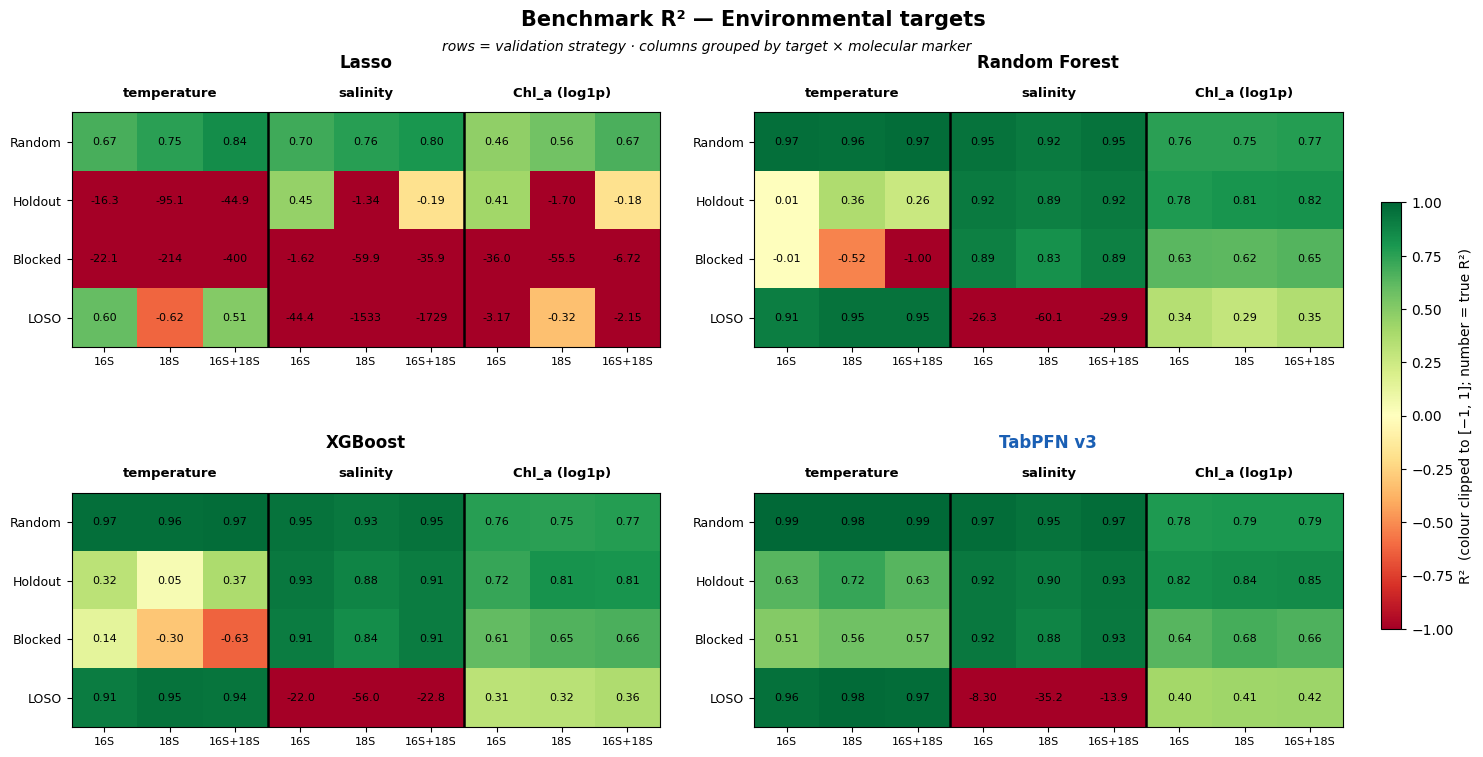

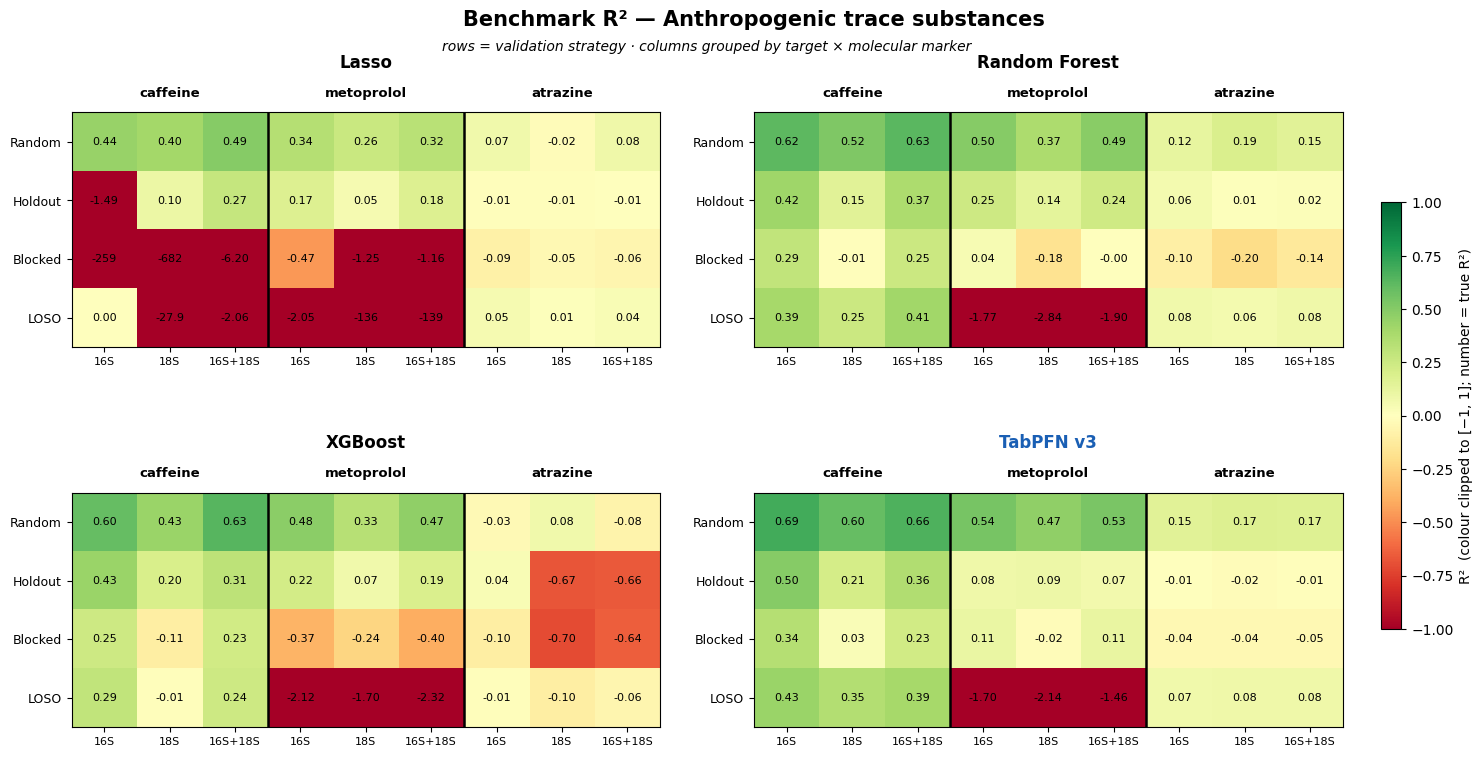

saved → ch6_fig61_r2_heatmap_env / _chem


In [9]:
# ── Figure 6.1 (fixed layout): 2×2 panels, tighter, no title collision ─────
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS = Path('/mnt/data/home/tv2414/tabpfn_project/results')
long = pd.read_csv(RESULTS / 'ch6_full72_long.csv')
MODELS = ['Lasso', 'RF', 'XGBoost', 'TabPFN']
MTITLE = {'Lasso':'Lasso', 'RF':'Random Forest',
          'XGBoost':'XGBoost', 'TabPFN':'TabPFN v3'}
ENV  = ['temperature', 'salinity', 'Chl_a_log1p']
CHEM = ['Caffeine', 'Metoprolol', 'Atrazine']
TDISP = {'temperature':'temperature', 'salinity':'salinity',
         'Chl_a_log1p':'Chl_a (log1p)', 'Caffeine':'caffeine',
         'Metoprolol':'metoprolol', 'Atrazine':'atrazine'}
I_ORDER = ['16S', '18S', '16S+18S']
S_ORDER = ['random_kfold', 'temporal_holdout',
           'temporal_blocked_kfold', 'leave_one_site_out']
S_DISP  = ['Random', 'Holdout', 'Blocked', 'LOSO']

w = long.pivot_table(index=['target','input','strategy'],
                     columns='model', values='r2_mean')[MODELS]

def matrix(model, targets):
    cols = [(t, i) for t in targets for i in I_ORDER]
    return np.array([[w.loc[(t,i,s), model] for (t,i) in cols] for s in S_ORDER]), cols

def afmt(v):
    if abs(v) >= 100: return f'{v:.0f}'
    if abs(v) >= 10:  return f'{v:.1f}'
    return f'{v:.2f}'

for block, targets, tag in [('Environmental targets', ENV, 'env'),
                            ('Anthropogenic trace substances', CHEM, 'chem')]:
    fig, axes = plt.subplots(2, 2, figsize=(15.5, 8.2))
    fig.subplots_adjust(left=0.06, right=0.88, top=0.83, bottom=0.08,
                        hspace=0.62, wspace=0.16)
    cax = fig.add_axes([0.905, 0.20, 0.013, 0.52])

    for k, (ax, mdl) in enumerate(zip(axes.flat, MODELS)):
        M, cols = matrix(mdl, targets)
        im = ax.imshow(np.clip(M, -1, 1), cmap='RdYlGn', vmin=-1, vmax=1,
                       aspect='auto')
        for r in range(M.shape[0]):
            for c in range(M.shape[1]):
                ax.text(c, r, afmt(M[r,c]), ha='center', va='center', fontsize=8)
        ax.set_xticks(range(len(cols)))
        ax.set_xticklabels([i for (_,i) in cols], fontsize=8)
        ax.set_yticks(range(4)); ax.set_yticklabels(S_DISP, fontsize=9)
        ax.set_title(MTITLE[mdl], fontweight='bold', fontsize=12, pad=32,
                     color=('#1a5fb4' if mdl=='TabPFN' else 'black'))
        for x in (2.5, 5.5):
            ax.axvline(x, color='black', lw=1.8)
        for g, t in enumerate(targets):
            ax.text(g*3 + 1, -0.72, TDISP[t], ha='center', va='bottom',
                    fontsize=9.5, fontweight='bold', clip_on=False)
        if k == 0:
            fig.colorbar(im, cax=cax,
                         label='R²  (colour clipped to [−1, 1]; number = true R²)')

    fig.suptitle(f'Benchmark R² — {block}', fontweight='bold', fontsize=15, y=0.955)
    fig.text(0.47, 0.905, 'rows = validation strategy · columns grouped by '
             'target × molecular marker', ha='center', fontsize=10, style='italic')
    for ext in ['png','pdf']:
        fig.savefig(RESULTS / f'ch6_fig61_r2_heatmap_{tag}.{ext}',
                    dpi=300, bbox_inches='tight')
    plt.show()

print('saved → ch6_fig61_r2_heatmap_env / _chem')

In [10]:
# ── Verify Tables 6.5 and 6.6 (ranks and pairwise differences) ─────────────
import pandas as pd
from pathlib import Path

RESULTS = Path('/mnt/data/home/tv2414/tabpfn_project/results')
long = pd.read_csv(RESULTS / 'ch6_full72_long.csv')
MODELS = ['Lasso', 'RF', 'XGBoost', 'TabPFN']
ENV = ['temperature', 'salinity', 'Chl_a_log1p']

w = long.pivot_table(index=['target','input','strategy'],
                     columns='model', values='r2_mean')[MODELS].reset_index()
w['block'] = w['target'].apply(lambda t: 'environmental' if t in ENV else 'chemical')

# ranks: 1 = best R2 in that cell
ranks = w[MODELS].rank(axis=1, ascending=False)
ranks['block'] = w['block']

print('=== Table 6.5: mean R² rank ===')
out = pd.DataFrame({
    'environmental': ranks[ranks.block=='environmental'][MODELS].mean(),
    'chemical'     : ranks[ranks.block=='chemical'][MODELS].mean(),
    'all_72'       : ranks[MODELS].mean(),
})
print(out.round(3).to_string())

print('\n=== Table 6.6: pairwise TabPFN vs each baseline (all 72) ===')
for b in ['Lasso', 'RF', 'XGBoost']:
    d = w['TabPFN'] - w[b]
    print(f'  vs {b:8s}: mean {d.mean():+10.4f} · median {d.median():+.4f} · '
          f'TabPFN higher in {(d>0).sum():2d}/72')

print('\n=== same, split by block ===')
for blk in ['environmental', 'chemical']:
    g = w[w.block == blk]
    print(f'  -- {blk} --')
    for b in ['Lasso', 'RF', 'XGBoost']:
        d = g['TabPFN'] - g[b]
        print(f'     vs {b:8s}: mean {d.mean():+10.4f} · median {d.median():+.4f} · '
              f'higher in {(d>0).sum():2d}/36')

=== Table 6.5: mean R² rank ===
         environmental  chemical  all_72
model                                   
Lasso            4.000     3.500   3.750
RF               2.750     1.889   2.319
XGBoost          2.194     3.083   2.639
TabPFN           1.056     1.528   1.292

=== Table 6.6: pairwise TabPFN vs each baseline (all 72) ===
  vs Lasso   : mean   +76.6960 · median +0.4475 · TabPFN higher in 68/72
  vs RF      : mean    +0.9232 · median +0.0381 · TabPFN higher in 61/72
  vs XGBoost : mean    +0.7612 · median +0.0683 · TabPFN higher in 66/72

=== same, split by block ===
  -- environmental --
     vs Lasso   : mean  +118.4692 · median +2.3925 · higher in 36/36
     vs RF      : mean    +1.7895 · median +0.0367 · higher in 36/36
     vs XGBoost : mean    +1.3321 · median +0.0326 · higher in 34/36
  -- chemical --
     vs Lasso   : mean   +34.9227 · median +0.1958 · higher in 32/36
     vs RF      : mean    +0.0569 · median +0.0416 · higher in 25/36
     vs XGBoost : mean    +

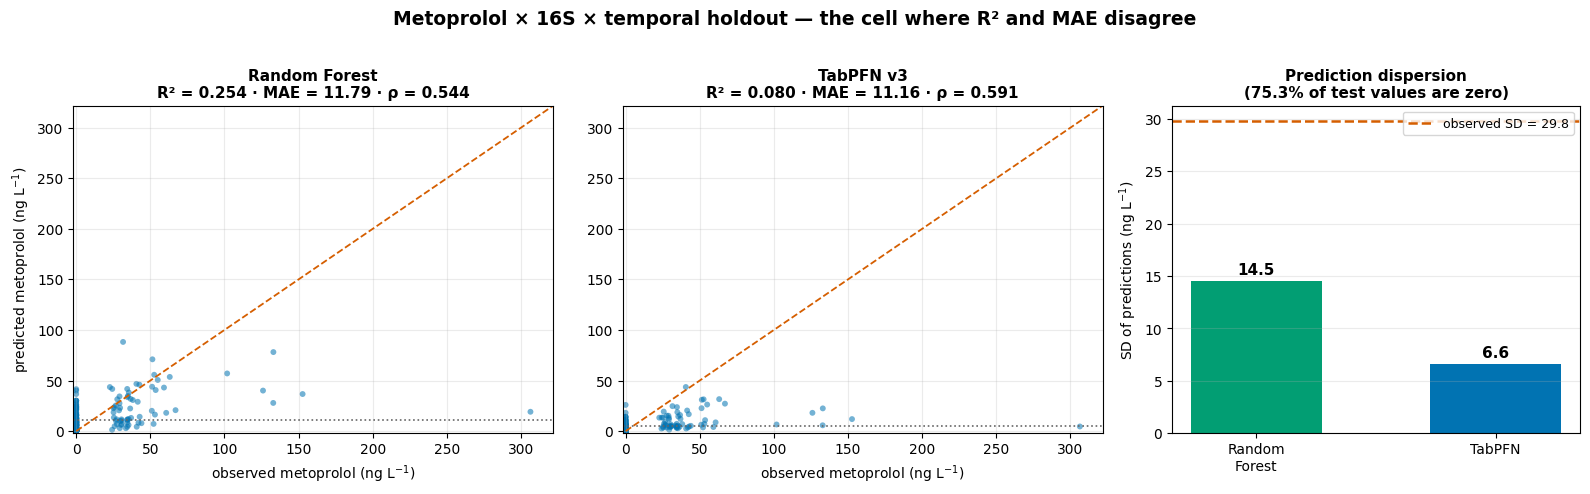

predicted SD  : {'RF': np.float64(14.55), 'TabPFN': np.float64(6.63)}
observed SD   : 29.78
zeros in test : 75.3%
saved → ch6_fig67_censoring_metric_conflict


In [11]:
# ── Figure 6.7: why R² and MAE disagree on censored targets ────────────────
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS = Path('/mnt/data/home/tv2414/tabpfn_project/results')
pr = pd.read_csv(RESULTS / 'ch6_lost_cells_probe.csv')

d = pr[(pr.target == 'Metoprolol') & (pr.strategy == 'temporal_holdout')]
MODELS = ['RF', 'TabPFN']
TITLE  = {'RF': 'Random Forest', 'TabPFN': 'TabPFN v3'}
STATS  = {'RF':     dict(r2=0.2538, mae=11.786, rho=0.5439),
          'TabPFN': dict(r2=0.0803, mae=11.157, rho=0.5914)}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8),
                         gridspec_kw={'width_ratios': [1, 1, 0.85]})

# --- panels A & B: predicted vs observed ---
hi = max(d.y_true.max(), d.y_pred.max()) * 1.05
for ax, m in zip(axes[:2], MODELS):
    s = d[d.model == m]
    st = STATS[m]
    ax.scatter(s.y_true, s.y_pred, s=18, alpha=.55,
               color='#0173B2', edgecolors='none')
    ax.plot([0, hi], [0, hi], '--', color='#D55E00', lw=1.3)
    ax.axhline(s.y_pred.mean(), color='#666666', ls=':', lw=1.2)
    ax.set_xlim(-2, hi); ax.set_ylim(-2, hi)
    ax.set_xlabel('observed metoprolol (ng L$^{-1}$)')
    ax.set_title(f'{TITLE[m]}\n'
                 f'R² = {st["r2"]:.3f} · MAE = {st["mae"]:.2f} · ρ = {st["rho"]:.3f}',
                 fontweight='bold', fontsize=11)
    ax.grid(alpha=.25)
axes[0].set_ylabel('predicted metoprolol (ng L$^{-1}$)')

# --- panel C: dispersion comparison ---
ax = axes[2]
sds = [d[d.model == m].y_pred.std() for m in MODELS]
y_sd = d[d.model == 'RF'].y_true.std()
bars = ax.bar(['Random\nForest', 'TabPFN'], sds,
              color=['#029E73', '#0173B2'], width=.55)
ax.axhline(y_sd, color='#D55E00', ls='--', lw=1.8,
           label=f'observed SD = {y_sd:.1f}')
for b, v in zip(bars, sds):
    ax.text(b.get_x() + b.get_width()/2, v + .6, f'{v:.1f}',
            ha='center', fontweight='bold', fontsize=11)
ax.set_ylabel('SD of predictions (ng L$^{-1}$)')
ax.set_title('Prediction dispersion\n(75.3% of test values are zero)',
             fontweight='bold', fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=.25, axis='y')

fig.suptitle('Metoprolol × 16S × temporal holdout — the cell where R² and MAE disagree',
             fontweight='bold', fontsize=13.5, y=1.02)
fig.tight_layout()
for ext in ['png', 'pdf']:
    fig.savefig(RESULTS / f'ch6_fig67_censoring_metric_conflict.{ext}',
                dpi=300, bbox_inches='tight')
plt.show()

print('predicted SD  :', {m: round(d[d.model==m].y_pred.std(), 2) for m in MODELS})
print('observed SD   :', round(y_sd, 2))
print('zeros in test :', f'{100*(d[d.model=="RF"].y_true==0).mean():.1f}%')
print('saved → ch6_fig67_censoring_metric_conflict')

Building Chapter 6 figures...
  ✓ fig6_1a_r2_heatmap.pdf


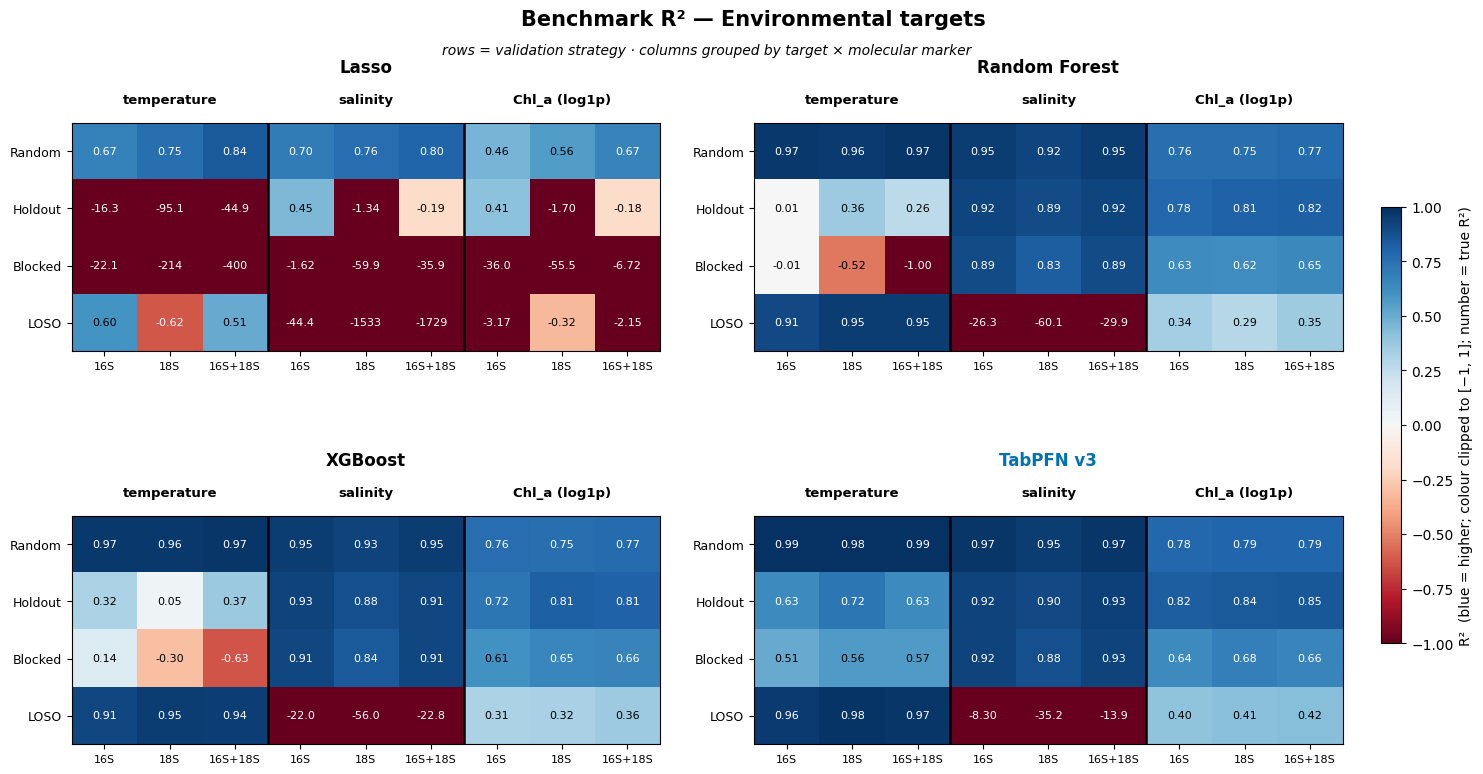

  ✓ fig6_1b_r2_heatmap.pdf


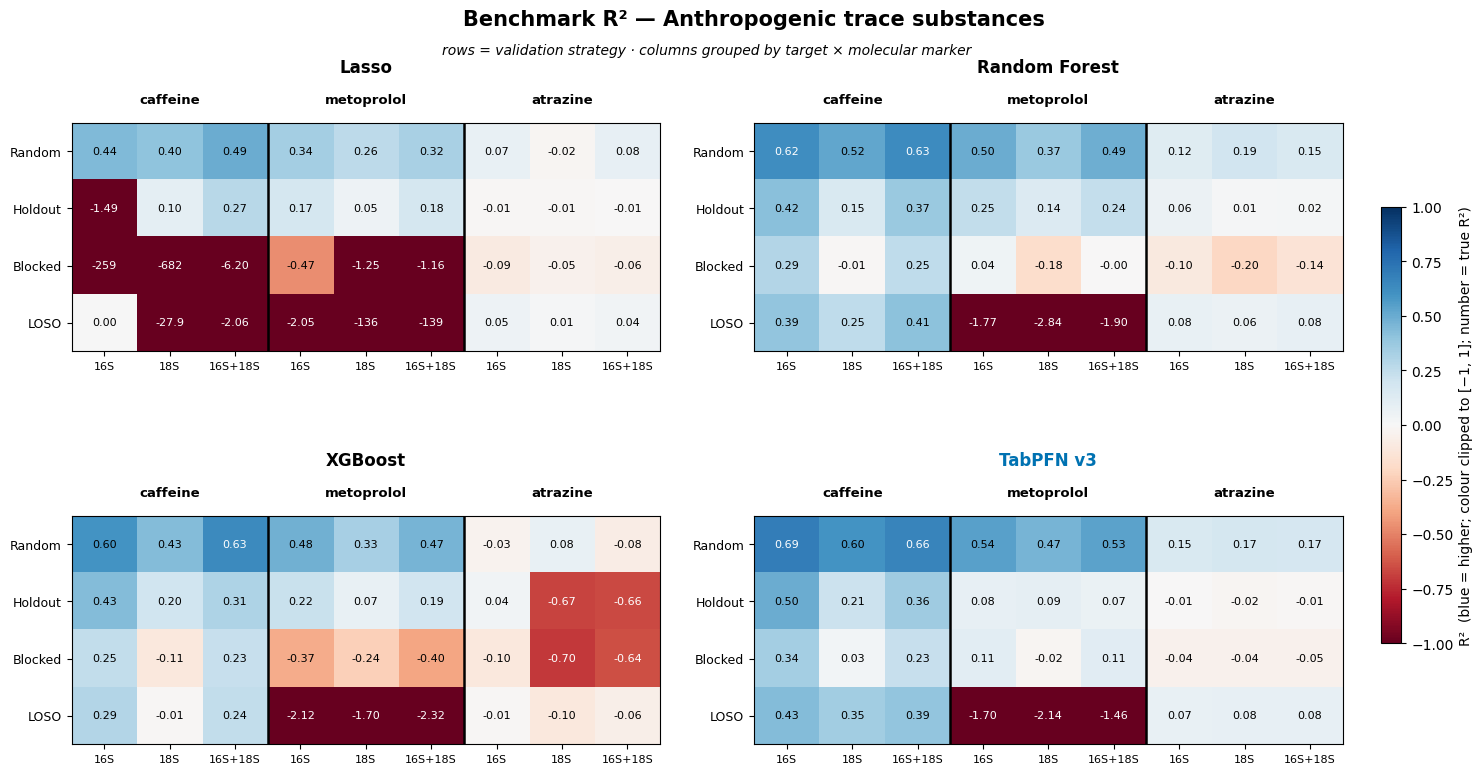

  ✓ fig6_2_winner_grid_72.pdf


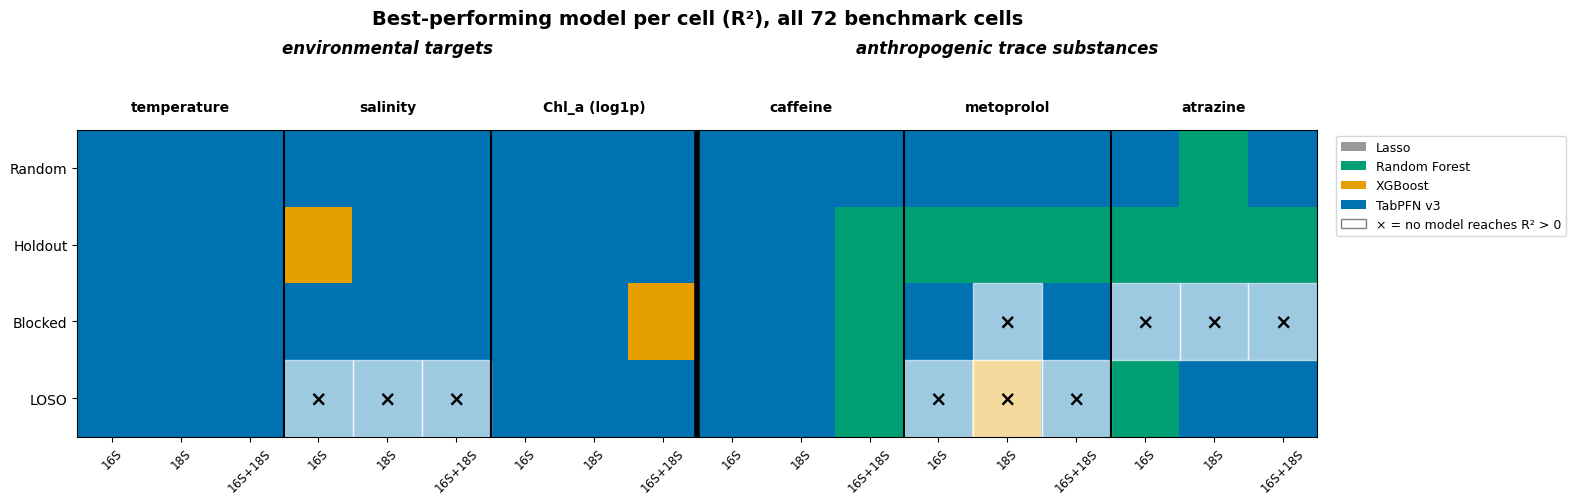

  ✓ fig6_5_pred_vs_true_temperature.pdf


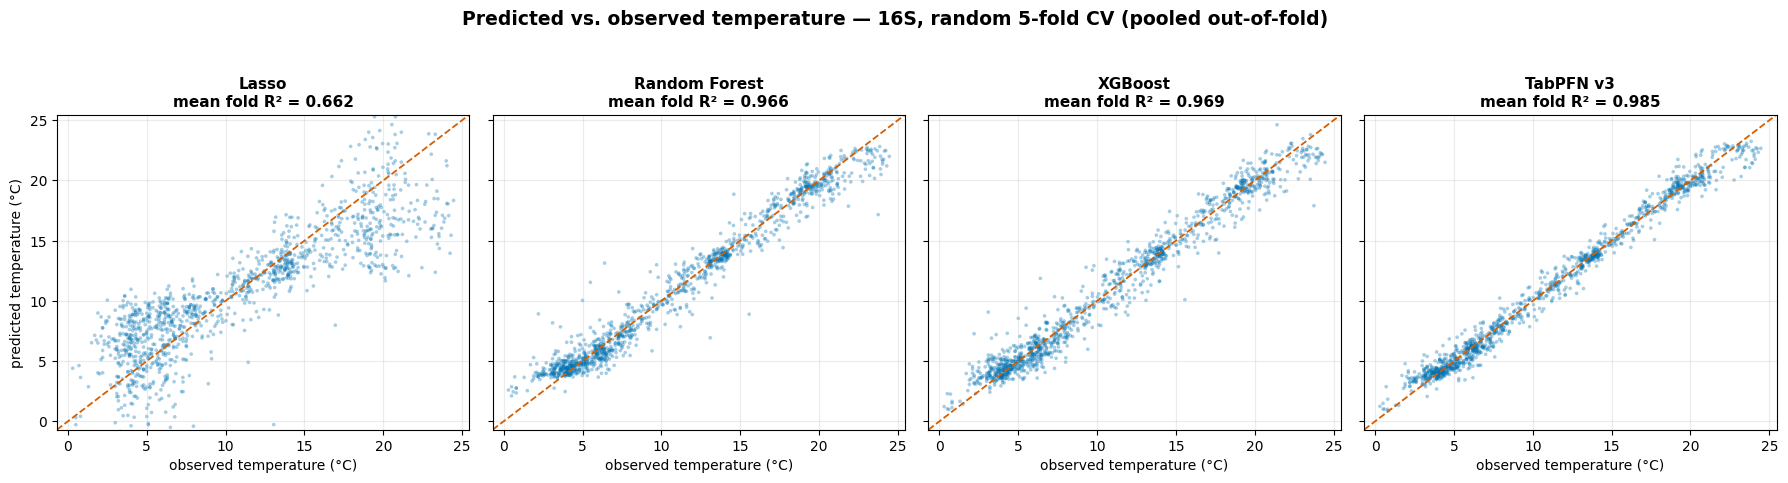

  ✓ fig6_6_pred_vs_true_salinity_muehlendamm.pdf


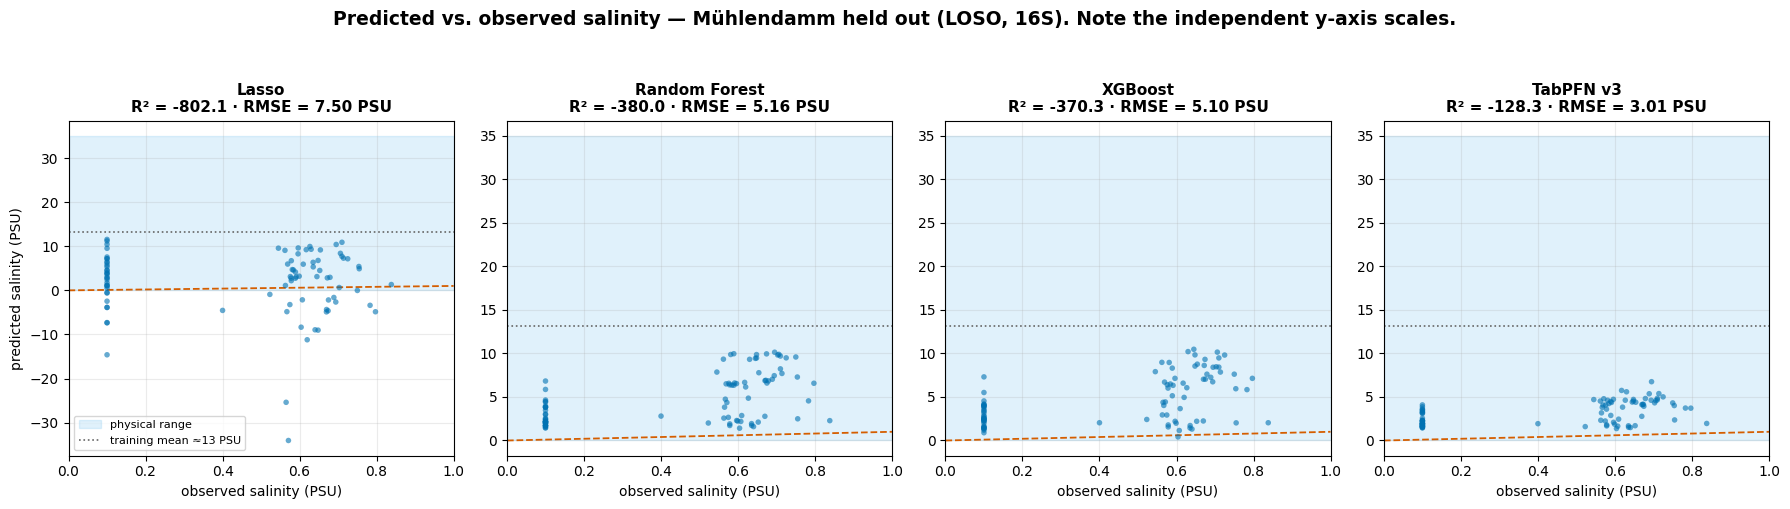

  ✓ fig6_7_censoring_metric_conflict.pdf


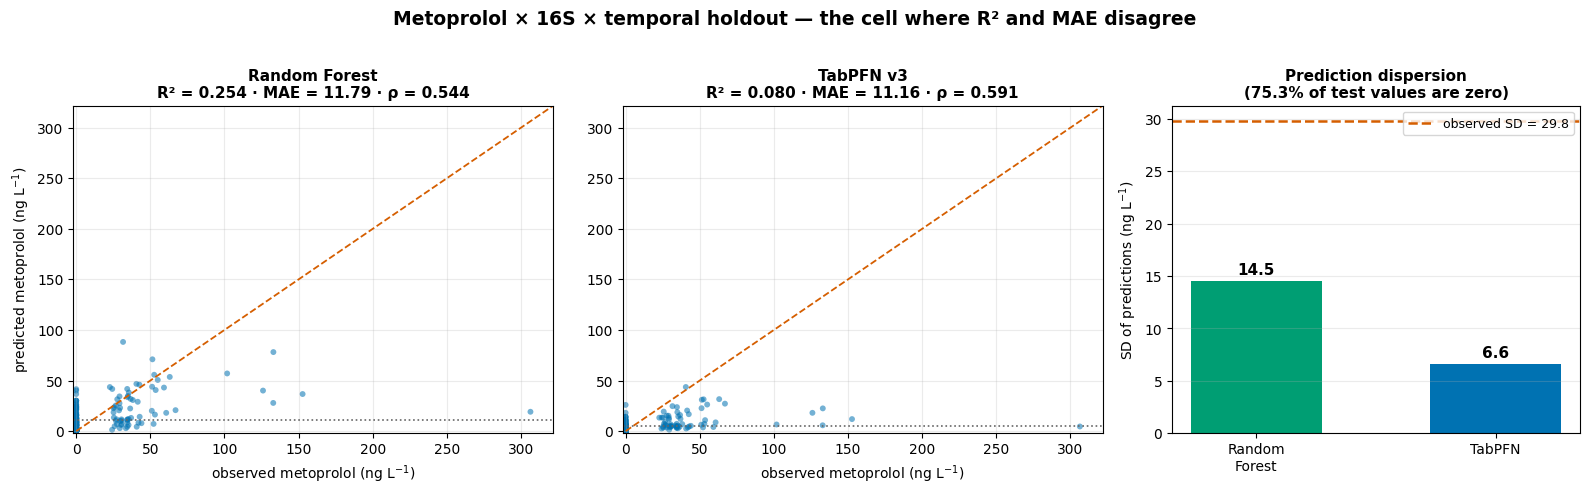


All Chapter 6 figures written to /mnt/data/home/tv2414/tabpfn_project/results/ch6_figures
   fig6_1a_r2_heatmap.pdf
   fig6_1b_r2_heatmap.pdf
   fig6_2_winner_grid_72.pdf
   fig6_5_pred_vs_true_temperature.pdf
   fig6_6_pred_vs_true_salinity_muehlendamm.pdf
   fig6_7_censoring_metric_conflict.pdf


In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# CHAPTER 6 — all figures, final version
#   · colourblind-safe (RdBu diverging + Okabe-Ito categorical)
#   · file names matched to figure numbers in the text
#   · self-contained: reads only from disk
# ═══════════════════════════════════════════════════════════════════════════
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from pathlib import Path

RESULTS = Path('/mnt/data/home/tv2414/tabpfn_project/results')
FIGS    = RESULTS / 'ch6_figures'
FIGS.mkdir(exist_ok=True)

MODELS = ['Lasso', 'RF', 'XGBoost', 'TabPFN']
MTITLE = {'Lasso':'Lasso', 'RF':'Random Forest',
          'XGBoost':'XGBoost', 'TabPFN':'TabPFN v3'}
ENV  = ['temperature', 'salinity', 'Chl_a_log1p']
CHEM = ['Caffeine', 'Metoprolol', 'Atrazine']
TDISP = {'temperature':'temperature', 'salinity':'salinity',
         'Chl_a_log1p':'Chl_a (log1p)', 'Caffeine':'caffeine',
         'Metoprolol':'metoprolol', 'Atrazine':'atrazine'}
I_ORDER = ['16S', '18S', '16S+18S']
S_ORDER = ['random_kfold', 'temporal_holdout',
           'temporal_blocked_kfold', 'leave_one_site_out']
S_DISP  = ['Random', 'Holdout', 'Blocked', 'LOSO']
OKABE   = {'grey':'#999999', 'green':'#009E73', 'orange':'#E69F00',
           'blue':'#0072B2', 'vermillion':'#D55E00', 'skyblue':'#56B4E9'}

def save(fig, name):
    for ext in ('png', 'pdf'):
        fig.savefig(FIGS / f'{name}.{ext}', dpi=300, bbox_inches='tight')
    print(f'  ✓ {name}.pdf')

def afmt(v):
    if abs(v) >= 100: return f'{v:.0f}'
    if abs(v) >= 10:  return f'{v:.1f}'
    return f'{v:.2f}'

long = pd.read_csv(RESULTS / 'ch6_full72_long.csv')
w = long.pivot_table(index=['target','input','strategy'],
                     columns='model', values='r2_mean')[MODELS]

def matrix(model, targets):
    cols = [(t, i) for t in targets for i in I_ORDER]
    return np.array([[w.loc[(t,i,s), model] for (t,i) in cols] for s in S_ORDER]), cols

print('Building Chapter 6 figures...')

# ═══ FIG 6.1a / 6.1b — R² heatmaps ═════════════════════════════════════════
for block, targets, num in [('Environmental targets', ENV, '6_1a'),
                            ('Anthropogenic trace substances', CHEM, '6_1b')]:
    fig, axes = plt.subplots(2, 2, figsize=(15.5, 8.4))
    fig.subplots_adjust(left=.06, right=.88, top=.82, bottom=.08,
                        hspace=.72, wspace=.16)
    cax = fig.add_axes([.905, .20, .013, .52])
    for k, (ax, mdl) in enumerate(zip(axes.flat, MODELS)):
        M, cols = matrix(mdl, targets)
        Mc = np.clip(M, -1, 1)
        im = ax.imshow(Mc, cmap='RdBu', vmin=-1, vmax=1, aspect='auto')
        for r in range(M.shape[0]):
            for c in range(M.shape[1]):
                ax.text(c, r, afmt(M[r, c]), ha='center', va='center', fontsize=8,
                        color='white' if abs(Mc[r, c]) > .62 else 'black')
        ax.set_xticks(range(len(cols)))
        ax.set_xticklabels([i for (_, i) in cols], fontsize=8)
        ax.set_yticks(range(4)); ax.set_yticklabels(S_DISP, fontsize=9)
        ax.set_title(MTITLE[mdl], fontweight='bold', fontsize=12, pad=36,
                     color=(OKABE['blue'] if mdl == 'TabPFN' else 'black'))
        for x in (2.5, 5.5):
            ax.axvline(x, color='black', lw=1.8)
        for g, t in enumerate(targets):
            ax.text(g*3 + 1, -.78, TDISP[t], ha='center', va='bottom',
                    fontsize=9.5, fontweight='bold', clip_on=False)
        if k == 0:
            fig.colorbar(im, cax=cax, label='R²  (blue = higher; colour clipped '
                                            'to [−1, 1]; number = true R²)')
    fig.suptitle(f'Benchmark R² — {block}', fontweight='bold', fontsize=15, y=.955)
    fig.text(.47, .902, 'rows = validation strategy · columns grouped by '
             'target × molecular marker', ha='center', fontsize=10, style='italic')
    save(fig, f'fig{num}_r2_heatmap')
    plt.show()

# ═══ FIG 6.2 — winner grid, all 72 cells ═══════════════════════════════════
w2 = w.copy(); w2['winner'] = w2.idxmax(axis=1); w2['best'] = w2[MODELS].max(axis=1)
ALL_T = ENV + CHEM
cols = [(t, i) for t in ALL_T for i in I_ORDER]
CODE = {'Lasso':0, 'RF':1, 'XGBoost':2, 'TabPFN':3}
W   = np.array([[CODE[w2.loc[(t,i,s),'winner']] for (t,i) in cols] for s in S_ORDER])
DEG = np.array([[w2.loc[(t,i,s),'best'] < 0     for (t,i) in cols] for s in S_ORDER])

cmap = ListedColormap([OKABE['grey'], OKABE['green'], OKABE['orange'], OKABE['blue']])
fig, ax = plt.subplots(figsize=(16, 5.2))
fig.subplots_adjust(top=.70)
ax.imshow(W, cmap=cmap, norm=BoundaryNorm([-.5,.5,1.5,2.5,3.5], 4), aspect='auto')
for r in range(W.shape[0]):
    for c in range(W.shape[1]):
        if DEG[r, c]:
            ax.add_patch(plt.Rectangle((c-.5, r-.5), 1, 1, color='white',
                                       alpha=.62, zorder=2))
            ax.text(c, r, '×', ha='center', va='center', fontsize=15,
                    fontweight='bold', zorder=3)
ax.set_xticks(range(len(cols)))
ax.set_xticklabels([i for (_, i) in cols], fontsize=8.5, rotation=45)
ax.set_yticks(range(4)); ax.set_yticklabels(S_DISP, fontsize=10)
for x in (2.5, 5.5, 11.5, 14.5):          # 8.5 excluded — drawn thick below
    ax.axvline(x, color='black', lw=1.5)
ax.axvline(8.5, color='black', lw=4)
for g, t in enumerate(ALL_T):
    ax.text(g*3 + 1, -.70, TDISP[t], ha='center', va='bottom',
            fontsize=10, fontweight='bold', clip_on=False)
ax.text(4,  -1.50, 'environmental targets', ha='center', fontsize=12,
        fontweight='bold', style='italic', clip_on=False)
ax.text(13, -1.50, 'anthropogenic trace substances', ha='center', fontsize=12,
        fontweight='bold', style='italic', clip_on=False)
handles = [Patch(facecolor=cmap(i), label=MTITLE[m]) for m, i in CODE.items()]
handles.append(Patch(facecolor='white', edgecolor='grey',
                     label='× = no model reaches R² > 0'))
ax.legend(handles=handles, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.set_title('Best-performing model per cell (R²), all 72 benchmark cells',
             fontweight='bold', fontsize=14, pad=76)
save(fig, 'fig6_2_winner_grid_72')
plt.show()

# ═══ FIG 6.5 — predicted vs observed, temperature × 16S × random ═══════════
pf = pd.read_csv(RESULTS / 'ch6_perfold_metrics.csv')
pr = pd.read_csv(RESULTS / 'ch6_predictions.csv')
ORDER = ['Lasso', 'RF', 'XGBoost', 'TabPFN']

d = pr[(pr.target == 'temperature') & (pr.strategy == 'random_kfold')]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.6), sharex=True, sharey=True)
lo, hi = d.y_true.min() - 1, d.y_true.max() + 1
for ax, m in zip(axes, ORDER):
    s = d[d.model == m]
    r2 = pf[(pf.target == 'temperature') & (pf.strategy == 'random_kfold')
            & (pf.model == m)]['r2'].mean()
    ax.scatter(s.y_true, s.y_pred, s=7, alpha=.35,
               color=OKABE['blue'], edgecolors='none')
    ax.plot([lo, hi], [lo, hi], '--', color=OKABE['vermillion'], lw=1.3)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_title(f'{MTITLE[m]}\nmean fold R² = {r2:.3f}',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('observed temperature (°C)')
    ax.grid(alpha=.25)
axes[0].set_ylabel('predicted temperature (°C)')
fig.suptitle('Predicted vs. observed temperature — 16S, random 5-fold CV '
             '(pooled out-of-fold)', fontweight='bold', fontsize=13.5, y=1.04)
fig.tight_layout()
save(fig, 'fig6_5_pred_vs_true_temperature')
plt.show()

# ═══ FIG 6.6 — predicted vs observed, Mühlendamm LOSO fold ════════════════
d = pr[(pr.target == 'salinity') & (pr.strategy == 'leave_one_site_out') &
       (pr.site.str.contains('uehlendamm', case=False, na=False))]
fig, axes = plt.subplots(1, 4, figsize=(18, 4.8))
for ax, m in zip(axes, ORDER):
    s = d[d.model == m]
    row = pf[(pf.target == 'salinity') & (pf.strategy == 'leave_one_site_out') &
             (pf.model == m) &
             (pf.site.str.contains('uehlendamm', case=False, na=False))].iloc[0]
    ax.axhspan(0, 35, color=OKABE['skyblue'], alpha=.18, zorder=0,
               label='physical range')
    ax.axhline(13.2, color='#666666', ls=':', lw=1.2, zorder=1,
               label='training mean ≈13 PSU')
    ax.scatter(s.y_true, s.y_pred, s=16, alpha=.6,
               color=OKABE['blue'], edgecolors='none', zorder=3)
    ax.plot([0, 1], [0, 1], '--', color=OKABE['vermillion'], lw=1.3, zorder=2)
    ax.set_xlim(0, 1)
    ax.set_title(f'{MTITLE[m]}\nR² = {row.r2:.1f} · RMSE = {row.rmse:.2f} PSU',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('observed salinity (PSU)')
    ax.grid(alpha=.25)
axes[0].set_ylabel('predicted salinity (PSU)')
axes[0].legend(fontsize=8, loc='lower left')
fig.suptitle('Predicted vs. observed salinity — Mühlendamm held out (LOSO, 16S). '
             'Note the independent y-axis scales.',
             fontweight='bold', fontsize=13.5, y=1.05)
fig.tight_layout()
save(fig, 'fig6_6_pred_vs_true_salinity_muehlendamm')
plt.show()

# ═══ FIG 6.7 — metric conflict on a censored target ═══════════════════════
probe = pd.read_csv(RESULTS / 'ch6_lost_cells_probe.csv')
d = probe[(probe.target == 'Metoprolol') & (probe.strategy == 'temporal_holdout')]
PAIR  = ['RF', 'TabPFN']
STATS = {'RF':     dict(r2=0.2538, mae=11.786, rho=0.5439),
         'TabPFN': dict(r2=0.0803, mae=11.157, rho=0.5914)}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8),
                         gridspec_kw={'width_ratios': [1, 1, .85]})
hi = max(d.y_true.max(), d.y_pred.max()) * 1.05
for ax, m in zip(axes[:2], PAIR):
    s, st = d[d.model == m], STATS[m]
    ax.scatter(s.y_true, s.y_pred, s=18, alpha=.55,
               color=OKABE['blue'], edgecolors='none')
    ax.plot([0, hi], [0, hi], '--', color=OKABE['vermillion'], lw=1.3)
    ax.axhline(s.y_pred.mean(), color='#666666', ls=':', lw=1.2)
    ax.set_xlim(-2, hi); ax.set_ylim(-2, hi)
    ax.set_xlabel('observed metoprolol (ng L$^{-1}$)')
    ax.set_title(f'{MTITLE[m]}\nR² = {st["r2"]:.3f} · MAE = {st["mae"]:.2f} · '
                 f'ρ = {st["rho"]:.3f}', fontweight='bold', fontsize=11)
    ax.grid(alpha=.25)
axes[0].set_ylabel('predicted metoprolol (ng L$^{-1}$)')

ax = axes[2]
sds  = [d[d.model == m].y_pred.std() for m in PAIR]
y_sd = d[d.model == 'RF'].y_true.std()
bars = ax.bar(['Random\nForest', 'TabPFN'], sds,
              color=[OKABE['green'], OKABE['blue']], width=.55)
ax.axhline(y_sd, color=OKABE['vermillion'], ls='--', lw=1.8,
           label=f'observed SD = {y_sd:.1f}')
for b, v in zip(bars, sds):
    ax.text(b.get_x() + b.get_width()/2, v + .6, f'{v:.1f}',
            ha='center', fontweight='bold', fontsize=11)
ax.set_ylabel('SD of predictions (ng L$^{-1}$)')
ax.set_title('Prediction dispersion\n(75.3% of test values are zero)',
             fontweight='bold', fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=.25, axis='y')
fig.suptitle('Metoprolol × 16S × temporal holdout — the cell where R² and MAE '
             'disagree', fontweight='bold', fontsize=13.5, y=1.02)
fig.tight_layout()
save(fig, 'fig6_7_censoring_metric_conflict')
plt.show()

print(f'\nAll Chapter 6 figures written to {FIGS}')
for f in sorted(FIGS.glob('*.pdf')):
    print('  ', f.name)

locked R² used for the panel labels:
model
Lasso      0.6746
RF         0.9662
XGBoost    0.9687
TabPFN     0.9852


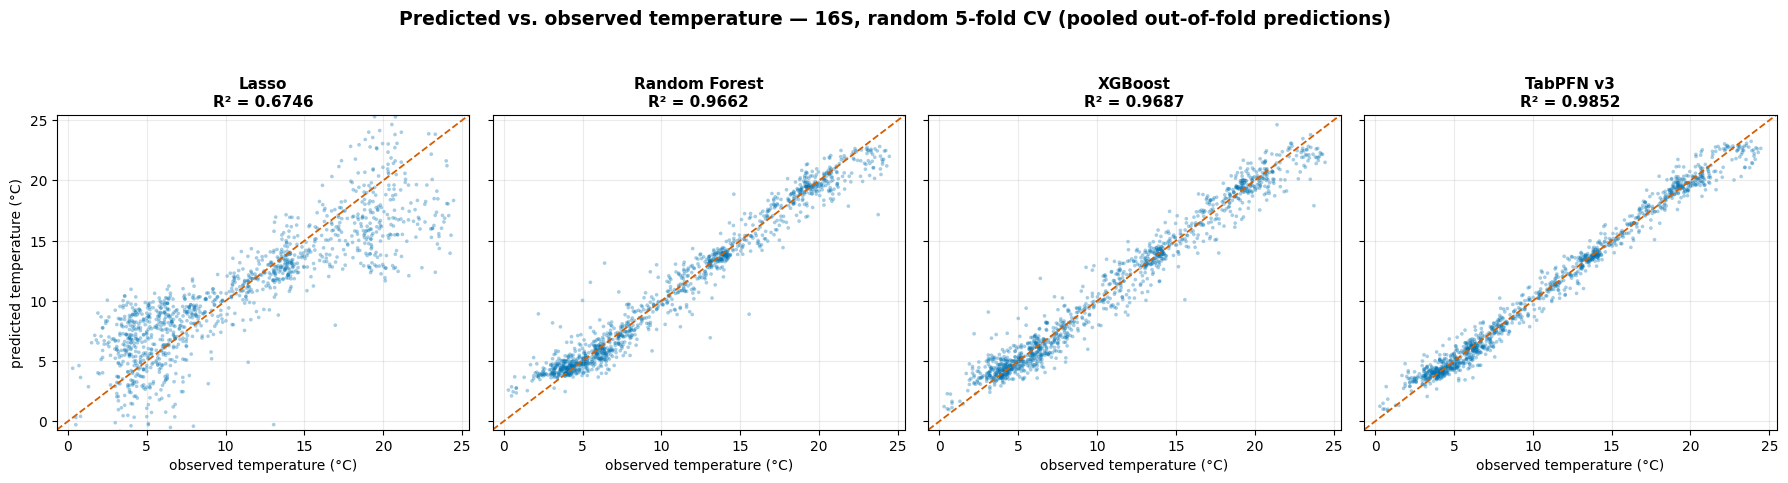


saved → /mnt/data/home/tv2414/tabpfn_project/results/ch6_figures/fig6_2_pred_vs_true_temperature.pdf


In [5]:
# ── Figure 6.2: temperature × 16S × random — R² labels from the LOCKED table ──
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS = Path('/mnt/data/home/tv2414/tabpfn_project/results')
FIGS = RESULTS / 'ch6_figures'; FIGS.mkdir(exist_ok=True)

OKABE = {'blue':'#0072B2', 'vermillion':'#D55E00'}
ORDER  = ['Lasso', 'RF', 'XGBoost', 'TabPFN']
MTITLE = {'Lasso':'Lasso', 'RF':'Random Forest',
          'XGBoost':'XGBoost', 'TabPFN':'TabPFN v3'}

# --- locked benchmark R² (the values reported in Chapter 6 / Appendix A) ---
long = pd.read_csv(RESULTS / 'ch6_full72_long.csv')
locked = long[(long.target == 'temperature') & (long.input == '16S') &
              (long.strategy == 'random_kfold')].set_index('model')['r2_mean']
print('locked R² used for the panel labels:')
print(locked.round(4).to_string())

# --- predictions come from the saved diagnostic rerun ---
pr = pd.read_csv(RESULTS / 'ch6_predictions.csv')
d = pr[(pr.target == 'temperature') & (pr.strategy == 'random_kfold')]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.6), sharex=True, sharey=True)
lo, hi = d.y_true.min() - 1, d.y_true.max() + 1
for ax, m in zip(axes, ORDER):
    s = d[d.model == m]
    ax.scatter(s.y_true, s.y_pred, s=7, alpha=.35,
               color=OKABE['blue'], edgecolors='none')
    ax.plot([lo, hi], [lo, hi], '--', color=OKABE['vermillion'], lw=1.3)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_title(f'{MTITLE[m]}\nR² = {locked[m]:.4f}',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('observed temperature (°C)')
    ax.grid(alpha=.25)
axes[0].set_ylabel('predicted temperature (°C)')
fig.suptitle('Predicted vs. observed temperature — 16S, random 5-fold CV '
             '(pooled out-of-fold predictions)',
             fontweight='bold', fontsize=13.5, y=1.04)
fig.tight_layout()
for ext in ('png', 'pdf'):
    fig.savefig(FIGS / f'fig6_2_pred_vs_true_temperature.{ext}',
                dpi=300, bbox_inches='tight')
plt.show()
print(f'\nsaved → {FIGS}/fig6_2_pred_vs_true_temperature.pdf')

locked values for this cell:
             R2      MAE
model                   
Lasso    0.1746  16.4150
RF       0.2478  11.6079
XGBoost  0.2218  11.4694
TabPFN   0.0803  11.1570

diagnostic run — Spearman ρ and MAE:
  RF      ρ = 0.5439   MAE(run) = 11.786   MAE(locked) = 11.608
  TabPFN  ρ = 0.5914   MAE(run) = 11.157   MAE(locked) = 11.157


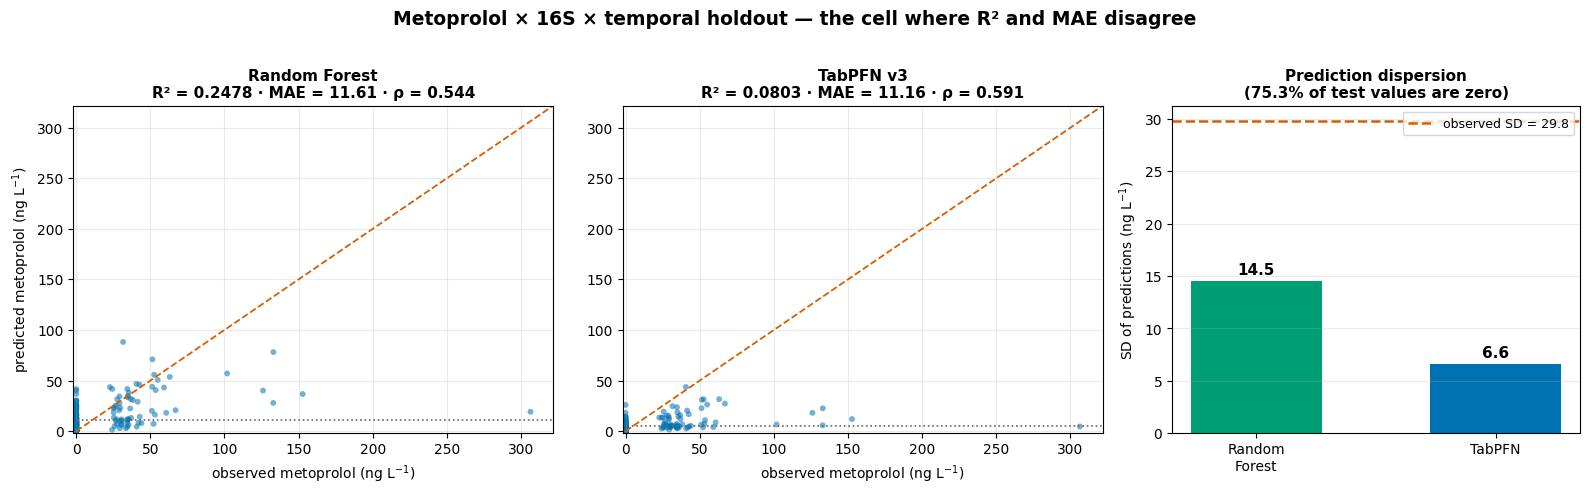


observed SD = 29.78 · zeros = 75.3%
prediction SD: RF 14.5, TabPFN 6.6
saved → /mnt/data/home/tv2414/tabpfn_project/results/ch6_figures/fig6_4_censoring_metric_conflict.pdf


In [6]:
# ── Figure 6.4: metoprolol × 16S × holdout — locked R², diagnostic MAE/ρ ─────
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error

RESULTS = Path('/mnt/data/home/tv2414/tabpfn_project/results')
FIGS = RESULTS / 'ch6_figures'; FIGS.mkdir(exist_ok=True)

OKABE = {'blue':'#0072B2', 'green':'#009E73', 'vermillion':'#D55E00'}
PAIR   = ['RF', 'TabPFN']
MTITLE = {'RF':'Random Forest', 'TabPFN':'TabPFN v3'}

# --- locked benchmark values (as reported in Chapter 6 and Appendix A) ---
long = pd.read_csv(RESULTS / 'ch6_full72_long.csv')
cell = long[(long.target == 'Metoprolol') & (long.input == '16S') &
            (long.strategy == 'temporal_holdout')].set_index('model')
locked_r2  = cell['r2_mean']
locked_mae = cell['mae_mean']
print('locked values for this cell:')
print(pd.concat([locked_r2.rename('R2'), locked_mae.rename('MAE')],
                axis=1).round(4).to_string())

# --- predictions from the saved diagnostic run (needed for ρ and dispersion) ---
probe = pd.read_csv(RESULTS / 'ch6_lost_cells_probe.csv')
d = probe[(probe.target == 'Metoprolol') & (probe.strategy == 'temporal_holdout')]

rho, mae_run, r2_run = {}, {}, {}
for m in PAIR:
    s = d[d.model == m]
    rho[m]     = spearmanr(s.y_true, s.y_pred).statistic
    mae_run[m] = mean_absolute_error(s.y_true, s.y_pred)
print('\ndiagnostic run — Spearman ρ and MAE:')
for m in PAIR:
    print(f'  {m:7s} ρ = {rho[m]:.4f}   MAE(run) = {mae_run[m]:.3f}   '
          f'MAE(locked) = {locked_mae[m]:.3f}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8),
                         gridspec_kw={'width_ratios': [1, 1, .85]})
hi = max(d.y_true.max(), d.y_pred.max()) * 1.05

for ax, m in zip(axes[:2], PAIR):
    s = d[d.model == m]
    ax.scatter(s.y_true, s.y_pred, s=18, alpha=.55,
               color=OKABE['blue'], edgecolors='none')
    ax.plot([0, hi], [0, hi], '--', color=OKABE['vermillion'], lw=1.3)
    ax.axhline(s.y_pred.mean(), color='#666666', ls=':', lw=1.2)
    ax.set_xlim(-2, hi); ax.set_ylim(-2, hi)
    ax.set_xlabel('observed metoprolol (ng L$^{-1}$)')
    ax.set_title(f'{MTITLE[m]}\n'
                 f'R² = {locked_r2[m]:.4f} · MAE = {locked_mae[m]:.2f} · '
                 f'ρ = {rho[m]:.3f}', fontweight='bold', fontsize=11)
    ax.grid(alpha=.25)
axes[0].set_ylabel('predicted metoprolol (ng L$^{-1}$)')

# --- dispersion panel ---
ax = axes[2]
sds  = [d[d.model == m].y_pred.std() for m in PAIR]
y_sd = d[d.model == 'RF'].y_true.std()
zero = 100 * (d[d.model == 'RF'].y_true == 0).mean()
bars = ax.bar(['Random\nForest', 'TabPFN'], sds,
              color=[OKABE['green'], OKABE['blue']], width=.55)
ax.axhline(y_sd, color=OKABE['vermillion'], ls='--', lw=1.8,
           label=f'observed SD = {y_sd:.1f}')
for b, v in zip(bars, sds):
    ax.text(b.get_x() + b.get_width()/2, v + .6, f'{v:.1f}',
            ha='center', fontweight='bold', fontsize=11)
ax.set_ylabel('SD of predictions (ng L$^{-1}$)')
ax.set_title(f'Prediction dispersion\n({zero:.1f}% of test values are zero)',
             fontweight='bold', fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=.25, axis='y')

fig.suptitle('Metoprolol × 16S × temporal holdout — the cell where R² and MAE '
             'disagree', fontweight='bold', fontsize=13.5, y=1.02)
fig.tight_layout()
for ext in ('png', 'pdf'):
    fig.savefig(FIGS / f'fig6_4_censoring_metric_conflict.{ext}',
                dpi=300, bbox_inches='tight')
plt.show()

print(f'\nobserved SD = {y_sd:.2f} · zeros = {zero:.1f}%')
print(f'prediction SD: ' + ', '.join(f'{m} {s:.1f}' for m, s in zip(PAIR, sds)))
print(f'saved → {FIGS}/fig6_4_censoring_metric_conflict.pdf')

In [5]:
# ── Compact comparison table: all 6 targets, all 4 models, one view ────────
import pandas as pd
from pathlib import Path

RESULTS = Path('/mnt/data/home/tv2414/tabpfn_project/results')
long = pd.read_csv(RESULTS / 'ch6_full72_long.csv')
MODELS = ['Lasso', 'RF', 'XGBoost', 'TabPFN']

T_ORDER = ['temperature','salinity','Chl_a_log1p','Caffeine','Metoprolol','Atrazine']
T_DISP  = {'temperature':'Temperature','salinity':'Salinity',
           'Chl_a_log1p':'Chlorophyll a','Caffeine':'Caffeine',
           'Metoprolol':'Metoprolol','Atrazine':'Atrazine'}
S_ORDER = ['random_kfold','temporal_holdout','temporal_blocked_kfold','leave_one_site_out']
S_DISP  = {'random_kfold':'Random','temporal_holdout':'Holdout',
           'temporal_blocked_kfold':'Blocked','leave_one_site_out':'LOSO'}
I_ORDER = ['16S','18S','16S+18S']

w = long.pivot_table(index=['target','input','strategy'],
                     columns='model', values='r2_mean')[MODELS].reset_index()
w['best'] = w[MODELS].idxmax(axis=1)

def fmt(v):
    if abs(v) >= 1000: return f'{v:,.0f}'
    if abs(v) >= 100:  return f'{v:.0f}'
    if abs(v) >= 10:   return f'{v:.1f}'
    return f'{v:.3f}'

# ══ TABLE A: best-of-3-inputs per target × strategy (24 rows) ══════════════
print('=' * 100)
print('TABLE A — best R² over the three inputs, per target × strategy')
print('=' * 100)
rows = ['| Target | Validation | Lasso | Random Forest | XGBoost | TabPFN | Best | Δ vs best baseline |',
        '|---|---|---|---|---|---|---|---|']
for t in T_ORDER:
    for s in S_ORDER:
        g = w[(w.target == t) & (w.strategy == s)]
        vals = {m: g[m].max() for m in MODELS}          # best input per model
        best = max(vals, key=vals.get)
        delta = vals['TabPFN'] - max(vals[m] for m in ['Lasso','RF','XGBoost'])
        cells = [f'**{fmt(vals[m])}**' if m == best else fmt(vals[m]) for m in MODELS]
        rows.append(f'| {T_DISP[t]} | {S_DISP[s]} | ' + ' | '.join(cells)
                    + f' | {best} | {delta:+.4f} |')
tableA = '\n'.join(rows)
print(tableA)
(RESULTS / 'table_6_2A_compact.md').write_text(tableA)

# ══ TABLE B: TabPFN only, every input × strategy, all 6 targets ════════════
print('\n' + '=' * 100)
print('TABLE B — TabPFN R² across all inputs and strategies')
print('=' * 100)
tp = w[w.target.isin(T_ORDER)].pivot_table(
    index=['target','input'], columns='strategy', values='TabPFN')
tp = tp.reindex(columns=S_ORDER).rename(columns=S_DISP)
tp = tp.reindex(index=pd.MultiIndex.from_product([T_ORDER, I_ORDER],
                                                 names=['target','input']))
print(tp.round(4).to_string())

# ══ TABLE C: win counts per target ═════════════════════════════════════════
print('\n' + '=' * 100)
print('TABLE C — cells won per target (12 cells each: 3 inputs × 4 strategies)')
print('=' * 100)
wc = (w.groupby('target')['best'].value_counts().unstack(fill_value=0)
        .reindex(index=T_ORDER).reindex(columns=MODELS, fill_value=0))
wc['total'] = wc.sum(axis=1)
print(wc.to_string())
print('\ncolumn totals:', wc[MODELS].sum().to_dict())

# ══ TABLE D: mean R² per target × model (how good, not just who wins) ══════
print('\n' + '=' * 100)
print('TABLE D — MEDIAN R² per target × model (median avoids catastrophic cells)')
print('=' * 100)
med = w.groupby('target')[MODELS].median().reindex(T_ORDER)
print(med.round(4).to_string())

print('\nsaved → results/table_6_2A_compact.md')

TABLE A — best R² over the three inputs, per target × strategy
| Target | Validation | Lasso | Random Forest | XGBoost | TabPFN | Best | Δ vs best baseline |
|---|---|---|---|---|---|---|---|
| Temperature | Random | 0.837 | 0.971 | 0.973 | **0.986** | TabPFN | +0.0138 |
| Temperature | Holdout | -16.3 | 0.364 | 0.372 | **0.723** | TabPFN | +0.3508 |
| Temperature | Blocked | -22.1 | -0.007 | 0.138 | **0.570** | TabPFN | +0.4323 |
| Temperature | LOSO | 0.601 | 0.950 | 0.952 | **0.981** | TabPFN | +0.0291 |
| Salinity | Random | 0.804 | 0.951 | 0.952 | **0.971** | TabPFN | +0.0185 |
| Salinity | Holdout | 0.446 | 0.920 | 0.925 | **0.934** | TabPFN | +0.0093 |
| Salinity | Blocked | -1.619 | 0.894 | 0.911 | **0.929** | TabPFN | +0.0186 |
| Salinity | LOSO | -44.4 | -26.3 | -22.0 | **-8.296** | TabPFN | +13.6735 |
| Chlorophyll a | Random | 0.665 | 0.768 | 0.773 | **0.794** | TabPFN | +0.0206 |
| Chlorophyll a | Holdout | 0.411 | 0.816 | 0.813 | **0.848** | TabPFN | +0.0328 |
| Chlorophy

In [6]:
# ── Full comparison table: all 72 cells × 4 models × 3 metrics ─────────────
import pandas as pd
from pathlib import Path

RESULTS = Path('/mnt/data/home/tv2414/tabpfn_project/results')
long = pd.read_csv(RESULTS / 'ch6_full72_long.csv')
MODELS = ['Lasso', 'RF', 'XGBoost', 'TabPFN']
MSHORT = {'Lasso':'Lasso', 'RF':'RF', 'XGBoost':'XGB', 'TabPFN':'TabPFN'}

T_ORDER = ['temperature','salinity','Chl_a_log1p','Caffeine','Metoprolol','Atrazine']
T_DISP  = {'temperature':'Temperature','salinity':'Salinity',
           'Chl_a_log1p':'Chlorophyll *a*','Caffeine':'Caffeine',
           'Metoprolol':'Metoprolol','Atrazine':'Atrazine'}
I_ORDER = ['16S','18S','16S+18S']
S_ORDER = ['random_kfold','temporal_holdout','temporal_blocked_kfold','leave_one_site_out']
S_DISP  = {'random_kfold':'Random','temporal_holdout':'Holdout',
           'temporal_blocked_kfold':'Blocked','leave_one_site_out':'LOSO'}

piv = {met: long.pivot_table(index=['target','input','strategy'],
                             columns='model', values=met)[MODELS]
       for met in ['r2_mean', 'mae_mean', 'rmse_mean']}

def f_r2(v):
    if pd.isna(v):     return '—'
    if abs(v) >= 1000: return f'{v:,.0f}'
    if abs(v) >= 100:  return f'{v:.0f}'
    if abs(v) >= 10:   return f'{v:.1f}'
    return f'{v:.3f}'

def f_err(v):
    if pd.isna(v):     return '—'
    if abs(v) >= 1000: return f'{v:,.0f}'
    if abs(v) >= 100:  return f'{v:.0f}'
    if abs(v) >= 10:   return f'{v:.2f}'
    return f'{v:.3f}'

hdr = (['Target', 'Input', 'Val.']
       + [f'{MSHORT[m]} R²'   for m in MODELS]
       + [f'{MSHORT[m]} MAE'  for m in MODELS]
       + [f'{MSHORT[m]} RMSE' for m in MODELS])
lines = ['| ' + ' | '.join(hdr) + ' |',
         '|' + '---|' * len(hdr)]

for t in T_ORDER:
    for i in I_ORDER:
        for s in S_ORDER:
            key = (t, i, s)
            r2, mae, rmse = (piv['r2_mean'].loc[key], piv['mae_mean'].loc[key],
                             piv['rmse_mean'].loc[key])
            best_r2   = r2.idxmax()
            best_mae  = mae.idxmin()  if mae.notna().any()  else None
            best_rmse = rmse.idxmin() if rmse.notna().any() else None

            c_r2   = [f'**{f_r2(r2[m])}**'    if m == best_r2   else f_r2(r2[m])
                      for m in MODELS]
            c_mae  = [f'**{f_err(mae[m])}**'  if m == best_mae  else f_err(mae[m])
                      for m in MODELS]
            c_rmse = [f'**{f_err(rmse[m])}**' if m == best_rmse else f_err(rmse[m])
                      for m in MODELS]

            lines.append('| ' + ' | '.join(
                [T_DISP[t], i, S_DISP[s]] + c_r2 + c_mae + c_rmse) + ' |')

table = '\n'.join(lines)
(RESULTS / 'table_6_2_full72_allmetrics.md').write_text(table)
print(table)

# ---- summary of who wins under each metric ----
print('\n' + '=' * 78)
print('WIN COUNTS')
print('=' * 78)
for met, hib, lab in [('r2_mean', True, 'R²'),
                      ('mae_mean', False, 'MAE'),
                      ('rmse_mean', False, 'RMSE')]:
    p = piv[met]
    win = p.idxmax(axis=1) if hib else p.idxmin(axis=1)
    win = win[p.notna().any(axis=1)]
    print(f'  {lab:5s} ({len(win)} cells with data): {win.value_counts().to_dict()}')

print(f'\nsaved → {RESULTS / "table_6_2_full72_allmetrics.md"}')

# ---- CSV version for the appendix / supplementary material ----
wide = pd.concat({('R2', m): piv['r2_mean'][m] for m in MODELS} |
                 {('MAE', m): piv['mae_mean'][m] for m in MODELS} |
                 {('RMSE', m): piv['rmse_mean'][m] for m in MODELS}, axis=1)
wide.to_csv(RESULTS / 'table_6_2_full72_allmetrics.csv')
print(f'saved → {RESULTS / "table_6_2_full72_allmetrics.csv"}')

| Target | Input | Val. | Lasso R² | RF R² | XGB R² | TabPFN R² | Lasso MAE | RF MAE | XGB MAE | TabPFN MAE | Lasso RMSE | RF RMSE | XGB RMSE | TabPFN RMSE |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| Temperature | 16S | Random | 0.675 | 0.966 | 0.969 | **0.985** | 2.578 | 0.815 | 0.814 | **0.565** | — | 1.147 | 1.105 | **0.763** |
| Temperature | 16S | Holdout | -16.3 | 0.008 | 0.316 | **0.634** | 5.807 | 1.823 | 1.512 | **1.088** | 9.473 | 2.268 | 1.883 | **1.378** |
| Temperature | 16S | Blocked | -22.1 | -0.007 | 0.138 | **0.505** | 7.372 | 2.200 | 2.009 | **1.319** | 12.23 | 2.737 | 2.497 | **1.709** |
| Temperature | 16S | LOSO | 0.601 | 0.906 | 0.913 | **0.955** | 2.768 | 1.070 | 1.067 | **0.755** | 3.866 | 1.448 | 1.433 | **1.006** |
| Temperature | 18S | Random | 0.750 | 0.958 | 0.964 | **0.985** | 1.913 | 0.862 | 0.862 | **0.574** | — | 1.279 | 1.194 | **0.768** |
| Temperature | 18S | Holdout | -95.1 | 0.364 | 0.046 | **0.723** | 10.77 | 1.439 | 1.804 | 

In [1]:
# ── check whether TabPFN v3 still enforces a feature limit ────────────────
import warnings, sys
warnings.filterwarnings('ignore')
import numpy as np
from tabpfn import TabPFNRegressor
import tabpfn
print('tabpfn package version:', tabpfn.__version__)

# small synthetic set with more features than the classic 500 limit
rng = np.random.default_rng(0)
X = rng.normal(size=(200, 1200))
y = X[:, :5].sum(axis=1) + rng.normal(scale=0.1, size=200)

print('\n--- WITHOUT ignore_pretraining_limits ---')
try:
    m = TabPFNRegressor(device='cuda', random_state=42)
    m.fit(X, y)
    _ = m.predict(X[:10])
    print('   OK — no limit enforced')
except Exception as e:
    print(f'   RAISED {type(e).__name__}:')
    print('   ', str(e)[:400])

print('\n--- WITH ignore_pretraining_limits=True ---')
try:
    m = TabPFNRegressor(device='cuda', random_state=42,
                        ignore_pretraining_limits=True)
    m.fit(X, y)
    _ = m.predict(X[:10])
    print('   OK')
except Exception as e:
    print(f'   RAISED {type(e).__name__}: {str(e)[:300]}')

# what does the model itself report as its limits?
print('\n--- documented limits ---')
import inspect
sig = inspect.signature(TabPFNRegressor.__init__)
print('  ignore_pretraining_limits in signature:',
      'ignore_pretraining_limits' in sig.parameters)
doc = TabPFNRegressor.__init__.__doc__ or TabPFNRegressor.__doc__ or ''
for line in doc.splitlines():
    if any(k in line.lower() for k in ['limit', 'feature', '500', '10000', 'sample']):
        print('  ', line.strip()[:160])

tabpfn package version: 8.0.6

--- WITHOUT ignore_pretraining_limits ---
   OK — no limit enforced

--- WITH ignore_pretraining_limits=True ---
   OK

--- documented limits ---
  ignore_pretraining_limits in signature: True
   has more features than a single estimator can see (i.e. more than
   `max_features_per_estimator` features per estimator). When `True`
   every feature appear in at least one ensemble member, emitting a
   `MAX_AUTO_SCALED_N_ESTIMATORS`; beyond that some features may
   never be sampled unless you raise `n_estimators` yourself. Set to
   features may then never be sampled.
   categorical_features_indices:
   `.categorical_features_indices` attribute after the model was
   ignore_pretraining_limits:
   Whether to ignore the pre-training limits of the model. The TabPFN
   You may ignore our limits to use the model on data outside the
   the model with more than 1000 samples on CPU.
   For version 2.5, the pre-training limits are:
   - 50_000 samples/rows
   - 2_000

In [2]:
# ── verify the actual ensemble configuration used in the Phase 1 runs ─────
import inspect
from tabpfn import TabPFNRegressor

sig = inspect.signature(TabPFNRegressor.__init__)
for p in ['n_estimators', 'auto_scale_n_estimators', 'ignore_pretraining_limits']:
    if p in sig.parameters:
        print(f'  {p:28s} default = {sig.parameters[p].default}')
    else:
        print(f'  {p:28s} NOT IN SIGNATURE')

# what the model actually ends up with on a wide input
import numpy as np, warnings
warnings.filterwarnings('ignore')
rng = np.random.default_rng(0)
X = rng.normal(size=(300, 2290)); y = X[:, :5].sum(axis=1)
m = TabPFNRegressor(device='cuda', random_state=42, ignore_pretraining_limits=True)
m.fit(X, y)
for attr in ['n_estimators_', 'n_estimators', 'auto_scale_n_estimators',
             'max_features_per_estimator']:
    if hasattr(m, attr):
        print(f'  fitted.{attr:26s} = {getattr(m, attr)}')

  n_estimators                 default = 8
  auto_scale_n_estimators      default = True
  ignore_pretraining_limits    default = False
  fitted.n_estimators_              = 8
  fitted.n_estimators               = 8
  fitted.auto_scale_n_estimators    = True


In [4]:
# ── does v3 actually subsample features at 2,290? ─────────────────────────
import inspect, warnings
import numpy as np
warnings.filterwarnings('ignore')
from tabpfn import TabPFNRegressor
from tabpfn.regressor import TabPFNRegressor as TR

# 1) what is max_features_per_estimator, and where does it live?
sig = inspect.signature(TabPFNRegressor.__init__)
print('--- signature params mentioning features/estimators ---')
for name, p in sig.parameters.items():
    if 'feature' in name or 'estimator' in name:
        print(f'  {name:34s} default = {p.default}')

# 2) fitted attributes after a wide fit
rng = np.random.default_rng(0)
X = rng.normal(size=(300, 2290)); y = X[:, :5].sum(axis=1)
m = TabPFNRegressor(device='cuda', random_state=42)
m.fit(X, y)
print('\n--- all fitted attrs containing "feature" or "estimator" ---')
for a in sorted(dir(m)):
    if a.startswith('_'):
        continue
    if 'feature' in a.lower() or 'estimator' in a.lower():
        try:
            v = getattr(m, a)
            if not callable(v):
                print(f'  {a:36s} = {v}')
        except Exception:
            pass

# 3) the docstring text for auto_scale_n_estimators
doc = TabPFNRegressor.__init__.__doc__ or TabPFNRegressor.__doc__ or ''
lines = doc.splitlines()
print('\n--- docstring around auto_scale_n_estimators / max_features ---')
for i, line in enumerate(lines):
    if 'auto_scale_n_estimators' in line or 'max_features_per_estimator' in line:
        for l in lines[max(0, i-1): i+9]:
            print('   ', l.strip()[:150])
        print('   ---')

--- signature params mentioning features/estimators ---
  n_estimators                       default = 8
  auto_scale_n_estimators            default = True
  categorical_features_indices       default = None


TabPFNValidationError: Number of features `2290` in the input data is greater than the maximum number of features `2000` officially supported by the TabPFN model. Set `ignore_pretraining_limits=True` to override this error!

In [5]:
# ── verify the practical-tie accounting across the whole grid ──────────────
import pandas as pd
from pathlib import Path

RESULTS = Path('/mnt/data/home/tv2414/tabpfn_project/results')
long = pd.read_csv(RESULTS / 'ch6_full72_long.csv')
MODELS = ['Lasso', 'RF', 'XGBoost', 'TabPFN']
ENV = ['temperature', 'salinity', 'Chl_a_log1p']

w = long.pivot_table(index=['target','input','strategy'],
                     columns='model', values='r2_mean')[MODELS].reset_index()
w['winner'] = w[MODELS].idxmax(axis=1)
w['deficit'] = w[MODELS].max(axis=1) - w['TabPFN']       # how far TabPFN is behind
w['block'] = w['target'].apply(lambda t: 'env' if t in ENV else 'chem')

lost = w[w.winner != 'TabPFN'].sort_values('deficit')
print(f'cells not won by TabPFN: {len(lost)}\n')
print(lost[['block','target','input','strategy','winner','TabPFN','deficit']]
      .round(4).to_string(index=False))

print('\n=== tie accounting (threshold 0.005) ===')
for b in ['env', 'chem']:
    g = lost[lost.block == b]
    print(f'  {b:5s}: {len(g)} losses · ties (<=0.005): '
          f'{(g.deficit <= 0.005).sum()} · genuine: {(g.deficit > 0.005).sum()}')
print(f'  TOTAL: {len(lost)} losses · ties: {(lost.deficit <= 0.005).sum()} · '
      f'genuine: {(lost.deficit > 0.005).sum()}')

print('\n=== largest chemical deficit ===')
print(lost[lost.block == 'chem'].nlargest(3, 'deficit')[
    ['target','input','strategy','winner','TabPFN','deficit']].round(4).to_string(index=False))


cells not won by TabPFN: 14

block      target   input               strategy  winner  TabPFN  deficit
  env    salinity     16S       temporal_holdout XGBoost  0.9247   0.0004
  env Chl_a_log1p 16S+18S temporal_blocked_kfold XGBoost  0.6625   0.0017
 chem    Atrazine     16S     leave_one_site_out      RF  0.0736   0.0043
 chem    Caffeine 16S+18S     leave_one_site_out      RF  0.3916   0.0152
 chem    Caffeine 16S+18S       temporal_holdout      RF  0.3577   0.0153
 chem    Atrazine     18S           random_kfold      RF  0.1745   0.0172
 chem    Caffeine 16S+18S temporal_blocked_kfold      RF  0.2291   0.0224
 chem    Atrazine     18S       temporal_holdout      RF -0.0194   0.0318
 chem    Atrazine 16S+18S       temporal_holdout      RF -0.0140   0.0359
 chem  Metoprolol     18S       temporal_holdout      RF  0.0877   0.0474
 chem    Atrazine     16S       temporal_holdout      RF -0.0057   0.0615
 chem  Metoprolol     16S       temporal_holdout      RF  0.0803   0.1675
 chem  Me

In [6]:
# ── verify every number quoted in Section 6.3.1 ───────────────────────────
import pandas as pd
from pathlib import Path

RESULTS = Path('/mnt/data/home/tv2414/tabpfn_project/results')
long = pd.read_csv(RESULTS / 'ch6_full72_long.csv')
M = ['Lasso','RF','XGBoost','TabPFN']
w = long.pivot_table(index=['target','input','strategy'],
                     columns='model', values='r2_mean')[M]

def rng(target, strategy, models=('TabPFN',)):
    g = w.xs(target, level='target').xs(strategy, level='strategy')
    out = {}
    for m in models:
        out[m] = (round(g[m].min(), 4), round(g[m].max(), 4))
    return out

print('=== TEMPERATURE ===')
for s, lab in [('random_kfold','random'), ('temporal_holdout','holdout'),
               ('temporal_blocked_kfold','blocked'), ('leave_one_site_out','LOSO')]:
    r = rng('temperature', s, M)
    print(f'  {lab:8s} TabPFN {r["TabPFN"]}  RF {r["RF"]}  XGB {r["XGBoost"]}  Lasso {r["Lasso"]}')
print('\n  combined × blocked (exact):')
print(w.loc[('temperature','16S+18S','temporal_blocked_kfold')].round(4).to_string())

print('\n=== SALINITY ===')
for s, lab in [('random_kfold','random'), ('temporal_holdout','holdout'),
               ('temporal_blocked_kfold','blocked'), ('leave_one_site_out','LOSO')]:
    r = rng('salinity', s, ('TabPFN',))
    print(f'  {lab:8s} TabPFN {r["TabPFN"]}')
print('\n  LOSO exact per input:')
print(w.xs('salinity', level='target').xs('leave_one_site_out', level='strategy')
       .round(4).to_string())

print('\n=== CHLOROPHYLL a ===')
for s, lab in [('random_kfold','random'), ('temporal_holdout','holdout'),
               ('temporal_blocked_kfold','blocked'), ('leave_one_site_out','LOSO')]:
    r = rng('Chl_a_log1p', s, ('TabPFN','RF','XGBoost'))
    print(f'  {lab:8s} TabPFN {r["TabPFN"]}  RF {r["RF"]}  XGB {r["XGBoost"]}')

# --- Mühlendamm station statistics ---
print('\n=== station salinity means (LOSO folds) ===')
pf = pd.read_csv(RESULTS / 'ch6_perfold_metrics.csv')
sal = pf[(pf.target=='salinity') & (pf.strategy=='leave_one_site_out') &
         (pf.model=='TabPFN')]
print(sal[['site','n_test','y_test_mean']].sort_values('y_test_mean')
        .round(3).to_string(index=False))
print(f"\n  Mühlendamm n = {sal[sal.site.str.contains('uehlendamm')].n_test.iloc[0]}")
b = sal[~sal.site.str.contains('uehlendamm')]
print(f"  brackish station means: {b.y_test_mean.min():.2f} – {b.y_test_mean.max():.2f} PSU")

=== TEMPERATURE ===
  random   TabPFN (np.float64(0.985), np.float64(0.9863))  RF (np.float64(0.9584), np.float64(0.9707))  XGB (np.float64(0.9637), np.float64(0.9725))  Lasso (np.float64(0.6746), np.float64(0.8368))
  holdout  TabPFN (np.float64(0.6336), np.float64(0.7227))  RF (np.float64(0.0076), np.float64(0.3638))  XGB (np.float64(0.0458), np.float64(0.3719))  Lasso (np.float64(-95.1117), np.float64(-16.3173))
  blocked  TabPFN (np.float64(0.5054), np.float64(0.5698))  RF (np.float64(-0.9972), np.float64(-0.0069))  XGB (np.float64(-0.6261), np.float64(0.1375))  Lasso (np.float64(-400.4392), np.float64(-22.145))
  LOSO     TabPFN (np.float64(0.9552), np.float64(0.9807))  RF (np.float64(0.906), np.float64(0.9499))  XGB (np.float64(0.9135), np.float64(0.9516))  Lasso (np.float64(-0.6217), np.float64(0.6005))

  combined × blocked (exact):
model
Lasso     -400.4392
RF          -0.9972
XGBoost     -0.6261
TabPFN       0.5698

=== SALINITY ===
  random   TabPFN (np.float64(0.953), np.fl

In [7]:
# ── station salinity means: full data vs LOSO folds ───────────────────────
import pandas as pd
from pathlib import Path

PROJ = Path('/mnt/data/home/tv2414/tabpfn_project')
meta = pd.read_csv(PROJ / 'data/processed/meta_clean.csv', index_col=0)

g = meta.groupby('location_name')['salinity'].agg(['count','mean','std','min','max'])
g = g.sort_values('mean')
print('=== from meta_clean.csv (all rows with a salinity value) ===')
print(g.round(3).to_string())

brack = g.drop(index=[i for i in g.index if 'uehlendamm' in i])
print(f'\nbrackish range (full data): {brack["mean"].min():.3f} – {brack["mean"].max():.3f}')
print(f'Mühlendamm: mean {g.loc[[i for i in g.index if "uehlendamm" in i][0], "mean"]:.3f}, '
      f'n = {int(g.loc[[i for i in g.index if "uehlendamm" in i][0], "count"])}')

# compare with the LOSO-fold means used in Section 6.3.1
pf = pd.read_csv(PROJ / 'results/ch6_perfold_metrics.csv')
sal = pf[(pf.target=='salinity') & (pf.strategy=='leave_one_site_out') &
         (pf.model=='TabPFN')][['site','n_test','y_test_mean']]
print('\n=== from the LOSO folds ===')
cmp = g.reset_index().merge(sal, left_on='location_name', right_on='site', how='outer')
print(cmp[['location_name','count','mean','n_test','y_test_mean']].round(3).to_string(index=False))

=== from meta_clean.csv (all rows with a salinity value) ===
                         count    mean    std     min     max
location_name                                                
Muehlendamm                 90   0.447  0.266   0.100   0.838
Stadthafen Rostock          89   9.052  5.550   0.800  19.821
Schwimmhalle Gehlsdorf      86  10.856  4.833   1.600  19.542
Parkplatz zur Warnow        88  11.440  4.602   1.800  20.109
SAB Marina Bramow           90  11.678  4.766   1.500  19.133
Schmarl-Dorf / IGA-Park     87  12.151  4.399  -0.005  19.594
Neptun-Werft                89  13.486  3.304   5.794  19.055
Jemnitzschleuse             88  14.607  2.845   9.100  23.100
Mittelmole Warnemuende      88  14.644  2.596  10.216  21.069
Diedrichshagen              84  14.660  2.904   9.300  23.200
Elmenhorst Strand           82  14.679  2.930   9.400  22.700
Steilkueste Nienhagen       85  14.698  2.877   9.600  23.000
Warnemuende Strand          84  14.845  2.880   9.700  23.800
Boergeren

In [1]:
# ── find every occurrence of the wrong figure across the project ──────────
import subprocess
from pathlib import Path

PROJ = Path('/mnt/data/home/tv2414/tabpfn_project')
print('=== searching notebooks/results/src for "8.98" ===')
r = subprocess.run(['grep', '-rn', '--include=*.py', '--include=*.ipynb',
                    '--include=*.csv', '--include=*.md', '8.98', str(PROJ)],
                   capture_output=True, text=True)
print(r.stdout[:2000] or '  (no occurrence found)')

# and confirm the correct value once more, printed to 4 dp
import pandas as pd
meta = pd.read_csv(PROJ / 'data/processed/meta_clean.csv', index_col=0)
g = meta.groupby('location_name')['salinity'].mean().sort_values()
brack = g.drop(index=[i for i in g.index if 'uehlendamm' in i])
print(f'\nCORRECT brackish range: {brack.min():.4f} – {brack.max():.4f} PSU')
print(f'  lowest brackish station : {brack.idxmin()}')
print(f'  highest brackish station: {brack.idxmax()}')

=== searching notebooks/results/src for "8.98" ===
/mnt/data/home/tv2414/tabpfn_project/data/collected_algae_data.csv:98:"s09M4122","S09M4122A","AuswertungFlowCytometrie_Algae_03.01.24.ods",24581.2777777778,9825.27777777778,916.222222222222,13538.3888888889,96.4444444444444,204.944444444444,"S09M4122"
/mnt/data/home/tv2414/tabpfn_project/data/collected_algae_data.csv:369:"s11M3322","S11M3322A","AuswertungFlowCytometrie_Algae_07.12.23.ods",145276.444444444,8960,1057.77777777778,98522.6666666667,87.1111111111111,36648.8888888889,"S11M3322"
/mnt/data/home/tv2414/tabpfn_project/data/collected_algae_data.csv:371:"s01X3322","S01X3322A","AuswertungFlowCytometrie_Algae_07.12.23.ods",57816.8888888889,4144,9196.44444444444,42995.5555555556,497.777777777778,983.111111111111,"S01X3322"
/mnt/data/home/tv2414/tabpfn_project/data/collected_algae_data.csv:477:"s08T4122","S08T4122","AuswertungFlowCytometrie_Algae_09.08.24.ods",368948.222222222,6702.88888888889,6907.83333333333,65907.7222222222,288983.7

In [2]:
# ── verify Section 6.3.2 (chemical targets) ───────────────────────────────
import pandas as pd
from pathlib import Path

RESULTS = Path('/mnt/data/home/tv2414/tabpfn_project/results')
long = pd.read_csv(RESULTS / 'ch6_full72_long.csv')
M = ['Lasso','RF','XGBoost','TabPFN']
w = long.pivot_table(index=['target','input','strategy'],
                     columns='model', values='r2_mean')[M]
S = ['random_kfold','temporal_holdout','temporal_blocked_kfold','leave_one_site_out']

for t in ['Caffeine','Metoprolol','Atrazine']:
    print('=' * 72)
    print(f'  {t}')
    print('=' * 72)
    g = w.xs(t, level='target')
    print(g.reindex(columns=M).round(4)
           .reset_index().pivot(index='input', columns='strategy')
           .reindex(columns=S, level=1).to_string())
    print(f'\n  TabPFN range per strategy:')
    for s in S:
        v = g.xs(s, level='strategy')['TabPFN']
        print(f'    {s:24s} {v.min():+.4f} .. {v.max():+.4f}')
    print(f'  TabPFN best anywhere: {g["TabPFN"].max():.4f} '
          f'at {g["TabPFN"].idxmax()}')
    print(f'  TabPFN worst anywhere: {g["TabPFN"].min():.4f} '
          f'at {g["TabPFN"].idxmin()}')
    print()

print('=== specific claims ===')
print('1) Caffeine 16S: holdout / blocked / LOSO')
print(w.xs('Caffeine', level='target').xs('16S', level='input')['TabPFN']
       .round(4).to_string())
print('\n2) Caffeine weakest TabPFN cell:')
c = w.xs('Caffeine', level='target')['TabPFN']
print(f'   {c.idxmin()} = {c.min():.4f}')
print('\n3) Metoprolol random: TabPFN vs RF vs XGB ranges')
m = w.xs('Metoprolol', level='target').xs('random_kfold', level='strategy')
print(m.round(4).to_string())
print('\n4) Metoprolol LOSO all models:')
print(w.xs('Metoprolol', level='target').xs('leave_one_site_out', level='strategy')
       .round(4).to_string())
print('\n5) Atrazine 18S random (TabPFN vs RF):')
print(w.loc[('Atrazine','18S','random_kfold')].round(4).to_string())
print('\n6) Atrazine blocked — all negative?')
ab = w.xs('Atrazine', level='target').xs('temporal_blocked_kfold', level='strategy')
print(ab.round(4).to_string())
print(f'   all negative: {(ab < 0).all().all()}')

# sample counts
print('\n=== n per chemical target ===')
tab = pd.read_csv(RESULTS / 'phase3_tabpfn_3targets_3inputs_4strategies.csv')
print(tab.groupby('target_display')['n_samples'].agg(['min','max']).to_string())

  Caffeine
model           Lasso                                                                      RF                                                                 XGBoost                                                                  TabPFN                                                           
strategy random_kfold temporal_holdout temporal_blocked_kfold leave_one_site_out random_kfold temporal_holdout temporal_blocked_kfold leave_one_site_out random_kfold temporal_holdout temporal_blocked_kfold leave_one_site_out random_kfold temporal_holdout temporal_blocked_kfold leave_one_site_out
input                                                                                                                                                                                                                                                                                                   
16S            0.4386          -1.4935              -259.3890             0.0044       0.6221     

In [3]:
# ── verify Section 6.3.3 (input comparison) ───────────────────────────────
import pandas as pd
from pathlib import Path

RESULTS = Path('/mnt/data/home/tv2414/tabpfn_project/results')
long = pd.read_csv(RESULTS / 'ch6_full72_long.csv')
ENV  = ['temperature','salinity','Chl_a_log1p']
CHEM = ['Caffeine','Metoprolol','Atrazine']
S = ['random_kfold','temporal_holdout','temporal_blocked_kfold','leave_one_site_out']

t = long[long.model=='TabPFN'].pivot_table(index=['target','strategy'],
                                           columns='input', values='r2_mean')
t = t[['16S','18S','16S+18S']]
t['best_input'] = t.idxmax(axis=1)
t['best_single'] = t[['16S','18S']].max(axis=1)
t['combined_gain'] = t['16S+18S'] - t['best_single']

print('=== ENVIRONMENTAL: which input wins, and by how much? ===')
env = t.loc[ENV]
print(env.round(4).to_string())
print(f"\ncombined best in {(env.best_input=='16S+18S').sum()} / {len(env)} cells")
gains = env[env.best_input=='16S+18S']['combined_gain']
print(f"  when combined wins: min {gains.min():.4f} · max {gains.max():.4f} · "
      f"median {gains.median():.4f}")
print(f"  all gains < 0.01 ? {(gains < 0.01).all()}")

print('\n=== CHEMICAL: which input wins per target × strategy ===')
chem = t.loc[CHEM]
print(chem.round(4).to_string())
print('\nbest input counts per chemical target:')
print(chem.groupby(level=0)['best_input'].value_counts().to_string())

print('\n=== specific claims ===')
print('caffeine: is 16S best under ALL four strategies?')
c = t.loc['Caffeine']
print(c.round(4).to_string())
print(f"  16S best in {(c.best_input=='16S').sum()}/4")
print('\ntemperature holdout & LOSO (18S vs combined):')
print(t.loc['temperature'].loc[['temporal_holdout','leave_one_site_out']].round(4).to_string())
print('\nChl_a blocked:')
print(t.loc['Chl_a_log1p'].loc[['temporal_blocked_kfold']].round(4).to_string())

=== ENVIRONMENTAL: which input wins, and by how much? ===
input                                  16S      18S  16S+18S best_input  best_single  combined_gain
target      strategy                                                                               
temperature leave_one_site_out      0.9552   0.9807   0.9738        18S       0.9807        -0.0069
            random_kfold            0.9852   0.9850   0.9863    16S+18S       0.9852         0.0011
            temporal_blocked_kfold  0.5054   0.5629   0.5698    16S+18S       0.5629         0.0069
            temporal_holdout        0.6336   0.7227   0.6345        18S       0.7227        -0.0882
salinity    leave_one_site_out     -8.2956 -35.1616 -13.9414        16S      -8.2956        -5.6458
            random_kfold            0.9702   0.9530   0.9706    16S+18S       0.9702         0.0004
            temporal_blocked_kfold  0.9225   0.8772   0.9295    16S+18S       0.9225         0.0070
            temporal_holdout        0.9247

In [4]:
# ── verify the caffeine input margins at full precision ───────────────────
import pandas as pd
from pathlib import Path

RESULTS = Path('/mnt/data/home/tv2414/tabpfn_project/results')
long = pd.read_csv(RESULTS / 'ch6_full72_long.csv')

c = long[(long.model == 'TabPFN') & (long.target == 'Caffeine')].pivot_table(
    index='strategy', columns='input', values='r2_mean')[['16S', '18S', '16S+18S']]

c['16S - 18S']     = c['16S'] - c['18S']
c['16S - 16S+18S'] = c['16S'] - c['16S+18S']

print('=== Caffeine, TabPFN: input margins (full precision) ===')
print(c.round(4).to_string())

print('\n=== the four figures quoted in the text ===')
for s, col, claimed in [('temporal_blocked_kfold', '16S - 16S+18S', 0.1125),
                        ('temporal_holdout',       '16S - 16S+18S', 0.1418),
                        ('temporal_blocked_kfold', '16S - 18S',     0.3163),
                        ('temporal_holdout',       '16S - 18S',     0.2867)]:
    actual = c.loc[s, col]
    ok = abs(actual - claimed) < 5e-5
    print(f'  {s:24s} {col:14s} claimed {claimed:.4f} · '
          f'actual {actual:.4f} · {"OK" if ok else "MISMATCH"}')

# and the environmental combined-input gains quoted in the same section
t = long[long.model=='TabPFN'].pivot_table(index=['target','strategy'],
                                           columns='input', values='r2_mean')
ENV = ['temperature','salinity','Chl_a_log1p']
env = t.loc[ENV]
gain = env['16S+18S'] - env[['16S','18S']].max(axis=1)
won = gain[gain > 0]
print(f'\n=== environmental combined-input gains (cells where it wins: {len(won)}) ===')
print(f'  min {won.min():.4f} · max {won.max():.4f} · median {won.median():.4f}')

=== Caffeine, TabPFN: input margins (full precision) ===
input                      16S     18S  16S+18S  16S - 18S  16S - 16S+18S
strategy                                                                 
leave_one_site_out      0.4331  0.3470   0.3916     0.0861         0.0415
random_kfold            0.6887  0.5976   0.6581     0.0911         0.0306
temporal_blocked_kfold  0.3416  0.0253   0.2291     0.3163         0.1125
temporal_holdout        0.4995  0.2128   0.3577     0.2867         0.1418

=== the four figures quoted in the text ===
  temporal_blocked_kfold   16S - 16S+18S  claimed 0.1125 · actual 0.1125 · OK
  temporal_holdout         16S - 16S+18S  claimed 0.1418 · actual 0.1418 · OK
  temporal_blocked_kfold   16S - 18S      claimed 0.3163 · actual 0.3163 · OK
  temporal_holdout         16S - 18S      claimed 0.2867 · actual 0.2867 · OK

=== environmental combined-input gains (cells where it wins: 8) ===
  min 0.0004 · max 0.0097 · median 0.0070


In [5]:
# ── verify Section 6.3.4 (model families) ─────────────────────────────────
import pandas as pd
from pathlib import Path

RESULTS = Path('/mnt/data/home/tv2414/tabpfn_project/results')
long = pd.read_csv(RESULTS / 'ch6_full72_long.csv')
M = ['Lasso','RF','XGBoost','TabPFN']
ENV = ['temperature','salinity','Chl_a_log1p']

w = long.pivot_table(index=['target','input','strategy'],
                     columns='model', values='r2_mean')[M].reset_index()
w['block'] = w['target'].apply(lambda t: 'env' if t in ENV else 'chem')

# --- 1) Lasso last in EVERY environmental cell? ---
env = w[w.block=='env']
lasso_last = (env[M].rank(axis=1, ascending=False)['Lasso'] == 4).sum()
print(f'1) Lasso ranked last in {lasso_last}/36 environmental cells')

# --- 2) Lasso beats TabPFN in how many chemical cells, and where? ---
chem = w[w.block=='chem']
beat = chem[chem['Lasso'] > chem['TabPFN']]
print(f'\n2) Lasso > TabPFN in {len(beat)} chemical cells:')
print(beat[['target','input','strategy','Lasso','TabPFN']].round(4).to_string(index=False))
print(f'   all under temporal_holdout? {(beat.strategy=="temporal_holdout").all()}')

# --- 3) XGB vs RF on the environmental grid (0.005 tolerance) ---
d = env['XGBoost'] - env['RF']
print(f'\n3) environmental XGB vs RF (tolerance 0.005):')
print(f'   XGB ahead: {(d > 0.005).sum()} · RF ahead: {(d < -0.005).sum()} · '
      f'ties: {(d.abs() <= 0.005).sum()}  (total {len(d)})')

# --- 4) blocked subset: is XGB ahead in 8 of 9? ---
eb = env[env.strategy=='temporal_blocked_kfold']
db = eb['XGBoost'] - eb['RF']
print(f'\n4) environmental × temporal_blocked (9 cells):')
print(f'   XGB ahead (>0.005): {(db > 0.005).sum()} · RF ahead: {(db < -0.005).sum()} · '
      f'ties: {(db.abs() <= 0.005).sum()}')
print(eb[['target','input','RF','XGBoost']].round(4).to_string(index=False))

# --- 5) XGBoost atrazine failures ---
print('\n5) Atrazine 18S — all models, holdout and blocked:')
az = w[(w.target=='Atrazine') & (w.input=='18S') &
       (w.strategy.isin(['temporal_holdout','temporal_blocked_kfold']))]
print(az[['strategy']+M].round(4).to_string(index=False))

# --- 6) RF competitiveness on chemical cells ---
chem_win = chem[M].idxmax(axis=1).value_counts()
print(f'\n6) chemical cells won per model: {chem_win.to_dict()}')

1) Lasso ranked last in 36/36 environmental cells

2) Lasso > TabPFN in 4 chemical cells:
    target   input         strategy   Lasso  TabPFN
  Atrazine 16S+18S temporal_holdout -0.0068 -0.0140
  Atrazine     18S temporal_holdout -0.0119 -0.0194
Metoprolol     16S temporal_holdout  0.1746  0.0803
Metoprolol 16S+18S temporal_holdout  0.1774  0.0652
   all under temporal_holdout? True

3) environmental XGB vs RF (tolerance 0.005):
   XGB ahead: 20 · RF ahead: 7 · ties: 9  (total 36)

4) environmental × temporal_blocked (9 cells):
   XGB ahead (>0.005): 8 · RF ahead: 1 · ties: 0
     target   input      RF  XGBoost
Chl_a_log1p     16S  0.6264   0.6056
Chl_a_log1p 16S+18S  0.6460   0.6642
Chl_a_log1p     18S  0.6240   0.6503
   salinity     16S  0.8940   0.9109
   salinity 16S+18S  0.8907   0.9091
   salinity     18S  0.8254   0.8434
temperature     16S -0.0069   0.1375
temperature 16S+18S -0.9972  -0.6261
temperature     18S -0.5240  -0.2990

5) Atrazine 18S — all models, holdout and bloc

In [6]:
# ── verify the two computed margins quoted in Section 6.4 ─────────────────
import pandas as pd
from pathlib import Path

RESULTS = Path('/mnt/data/home/tv2414/tabpfn_project/results')
long = pd.read_csv(RESULTS / 'ch6_full72_long.csv')
M = ['Lasso','RF','XGBoost','TabPFN']
w = long.pivot_table(index=['target','input','strategy'],
                     columns='model', values='r2_mean')[M]

print('=== temperature × 16S+18S: TabPFN vs best baseline ===')
t = w.xs('temperature', level='target').xs('16S+18S', level='input')
t = t.assign(best_base=t[['Lasso','RF','XGBoost']].max(axis=1))
t['delta'] = t['TabPFN'] - t['best_base']
print(t.round(4).to_string())

print('\n=== the three figures quoted ===')
for s, claimed in [('random_kfold', 0.0138),
                   ('temporal_holdout', 0.2626),
                   ('temporal_blocked_kfold', 1.1959)]:
    a = t.loc[s, 'delta']
    print(f'  {s:24s} claimed {claimed:+.4f} · actual {a:+.4f} · '
          f'{"OK" if abs(a-claimed) < 5e-5 else "MISMATCH"}')

print('\n=== TabPFN own values (0.9863 / 0.6345 / 0.5698) ===')
print(t['TabPFN'].round(4).to_string())

=== temperature × 16S+18S: TabPFN vs best baseline ===
model                      Lasso      RF  XGBoost  TabPFN  best_base   delta
strategy                                                                    
leave_one_site_out        0.5075  0.9499   0.9423  0.9738     0.9499  0.0239
random_kfold              0.8368  0.9707   0.9725  0.9863     0.9725  0.0138
temporal_blocked_kfold -400.4392 -0.9972  -0.6261  0.5698    -0.6261  1.1959
temporal_holdout        -44.9346  0.2615   0.3719  0.6345     0.3719  0.2626

=== the three figures quoted ===
  random_kfold             claimed +0.0138 · actual +0.0138 · OK
  temporal_holdout         claimed +0.2626 · actual +0.2626 · OK
  temporal_blocked_kfold   claimed +1.1959 · actual +1.1959 · OK

=== TabPFN own values (0.9863 / 0.6345 / 0.5698) ===
strategy
leave_one_site_out        0.9738
random_kfold              0.9863
temporal_blocked_kfold    0.5698
temporal_holdout          0.6345


In [7]:
# ── which cells does TabPFN lose under all three metrics? ─────────────────
import pandas as pd
from pathlib import Path

RESULTS = Path('/mnt/data/home/tv2414/tabpfn_project/results')
long = pd.read_csv(RESULTS / 'ch6_full72_long.csv')
M = ['Lasso','RF','XGBoost','TabPFN']
K = ['target','input','strategy']

piv = {m: long.pivot_table(index=K, columns='model', values=m)[M]
       for m in ['r2_mean','mae_mean','rmse_mean']}
win_r2  = piv['r2_mean'].idxmax(axis=1)
win_mae = piv['mae_mean'].idxmin(axis=1)
win_rms = piv['rmse_mean'].idxmin(axis=1)

lost_all = (win_r2 != 'TabPFN') & (win_mae != 'TabPFN') & (win_rms != 'TabPFN')
print(f'lost under ALL THREE metrics: {lost_all.sum()}')
print(lost_all[lost_all].index.tolist())

print('\n=== the three metoprolol holdout cells in detail ===')
for inp in ['16S','18S','16S+18S']:
    k = ('Metoprolol', inp, 'temporal_holdout')
    print(f'\n  {inp}:')
    for m, lab, better in [('r2_mean','R2','max'), ('mae_mean','MAE','min'),
                           ('rmse_mean','RMSE','min')]:
        row = piv[m].loc[k]
        w = row.idxmax() if better == 'max' else row.idxmin()
        print(f'    {lab:5s} TabPFN {row["TabPFN"]:8.4f} · best {w} {row[w]:8.4f}')

lost under ALL THREE metrics: 2
[('Metoprolol', '16S+18S', 'temporal_holdout'), ('salinity', '16S', 'temporal_holdout')]

=== the three metoprolol holdout cells in detail ===

  16S:
    R2    TabPFN   0.0803 · best RF   0.2478
    MAE   TabPFN  11.1570 · best TabPFN  11.1570
    RMSE  TabPFN  28.5030 · best RF  25.7765

  18S:
    R2    TabPFN   0.0877 · best RF   0.1351
    MAE   TabPFN  11.9970 · best TabPFN  11.9970
    RMSE  TabPFN  28.3880 · best RF  27.6401

  16S+18S:
    R2    TabPFN   0.0652 · best RF   0.2382
    MAE   TabPFN  11.6390 · best RF  11.3212
    RMSE  TabPFN  28.7360 · best RF  25.9402


In [1]:
# ============================================================
# Chapter 8 · verify the metoprolol per-site LOSO diagnostic
# against the locked Chapter 6 benchmark.  READ ONLY.
# ============================================================
import numpy as np, pandas as pd
from pathlib import Path

ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')
R = ROOT / 'results'
pd.set_option('display.width', 200, 'display.max_rows', 100)

# ---- 1. what the locked Ch6 grid says for metoprolol × LOSO ----
print('=== Chapter 6 locked grid: metoprolol × LOSO, all inputs ===')
cand = ['ch6_full72_long.csv',
        'phase3_tabpfn_3targets_3inputs_4strategies.csv']
src = next((R / c for c in cand if (R / c).exists()), None)
print(f'source: {src.name}\n')
g = pd.read_csv(src)
print('columns:', list(g.columns))

tcol = 'target_display' if 'target_display' in g else 'target'
sub = g[(g[tcol].astype(str).str.lower().str.contains('metoprolol')) &
        (g['strategy'] == 'leave_one_site_out')]
show = [c for c in ['model', tcol, 'input', 'strategy',
                    'r2_mean', 'r2_std', 'r2', 'n_folds', 'n_samples']
        if c in sub.columns]
print(sub[show].round(4).to_string(index=False))

# ---- 2. the per-site diagnostic file ----
print('\n=== per-site diagnostic file ===')
for name in ['phase3_metoprolol_loso_persite.csv',
             'hplc_metoprolol_loso_persite.csv']:
    p = R / name
    if p.exists():
        d = pd.read_csv(p)
        mt = pd.Timestamp(p.stat().st_mtime, unit='s').date()
        print(f'\n--- {name}  (modified {mt}) ---')
        print(d.round(4).to_string(index=False))
        r2 = d['r2'] if 'r2' in d else d.iloc[:, 2]
        print(f'\n  n_sites            : {len(d)}')
        print(f'  mean-over-sites R² : {r2.mean():+.4f}')
        print(f'  median-over-sites  : {r2.median():+.4f}')
        print(f'  sites with R² < 0  : {(r2 < 0).sum()} / {len(d)}')
        print(f'  worst site         : {d.loc[r2.idxmin()].iloc[0]}'
              f'  (R² = {r2.min():+.3f})')

# ---- 3. does the diagnostic mean match the locked 16S grid cell? ----
print('\n=== consistency check ===')
cell = sub[(sub.get('model', 'tabpfn').astype(str).str.contains('tabpfn')) &
           (sub['input'] == '16S')]
if len(cell):
    col = 'r2_mean' if 'r2_mean' in cell else 'r2'
    locked = float(cell[col].iloc[0])
    print(f'  locked Ch6 value (TabPFN × 16S × LOSO) : {locked:+.4f}')
    print('  -> compare with the mean-over-sites printed above.')
    print('     match  => the diagnostic file is current, safe to cite')
    print('     differ => regenerate the per-site diagnostic before citing')
else:
    print('  TabPFN × 16S × LOSO row not found — check column names above')

# ---- 4. also confirm the atrazine censoring-sensitivity numbers ----
p = R / 'phase3_censoring_sensitivity.csv'
if p.exists():
    print(f'\n=== censoring sensitivity  (modified '
          f'{pd.Timestamp(p.stat().st_mtime, unit="s").date()}) ===')
    cs = pd.read_csv(p)
    print('columns:', list(cs.columns))
    print(cs.round(4).to_string(index=False))

=== Chapter 6 locked grid: metoprolol × LOSO, all inputs ===
source: ch6_full72_long.csv

columns: ['target', 'input', 'strategy', 'r2_mean', 'mae_mean', 'rmse_mean', 'model']
  model     target   input           strategy   r2_mean
  Lasso Metoprolol     16S leave_one_site_out   -2.0477
  Lasso Metoprolol     18S leave_one_site_out -135.5747
  Lasso Metoprolol 16S+18S leave_one_site_out -138.6538
     RF Metoprolol     16S leave_one_site_out   -1.7685
     RF Metoprolol     18S leave_one_site_out   -2.8401
     RF Metoprolol 16S+18S leave_one_site_out   -1.8970
XGBoost Metoprolol     16S leave_one_site_out   -2.1181
XGBoost Metoprolol     18S leave_one_site_out   -1.6957
XGBoost Metoprolol 16S+18S leave_one_site_out   -2.3219
 TabPFN Metoprolol     16S leave_one_site_out   -1.7025
 TabPFN Metoprolol     18S leave_one_site_out   -2.1418
 TabPFN Metoprolol 16S+18S leave_one_site_out   -1.4579

=== per-site diagnostic file ===

--- phase3_metoprolol_loso_persite.csv  (modified 2026-07-19)

In [2]:
# ============================================================
# Figure 8.1 — the two difficulty axes are independent.
# x: lag-1 within-site Spearman autocorrelation (Table 8.1)
# y: processed non-zero fraction
# Environmental targets have no censoring; plotted at 100%.
# ============================================================
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
from pathlib import Path

R = Path('/mnt/data/home/tv2414/tabpfn_project/results')

# values as reported in Table 8.1 — keep the two sources identical
T = [
    # name,            rho,   nonzero_frac, block
    ('Caffeine',        0.49, 1.000, 'chem'),
    ('Metoprolol',      0.43, 0.299, 'chem'),
    ('Atrazine',        0.31, 0.044, 'chem'),
    ('Temperature',     0.96, 1.000, 'env'),
    ('Salinity',        0.77, 1.000, 'env'),
    ('Chlorophyll a',   0.39, 1.000, 'env'),
]

CHEM, ENV = '#0173B2', '#DE8F05'      # Okabe-Ito, colourblind-safe
fig, ax = plt.subplots(figsize=(7.2, 4.8), constrained_layout=True)

for name, rho, frac, blk in T:
    c = CHEM if blk == 'chem' else ENV
    m = 'o' if blk == 'chem' else 's'
    ax.scatter(rho, frac, s=130, color=c, marker=m,
               edgecolors='black', linewidths=0.8, zorder=3)

# labels, nudged so the three 100% points do not collide
OFF = {'Caffeine': (0.005, -0.055), 'Metoprolol': (0.012, 0.015),
       'Atrazine': (0.012, 0.015),  'Temperature': (-0.005, -0.055),
       'Salinity': (0.012, -0.055), 'Chlorophyll a': (0.012, -0.055)}
for name, rho, frac, blk in T:
    dx, dy = OFF[name]
    ax.annotate(name, (rho + dx, frac + dy), fontsize=9.5,
                ha='left', va='bottom')

ax.set_xlabel('Lag-1 within-site Spearman $\\rho$  '
              '(target predictability from its own past)', fontsize=10.5)
ax.set_ylabel('Processed non-zero fraction', fontsize=10.5)
ax.set_xlim(0.20, 1.05)
ax.set_ylim(-0.08, 1.16)
ax.set_yticks([0, 0.25, 0.50, 0.75, 1.0])
ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'])
ax.grid(alpha=0.25, zorder=0)
ax.axhline(1.0, color='grey', lw=0.7, ls=':', zorder=1)

from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([], [], marker='o', ls='', color=CHEM, ms=10,
           markeredgecolor='black', label='Trace substances (censored)'),
    Line2D([], [], marker='s', ls='', color=ENV, ms=10,
           markeredgecolor='black', label='Environmental (not censored)'),
], fontsize=9.5, loc='lower right', framealpha=0.95)

for ext in ('png', 'pdf'):
    fig.savefig(R / f'fig_8_1_target_axes.{ext}', dpi=200,
                bbox_inches='tight')
print('saved:', R / 'fig_8_1_target_axes.png')

saved: /mnt/data/home/tv2414/tabpfn_project/results/fig_8_1_target_axes.png


In [3]:
# ============================================================
# SAMPLE-COUNT AUDIT — one authoritative answer for Chapters 4, 6, 7, 8.
# READ ONLY. Nothing is computed or written.
# ============================================================
import numpy as np, pandas as pd
from pathlib import Path

ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')
PROC, R = ROOT / 'data' / 'processed', ROOT / 'results'
pd.set_option('display.width', 220, 'display.max_rows', 200)

# ---- 1. the processed tables as they exist on disk ----
print('=' * 70)
print('1. PROCESSED TABLES')
print('=' * 70)
meta  = pd.read_csv(PROC / 'meta_clean.csv', index_col=0)
o16   = pd.read_csv(PROC / 'otu_16s_clean.csv', index_col=0)
o18   = pd.read_csv(PROC / 'otu_18s_clean.csv', index_col=0)
for n, d in [('meta_clean', meta), ('otu_16s_clean', o16),
             ('otu_18s_clean', o18)]:
    print(f'  {n:<16s} {d.shape[0]:>5d} rows × {d.shape[1]:>5d} cols')

print(f'\n  index identical (meta vs 16S): {meta.index.equals(o16.index)}')
print(f'  index identical (meta vs 18S): {meta.index.equals(o18.index)}')
print(f'  stations in meta_clean       : {meta["location_name"].nunique()}')
print(f'  Heiligendamm present         : '
      f'{meta["location_name"].astype(str).str.contains("Heiligendamm").any()}')
print('\n  samples per station:')
print(meta['location_name'].value_counts().sort_index().to_string())

# ---- 2. per-target valid counts, environmental ----
print('\n' + '=' * 70)
print('2. VALID SAMPLES PER TARGET')
print('=' * 70)
print('  environmental (from meta_clean):')
for t in ['temperature', 'salinity', 'Chl_a_log1p']:
    if t in meta:
        print(f'    {t:<16s} {meta[t].notna().sum():>5d}')

# ---- 3. chemical targets, rebuilt with the locked censoring rule ----
def parse_censored(s):
    """'<x' and '#x' -> 0 ; '' -> NaN ; else float."""
    s = s.astype(str).str.strip()
    out = pd.to_numeric(s, errors='coerce')
    out.loc[s.str.startswith('<').fillna(False)] = 0.0
    out.loc[s.str.startswith('#').fillna(False)] = 0.0
    return out

hplc = pd.read_csv(ROOT / 'data' / 'hplc_submission.csv', index_col=0, dtype=str)
hplc.index = hplc.index.astype(str).str.strip()
print(f'\n  hplc_submission.csv : {hplc.shape[0]} rows × {hplc.shape[1]} cols')
print(f'  hplc ids also in meta_clean : {hplc.index.isin(meta.index).sum()}')
print(f'  meta ids also in hplc       : {meta.index.isin(hplc.index).sum()}')

print('\n  chemical (after join to meta_clean, zero-coded):')
print(f'    {"compound":<12s}{"measured":>10s}{"non-zero":>10s}{"pct":>8s}')
for c in ['Caffeine', 'Metoprolol', 'Atrazine']:
    v = parse_censored(hplc[c]).reindex(meta.index)
    nm, nz = v.notna().sum(), (v > 0).sum()
    print(f'    {c:<12s}{nm:>10d}{nz:>10d}{100*nz/nm:>7.1f}%')

# ---- 4. what the locked result files actually report ----
print('\n' + '=' * 70)
print('3. n REPORTED IN THE LOCKED RESULT FILES')
print('=' * 70)
for name in ['ch6_full72_long.csv',
             'phase3_tabpfn_3targets_3inputs_4strategies.csv',
             'phase2_downstream_emb_vs_raw.csv']:
    p = R / name
    if not p.exists():
        print(f'  {name}: NOT FOUND'); continue
    d = pd.read_csv(p)
    ncol = next((c for c in ['n_samples', 'n_train', 'n_test'] if c in d), None)
    print(f'\n  --- {name} ---')
    print(f'      columns: {list(d.columns)}')
    if ncol == 'n_samples':
        tcol = 'target_display' if 'target_display' in d else 'target'
        print(d.groupby(tcol)['n_samples'].agg(['min', 'max']).to_string())
    elif ncol:
        tcol = 'target' if 'target' in d else None
        if tcol:
            d['n_tot'] = d['n_train'] + d['n_test']
            print(d.groupby([tcol, 'strategy'])['n_tot'].agg(['min', 'max'])
                   .to_string() if 'strategy' in d else
                  d.groupby(tcol)['n_tot'].agg(['min', 'max']).to_string())

# ---- 5. forecasting: how many pairs survive ----
print('\n' + '=' * 70)
print('4. FORECASTING PAIR COUNTS (shared mask)')
print('=' * 70)
p = R / 'phase3_forecasting_shared_mask_splitB_unifiedcut.csv'
if p.exists():
    fc = pd.read_csv(p)
    print(fc.groupby(['target', 'horizon_k'])[['n_train', 'n_test']]
            .first().to_string())
p1 = R / 'phase1_forecasting_shared_mask_splitB.csv'
if p1.exists():
    d1 = pd.read_csv(p1)
    print()
    print(d1.groupby(['target', 'horizon_k'])[['n_train', 'n_test']]
            .first().to_string())

1. PROCESSED TABLES
  meta_clean        1538 rows ×    24 cols
  otu_16s_clean     1538 rows ×  1236 cols
  otu_18s_clean     1538 rows ×  1054 cols

  index identical (meta vs 16S): True
  index identical (meta vs 18S): True
  stations in meta_clean       : 14
  Heiligendamm present         : False

  samples per station:
location_name
Boergerende Strand         110
Diedrichshagen             110
Elmenhorst Strand          109
Jemnitzschleuse            109
Mittelmole Warnemuende     111
Muehlendamm                109
Neptun-Werft               111
Parkplatz zur Warnow       110
SAB Marina Bramow          109
Schmarl-Dorf / IGA-Park    109
Schwimmhalle Gehlsdorf     111
Stadthafen Rostock         111
Steilkueste Nienhagen      110
Warnemuende Strand         109

2. VALID SAMPLES PER TARGET
  environmental (from meta_clean):
    temperature       1223
    salinity          1217
    Chl_a_log1p       1437

  hplc_submission.csv : 1433 rows × 36 cols
  hplc ids also in meta_clean : 1424


In [4]:
# ============================================================
# Why do the environmental targets yield MORE forecasting pairs
# than the chemical ones, despite a smaller base n?
# READ ONLY — rebuilds the pairing logic, computes nothing else.
# ============================================================
import numpy as np, pandas as pd
from pathlib import Path

ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')
PROC, R = ROOT / 'data' / 'processed', ROOT / 'results'
pd.set_option('display.width', 220, 'display.max_rows', 200)

MAX_STEP_DAYS = 6
HORIZONS      = [1, 2, 3]

def parse_censored(s):
    s = s.astype(str).str.strip()
    out = pd.to_numeric(s, errors='coerce')
    out.loc[s.str.startswith('<').fillna(False)] = 0.0
    out.loc[s.str.startswith('#').fillna(False)] = 0.0
    return out

meta = pd.read_csv(PROC / 'meta_clean.csv', index_col=0)
meta['date'] = pd.to_datetime(meta['date'], errors='coerce')
hplc = pd.read_csv(ROOT / 'data' / 'hplc_submission.csv', index_col=0, dtype=str)
hplc.index = hplc.index.astype(str).str.strip()
for c in ['Caffeine', 'Metoprolol', 'Atrazine']:
    meta[c] = parse_censored(hplc[c]).reindex(meta.index)

ENV  = ['temperature', 'salinity', 'Chl_a_log1p']
CHEM = ['Caffeine', 'Metoprolol', 'Atrazine']

# ---- 1. how many station-ordered pairs exist at all, ignoring targets ----
def all_pairs(k):
    out = []
    for _, g in meta.groupby('location_name'):
        g = g.sort_values('date')
        pos, d = g.index.to_numpy(), g['date'].to_numpy()
        for i in range(len(pos) - k):
            steps = np.diff(d[i:i + k + 1]).astype('timedelta64[D]').astype(int)
            if (steps <= MAX_STEP_DAYS).all():
                out.append((pos[i], pos[i + k]))
    return out

print('=' * 70)
print('1. STRUCTURAL PAIRS (station + <=6-day steps only, no target filter)')
print('=' * 70)
P = {k: all_pairs(k) for k in HORIZONS}
for k in HORIZONS:
    print(f'  k={k}: {len(P[k]):>5d} pairs')

# ---- 2. how many survive each successive requirement ----
print('\n' + '=' * 70)
print('2. PAIRS SURVIVING EACH FILTER, PER TARGET')
print('=' * 70)
print(f'  {"target":<14s}{"k":>3s}{"structural":>12s}'
      f'{"y(t+k) ok":>12s}{"+ y(t) ok":>12s}{"reported":>10s}')

fc_ch = pd.read_csv(R / 'phase3_forecasting_shared_mask_splitB_unifiedcut.csv')
fc_en = pd.read_csv(R / 'phase1_forecasting_shared_mask_splitB.csv')
rep = {}
for d in (fc_ch, fc_en):
    for (t, k), g in d.groupby(['target', 'horizon_k']):
        rep[(t, k)] = int(g['n_train'].iloc[0] + g['n_test'].iloc[0])

for tgt in ENV + CHEM:
    for k in HORIZONS:
        pr = P[k]
        fut = sum(1 for f, t in pr if np.isfinite(meta.loc[t, tgt]))
        both = sum(1 for f, t in pr
                   if np.isfinite(meta.loc[t, tgt]) and np.isfinite(meta.loc[f, tgt]))
        print(f'  {tgt:<14s}{k:>3d}{len(pr):>12d}{fut:>12d}{both:>12d}'
              f'{rep.get((tgt, k), -1):>10d}')

# ---- 3. is the persistence requirement the difference? ----
print('\n' + '=' * 70)
print('3. WHERE THE CHEMICAL TARGETS LOSE PAIRS')
print('=' * 70)
print('  Rows above: "y(t+k) ok" needs only the future value;')
print('  "+ y(t) ok" additionally needs the current value (for persistence).')
print('  Compare each with "reported" to see which rule each file applied.\n')

for tgt in ['Chl_a_log1p', 'Caffeine']:
    k = 1
    pr = P[k]
    miss_f = sum(1 for f, t in pr if not np.isfinite(meta.loc[f, tgt]))
    miss_t = sum(1 for f, t in pr if not np.isfinite(meta.loc[t, tgt]))
    print(f'  {tgt} (k=1): missing y(t) in {miss_f} pairs, '
          f'missing y(t+k) in {miss_t} pairs')

# ---- 4. do the two files share the same cutoff? ----
print('\n' + '=' * 70)
print('4. CUTOFF USED IN EACH FILE')
print('=' * 70)
for n, d in [('phase3 (chemical, unifiedcut)', fc_ch),
             ('phase1 (environmental)', fc_en)]:
    col = next((c for c in d.columns if 'cut' in c.lower()), None)
    print(f'  {n:<34s} cutoff column: {col} -> '
          f'{sorted(d[col].unique()) if col else "NONE"}')

1. STRUCTURAL PAIRS (station + <=6-day steps only, no target filter)
  k=1:  1501 pairs
  k=2:  1468 pairs
  k=3:  1438 pairs

2. PAIRS SURVIVING EACH FILTER, PER TARGET
  target          k  structural   y(t+k) ok   + y(t) ok  reported
  temperature     1        1501        1217        1103      1198
  temperature     2        1468        1201        1046      1168
  temperature     3        1438        1180        1010      1133
  salinity        1        1501        1211        1091      1192
  salinity        2        1468        1195        1040      1162
  salinity        3        1438        1174         999      1127
  Chl_a_log1p     1        1501        1405        1361      1374
  Chl_a_log1p     2        1468        1376        1328      1338
  Chl_a_log1p     3        1438        1347        1285      1302
  Caffeine        1        1501        1267        1185      1225
  Caffeine        2        1468        1242        1128      1180
  Caffeine        3        1438       

In [5]:
# ============================================================
# Which cutoff did the Phase 1 (environmental) forecasting run use?
# Reconstruct it from n_train / n_test.  READ ONLY.
# ============================================================
import numpy as np, pandas as pd
from pathlib import Path

ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')
PROC, R = ROOT / 'data' / 'processed', ROOT / 'results'
MAX_STEP_DAYS = 6

meta = pd.read_csv(PROC / 'meta_clean.csv', index_col=0)
meta['date'] = pd.to_datetime(meta['date'], errors='coerce')

def pairs(k):
    out = []
    for _, g in meta.groupby('location_name'):
        g = g.sort_values('date')
        pos, d = g.index.to_numpy(), g['date'].to_numpy()
        for i in range(len(pos) - k):
            st = np.diff(d[i:i+k+1]).astype('timedelta64[D]').astype(int)
            if (st <= MAX_STEP_DAYS).all():
                out.append((pos[i], pos[i+k]))
    return out

d1 = pd.read_csv(R / 'phase1_forecasting_shared_mask_splitB.csv')
CUTS = ['2023-01-16', '2023-01-19', '2023-01-22', '2023-01-23', '2023-01-26']

print(f'{"target":<13s}{"k":>3s}{"reported tr/te":>18s}   candidate cutoffs')
for tgt in ['temperature', 'salinity', 'Chl_a_log1p']:
    for k in [1, 2, 3]:
        row = d1[(d1.target == tgt) & (d1.horizon_k == k)].iloc[0]
        rep = (int(row.n_train), int(row.n_test))
        hits = []
        for c in CUTS:
            cut = pd.Timestamp(c)
            tr = sum(1 for f, t in pairs(k) if meta.loc[t, 'date'] < cut)
            te = sum(1 for f, t in pairs(k) if meta.loc[f, 'date'] >= cut)
            hits.append(f'{c[5:]}:{tr}/{te}')
        print(f'{tgt:<13s}{k:>3d}{str(rep):>18s}   ' + '  '.join(hits))

print('\nNote: the reconstructed counts ignore the ASV/target masks, so they')
print('will exceed the reported ones. What matters is which candidate cutoff')
print('gives the same TRAIN:TEST RATIO as the reported numbers.')
for tgt in ['temperature', 'Chl_a_log1p']:
    for k in [1]:
        row = d1[(d1.target == tgt) & (d1.horizon_k == k)].iloc[0]
        print(f'  {tgt} k={k}: reported ratio = '
              f'{row.n_train / (row.n_train + row.n_test):.4f}')
fc = pd.read_csv(R / 'phase3_forecasting_shared_mask_splitB_unifiedcut.csv')
for tgt in ['Caffeine']:
    row = fc[(fc.target == tgt) & (fc.horizon_k == 1)].iloc[0]
    print(f'  {tgt} k=1 (unifiedcut): reported ratio = '
          f'{row.n_train / (row.n_train + row.n_test):.4f}')

target         k    reported tr/te   candidate cutoffs
temperature    1        (825, 373)   01-16:1044/443  01-19:1058/429  01-22:1072/415  01-23:1072/415  01-26:1086/401
temperature    2        (811, 357)   01-16:1020/420  01-19:1034/406  01-22:1048/392  01-23:1048/392  01-26:1062/378
temperature    3        (792, 341)   01-16:997/400  01-19:1010/386  01-22:1024/372  01-23:1024/372  01-26:1038/358
salinity       1        (818, 374)   01-16:1044/443  01-19:1058/429  01-22:1072/415  01-23:1072/415  01-26:1086/401
salinity       2        (804, 358)   01-16:1020/420  01-19:1034/406  01-22:1048/392  01-23:1048/392  01-26:1062/378
salinity       3        (785, 342)   01-16:997/400  01-19:1010/386  01-22:1024/372  01-23:1024/372  01-26:1038/358
Chl_a_log1p    1        (983, 391)   01-16:1044/443  01-19:1058/429  01-22:1072/415  01-23:1072/415  01-26:1086/401
Chl_a_log1p    2        (960, 378)   01-16:1020/420  01-19:1034/406  01-22:1048/392  01-23:1048/392  01-26:1062/378
Chl_a_log1p    3   

In [6]:
# ============================================================
# Recover the Phase 1 cutoff exactly, applying the target mask.
# Scans candidate dates and reports which reproduces n_train/n_test.
# READ ONLY.
# ============================================================
import numpy as np, pandas as pd
from pathlib import Path

ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')
PROC, R = ROOT / 'data' / 'processed', ROOT / 'results'
MAX_STEP_DAYS = 6

meta = pd.read_csv(PROC / 'meta_clean.csv', index_col=0)
meta['date'] = pd.to_datetime(meta['date'], errors='coerce')

def pairs(k):
    out = []
    for _, g in meta.groupby('location_name'):
        g = g.sort_values('date')
        pos, d = g.index.to_numpy(), g['date'].to_numpy()
        for i in range(len(pos) - k):
            st = np.diff(d[i:i+k+1]).astype('timedelta64[D]').astype(int)
            if (st <= MAX_STEP_DAYS).all():
                out.append((pos[i], pos[i+k]))
    return out
P = {k: pairs(k) for k in (1, 2, 3)}

d1 = pd.read_csv(R / 'phase1_forecasting_shared_mask_splitB.csv')
fc = pd.read_csv(R / 'phase3_forecasting_shared_mask_splitB_unifiedcut.csv')

# every distinct sampling date is a candidate cutoff
CAND = sorted(meta['date'].dropna().unique())

def counts(tgt, k, cut):
    """train = target date < cut ; test = feature date >= cut ; both y finite."""
    tr = te = 0
    for f, t in P[k]:
        if not (np.isfinite(meta.loc[f, tgt]) and np.isfinite(meta.loc[t, tgt])):
            continue
        if meta.loc[t, 'date'] < cut:   tr += 1
        elif meta.loc[f, 'date'] >= cut: te += 1
    return tr, te

print(f'{"target":<13s}{"k":>3s}{"reported":>14s}{"best cutoff":>14s}'
      f'{"reconstructed":>16s}{"gap":>7s}')
for src, tgts in [(d1, ['temperature', 'salinity', 'Chl_a_log1p']),
                  (fc, ['Caffeine'])]:
    for tgt in tgts:
        col = tgt
        if tgt == 'Caffeine':          # rebuild the chemical target column
            h = pd.read_csv(ROOT / 'data' / 'hplc_submission.csv',
                            index_col=0, dtype=str)
            h.index = h.index.astype(str).str.strip()
            s = h['Caffeine'].astype(str).str.strip()
            v = pd.to_numeric(s, errors='coerce')
            v.loc[s.str.startswith(('<', '#')).fillna(False)] = 0.0
            meta['Caffeine'] = v.reindex(meta.index)
        for k in (1, 2, 3):
            row = src[(src.target == tgt) & (src.horizon_k == k)].iloc[0]
            rep = (int(row.n_train), int(row.n_test))
            best, bg = None, 10**9
            for c in CAND:
                tr, te = counts(col, k, pd.Timestamp(c))
                g = abs(tr - rep[0]) + abs(te - rep[1])
                if g < bg:
                    bg, best, bc = g, (tr, te), pd.Timestamp(c).date()
            print(f'{tgt:<13s}{k:>3d}{str(rep):>14s}{str(bc):>14s}'
                  f'{str(best):>16s}{bg:>7d}')

target         k      reported   best cutoff   reconstructed    gap
temperature    1    (825, 373)    2023-01-19      (717, 373)    108
temperature    2    (811, 357)    2023-01-19      (662, 357)    149
temperature    3    (792, 341)    2023-01-19      (628, 341)    164
salinity       1    (818, 374)    2023-01-19      (703, 374)    115
salinity       2    (804, 358)    2023-01-19      (654, 358)    150
salinity       3    (785, 342)    2023-03-02      (783, 179)    165
Chl_a_log1p    1    (983, 391)    2023-01-26      (984, 371)     21
Chl_a_log1p    2    (960, 378)    2023-01-23      (936, 372)     30
Chl_a_log1p    3    (937, 365)    2023-01-19      (886, 365)     51
Caffeine       1    (953, 272)    2023-01-26      (923, 254)     48
Caffeine       2    (930, 250)    2023-01-23      (864, 242)     74
Caffeine       3    (907, 222)    2023-01-19      (802, 222)    105


In [8]:
# ============================================================
# Verify the Mühlendamm salinity statement in Chapter 4.
# READ ONLY.
# ============================================================
import numpy as np, pandas as pd
from pathlib import Path

PROC = Path('/mnt/data/home/tv2414/tabpfn_project/data/processed')
meta = pd.read_csv(PROC / 'meta_clean.csv', index_col=0)

SITE = 'Muehlendamm'
m = meta[meta['location_name'] == SITE]

print('=== Mühlendamm ===')
print(f'  samples in meta_clean        : {len(m)}')
print(f'  with a salinity measurement  : {m["salinity"].notna().sum()}')
print(f'  missing salinity             : {m["salinity"].isna().sum()}')

s = m['salinity'].dropna()
print(f'\n  mean   : {s.mean():.4f} PSU')
print(f'  sd     : {s.std():.4f} PSU   (sample sd, ddof=1)')
print(f'  sd     : {s.std(ddof=0):.4f} PSU   (population sd, ddof=0)')
print(f'  median : {s.median():.4f}')
print(f'  min–max: {s.min():.4f} – {s.max():.4f}')
print(f'  n      : {len(s)}')

# ---- how the other stations compare (context for the claim) ----
print('\n=== mean salinity per station (n with salinity) ===')
g = (meta.dropna(subset=['salinity'])
         .groupby('location_name')['salinity']
         .agg(['count', 'mean', 'std', 'min', 'max'])
         .sort_values('mean'))
print(g.round(3).to_string())

print(f'\n  Mühlendamm mean            : {g.loc[SITE, "mean"]:.3f} PSU')
others = g.drop(index=SITE)['mean']
print(f'  other 13 stations, range   : {others.min():.2f} – {others.max():.2f} PSU')

# ---- sanity: does any figure in Ch4/Ch6 use a different subset? ----
print('\n=== cross-check with Chapter 6 wording ===')
print('  Ch6 says: "mean salinity approximately 0.45 PSU across 90 test')
print('             observations" and "0.10 to 0.84 PSU" at Mühlendamm.')
print(f'  observed range here        : {s.min():.2f} – {s.max():.2f}')
print(f'  observed n                 : {len(s)}')

=== Mühlendamm ===
  samples in meta_clean        : 109
  with a salinity measurement  : 90
  missing salinity             : 19

  mean   : 0.4468 PSU
  sd     : 0.2660 PSU   (sample sd, ddof=1)
  sd     : 0.2645 PSU   (population sd, ddof=0)
  median : 0.5785
  min–max: 0.1000 – 0.8382
  n      : 90

=== mean salinity per station (n with salinity) ===
                         count    mean    std     min     max
location_name                                                
Muehlendamm                 90   0.447  0.266   0.100   0.838
Stadthafen Rostock          89   9.052  5.550   0.800  19.821
Schwimmhalle Gehlsdorf      86  10.856  4.833   1.600  19.542
Parkplatz zur Warnow        88  11.440  4.602   1.800  20.109
SAB Marina Bramow           90  11.678  4.766   1.500  19.133
Schmarl-Dorf / IGA-Park     87  12.151  4.399  -0.005  19.594
Neptun-Werft                89  13.486  3.304   5.794  19.055
Jemnitzschleuse             88  14.607  2.845   9.100  23.100
Mittelmole Warnemuende   

In [9]:
# ============================================================
# Verify the atrazine Spearman rho values quoted in Section 8.2.
# Stage 1: search existing result files.  READ ONLY.
# ============================================================
import numpy as np, pandas as pd
from pathlib import Path

R = Path('/mnt/data/home/tv2414/tabpfn_project/results')
pd.set_option('display.width', 220, 'display.max_rows', 200)

print('=' * 70)
print('1. FILES CONTAINING A SPEARMAN COLUMN')
print('=' * 70)
hits = []
for p in sorted(R.glob('*.csv')):
    try:
        head = pd.read_csv(p, nrows=0)
    except Exception:
        continue
    sp = [c for c in head.columns
          if any(k in c.lower() for k in ('spearman', 'rho', '_rs'))]
    if sp:
        hits.append((p, sp))
        print(f'  {p.name:<58s} {sp}')
if not hits:
    print('  none found')

print('\n' + '=' * 70)
print('2. ATRAZINE ROWS IN THOSE FILES')
print('=' * 70)
for p, sp in hits:
    d = pd.read_csv(p)
    tcol = next((c for c in ('target_display', 'target', 'compound')
                 if c in d.columns), None)
    if tcol is None:
        continue
    sub = d[d[tcol].astype(str).str.lower().str.contains('atrazine')]
    if not len(sub):
        continue
    keep = [c for c in [tcol, 'model', 'input', 'strategy', 'horizon_k',
                        'fold', 'r2'] + sp if c in sub.columns]
    print(f'\n--- {p.name} ---')
    print(sub[keep].round(4).to_string(index=False))

# ---- 3. also check for a saved-predictions file we could compute from ----
print('\n' + '=' * 70)
print('3. SAVED-PREDICTION FILES (fallback source)')
print('=' * 70)
for p in sorted(R.glob('*pred*')) + sorted(R.glob('*perfold*')):
    try:
        head = pd.read_csv(p, nrows=0)
        print(f'  {p.name:<58s} {list(head.columns)[:10]}')
    except Exception:
        pass

1. FILES CONTAINING A SPEARMAN COLUMN
  forecast_window_regime_check.csv                           ['rho1_tr', 'rho1_te']
  forecast_window_regime_persite.csv                         ['rho1_tr', 'rho1_te']
  hplc_spearman_focus.csv                                    ['spearman']
  persistence_baseline_six_targets.csv                       ['rho']
  phase2_taxonomy_corr_16S.csv                               ['rho_temperature', 'rho_salinity', 'rho_Chl_a_log1p']
  phase2_taxonomy_corr_18S.csv                               ['rho_temperature', 'rho_salinity', 'rho_Chl_a_log1p']
  phase3_difficulty_gradient_table.csv                       ['Spearman ρ']
  phase3_forecasting_tabpfn_vs_persistence.csv               ['tab_full_rho', 'tab_shared_rho', 'per_shared_rho']
  temporal_autocorr_per_site.csv                             ['spearman']
  temporal_autocorr_summary.csv                              ['spearman_med', 'spearman_q1', 'spearman_q3']
  temporal_concentration_persistence.csv       

In [10]:
# ============================================================
# Which max-step threshold was used for (a) the autocorrelation
# analysis and (b) the forecasting pairs?  READ ONLY.
# ============================================================
import numpy as np, pandas as pd
from pathlib import Path

ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')
PROC, R = ROOT / 'data' / 'processed', ROOT / 'results'
pd.set_option('display.width', 200)

# ---- 1. what the saved autocorrelation files contain ----
print('=' * 68)
print('1. SAVED AUTOCORRELATION FILES')
print('=' * 68)
for n in ['temporal_autocorr_summary.csv', 'temporal_autocorr_per_site.csv']:
    p = R / n
    if p.exists():
        d = pd.read_csv(p)
        print(f'\n--- {n}  ({pd.Timestamp(p.stat().st_mtime, unit="s").date()}) ---')
        print('columns:', list(d.columns))
        print(d.head(20).round(4).to_string(index=False))

# ---- 2. recompute the median rho under 5-day and 6-day thresholds ----
print('\n' + '=' * 68)
print('2. MEDIAN LAG-1 SPEARMAN UNDER EACH THRESHOLD')
print('=' * 68)

def parse_censored(s):
    s = s.astype(str).str.strip()
    out = pd.to_numeric(s, errors='coerce')
    out.loc[s.str.startswith(('<', '#')).fillna(False)] = 0.0
    return out

meta = pd.read_csv(PROC / 'meta_clean.csv', index_col=0)
meta['date'] = pd.to_datetime(meta['date'], errors='coerce')
h = pd.read_csv(ROOT / 'data' / 'hplc_submission.csv', index_col=0, dtype=str)
h.index = h.index.astype(str).str.strip()
for c in ['Caffeine', 'Metoprolol', 'Atrazine']:
    meta[c] = parse_censored(h[c]).reindex(meta.index)

from scipy.stats import spearmanr
TGT = ['temperature', 'salinity', 'Chl_a_log1p',
       'Caffeine', 'Metoprolol', 'Atrazine']

def median_rho(tgt, max_days, min_pairs=20, min_distinct=5):
    rs = []
    for _, g in meta.groupby('location_name'):
        g = g.sort_values('date')
        v, d = g[tgt].to_numpy(float), g['date'].to_numpy()
        gap = np.diff(d).astype('timedelta64[D]').astype(int)
        a, b = v[:-1][gap <= max_days], v[1:][gap <= max_days]
        f = np.isfinite(a) & np.isfinite(b)
        if f.sum() < min_pairs:                      continue
        if len(np.unique(a[f])) < min_distinct:      continue
        if len(np.unique(b[f])) < min_distinct:      continue
        r = spearmanr(a[f], b[f]).statistic
        if np.isfinite(r): rs.append(r)
    return (np.median(rs) if rs else np.nan), len(rs)

print(f'{"target":<14s}{"5-day":>10s}{"sites":>7s}{"6-day":>10s}{"sites":>7s}'
      f'{"Ch8 value":>12s}')
CH8 = {'temperature': 0.96, 'salinity': 0.77, 'Chl_a_log1p': 0.39,
       'Caffeine': 0.49, 'Metoprolol': 0.43, 'Atrazine': 0.31}
for t in TGT:
    r5, n5 = median_rho(t, 5)
    r6, n6 = median_rho(t, 6)
    print(f'{t:<14s}{r5:>10.3f}{n5:>7d}{r6:>10.3f}{n6:>7d}{CH8[t]:>12.2f}')

# ---- 3. gap distribution: does 5 vs 6 days even matter here? ----
print('\n' + '=' * 68)
print('3. DISTRIBUTION OF CONSECUTIVE SAMPLING GAPS (days)')
print('=' * 68)
gaps = []
for _, g in meta.groupby('location_name'):
    g = g.sort_values('date')
    gaps += list(np.diff(g['date'].to_numpy())
                 .astype('timedelta64[D]').astype(int))
s = pd.Series(gaps)
print(s.value_counts().sort_index().head(15).to_string())
print(f'\n  gaps <= 5 days : {(s <= 5).sum()}')
print(f'  gaps == 6 days : {(s == 6).sum()}')
print(f'  gaps <= 6 days : {(s <= 6).sum()}')

1. SAVED AUTOCORRELATION FILES

--- temporal_autocorr_summary.csv  (2026-08-05) ---
columns: ['target', 'k', 'n_sites', 'n_pairs', 'pearson_med', 'pearson_q1', 'pearson_q3', 'spearman_med', 'spearman_q1', 'spearman_q3']
     target  k  n_sites  n_pairs  pearson_med  pearson_q1  pearson_q3  spearman_med  spearman_q1  spearman_q3
temperature  1       14     1103       0.9791      0.9754      0.9831        0.9582       0.9528       0.9694
temperature  2       14     1046       0.9640      0.9608      0.9651        0.9223       0.9056       0.9352
temperature  3       14     1010       0.9444      0.9412      0.9501        0.8714       0.8617       0.8885
   salinity  1       14     1091       0.6887      0.5333      0.8014        0.7656       0.5939       0.8054
   salinity  2       14     1040       0.6487      0.4425      0.7806        0.7007       0.4678       0.8044
   salinity  3       14      999       0.5996      0.3861      0.7479        0.6353       0.3544       0.7636
      Chl_

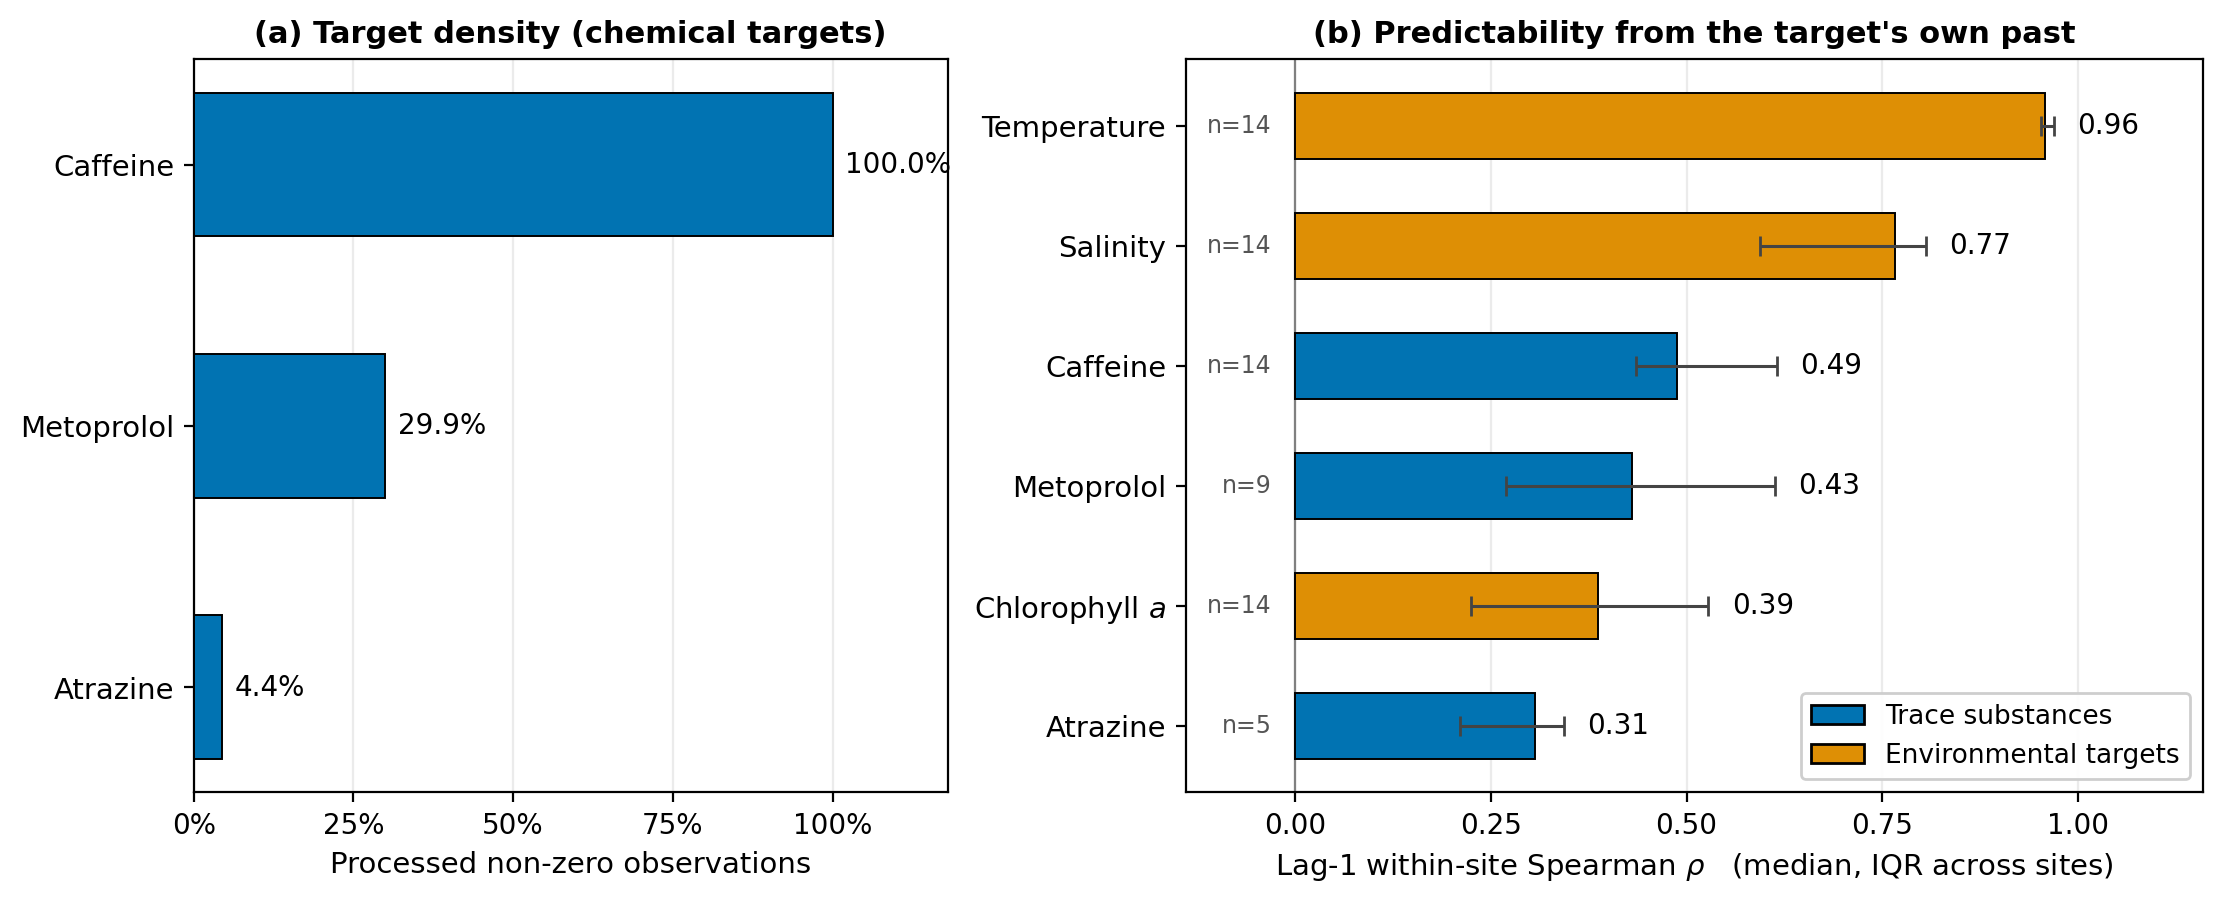

saved: fig_8_1_target_properties.png / .pdf
n_sites: {'Temperature': 14, 'Salinity': 14, 'Caffeine': 14, 'Metoprolol': 9, 'Chlorophyll $a$': 14, 'Atrazine': 5}


In [15]:
# ============================================================
# Figure 8.1 — the two target properties of Section 8.1.
# Left : processed non-zero fraction (chemical targets only)
# Right: lag-1 within-site Spearman autocorrelation (all six targets)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np, pandas as pd
from pathlib import Path
from matplotlib.patches import Patch
from IPython.display import Image, display

ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')
R = ROOT / 'results'

ac = pd.read_csv(R / 'temporal_autocorr_summary.csv')
ac = ac[ac.k == 1].set_index('target')

LBL = {'temperature': 'Temperature', 'salinity': 'Salinity',
       'Chl_a': 'Chlorophyll $a$', 'Caffeine': 'Caffeine',
       'Metoprolol': 'Metoprolol', 'Atrazine': 'Atrazine'}
ORDER = ['temperature', 'salinity', 'Caffeine',
         'Metoprolol', 'Chl_a', 'Atrazine']          # descending rho
NONZERO = {'Caffeine': 1.000, 'Metoprolol': 0.299, 'Atrazine': 0.044}

CHEM, ENV = '#0173B2', '#DE8F05'
col = lambda t: CHEM if t in NONZERO else ENV

fig, (axL, axR) = plt.subplots(
    1, 2, figsize=(11, 4.4), constrained_layout=True,
    gridspec_kw={'width_ratios': [1, 1.35]})

# ---------- (a) non-zero fraction ----------
ch = ['Caffeine', 'Metoprolol', 'Atrazine']
y = np.arange(len(ch))[::-1]
axL.barh(y, [NONZERO[t] for t in ch], height=0.55,
         color=CHEM, edgecolor='black', linewidth=0.7, zorder=3)
for yi, t in zip(y, ch):
    axL.text(NONZERO[t] + 0.02, yi, f'{100*NONZERO[t]:.1f}%',
             va='center', fontsize=10)
axL.set_yticks(y); axL.set_yticklabels([LBL[t] for t in ch], fontsize=10.5)
axL.set_xlim(0, 1.18)
axL.set_xticks([0, .25, .5, .75, 1.0])
axL.set_xticklabels(['0%', '25%', '50%', '75%', '100%'])
axL.set_xlabel('Processed non-zero observations', fontsize=10.5)
axL.set_title('(a) Target density (chemical targets)',
              fontsize=11, fontweight='bold')
axL.grid(axis='x', alpha=0.25); axL.set_axisbelow(True)

# ---------- (b) lag-1 autocorrelation with IQR ----------
y = np.arange(len(ORDER))[::-1]
med = np.array([ac.loc[t, 'spearman_med'] for t in ORDER])
q1  = np.array([ac.loc[t, 'spearman_q1']  for t in ORDER])
q3  = np.array([ac.loc[t, 'spearman_q3']  for t in ORDER])

axR.barh(y, med, height=0.55, color=[col(t) for t in ORDER],
         edgecolor='black', linewidth=0.7, zorder=3,
         xerr=[med - q1, q3 - med],
         error_kw=dict(ecolor='#444444', capsize=3.5, lw=1.1, zorder=4))
for yi, t, m, hi in zip(y, ORDER, med, q3):
    axR.text(hi + 0.03, yi, f'{m:.2f}', va='center', fontsize=10)
    axR.text(-0.03, yi, f'n={int(ac.loc[t, "n_sites"])}',
             va='center', ha='right', fontsize=8.5, color='#555555')
axR.set_yticks(y); axR.set_yticklabels([LBL[t] for t in ORDER], fontsize=10.5)
axR.set_xlim(-0.14, 1.16)
axR.set_xticks([0, .25, .5, .75, 1.0])
axR.set_xlabel('Lag-1 within-site Spearman $\\rho$   (median, IQR across sites)',
               fontsize=10.5)
axR.set_title("(b) Predictability from the target's own past",
              fontsize=11, fontweight='bold')
axR.axvline(0, color='grey', lw=0.8, zorder=2)
axR.grid(axis='x', alpha=0.25); axR.set_axisbelow(True)
axR.legend(handles=[Patch(facecolor=CHEM, edgecolor='black',
                          label='Trace substances'),
                    Patch(facecolor=ENV, edgecolor='black',
                          label='Environmental targets')],
           fontsize=9.5, loc='lower right', framealpha=0.95)

for ext in ('png', 'pdf'):
    fig.savefig(R / f'fig_8_1_target_properties.{ext}',
                dpi=200, bbox_inches='tight')
plt.close(fig)

display(Image(filename=str(R / 'fig_8_1_target_properties.png')))
print('saved: fig_8_1_target_properties.png / .pdf')
print('n_sites:', {LBL[t]: int(ac.loc[t, 'n_sites']) for t in ORDER})

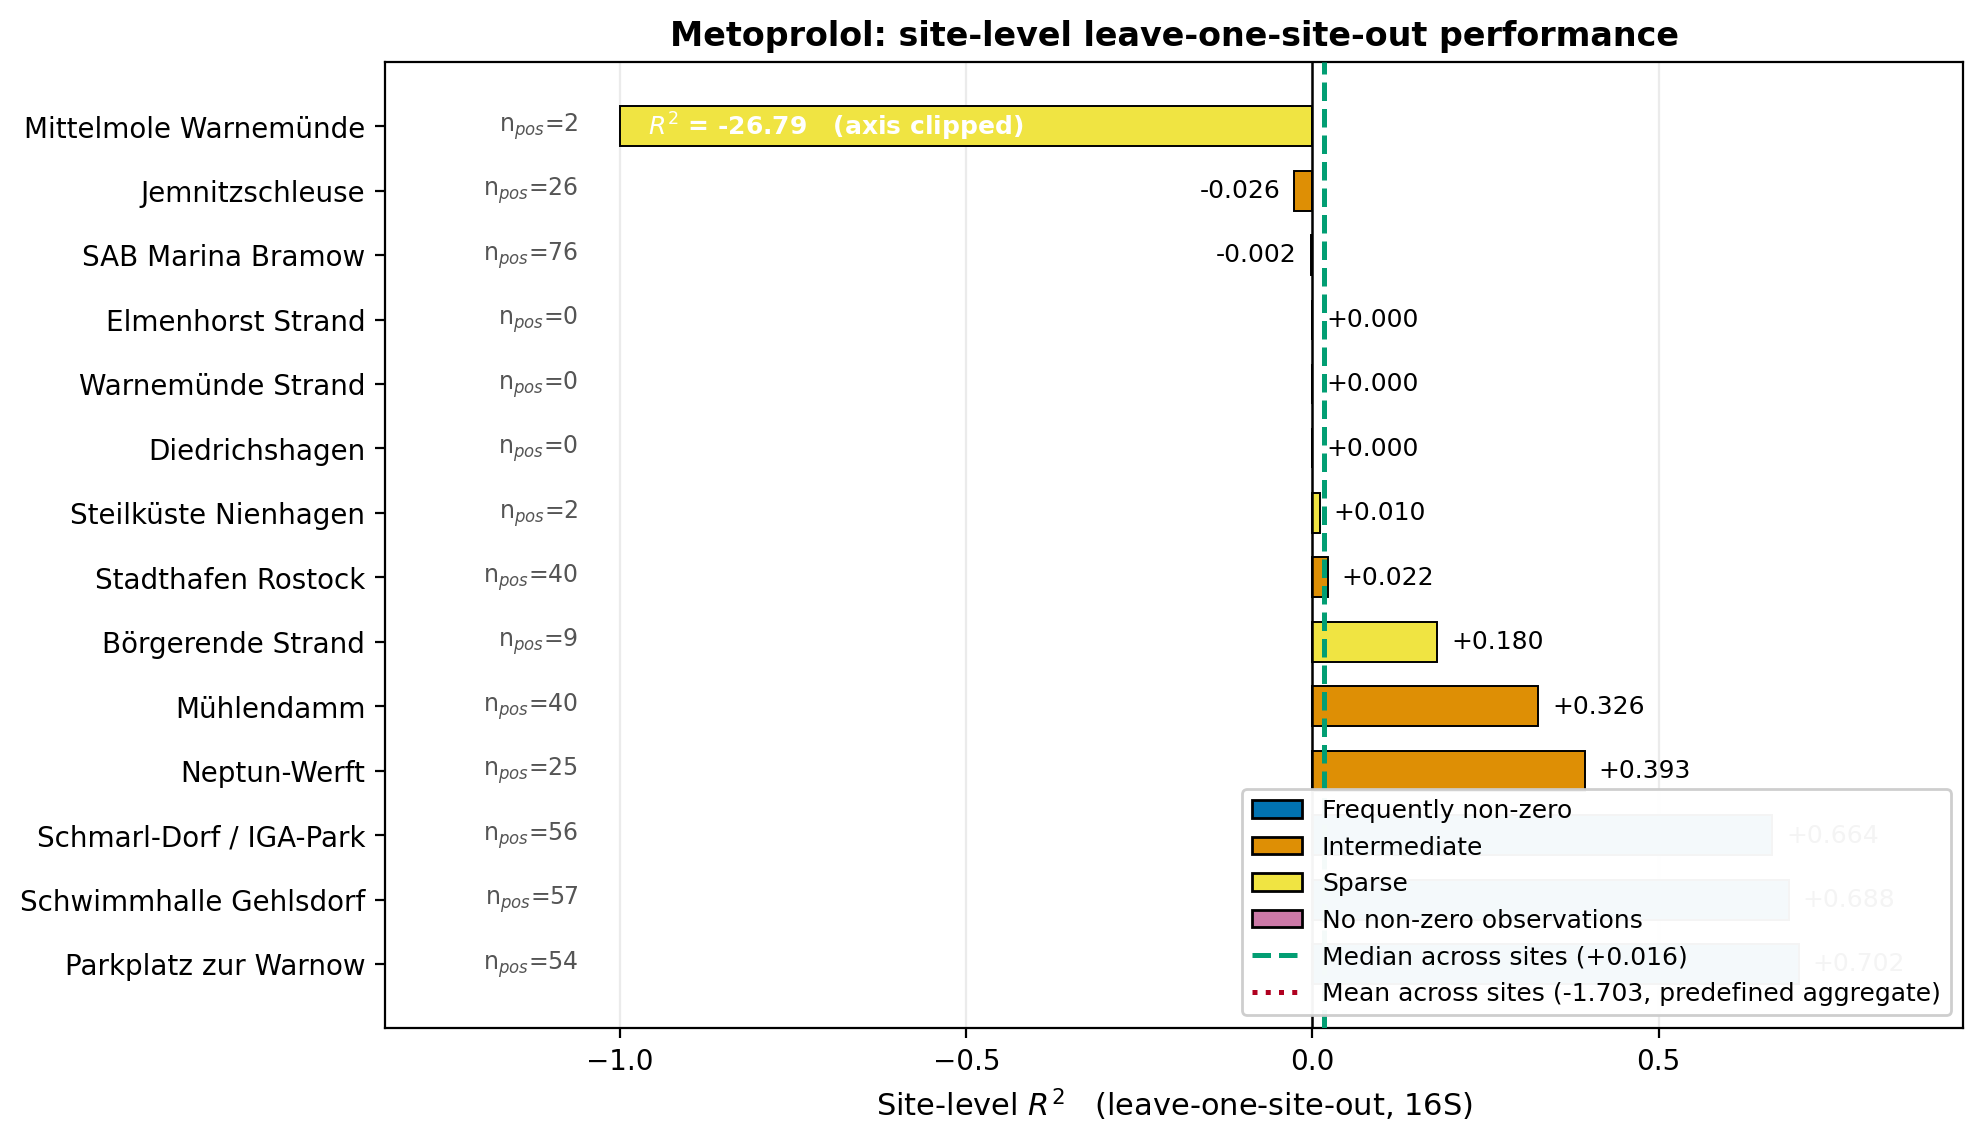

mean -1.7025 | median +0.0161 | n_sites 14


In [18]:
# ============================================================
# Figure 8.2 — site-level LOSO R² for metoprolol (16S input).
# Bars coloured by the number of non-zero observations per station.
# ============================================================
import matplotlib.pyplot as plt
import numpy as np, pandas as pd
from pathlib import Path
from matplotlib.patches import Patch
from IPython.display import Image, display

R = Path('/mnt/data/home/tv2414/tabpfn_project/results')
d = pd.read_csv(R / 'phase3_metoprolol_loso_persite.csv').sort_values('r2')

FLOOR = -1.0                       # axis clip; true value annotated on the bar
d['disp'] = d['r2'].clip(lower=FLOOR)
mean_r2, med_r2 = d['r2'].mean(), d['r2'].median()

def cat(n):
    if n == 0:  return 'No non-zero observations'
    if n <= 10: return 'Sparse'
    if n <= 45: return 'Intermediate'
    return 'Frequently non-zero'
COL = {'No non-zero observations': '#CC79A7', 'Sparse': '#F0E442',
       'Intermediate': '#DE8F05', 'Frequently non-zero': '#0173B2'}
d['cat'] = d['n_pos'].map(cat)

fig, ax = plt.subplots(figsize=(9.8, 5.6), constrained_layout=True)
y = np.arange(len(d))[::-1]
ax.barh(y, d['disp'], height=0.62, color=[COL[c] for c in d['cat']],
        edgecolor='black', linewidth=0.7, zorder=3)

for yi, (_, r) in zip(y, d.iterrows()):
    if r['r2'] < FLOOR:
        ax.text(FLOOR + 0.04, yi, f'$R^2$ = {r["r2"]:.2f}   (axis clipped)',
                va='center', ha='left', fontsize=9,
                color='white', fontweight='bold', zorder=5)
    else:
        off = 0.02 if r['r2'] >= 0 else -0.02
        ax.text(r['r2'] + off, yi, f'{r["r2"]:+.3f}', va='center',
                ha='left' if r['r2'] >= 0 else 'right', fontsize=9, zorder=5)
    ax.text(FLOOR - 0.06, yi, f'n$_{{pos}}$={int(r["n_pos"])}', va='center',
            ha='right', fontsize=8.5, color='#555555')

ax.axvline(0, color='black', lw=0.9, zorder=4)
ax.axvline(med_r2, color='#029E73', lw=1.8, ls='--', zorder=4,
           label=f'Median across sites ({med_r2:+.3f})')
ax.axvline(mean_r2, color='#B00020', lw=1.8, ls=':', zorder=4,
           label=f'Mean across sites ({mean_r2:+.3f}, predefined aggregate)')

ax.set_yticks(y)
ax.set_yticklabels(d['site'].str.replace('Muehlendamm', 'Mühlendamm')
                            .str.replace('Warnemuende', 'Warnemünde')
                            .str.replace('Steilkueste', 'Steilküste')
                            .str.replace('Boergerende', 'Börgerende'),
                   fontsize=10)
ax.set_xlim(FLOOR - 0.34, 0.94)
ax.set_xlabel('Site-level $R^2$   (leave-one-site-out, 16S)', fontsize=11)
ax.set_title('Metoprolol: site-level leave-one-site-out performance',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.25); ax.set_axisbelow(True)

h = [Patch(facecolor=COL[c], edgecolor='black', label=c)
     for c in ['Frequently non-zero', 'Intermediate', 'Sparse',
               'No non-zero observations']]
h += ax.get_legend_handles_labels()[0]
ax.legend(handles=h, fontsize=9, loc='lower right', framealpha=0.96)

for ext in ('png', 'pdf'):
    fig.savefig(R / f'fig_8_2_metoprolol_loso_persite.{ext}',
                dpi=200, bbox_inches='tight')
plt.close(fig)

display(Image(filename=str(R / 'fig_8_2_metoprolol_loso_persite.png')))
print(f'mean {mean_r2:+.4f} | median {med_r2:+.4f} | n_sites {len(d)}')

In [21]:
import numpy as np, pandas as pd
from pathlib import Path

PROC = Path('/mnt/data/home/tv2414/tabpfn_project/data/processed')
meta = pd.read_csv(PROC / 'meta_clean.csv', index_col=0)
meta['date'] = pd.to_datetime(meta['date'], errors='coerce')

for k in (1, 2, 3):
    lead = []
    for _, g in meta.groupby('location_name'):
        d = pd.DatetimeIndex(g.sort_values('date')['date'])
        gaps = d[1:].values.astype('datetime64[D]').astype(int) - \
               d[:-1].values.astype('datetime64[D]').astype(int)
        days = d.values.astype('datetime64[D]').astype(int)
        for i in range(len(d) - k):
            if (gaps[i:i+k] <= 6).all():
                lead.append(days[i+k] - days[i])
    s = pd.Series(lead)
    print(f'k={k}: n={len(s)}  min={s.min()}  max={s.max()}  '
          f'mean={s.mean():.2f}  median={s.median():.1f}')
    print('      distribution:', s.value_counts().sort_index().to_dict())

k=1: n=1501  min=3  max=4  mean=3.50  median=4.0
      distribution: {3: 745, 4: 756}
k=2: n=1468  min=7  max=7  mean=7.00  median=7.0
      distribution: {7: 1468}
k=3: n=1438  min=10  max=11  mean=10.50  median=11.0
      distribution: {10: 715, 11: 723}


In [22]:
# ============================================================
# Resolve the consecutive-step count: Chapter 5 (1,554) vs Chapter 8.
# READ ONLY.
# ============================================================
import numpy as np, pandas as pd
from pathlib import Path

PROC = Path('/mnt/data/home/tv2414/tabpfn_project/data/processed')
meta = pd.read_csv(PROC / 'meta_clean.csv', index_col=0)
meta['date'] = pd.to_datetime(meta['date'], errors='coerce')

print(f'rows in meta_clean      : {len(meta)}')
print(f'rows with a valid date  : {meta["date"].notna().sum()}')
print(f'rows with missing date  : {meta["date"].isna().sum()}')
print(f'stations                : {meta["location_name"].nunique()}')
print(f'duplicate (site, date)  : '
      f'{meta.duplicated(["location_name", "date"]).sum()}')

# ---- consecutive steps, computed three ways ----
def steps(drop_na_date, dedupe):
    m = meta.dropna(subset=['date']) if drop_na_date else meta
    out = []
    for site, g in m.groupby('location_name'):
        g = g.sort_values('date')
        if dedupe:
            g = g.drop_duplicates('date')
        d = pd.DatetimeIndex(g['date']).values.astype('datetime64[D]').astype(int)
        out += list(np.diff(d))
    return pd.Series(out)

print('\n' + '=' * 62)
print('CONSECUTIVE STEP COUNTS UNDER DIFFERENT CONVENTIONS')
print('=' * 62)
for lbl, na, dd in [('all rows, keep duplicate dates', False, False),
                    ('valid dates, keep duplicates',  True,  False),
                    ('valid dates, one row per date', True,  True)]:
    s = steps(na, dd)
    print(f'\n{lbl}:')
    print(f'  total steps : {len(s)}')
    print(f'  distribution: {s.value_counts().sort_index().to_dict()}')
    print(f'  steps > 4 d : {(s > 4).sum()}   steps > 6 d : {(s > 6).sum()}')

# ---- how many PAIRS survive at each horizon (what the text should cite) ----
print('\n' + '=' * 62)
print('PAIRS RETAINED / DISCARDED PER HORIZON (max step = 6 days)')
print('=' * 62)
m = meta.dropna(subset=['date'])
for k in (1, 2, 3):
    keep = drop = 0
    for _, g in m.groupby('location_name'):
        d = pd.DatetimeIndex(g.sort_values('date')['date']) \
              .values.astype('datetime64[D]').astype(int)
        gaps = np.diff(d)
        for i in range(len(d) - k):
            (keep := keep + 1) if (gaps[i:i+k] <= 6).all() else (drop := drop + 1)
    print(f'  k={k}: candidate {keep+drop:>5d}   retained {keep:>5d}   '
          f'discarded {drop:>3d}')

rows in meta_clean      : 1538
rows with a valid date  : 1538
rows with missing date  : 0
stations                : 14
duplicate (site, date)  : 0

CONSECUTIVE STEP COUNTS UNDER DIFFERENT CONVENTIONS

all rows, keep duplicate dates:
  total steps : 1524
  distribution: {3: 745, 4: 756, 7: 20, 10: 2, 11: 1}
  steps > 4 d : 23   steps > 6 d : 23

valid dates, keep duplicates:
  total steps : 1524
  distribution: {3: 745, 4: 756, 7: 20, 10: 2, 11: 1}
  steps > 4 d : 23   steps > 6 d : 23

valid dates, one row per date:
  total steps : 1524
  distribution: {3: 745, 4: 756, 7: 20, 10: 2, 11: 1}
  steps > 4 d : 23   steps > 6 d : 23

PAIRS RETAINED / DISCARDED PER HORIZON (max step = 6 days)
  k=1: candidate  1524   retained  1501   discarded  23
  k=2: candidate  1510   retained  1468   discarded  42
  k=3: candidate  1496   retained  1438   discarded  58


In [23]:
import numpy as np, pandas as pd
from pathlib import Path

PROC = Path('/mnt/data/home/tv2414/tabpfn_project/data/processed')
meta = pd.read_csv(PROC / 'meta_clean.csv', index_col=0)
meta['date'] = pd.to_datetime(meta['date'], errors='coerce')
CUT = pd.Timestamp('2023-01-19')

print(f'{"k":>2s}{"train":>8s}{"test":>8s}{"purged":>8s}{"14*k":>7s}')
for k in (1, 2, 3):
    tr = te = pu = 0
    per_site = {}
    for site, g in meta.groupby('location_name'):
        g = g.sort_values('date')
        d = pd.DatetimeIndex(g['date'])
        dd = d.values.astype('datetime64[D]').astype(int)
        gaps = np.diff(dd)
        n = 0
        for i in range(len(d) - k):
            if not (gaps[i:i+k] <= 6).all():
                continue
            f_date, t_date = d[i], d[i+k]
            if t_date < CUT:      tr += 1
            elif f_date >= CUT:   te += 1
            else:                 pu += 1; n += 1
        per_site[site] = n
    print(f'{k:>2d}{tr:>8d}{te:>8d}{pu:>8d}{14*k:>7d}')
    if pu != 14 * k:
        print('   purged per site:', per_site)

 k   train    test  purged   14*k
 1    1058     429      14     14
 2    1034     406      28     28
 3    1010     386      42     42


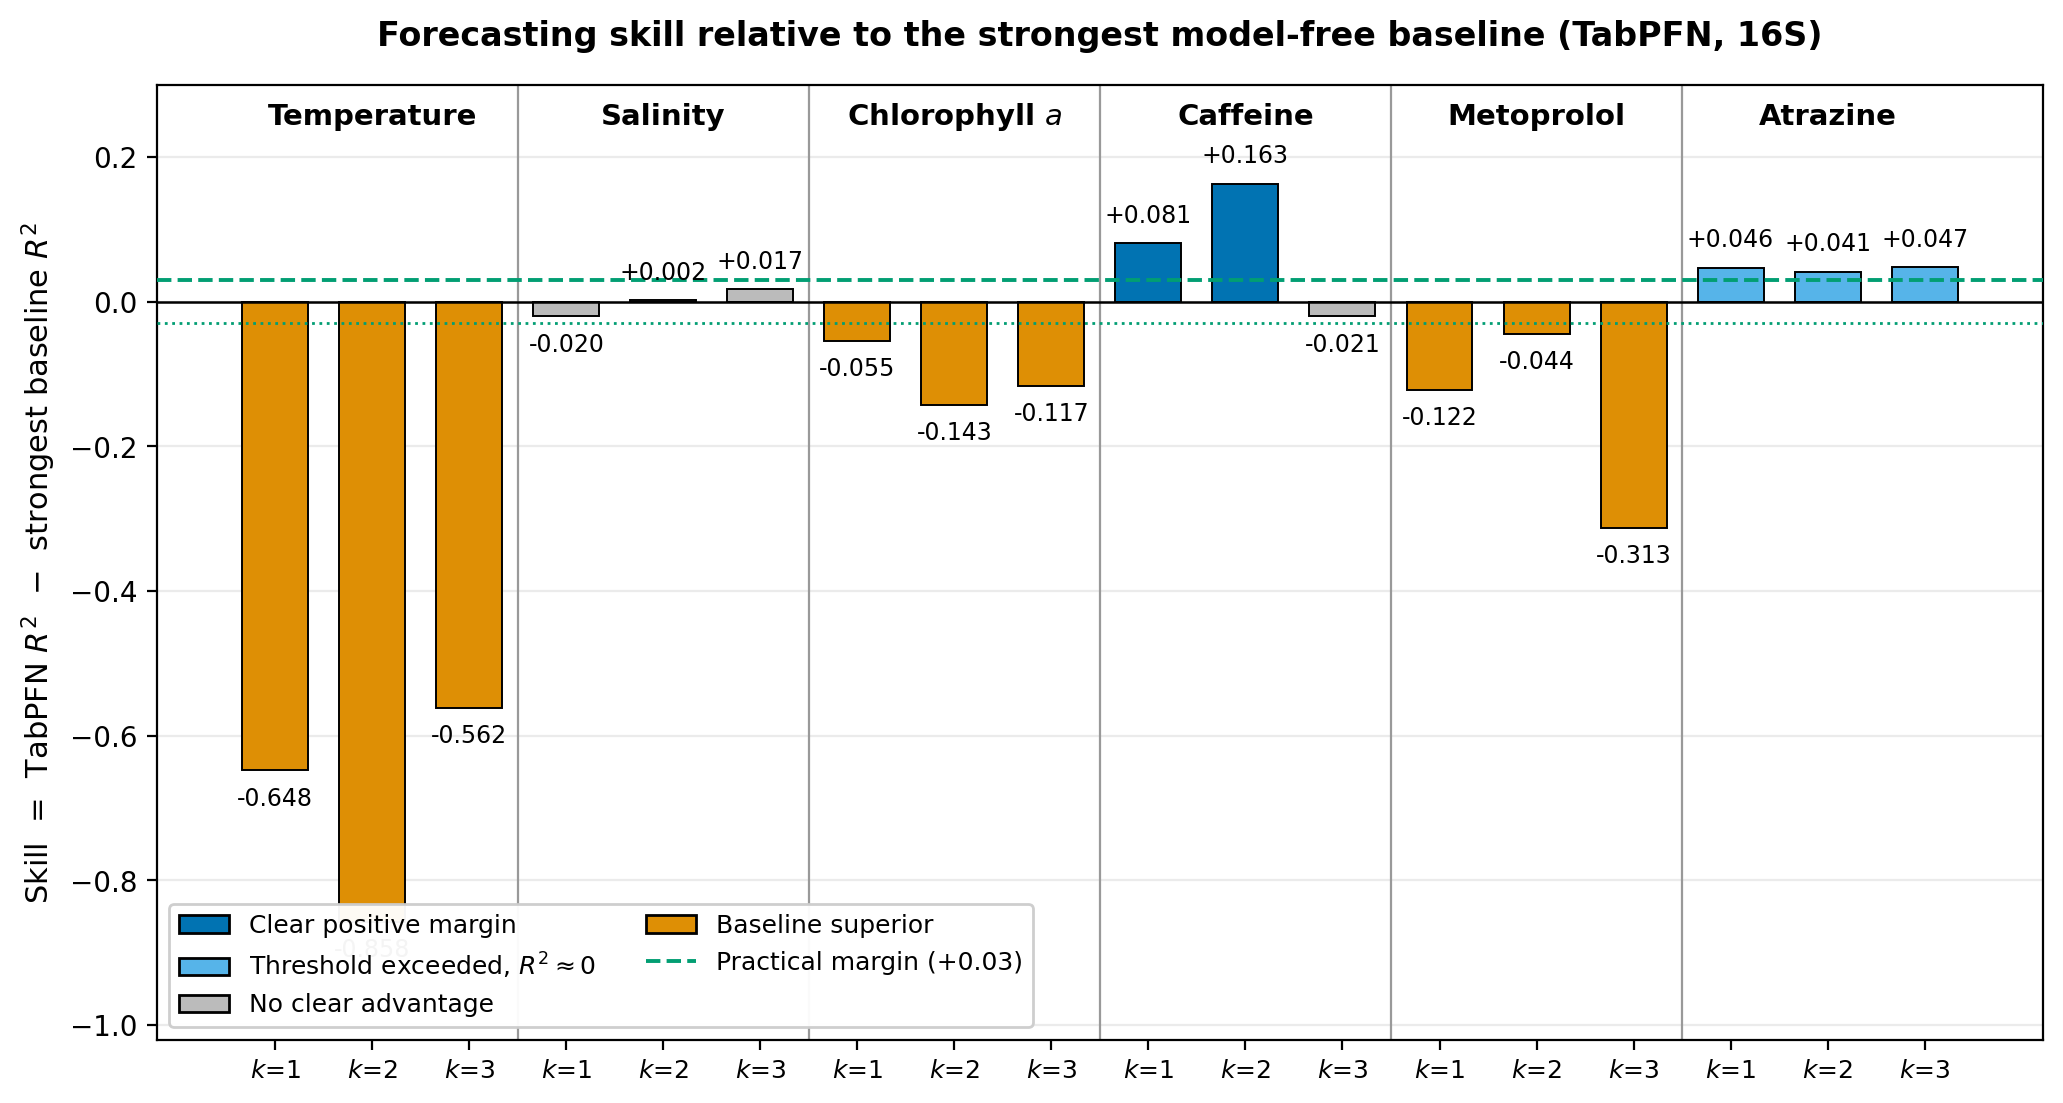

     target  k     r2    baseline  base_r2  skill
Temperature  1  0.135 persistence    0.783 -0.648
Temperature  2 -0.166 persistence    0.692 -0.858
Temperature  3 -0.007 persistence    0.555 -0.562
   Salinity  1  0.496 persistence    0.517 -0.020
   Salinity  2  0.431 persistence    0.429  0.002
   Salinity  3  0.527 persistence    0.510  0.017
      Chl_a  1  0.539   site_mean    0.594 -0.055
      Chl_a  2  0.465   site_mean    0.608 -0.143
      Chl_a  3  0.487   site_mean    0.604 -0.117
   Caffeine  1  0.123   site_mean    0.043  0.081
   Caffeine  2  0.228   site_mean    0.066  0.163
   Caffeine  3  0.135   site_mean    0.156 -0.021
 Metoprolol  1  0.021   site_mean    0.144 -0.122
 Metoprolol  2  0.075   site_mean    0.119 -0.044
 Metoprolol  3  0.033 persistence    0.346 -0.313
   Atrazine  1  0.004 global_mean   -0.042  0.046
   Atrazine  2  0.007 global_mean   -0.034  0.041
   Atrazine  3  0.009 global_mean   -0.038  0.047


In [24]:
# ============================================================
# Figure 8.3 — forecasting skill relative to the strongest
# model-free baseline, TabPFN with 16S input, six targets.
# ============================================================
import matplotlib.pyplot as plt
import numpy as np, pandas as pd
from pathlib import Path
from matplotlib.patches import Patch
from IPython.display import Image, display

R = Path('/mnt/data/home/tv2414/tabpfn_project/results')
d = pd.read_csv(R / 'chapter8_master_forecasting_table.csv')
d.columns = ['target', 'k', 'r2', 'baseline', 'base_r2', 'skill', 'verdict']

ORDER = ['Temperature', 'Salinity', 'Chl_a', 'Caffeine',
         'Metoprolol', 'Atrazine']
LBL   = {'Chl_a': 'Chlorophyll $a$'}
d['target'] = pd.Categorical(d['target'].str.capitalize()
                             .replace({'Chl_a': 'Chl_a'}), ORDER, ordered=True)
d = d.sort_values(['target', 'k'])

THR = 0.03
def colour(row):
    if row.skill > THR and row.r2 > 0.05: return '#0173B2'   # clear positive
    if row.skill > THR:                   return '#56B4E9'   # threshold, R²≈0
    if row.skill > -THR:                  return '#BBBBBB'   # no clear advantage
    return '#DE8F05'                                          # baseline superior
d['col'] = [colour(r) for r in d.itertuples()]

fig, ax = plt.subplots(figsize=(10.2, 5.4), constrained_layout=True)
x = np.arange(len(d))
ax.bar(x, d['skill'], width=0.68, color=d['col'],
       edgecolor='black', linewidth=0.7, zorder=3)

for xi, r in zip(x, d.itertuples()):
    off = 0.022 if r.skill >= 0 else -0.022
    ax.text(xi, r.skill + off, f'{r.skill:+.3f}', ha='center',
            va='bottom' if r.skill >= 0 else 'top', fontsize=8.5, zorder=5)

ax.axhline(0, color='black', lw=0.9, zorder=4)
ax.axhline(THR, color='#029E73', lw=1.4, ls='--', zorder=4,
           label=f'Practical margin (+{THR:.2f})')
ax.axhline(-THR, color='#029E73', lw=1.0, ls=':', zorder=4)

# target group separators and labels
for i in range(1, 6):
    ax.axvline(3 * i - 0.5, color='#999999', lw=0.8, ls='-', zorder=2)
ax.set_xticks(x)
ax.set_xticklabels([f'$k$={r.k}' for r in d.itertuples()], fontsize=9)
for i, t in enumerate(ORDER):
    ax.text(3 * i + 1, ax.get_ylim()[0], '', ha='center')
ax.set_ylim(-1.02, 0.30)
for i, t in enumerate(ORDER):
    ax.text(3 * i + 1, 0.245, LBL.get(t, t), ha='center', fontsize=10.5,
            fontweight='bold')

ax.set_ylabel('Skill  =  TabPFN $R^2$  $-$  strongest baseline $R^2$',
              fontsize=11)
ax.set_title('Forecasting skill relative to the strongest model-free baseline '
             '(TabPFN, 16S)', fontsize=12, fontweight='bold', pad=14)
ax.grid(axis='y', alpha=0.25); ax.set_axisbelow(True)

h = [Patch(facecolor='#0173B2', edgecolor='black', label='Clear positive margin'),
     Patch(facecolor='#56B4E9', edgecolor='black',
           label='Threshold exceeded, $R^2 \\approx 0$'),
     Patch(facecolor='#BBBBBB', edgecolor='black', label='No clear advantage'),
     Patch(facecolor='#DE8F05', edgecolor='black', label='Baseline superior')]
h += ax.get_legend_handles_labels()[0]
ax.legend(handles=h, fontsize=9, loc='lower left', ncol=2, framealpha=0.96)

for ext in ('png', 'pdf'):
    fig.savefig(R / f'fig_8_3_forecasting_skill.{ext}',
                dpi=200, bbox_inches='tight')
plt.close(fig)

display(Image(filename=str(R / 'fig_8_3_forecasting_skill.png')))
print(d[['target', 'k', 'r2', 'baseline', 'base_r2', 'skill']]
      .round(3).to_string(index=False))

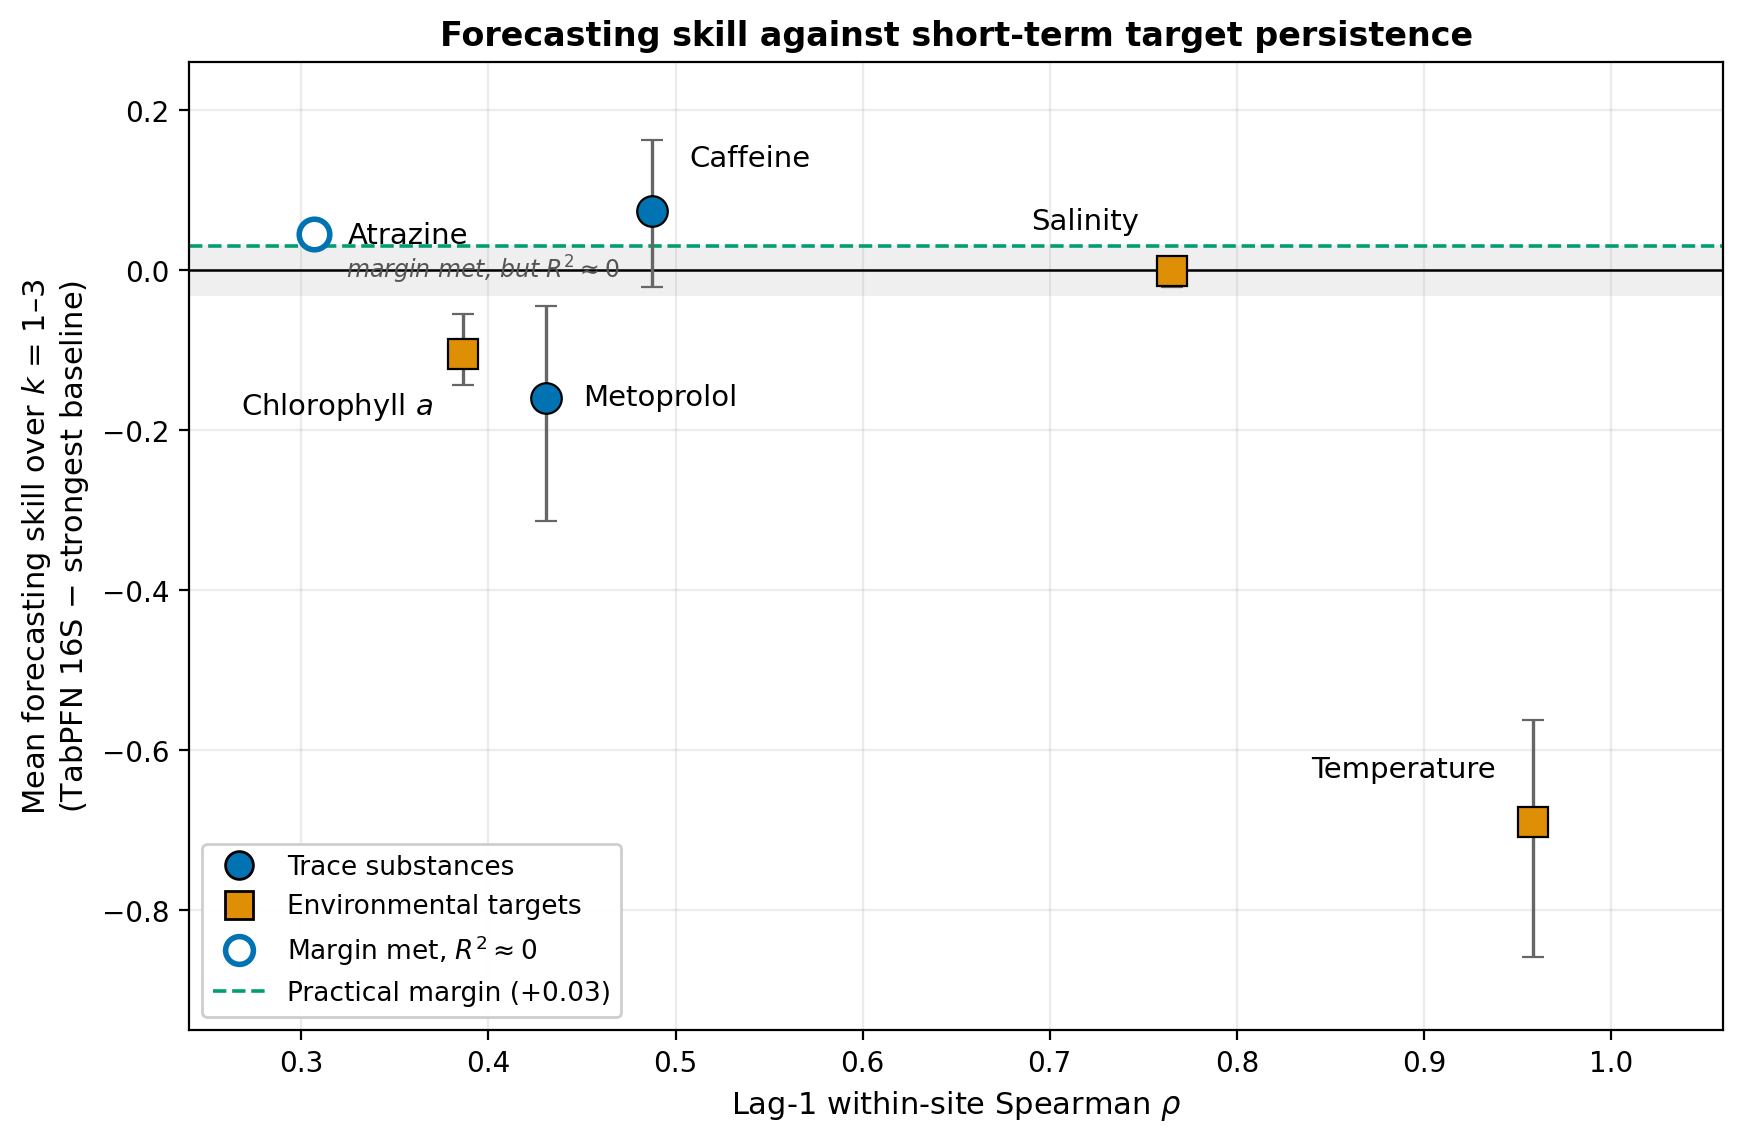

          t   rho   mean     lo     hi
temperature 0.958 -0.689 -0.858 -0.562
   salinity 0.766 -0.001 -0.020  0.017
      Chl_a 0.387 -0.105 -0.143 -0.055
   Caffeine 0.487  0.074 -0.021  0.163
 Metoprolol 0.431 -0.160 -0.313 -0.044
   Atrazine 0.307  0.045  0.041  0.047


In [26]:
# ============================================================
# Figure 8.4 — mean forecasting skill vs lag-1 autocorrelation.
# Atrazine is marked as hollow: it exceeds the margin only because
# its baseline is negative; its own R² is ~0 (see Table 8.3).
# ============================================================
import matplotlib.pyplot as plt
import numpy as np, pandas as pd
from pathlib import Path
from matplotlib.lines import Line2D
from IPython.display import Image, display

R = Path('/mnt/data/home/tv2414/tabpfn_project/results')

m = pd.read_csv(R / 'chapter8_master_forecasting_table.csv')
m.columns = ['target', 'k', 'r2', 'baseline', 'base_r2', 'skill', 'verdict']
ac = pd.read_csv(R / 'temporal_autocorr_summary.csv')
ac = ac[ac.k == 1].set_index('target')['spearman_med']

LBL = {'temperature': 'Temperature', 'salinity': 'Salinity',
       'Chl_a': 'Chlorophyll $a$', 'Caffeine': 'Caffeine',
       'Metoprolol': 'Metoprolol', 'Atrazine': 'Atrazine'}
CHEM = {'Caffeine', 'Metoprolol', 'Atrazine'}

g = m.groupby('target')['skill'].agg(['mean', 'min', 'max'])
rows = []
for t in LBL:
    key = next(i for i in g.index if i.lower() == t.lower())
    rows.append(dict(t=t, rho=ac[t], mean=g.loc[key, 'mean'],
                     lo=g.loc[key, 'min'], hi=g.loc[key, 'max']))
d = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(8.6, 5.6), constrained_layout=True)
ax.axhspan(-0.03, 0.03, color='#EFEFEF', zorder=0)
ax.axhline(0, color='black', lw=0.9, zorder=2)
ax.axhline(0.03, color='#029E73', lw=1.3, ls='--', zorder=2,
           label='Practical margin (+0.03)')

for r in d.itertuples():
    chem = r.t in CHEM
    c = '#0173B2' if chem else '#DE8F05'
    mk = 'o' if chem else 's'
    hollow = (r.t == 'Atrazine')          # margin met, absolute R² ~ 0
    ax.errorbar(r.rho, r.mean, yerr=[[r.mean - r.lo], [r.hi - r.mean]],
                fmt=mk, ms=11, color='white' if hollow else c,
                markeredgecolor=c if hollow else 'black',
                markeredgewidth=2.0 if hollow else 0.8,
                ecolor='#666666', elinewidth=1.2, capsize=4, zorder=4)

# label offsets tuned to avoid collisions
OFF = {'temperature': (-0.020, 0.055, 'right'),
       'salinity':    (-0.018, 0.052, 'right'),
       'Chl_a':       (-0.016, -0.075, 'right'),
       'Caffeine':    (0.020, 0.055, 'left'),
       'Metoprolol':  (0.020, -0.010, 'left'),
       'Atrazine':    (0.018, -0.012, 'left')}
for r in d.itertuples():
    dx, dy, ha = OFF[r.t]
    ax.annotate(LBL[r.t], (r.rho + dx, r.mean + dy), fontsize=10.5, ha=ha)

ax.annotate('margin met, but $R^2 \\approx 0$',
            xy=(d.loc[d.t == 'Atrazine', 'rho'].iloc[0] + 0.017,
                d.loc[d.t == 'Atrazine', 'mean'].iloc[0] - 0.055),
            fontsize=8.5, style='italic', color='#555555', ha='left')

ax.set_xlabel('Lag-1 within-site Spearman $\\rho$', fontsize=11)
ax.set_ylabel('Mean forecasting skill over $k$ = 1–3\n'
              '(TabPFN 16S $-$ strongest baseline)', fontsize=11)
ax.set_title('Forecasting skill against short-term target persistence',
             fontsize=12, fontweight='bold')
ax.set_xlim(0.24, 1.06)
ax.set_ylim(-0.95, 0.26)
ax.grid(alpha=0.25); ax.set_axisbelow(True)

ax.legend(handles=[
    Line2D([], [], marker='o', ls='', color='#0173B2', ms=10,
           markeredgecolor='black', label='Trace substances'),
    Line2D([], [], marker='s', ls='', color='#DE8F05', ms=10,
           markeredgecolor='black', label='Environmental targets'),
    Line2D([], [], marker='o', ls='', color='white', ms=10,
           markeredgecolor='#0173B2', markeredgewidth=2,
           label='Margin met, $R^2 \\approx 0$'),
    Line2D([], [], ls='--', color='#029E73', lw=1.3,
           label='Practical margin (+0.03)')],
    fontsize=9.5, loc='lower left', framealpha=0.96)

for ext in ('png', 'pdf'):
    fig.savefig(R / f'fig_8_4_skill_vs_autocorr.{ext}',
                dpi=200, bbox_inches='tight')
plt.close(fig)

display(Image(filename=str(R / 'fig_8_4_skill_vs_autocorr.png')))
print(d.round(3).to_string(index=False))

In [27]:
import pandas as pd
from pathlib import Path
R = Path('/mnt/data/home/tv2414/tabpfn_project/results')
d = pd.read_csv(R / 'forecast_window_regime_check.csv')
print(d.columns.tolist())
print(d.to_string(index=False))

['target', 'n_tr', 'n_te', 'std_tr', 'std_te', 'std_ratio', 'max_tr', 'max_te', 'pct0_tr', 'pct0_te', 'rho1_tr', 'rho1_te']
     target  n_tr  n_te    std_tr    std_te  std_ratio     max_tr     max_te   pct0_tr   pct0_te  rho1_tr   rho1_te
temperature   829   394  6.046815  2.243537   0.371028  24.459000  13.214000  0.000000  0.000000 0.972217  0.834866
   salinity   822   395  4.912365  4.616078   0.939685  23.800000  17.800000  0.000000  0.000000 0.738843  0.756448
      Chl_a  1006   431  0.952515  0.914491   0.960080   5.062361   3.982521  0.099404  0.000000 0.706829  0.713293
   Caffeine   975   316 43.089121 24.282796   0.563548 467.600000 296.600000  0.000000  0.000000 0.778467  0.568344
 Metoprolol   975   318 42.833023 27.343923   0.638384 491.900000 306.400000 67.179487 78.930818 0.649367  0.602972
   Atrazine   973   316  0.801955  0.537479   0.670211   4.600000   4.200000 94.861254 97.784810 0.362587 -0.022553


In [28]:
import pandas as pd
from pathlib import Path
R = Path('/mnt/data/home/tv2414/tabpfn_project/results')
for p in sorted(R.glob('*.csv')):
    try:
        h = pd.read_csv(p, nrows=0)
    except Exception:
        continue
    if any(k in ' '.join(h.columns).lower()
           for k in ('predict_now', 'prednow', 'now_r2', 'contemporaneous')):
        print(p.name, list(h.columns))
        print(pd.read_csv(p).to_string(index=False), '\n')

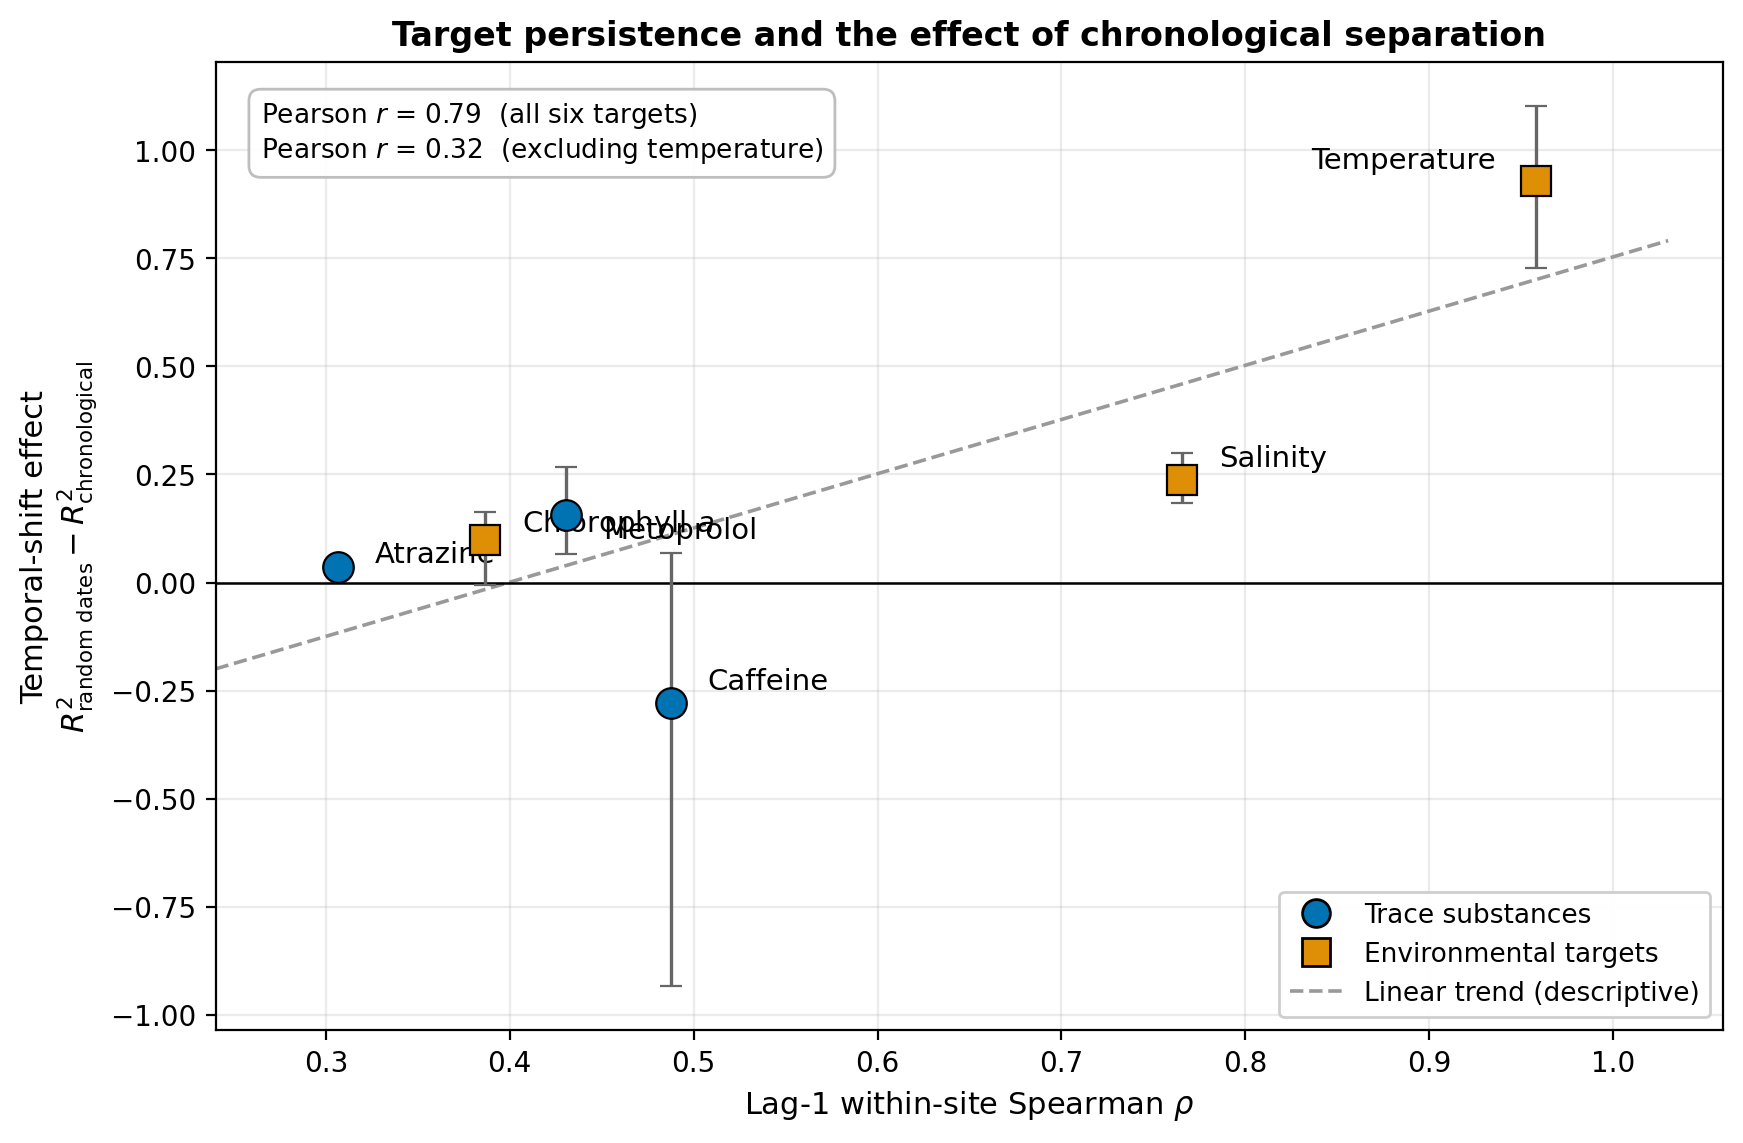

          t   rho   mean     lo    hi
temperature 0.958  0.928  0.728 1.102
   salinity 0.766  0.238  0.184 0.300
Chl_a_log1p 0.387  0.098 -0.006 0.163
   Caffeine 0.487 -0.278 -0.934 0.069
 Metoprolol 0.431  0.156  0.066 0.268
   Atrazine 0.307  0.035  0.020 0.043

Pearson r (all six)          : 0.790  (p = 0.062)
Pearson r (excl. temperature): 0.318  (p = 0.602)


In [29]:
# ============================================================
# Figure 8.4 (revised) — lag-1 autocorrelation vs temporal-shift effect.
# Vertical axis: R²(random-dates) - R²(chronological), TabPFN 16S,
# averaged over k = 1-3.  Bars span min-max across horizons.
# ============================================================
import matplotlib.pyplot as plt
import numpy as np, pandas as pd
from pathlib import Path
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
from IPython.display import Image, display

R = Path('/mnt/data/home/tv2414/tabpfn_project/results')

ms = pd.read_csv(R / 'phase3_random_split_multiseed.csv')
ac = pd.read_csv(R / 'temporal_autocorr_summary.csv')
ac = ac[ac.k == 1].set_index('target')['spearman_med']

TG = ['temperature', 'salinity', 'Chl_a_log1p',
      'Caffeine', 'Metoprolol', 'Atrazine']
ACKEY = {'Chl_a_log1p': 'Chl_a'}
LBL = {'temperature': 'Temperature', 'salinity': 'Salinity',
       'Chl_a_log1p': 'Chlorophyll $a$', 'Caffeine': 'Caffeine',
       'Metoprolol': 'Metoprolol', 'Atrazine': 'Atrazine'}
CHEM = {'Caffeine', 'Metoprolol', 'Atrazine'}

g = ms.groupby(['target', 'horizon_k', 'regime'])['r2'].mean().unstack('regime')
rows = []
for t in TG:
    sh = [g.loc[(t, k), 'random_dates'] - g.loc[(t, k), 'temporal']
          for k in (1, 2, 3)]
    rows.append(dict(t=t, rho=ac[ACKEY.get(t, t)],
                     mean=np.mean(sh), lo=min(sh), hi=max(sh)))
d = pd.DataFrame(rows)

r_all = pearsonr(d['rho'], d['mean'])
d_not = d[d.t != 'temperature']
r_not = pearsonr(d_not['rho'], d_not['mean'])

fig, ax = plt.subplots(figsize=(8.6, 5.6), constrained_layout=True)
ax.axhline(0, color='black', lw=0.9, zorder=2)

# descriptive trend line
xs = np.linspace(0.24, 1.03, 50)
b, a = np.polyfit(d['rho'], d['mean'], 1)
ax.plot(xs, a + b * xs, color='#999999', lw=1.3, ls='--', zorder=1,
        label='Linear trend (descriptive)')

for r in d.itertuples():
    chem = r.t in CHEM
    c = '#0173B2' if chem else '#DE8F05'
    mk = 'o' if chem else 's'
    ax.errorbar(r.rho, r.mean, yerr=[[r.mean - r.lo], [r.hi - r.mean]],
                fmt=mk, ms=11, color=c, markeredgecolor='black',
                markeredgewidth=0.8, ecolor='#666666',
                elinewidth=1.2, capsize=4, zorder=4)

OFF = {'temperature': (-0.022, 0.030, 'right'),
       'salinity':    (0.020, 0.030, 'left'),
       'Chl_a_log1p': (0.020, 0.020, 'left'),
       'Caffeine':    (0.020, 0.030, 'left'),
       'Metoprolol':  (0.020, -0.055, 'left'),
       'Atrazine':    (0.020, 0.010, 'left')}
for r in d.itertuples():
    dx, dy, ha = OFF[r.t]
    ax.annotate(LBL[r.t], (r.rho + dx, r.mean + dy), fontsize=10.5, ha=ha)

ax.text(0.03, 0.96,
        f'Pearson $r$ = {r_all[0]:.2f}  (all six targets)\n'
        f'Pearson $r$ = {r_not[0]:.2f}  (excluding temperature)',
        transform=ax.transAxes, fontsize=9.5, va='top',
        bbox=dict(boxstyle='round,pad=0.45', fc='white',
                  ec='#BBBBBB', alpha=0.95))

ax.set_xlabel('Lag-1 within-site Spearman $\\rho$', fontsize=11)
ax.set_ylabel('Temporal-shift effect\n'
              '$R^2_{\\mathrm{random\\ dates}} - R^2_{\\mathrm{chronological}}$',
              fontsize=11)
ax.set_title('Target persistence and the effect of chronological separation',
             fontsize=12, fontweight='bold')
ax.set_xlim(0.24, 1.06)
ax.grid(alpha=0.25); ax.set_axisbelow(True)

ax.legend(handles=[
    Line2D([], [], marker='o', ls='', color='#0173B2', ms=10,
           markeredgecolor='black', label='Trace substances'),
    Line2D([], [], marker='s', ls='', color='#DE8F05', ms=10,
           markeredgecolor='black', label='Environmental targets'),
    Line2D([], [], ls='--', color='#999999', lw=1.3,
           label='Linear trend (descriptive)')],
    fontsize=9.5, loc='lower right', framealpha=0.96)

for ext in ('png', 'pdf'):
    fig.savefig(R / f'fig_8_4_autocorr_vs_shift.{ext}',
                dpi=200, bbox_inches='tight')
plt.close(fig)

display(Image(filename=str(R / 'fig_8_4_autocorr_vs_shift.png')))
print(d.round(3).to_string(index=False))
print(f'\nPearson r (all six)          : {r_all[0]:.3f}  (p = {r_all[1]:.3f})')
print(f'Pearson r (excl. temperature): {r_not[0]:.3f}  (p = {r_not[1]:.3f})')

In [32]:
# ============================================================
# Which aggregation reproduces the reported r = 0.84 / 0.58?
# READ ONLY.
# ============================================================
import numpy as np, pandas as pd
from pathlib import Path
from scipy.stats import pearsonr

R = Path('/mnt/data/home/tv2414/tabpfn_project/results')
ms = pd.read_csv(R / 'phase3_random_split_multiseed.csv')
ac = pd.read_csv(R / 'temporal_autocorr_summary.csv')

TG = ['temperature', 'salinity', 'Chl_a_log1p',
      'Caffeine', 'Metoprolol', 'Atrazine']
ACK = {'Chl_a_log1p': 'Chl_a'}

mean = ms.groupby(['target', 'horizon_k', 'regime'])['r2'].mean().unstack('regime')
sd   = ms.groupby(['target', 'horizon_k', 'regime'])['r2'].std().unstack('regime')

def rho_at(t, lag):
    a = ac[(ac.target == ACK.get(t, t)) & (ac.k == lag)]
    return float(a['spearman_med'].iloc[0]) if len(a) else np.nan

def report(name, shift_vals, rho_vals):
    d = pd.DataFrame({'tgt': TG,
                      'x': np.asarray(rho_vals, dtype=float),
                      'y': np.asarray(shift_vals, dtype=float)}).dropna()
    ra = pearsonr(d['x'].to_numpy(), d['y'].to_numpy())
    dn = d[d['tgt'] != 'temperature']
    rn = pearsonr(dn['x'].to_numpy(), dn['y'].to_numpy())
    print(f'{name:<42s} r_all={ra[0]:+.3f}   r_excl_temp={rn[0]:+.3f}   n={len(d)}')

def shift(t, k):
    return mean.loc[(t, k), 'random_dates'] - mean.loc[(t, k), 'temporal']

# A. mean over k = 1..3, rho at lag 1
report('mean over k=1..3, rho(lag1)',
       [np.mean([shift(t, k) for k in (1, 2, 3)]) for t in TG],
       [rho_at(t, 1) for t in TG])

# B. k = 1 only
report('k=1 only, rho(lag1)',
       [shift(t, 1) for t in TG], [rho_at(t, 1) for t in TG])

# C. k = 2 only
report('k=2 only, rho(lag2)',
       [shift(t, 2) for t in TG], [rho_at(t, 2) for t in TG])

# D. k = 3 only
report('k=3 only, rho(lag3)',
       [shift(t, 3) for t in TG], [rho_at(t, 3) for t in TG])

# E. mean over stable horizons only (sd of random_dates <= 0.30)
vals = []
for t in TG:
    v = [shift(t, k) for k in (1, 2, 3) if sd.loc[(t, k), 'random_dates'] <= 0.30]
    vals.append(np.mean(v) if v else np.nan)
report('mean over stable k (sd <= 0.30), rho(lag1)',
       vals, [rho_at(t, 1) for t in TG])

# F. all 18 cells pooled, rho matched to each lag
pts = [(rho_at(t, k), shift(t, k)) for t in TG for k in (1, 2, 3)]
p = pd.DataFrame(pts, columns=['x', 'y']).dropna()
r = pearsonr(p['x'].to_numpy(), p['y'].to_numpy())
print(f'{"all 18 cells pooled, rho matched to lag":<42s} r={r[0]:+.3f}   n={len(p)}')

# ---- which cells are unstable? ----
print('\nunstable cells (sd of random_dates > 0.30):')
u = sd[sd['random_dates'] > 0.30]['random_dates']
print(u.round(3).to_string() if len(u) else '  none')

# ---- the per-target shift values, for reference ----
print('\nper-target temporal-shift effect by horizon:')
tbl = pd.DataFrame({f'k={k}': [round(shift(t, k), 3) for t in TG]
                    for k in (1, 2, 3)}, index=TG)
tbl['mean'] = tbl.mean(axis=1).round(3)
tbl['rho1'] = [round(rho_at(t, 1), 3) for t in TG]
print(tbl.to_string())

mean over k=1..3, rho(lag1)                r_all=+0.790   r_excl_temp=+0.318   n=6
k=1 only, rho(lag1)                        r_all=+0.523   r_excl_temp=+0.107   n=6
k=2 only, rho(lag2)                        r_all=+0.883   r_excl_temp=+0.811   n=6
k=3 only, rho(lag3)                        r_all=+0.847   r_excl_temp=+0.662   n=6
mean over stable k (sd <= 0.30), rho(lag1) r_all=+0.868   r_excl_temp=+0.724   n=6
all 18 cells pooled, rho matched to lag    r=+0.653   n=18

unstable cells (sd of random_dates > 0.30):
target      horizon_k
Caffeine    1            2.052
Metoprolol  3            0.306

per-target temporal-shift effect by horizon:
               k=1    k=2    k=3   mean   rho1
temperature  0.728  1.102  0.955  0.928  0.958
salinity     0.231  0.300  0.184  0.238  0.766
Chl_a_log1p -0.006  0.163  0.136  0.098  0.387
Caffeine    -0.934  0.069  0.032 -0.278  0.487
Metoprolol   0.268  0.135  0.066  0.156  0.431
Atrazine     0.043  0.043  0.020  0.035  0.307


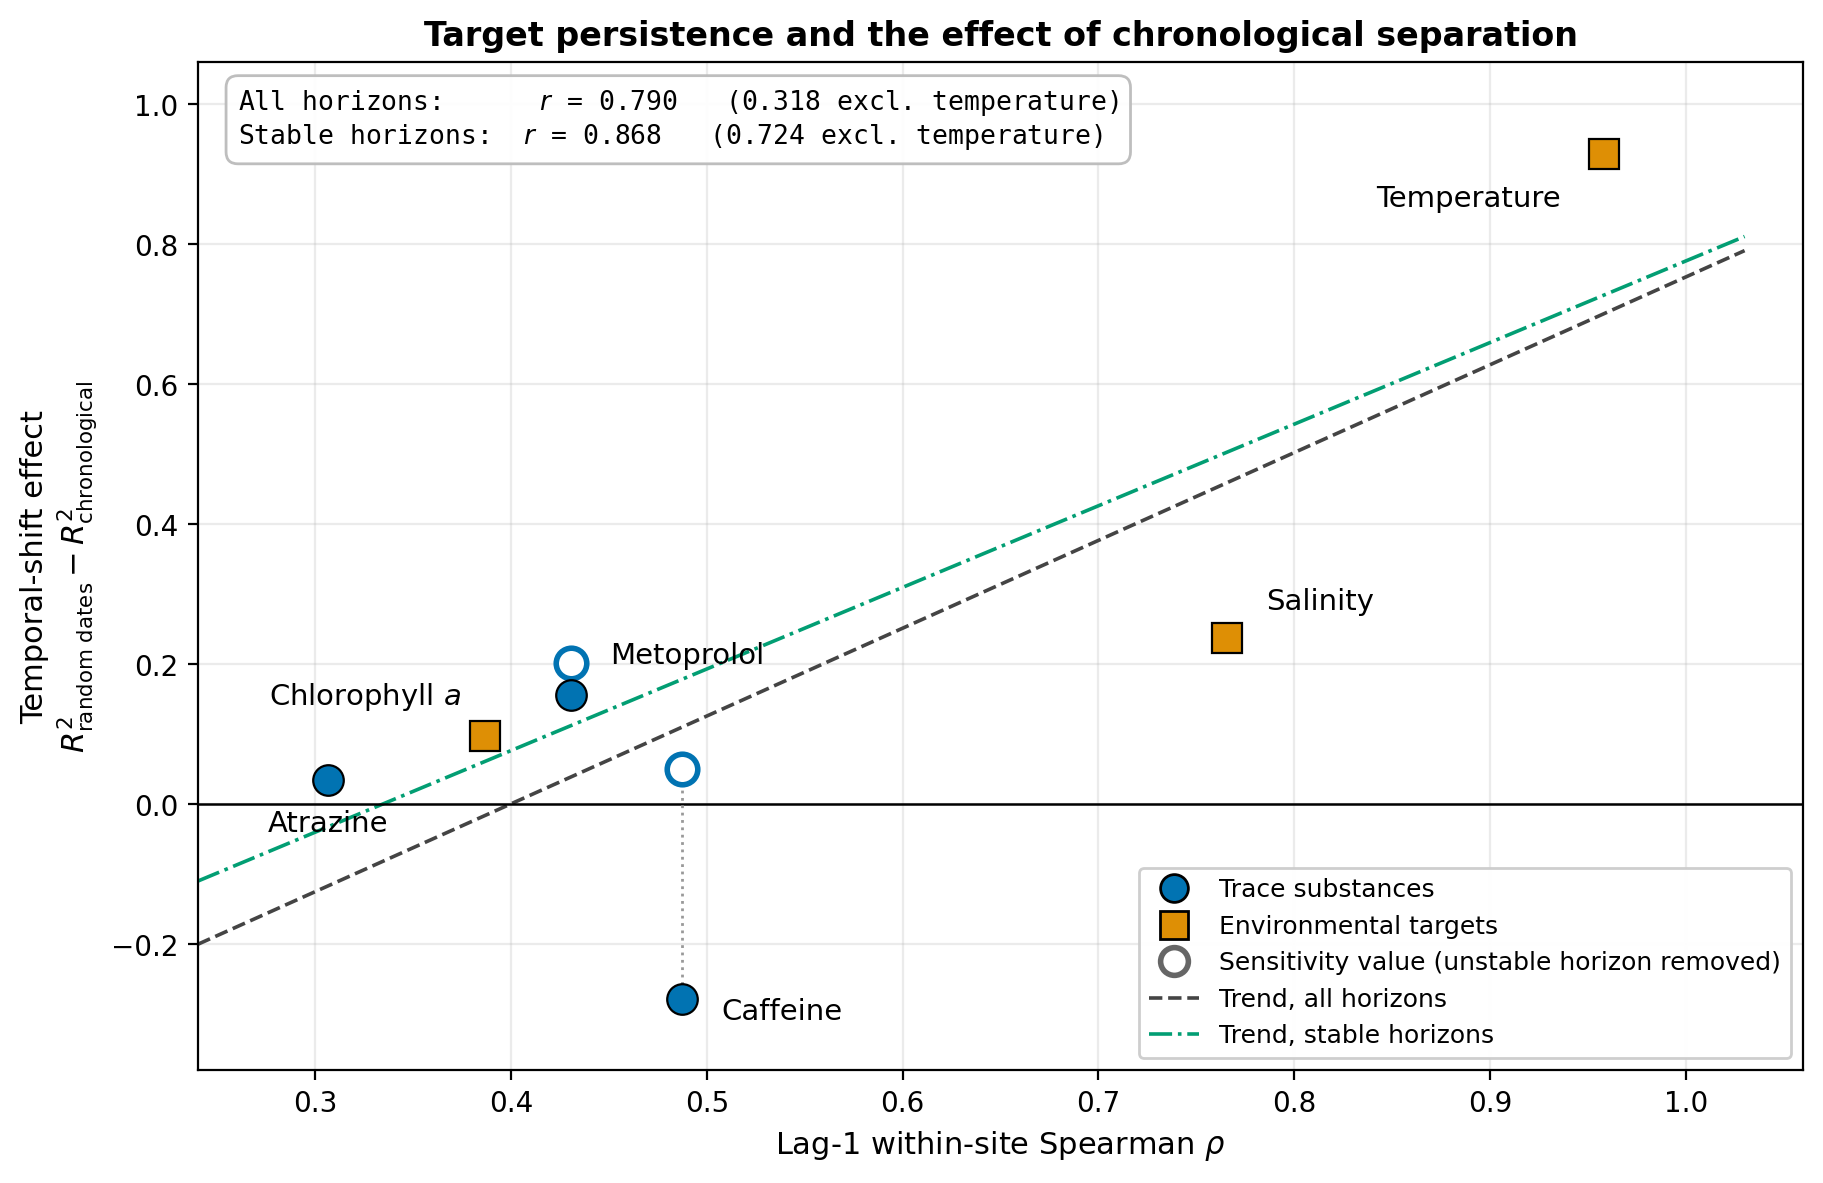

          t   rho   prim  sens  dropped
temperature 0.958  0.928 0.928        0
   salinity 0.766  0.238 0.238        0
Chl_a_log1p 0.387  0.098 0.098        0
   Caffeine 0.487 -0.278 0.050        1
 Metoprolol 0.431  0.156 0.201        1
   Atrazine 0.307  0.035 0.035        0

all horizons   : r = +0.790  (excl. temperature +0.318)
stable horizons: r = +0.868  (excl. temperature +0.724)

unstable cells removed in sensitivity analysis:
target      horizon_k
Caffeine    1            2.052
Metoprolol  3            0.306


In [37]:
# ============================================================
# Figure 8.4 (final) — lag-1 autocorrelation vs temporal-shift effect.
# Primary analysis   : mean over all three horizons.
# Sensitivity analysis: horizons with random-date SD > 0.30 removed.
# ============================================================
import matplotlib.pyplot as plt
import numpy as np, pandas as pd
from pathlib import Path
from scipy.stats import pearsonr
from matplotlib.lines import Line2D
from IPython.display import Image, display

R = Path('/mnt/data/home/tv2414/tabpfn_project/results')
ms = pd.read_csv(R / 'phase3_random_split_multiseed.csv')
ac = pd.read_csv(R / 'temporal_autocorr_summary.csv')

TG = ['temperature', 'salinity', 'Chl_a_log1p',
      'Caffeine', 'Metoprolol', 'Atrazine']
ACK = {'Chl_a_log1p': 'Chl_a'}
LBL = {'temperature': 'Temperature', 'salinity': 'Salinity',
       'Chl_a_log1p': 'Chlorophyll $a$', 'Caffeine': 'Caffeine',
       'Metoprolol': 'Metoprolol', 'Atrazine': 'Atrazine'}
CHEM = {'Caffeine', 'Metoprolol', 'Atrazine'}
SD_MAX = 0.30

mean = ms.groupby(['target', 'horizon_k', 'regime'])['r2'].mean().unstack('regime')
sd   = ms.groupby(['target', 'horizon_k', 'regime'])['r2'].std().unstack('regime')
shift = lambda t, k: mean.loc[(t, k), 'random_dates'] - mean.loc[(t, k), 'temporal']
rho1  = lambda t: float(ac[(ac.target == ACK.get(t, t)) & (ac.k == 1)]
                        ['spearman_med'].iloc[0])

rows = []
for t in TG:
    allk = [shift(t, k) for k in (1, 2, 3)]
    stab = [shift(t, k) for k in (1, 2, 3)
            if sd.loc[(t, k), 'random_dates'] <= SD_MAX]
    rows.append(dict(t=t, rho=rho1(t), prim=np.mean(allk),
                     sens=np.mean(stab) if stab else np.nan,
                     dropped=3 - len(stab)))
d = pd.DataFrame(rows)

r_p  = pearsonr(d['rho'].to_numpy(), d['prim'].to_numpy())
sub  = d[d['t'] != 'temperature']
r_pn = pearsonr(sub['rho'].to_numpy(), sub['prim'].to_numpy())
r_s  = pearsonr(d['rho'].to_numpy(), d['sens'].to_numpy())
r_sn = pearsonr(sub['rho'].to_numpy(), sub['sens'].to_numpy())

fig, ax = plt.subplots(figsize=(9.0, 5.8), constrained_layout=True)
ax.axhline(0, color='black', lw=0.9, zorder=2)

xs = np.linspace(0.24, 1.03, 50)
for col, key, ls, lab in [('#444444', 'prim', '--', 'Trend, all horizons'),
                          ('#029E73', 'sens', '-.', 'Trend, stable horizons')]:
    b, a = np.polyfit(d['rho'], d[key], 1)
    ax.plot(xs, a + b * xs, color=col, lw=1.3, ls=ls, zorder=1, label=lab)

for r in d.itertuples():
    c  = '#0173B2' if r.t in CHEM else '#DE8F05'
    mk = 'o' if r.t in CHEM else 's'
    if r.dropped:                       # sensitivity value, hollow marker
        ax.plot([r.rho, r.rho], [r.prim, r.sens], color='#999999',
                lw=1.0, ls=':', zorder=3)
        ax.plot(r.rho, r.sens, mk, ms=11, color='white',
                markeredgecolor=c, markeredgewidth=2.0, zorder=4)
    ax.plot(r.rho, r.prim, mk, ms=11, color=c,
            markeredgecolor='black', markeredgewidth=0.8, zorder=5)

OFF = {'temperature': (-0.022, -0.075, 'right'),
       'salinity':    (0.020,  0.040, 'left'),
       'Chl_a_log1p': (-0.012,  0.045, 'right'),
       'Caffeine':    (0.020, -0.030, 'left'),
       'Metoprolol':  (0.020,  0.045, 'left'),
       'Atrazine':    (0.000, -0.075, 'center')}
for r in d.itertuples():
    dx, dy, ha = OFF[r.t]
    ax.annotate(LBL[r.t], (r.rho + dx, r.prim + dy), fontsize=10.5, ha=ha)

ax.text(0.025, 0.975,
        f'All horizons:      $r$ = {r_p[0]:.3f}   '
        f'({r_pn[0]:.3f} excl. temperature)\n'
        f'Stable horizons:  $r$ = {r_s[0]:.3f}   '
        f'({r_sn[0]:.3f} excl. temperature)',
        transform=ax.transAxes, fontsize=9.5, va='top', family='monospace',
        bbox=dict(boxstyle='round,pad=0.45', fc='white',
                  ec='#BBBBBB', alpha=0.95))

ax.set_xlabel('Lag-1 within-site Spearman $\\rho$', fontsize=11)
ax.set_ylabel('Temporal-shift effect\n'
              '$R^2_{\\mathrm{random\\ dates}} - R^2_{\\mathrm{chronological}}$',
              fontsize=11)
ax.set_title('Target persistence and the effect of chronological separation',
             fontsize=12, fontweight='bold')
ax.set_xlim(0.24, 1.06)
ax.set_ylim(-0.38, 1.06)
ax.grid(alpha=0.25); ax.set_axisbelow(True)

ax.legend(handles=[
    Line2D([], [], marker='o', ls='', color='#0173B2', ms=10,
           markeredgecolor='black', label='Trace substances'),
    Line2D([], [], marker='s', ls='', color='#DE8F05', ms=10,
           markeredgecolor='black', label='Environmental targets'),
    Line2D([], [], marker='o', ls='', color='white', ms=10,
           markeredgecolor='#666666', markeredgewidth=2,
           label='Sensitivity value (unstable horizon removed)'),
    Line2D([], [], ls='--', color='#444444', lw=1.3,
           label='Trend, all horizons'),
    Line2D([], [], ls='-.', color='#029E73', lw=1.3,
           label='Trend, stable horizons')],
    fontsize=9, loc='lower right', framealpha=0.96)

for ext in ('png', 'pdf'):
    fig.savefig(R / f'fig_8_4_autocorr_vs_shift.{ext}',
                dpi=200, bbox_inches='tight')
plt.close(fig)

display(Image(filename=str(R / 'fig_8_4_autocorr_vs_shift.png')))
print(d.round(3).to_string(index=False))
print(f'\nall horizons   : r = {r_p[0]:+.3f}  '
      f'(excl. temperature {r_pn[0]:+.3f})')
print(f'stable horizons: r = {r_s[0]:+.3f}  '
      f'(excl. temperature {r_sn[0]:+.3f})')
print(f'\nunstable cells removed in sensitivity analysis:')
u = sd[sd['random_dates'] > SD_MAX]['random_dates']
print(u.round(3).to_string())

In [1]:
# ── can we recover the 9 missing Lasso RMSE values? ───────────────────────
import pandas as pd
from pathlib import Path

RESULTS = Path('/mnt/data/home/tv2414/tabpfn_project/results')

las = pd.read_csv(RESULTS / 'phase1_lasso_3targets_3inputs_4strategies.csv')
miss = las[las.rmse_mean.isna()]
print(f'missing RMSE rows: {len(miss)}')
print(miss[['target','input','strategy','r2_mean','mae_mean','n_folds']].to_string(index=False))
print(f'\nall columns: {list(las.columns)}')

# is there an mse column, or an older file with the same cells?
print('\n=== other Lasso files that might contain these cells ===')
for p in sorted(RESULTS.glob('*lasso*.csv')):
    d = pd.read_csv(p)
    has_rmse = 'rmse_mean' in d.columns and d['rmse_mean'].notna().any()
    print(f'  {p.name:52s} rows={len(d):3d} rmse_present={has_rmse}')
    if has_rmse and {'target','input','strategy'}.issubset(d.columns):
        m = d[(d.strategy == 'random_kfold') & d.rmse_mean.notna()]
        if len(m):
            print(f'      → has {len(m)} random_kfold rows WITH rmse:')
            print(m[['target','input','rmse_mean']].round(4).to_string(index=False))

missing RMSE rows: 9
       target   input     strategy  r2_mean  mae_mean  n_folds
  temperature     16S random_kfold   0.6746     2.578        5
  temperature     18S random_kfold   0.7500     1.913        5
  temperature 16S+18S random_kfold   0.8368     1.705        5
     salinity     16S random_kfold   0.6971     1.899        5
     salinity     18S random_kfold   0.7592     1.699        5
     salinity 16S+18S random_kfold   0.8038     1.544        5
Chl_a (log1p)     16S random_kfold   0.4641     0.445        5
Chl_a (log1p)     18S random_kfold   0.5623     0.383        5
Chl_a (log1p) 16S+18S random_kfold   0.6654     0.360        5

all columns: ['strategy', 'input', 'target', 'n_folds', 'n_samples', 'n_features', 'r2_mean', 'r2_std', 'mae_mean', 'mae_std', 'rmse_mean', 'rmse_std', 'alpha_mean', 'n_selected_mean', 'total_time']

=== other Lasso files that might contain these cells ===
  phase1_comparison_lasso_vs_xgboost.csv               rows= 54 rmse_present=True
  phase1_

In [3]:
# ── do the older Lasso files contain the 9 missing random_kfold RMSE values? ──
import pandas as pd
from pathlib import Path

RESULTS = Path('/mnt/data/home/tv2414/tabpfn_project/results')
ENV = ['temperature', 'salinity', 'Chl_a (log1p)', 'Chl_a_log1p']

for f in ['phase1_lasso_3targets_3inputs.csv',
          'phase1_lasso_3newstrategies.csv',
          'phase1_comparison_lasso_vs_xgboost.csv',
          'phase1_lasso_3targets_16s.csv']:
    d = pd.read_csv(RESULTS / f)
    print('=' * 70)
    print(f'{f}   shape={d.shape}')
    print(f'columns: {list(d.columns)}')
    if 'strategy' in d.columns:
        sub = d[d.strategy.astype(str).str.contains('random', case=False, na=False)]
        if len(sub):
            cols = [c for c in ['target','input','strategy','r2_mean','mae_mean',
                                'rmse_mean','model'] if c in sub.columns]
            print(sub[cols].round(4).to_string(index=False))
    else:
        print(d.head(8).to_string(index=False))
    print()

phase1_lasso_3targets_3inputs.csv   shape=(13, 12)
columns: ['model', 'input', 'target', 'transform', 'n_features', 'n_samples', 'r2_mean', 'r2_std', 'mae_mean', 'mae_std', 'rmse_mean', 'rmse_std']
     model      input      target transform  n_features  n_samples  r2_mean  r2_std  mae_mean  mae_std  rmse_mean  rmse_std
Month-only month-only temperature      none           1       1223   0.9293  0.0072     1.329    0.054      1.667     0.072
Month-only month-only    salinity      none           1       1217   0.2301  0.0595     3.323    0.168      4.582     0.338
Month-only month-only       Chl_a     log1p           1       1437   0.0715  0.0221     0.749    0.026      0.905     0.039
     Lasso        16S temperature      none        1236       1223   0.6746  0.0584     2.578    0.045      3.561     0.221
     Lasso        16S    salinity      none        1236       1217   0.6971  0.0474     1.899    0.090      2.857     0.141
     Lasso        16S       Chl_a      none        1236   

In [4]:
# ── extract all 9 missing Lasso random-kfold RMSE values ──────────────────
import pandas as pd
from pathlib import Path

RESULTS = Path('/mnt/data/home/tv2414/tabpfn_project/results')
old = pd.read_csv(RESULTS / 'phase1_lasso_3targets_3inputs.csv')
print('=== full file (13 rows) ===')
print(old.to_string(index=False))

# keep only the Lasso rows that match the benchmark configuration
las = old[(old.model == 'Lasso') &
          ~((old.target == 'Chl_a') & (old.transform == 'none'))].copy()
las['target'] = las['target'].replace({'Chl_a': 'Chl_a (log1p)'})
print(f'\n=== usable Lasso rows: {len(las)} (need 9) ===')
print(las[['input','target','r2_mean','mae_mean','rmse_mean']].round(4).to_string(index=False))

# verify against the locked table
lock = pd.read_csv(RESULTS / 'phase1_lasso_3targets_3inputs_4strategies.csv')
lock_r = lock[lock.strategy == 'random_kfold'][['target','input','r2_mean','mae_mean']]
chk = las[['target','input','r2_mean','mae_mean','rmse_mean']].merge(
    lock_r, on=['target','input'], suffixes=('_old','_locked'), how='outer', indicator=True)
chk['r2_diff']  = (chk.r2_mean_old  - chk.r2_mean_locked).abs()
chk['mae_diff'] = (chk.mae_mean_old - chk.mae_mean_locked).abs()
print('\n=== match check (r2_diff and mae_diff should be 0) ===')
print(chk[['target','input','r2_mean_locked','r2_mean_old','r2_diff',
           'mae_diff','rmse_mean','_merge']].round(5).to_string(index=False))
print(f"\nrows matching perfectly: {((chk.r2_diff < 1e-4) & (chk.mae_diff < 1e-3)).sum()} / 9")

=== full file (13 rows) ===
     model      input      target transform  n_features  n_samples  r2_mean  r2_std  mae_mean  mae_std  rmse_mean  rmse_std
Month-only month-only temperature      none           1       1223   0.9293  0.0072     1.329    0.054      1.667     0.072
Month-only month-only    salinity      none           1       1217   0.2301  0.0595     3.323    0.168      4.582     0.338
Month-only month-only       Chl_a     log1p           1       1437   0.0715  0.0221     0.749    0.026      0.905     0.039
     Lasso        16S temperature      none        1236       1223   0.6746  0.0584     2.578    0.045      3.561     0.221
     Lasso        16S    salinity      none        1236       1217   0.6971  0.0474     1.899    0.090      2.857     0.141
     Lasso        16S       Chl_a      none        1236       1437  -0.2393  1.2980     3.852    0.682     10.291     5.847
     Lasso        16S       Chl_a     log1p        1236       1437   0.4641  0.2271     0.445    0.028  

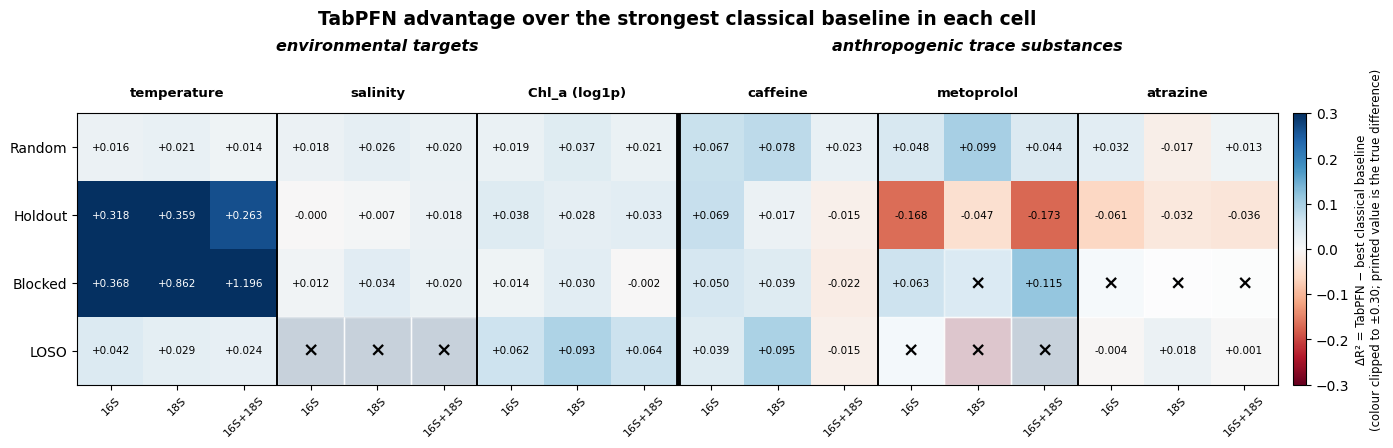

interpretable cells      : 62 / 72   (× marks 10 degenerate cells)
positive ΔR²             : 49
above the 0.005 tolerance: 48
negative beyond tolerance: 10
largest advantage        : +1.196
largest deficit          : -0.173

saved → /mnt/data/home/tv2414/tabpfn_project/results/ch6_figures/figA1_delta_r2_heatmap.pdf


In [8]:
# ── Figure A.1: ΔR² heatmap (TabPFN − best classical baseline), 72 cells ──
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS = Path('/mnt/data/home/tv2414/tabpfn_project/results')
FIGS = RESULTS / 'ch6_figures'; FIGS.mkdir(exist_ok=True)

M     = ['Lasso', 'RF', 'XGBoost', 'TabPFN']
ENV   = ['temperature', 'salinity', 'Chl_a_log1p']
CHEM  = ['Caffeine', 'Metoprolol', 'Atrazine']
ALL_T = ENV + CHEM
TDISP = {'temperature':'temperature', 'salinity':'salinity',
         'Chl_a_log1p':'Chl_a (log1p)', 'Caffeine':'caffeine',
         'Metoprolol':'metoprolol', 'Atrazine':'atrazine'}
I_ORDER = ['16S', '18S', '16S+18S']
S_ORDER = ['random_kfold', 'temporal_holdout',
           'temporal_blocked_kfold', 'leave_one_site_out']
S_DISP  = ['Random', 'Holdout', 'Blocked', 'LOSO']

long = pd.read_csv(RESULTS / 'ch6_full72_long.csv')
w = long.pivot_table(index=['target','input','strategy'],
                     columns='model', values='r2_mean')[M]
w['delta'] = w['TabPFN'] - w[['Lasso','RF','XGBoost']].max(axis=1)
w['best']  = w[M].max(axis=1)

cols = [(t, i) for t in ALL_T for i in I_ORDER]
D    = np.array([[w.loc[(t,i,s), 'delta'] for (t,i) in cols] for s in S_ORDER])
DEG  = np.array([[w.loc[(t,i,s), 'best'] < 0 for (t,i) in cols] for s in S_ORDER])

LIM = 0.30                                   # colour clipping only
fig, ax = plt.subplots(figsize=(16, 4.6))
fig.subplots_adjust(top=0.70)
im = ax.imshow(np.clip(D, -LIM, LIM), cmap='RdBu', vmin=-LIM, vmax=LIM,
               aspect='auto')

for r in range(D.shape[0]):
    for c in range(D.shape[1]):
        if DEG[r, c]:
            ax.add_patch(plt.Rectangle((c-.5, r-.5), 1, 1, color='white',
                                       alpha=.78, zorder=2))
            ax.text(c, r, '×', ha='center', va='center',
                    fontsize=14, fontweight='bold', zorder=3)
        else:
            v = D[r, c]
            ax.text(c, r, f'{v:+.3f}', ha='center', va='center', fontsize=7.5,
                    color='white' if abs(np.clip(v, -LIM, LIM)) > .19 else 'black')

ax.set_xticks(range(len(cols)))
ax.set_xticklabels([i for (_, i) in cols], fontsize=8, rotation=45)
ax.set_yticks(range(4)); ax.set_yticklabels(S_DISP, fontsize=10)
for x in (2.5, 5.5, 11.5, 14.5):
    ax.axvline(x, color='black', lw=1.4)
ax.axvline(8.5, color='black', lw=3.5)
for g, t in enumerate(ALL_T):
    ax.text(g*3 + 1, -0.70, TDISP[t], ha='center', va='bottom',
            fontsize=9.5, fontweight='bold', clip_on=False)
ax.text(4,  -1.42, 'environmental targets', ha='center', fontsize=11.5,
        fontweight='bold', style='italic', clip_on=False)
ax.text(13, -1.42, 'anthropogenic trace substances', ha='center', fontsize=11.5,
        fontweight='bold', style='italic', clip_on=False)

cb = fig.colorbar(im, ax=ax, fraction=.020, pad=.012)
cb.set_label('ΔR² = TabPFN − best classical baseline\n'
             '(colour clipped to ±0.30; printed value is the true difference)',
             fontsize=8.5)
ax.set_title('TabPFN advantage over the strongest classical baseline in each cell',
             fontweight='bold', fontsize=13.5, pad=64)

for ext in ('png', 'pdf'):
    fig.savefig(FIGS / f'figA1_delta_r2_heatmap.{ext}', dpi=300,
                bbox_inches='tight')
plt.show()

# ---- summary printed for the caption / text ----
interp = D[~DEG]
print(f'interpretable cells      : {len(interp)} / 72   '
      f'(× marks {int(DEG.sum())} degenerate cells)')
print(f'positive ΔR²             : {int((interp > 0).sum())}')
print(f'above the 0.005 tolerance: {int((interp > 0.005).sum())}')
print(f'negative beyond tolerance: {int((interp < -0.005).sum())}')
print(f'largest advantage        : {interp.max():+.3f}')
print(f'largest deficit          : {interp.min():+.3f}')
print(f'\nsaved → {FIGS}/figA1_delta_r2_heatmap.pdf')

In [9]:
# ── which cells are degenerate? both figures must agree ───────────────────
import pandas as pd
from pathlib import Path

RESULTS = Path('/mnt/data/home/tv2414/tabpfn_project/results')
long = pd.read_csv(RESULTS / 'ch6_full72_long.csv')
M = ['Lasso','RF','XGBoost','TabPFN']
w = long.pivot_table(index=['target','input','strategy'],
                     columns='model', values='r2_mean')[M]
deg = w[w.max(axis=1) < 0]
print(f'cells where NO model reaches R² > 0: {len(deg)}')
print(deg.round(4).to_string())

cells where NO model reaches R² > 0: 10
model                                          Lasso       RF  XGBoost   TabPFN
target     input   strategy                                                    
Atrazine   16S     temporal_blocked_kfold    -0.0910  -0.1012  -0.1045  -0.0412
           16S+18S temporal_blocked_kfold    -0.0581  -0.1368  -0.6436  -0.0455
           18S     temporal_blocked_kfold    -0.0468  -0.2042  -0.7043  -0.0432
Metoprolol 16S     leave_one_site_out        -2.0477  -1.7685  -2.1181  -1.7025
           16S+18S leave_one_site_out      -138.6538  -1.8970  -2.3219  -1.4579
           18S     leave_one_site_out      -135.5747  -2.8401  -1.6957  -2.1418
                   temporal_blocked_kfold    -1.2510  -0.1789  -0.2404  -0.0199
salinity   16S     leave_one_site_out       -44.4136 -26.3063 -21.9691  -8.2956
           16S+18S leave_one_site_out     -1728.6179 -29.9356 -22.8293 -13.9414
           18S     leave_one_site_out     -1532.8187 -60.1234 -55.9923 -35.1616


In [1]:
# ============================================================
# Appendix B — complete forecasting grid (216 runs).
# Six targets x three inputs x three horizons x four models,
# each with its three model-free baselines and the skill margin.
# READ ONLY with respect to the results; writes only the table files.
# ============================================================
import numpy as np, pandas as pd
from pathlib import Path

R = Path('/mnt/data/home/tv2414/tabpfn_project/results')
pd.set_option('display.width', 250, 'display.max_rows', 250)

# ---- 1. load and harmonise the two result files ----
chem = pd.read_csv(R / 'phase3_forecasting_shared_mask_splitB_unifiedcut.csv')
env  = pd.read_csv(R / 'phase1_forecasting_shared_mask_splitB.csv')
print('chemical :', chem.shape, list(chem.columns))
print('environmental:', env.shape, list(env.columns))

fc = pd.concat([chem, env], ignore_index=True)
print('\ncombined :', fc.shape)
print('models   :', sorted(fc.model.unique()))
print('targets  :', sorted(fc.target.unique()))
print('inputs   :', sorted(fc.input.unique()))

# ---- 2. attach the strongest model-free baseline per target-horizon ----
mas = pd.read_csv(R / 'chapter8_master_forecasting_table.csv')
mas.columns = ['target', 'horizon_k', 'tab16_r2',
               'best_baseline', 'baseline_r2', 'skill', 'verdict']

NAME = {'temperature': 'Temperature', 'salinity': 'Salinity',
        'Chl_a_log1p': 'Chlorophyll a', 'Chl_a': 'Chlorophyll a',
        'Caffeine': 'Caffeine', 'Metoprolol': 'Metoprolol',
        'Atrazine': 'Atrazine'}
fc['tgt']  = fc['target'].map(lambda s: NAME.get(s, s))
mas['tgt'] = mas['target'].map(lambda s: NAME.get(s, str(s).capitalize()))

fc = fc.merge(mas[['tgt', 'horizon_k', 'best_baseline', 'baseline_r2']],
              on=['tgt', 'horizon_k'], how='left')
missing = fc['baseline_r2'].isna().sum()
print(f'\nrows without a matched baseline: {missing}')
if missing:
    print(sorted(fc[fc.baseline_r2.isna()][['tgt', 'horizon_k']]
                 .drop_duplicates().itertuples(index=False)))

fc['skill'] = fc['r2'] - fc['baseline_r2']

# ---- 3. order and format ----
MODEL = {'tabpfn': 'TabPFN', 'random_forest': 'Random Forest',
         'xgboost': 'XGBoost', 'lasso': 'Lasso'}
fc['Model'] = fc['model'].map(lambda s: MODEL.get(s, s))
T_ORDER = ['Temperature', 'Salinity', 'Chlorophyll a',
           'Caffeine', 'Metoprolol', 'Atrazine']
M_ORDER = ['TabPFN', 'Random Forest', 'XGBoost', 'Lasso']
I_ORDER = ['16S', '18S', '16S+18S']
fc['tgt']   = pd.Categorical(fc['tgt'], T_ORDER, ordered=True)
fc['Model'] = pd.Categorical(fc['Model'], M_ORDER, ordered=True)
fc['input'] = pd.Categorical(fc['input'], I_ORDER, ordered=True)
fc = fc.sort_values(['tgt', 'horizon_k', 'input', 'Model'])

BASE = {'persistence': 'Persistence', 'site_mean': 'Site mean',
        'global_mean': 'Global mean'}
out = pd.DataFrame({
    'Target':   fc['tgt'].astype(str),
    'k':        fc['horizon_k'].astype(int),
    'Input':    fc['input'].astype(str),
    'Model':    fc['Model'].astype(str),
    'R2':       fc['r2'].round(3),
    'MAE':      fc['mae'].round(3),
    'n_test':   fc['n_test'].astype(int),
    'Baseline': fc['best_baseline'].map(lambda s: BASE.get(s, s)),
    'Base_R2':  fc['baseline_r2'].round(3),
    'Skill':    fc['skill'].round(3),
})
print(f'\nfinal table: {out.shape[0]} rows')

# ---- 4. sanity checks against the chapter ----
print('\n--- checks ---')
t16 = out[(out.Model == 'TabPFN') & (out.Input == '16S')]
print(f'TabPFN x 16S rows           : {len(t16)}  (expect 18)')
print(f'cells with Skill > 0.03     : {(t16.Skill > 0.03).sum()}  (expect 5)')
best = (out.loc[out.groupby(["Target", "k", "Input"], observed=True)["R2"]
                 .idxmax(), ['Target', 'k', 'Input', 'Model']])
chem_best = best[best.Target.isin(['Caffeine', 'Metoprolol', 'Atrazine'])]
print('\nbest model per chemical cell, all inputs:')
print(chem_best.Model.value_counts().to_string())
print('\nbest model per chemical cell, 16S only:')
print(chem_best[chem_best.Input == '16S'].Model.value_counts().to_string())

# ---- 5. write markdown + LaTeX ----
def fmt(v):
    return f'{v:,.3f}' if isinstance(v, float) else str(v)

cols = list(out.columns)
lines = ['| ' + ' | '.join(cols) + ' |',
         '|' + '|'.join(['---'] * 4 + [':---:'] * (len(cols) - 4)) + '|']
prev = None
for _, r in out.iterrows():
    lab = [str(r['Target']), str(r['k']), str(r['Input'])]
    if prev and lab[0] == prev[0]:
        lab[0] = ''
        if lab[1] == prev[1]:
            lab[1] = ''
            if lab[2] == prev[2]:
                lab[2] = ''
    prev = [str(r['Target']), str(r['k']), str(r['Input'])]
    lines.append('| ' + ' | '.join(lab + [str(r['Model'])] +
                                   [fmt(r[c]) for c in cols[4:]]) + ' |')
(R / 'appendix_B_forecasting_216.md').write_text('\n'.join(lines),
                                                 encoding='utf-8')

tex = [r'\begin{longtable}{llll' + 'r' * (len(cols) - 4) + '}',
       r'\caption{Complete forecasting grid: six targets, three sequencing '
       r'inputs, three horizons, and four models under the unique-date cutoff '
       r'of 19 January 2023. Skill is the model $R^2$ minus the strongest of '
       r'the three model-free baselines.}\\',
       r'\label{tab:appendix_forecasting}\\', r'\toprule',
       ' & '.join(c.replace('_', r'\_') for c in cols) + r' \\', r'\midrule',
       r'\endfirsthead', r'\toprule',
       ' & '.join(c.replace('_', r'\_') for c in cols) + r' \\', r'\midrule',
       r'\endhead', r'\bottomrule', r'\endfoot']
for _, r in out.iterrows():
    tex.append(' & '.join([str(r[c]).replace('&', r'\&') if isinstance(r[c], str)
                           else fmt(r[c]) for c in cols]) + r' \\')
tex.append(r'\end{longtable}')
(R / 'appendix_B_forecasting_216.tex').write_text('\n'.join(tex),
                                                  encoding='utf-8')
out.to_csv(R / 'appendix_B_forecasting_216.csv', index=False)

print('\nwritten: appendix_B_forecasting_216.{csv,md,tex}')
print('\nfirst 24 rows:')
print(out.head(24).to_string(index=False))

chemical : (108, 13) ['model', 'target', 'input', 'horizon_k', 'n_train', 'n_test', 'r2', 'mae', 'rmse', 'per_r2', 'per_mae', 'delta_r2', 'global_cut']
environmental: (108, 13) ['model', 'target', 'input', 'horizon_k', 'n_train', 'n_test', 'r2', 'mae', 'rmse', 'per_r2', 'per_mae', 'delta_r2', 'total_time']

combined : (216, 14)
models   : ['lasso', 'random_forest', 'tabpfn', 'xgboost']
targets  : ['Atrazine', 'Caffeine', 'Chl_a_log1p', 'Metoprolol', 'salinity', 'temperature']
inputs   : ['16S', '16S+18S', '18S']

rows without a matched baseline: 0

final table: 216 rows

--- checks ---
TabPFN x 16S rows           : 18  (expect 18)
cells with Skill > 0.03     : 5  (expect 5)

best model per chemical cell, all inputs:
Model
TabPFN           12
Random Forest    10
XGBoost           4
Lasso             1

best model per chemical cell, 16S only:
Model
TabPFN           4
Random Forest    4
Lasso            1

written: appendix_B_forecasting_216.{csv,md,tex}

first 24 rows:
     Target  k   I

In [2]:
import pandas as pd
from pathlib import Path

R = Path('/mnt/data/home/tv2414/tabpfn_project/results')
out = pd.read_csv(R / 'appendix_B_forecasting_216.csv')

pd.set_option('display.max_rows', None,
              'display.width', 200,
              'display.max_columns', None)
print(f'{len(out)} rows\n')
print(out.to_string(index=False))

216 rows

       Target  k   Input         Model        R2     MAE  n_test    Baseline  Base_R2     Skill
  Temperature  1     16S        TabPFN     0.135   1.797     373 Persistence    0.783    -0.648
  Temperature  1     16S Random Forest    -0.348   2.259     373 Persistence    0.783    -1.131
  Temperature  1     16S       XGBoost    -0.456   2.322     373 Persistence    0.783    -1.239
  Temperature  1     16S         Lasso  -845.109  15.006     373 Persistence    0.783  -845.892
  Temperature  1     18S        TabPFN     0.074   1.922     373 Persistence    0.783    -0.709
  Temperature  1     18S Random Forest    -1.114   2.703     373 Persistence    0.783    -1.897
  Temperature  1     18S       XGBoost    -0.993   2.645     373 Persistence    0.783    -1.776
  Temperature  1     18S         Lasso  -708.976  33.718     373 Persistence    0.783  -709.759
  Temperature  1 16S+18S        TabPFN     0.174   1.789     373 Persistence    0.783    -0.609
  Temperature  1 16S+18S Rando

In [3]:
import pandas as pd
from pathlib import Path
from IPython.display import display, Markdown

R = Path('/mnt/data/home/tv2414/tabpfn_project/results')
out = pd.read_csv(R / 'appendix_B_forecasting_216.csv')

T_ORDER = ['Temperature', 'Salinity', 'Chlorophyll a',
           'Caffeine', 'Metoprolol', 'Atrazine']

for t in T_ORDER:
    sub = out[out.Target == t].drop(columns=['Target'])
    display(Markdown(f'### {t}   ({len(sub)} runs)'))
    print(sub.to_string(index=False))
    print()

### Temperature   (36 runs)

 k   Input         Model       R2    MAE  n_test    Baseline  Base_R2    Skill
 1     16S        TabPFN    0.135  1.797     373 Persistence    0.783   -0.648
 1     16S Random Forest   -0.348  2.259     373 Persistence    0.783   -1.131
 1     16S       XGBoost   -0.456  2.322     373 Persistence    0.783   -1.239
 1     16S         Lasso -845.109 15.006     373 Persistence    0.783 -845.892
 1     18S        TabPFN    0.074  1.922     373 Persistence    0.783   -0.709
 1     18S Random Forest   -1.114  2.703     373 Persistence    0.783   -1.897
 1     18S       XGBoost   -0.993  2.645     373 Persistence    0.783   -1.776
 1     18S         Lasso -708.976 33.718     373 Persistence    0.783 -709.759
 1 16S+18S        TabPFN    0.174  1.789     373 Persistence    0.783   -0.609
 1 16S+18S Random Forest   -1.505  2.804     373 Persistence    0.783   -2.288
 1 16S+18S       XGBoost   -0.883  2.466     373 Persistence    0.783   -1.666
 1 16S+18S         Lasso   -5.487  3.677     373 Per

### Salinity   (36 runs)

 k   Input         Model      R2    MAE  n_test    Baseline  Base_R2   Skill
 1     16S        TabPFN   0.496  2.446     374 Persistence    0.517  -0.020
 1     16S Random Forest   0.555  2.278     374 Persistence    0.517   0.038
 1     16S       XGBoost   0.525  2.411     374 Persistence    0.517   0.008
 1     16S         Lasso  -4.320  5.591     374 Persistence    0.517  -4.837
 1     18S        TabPFN   0.618  2.107     374 Persistence    0.517   0.101
 1     18S Random Forest   0.534  2.322     374 Persistence    0.517   0.018
 1     18S       XGBoost   0.496  2.421     374 Persistence    0.517  -0.021
 1     18S         Lasso -14.630  9.417     374 Persistence    0.517 -15.147
 1 16S+18S        TabPFN   0.559  2.293     374 Persistence    0.517   0.042
 1 16S+18S Random Forest   0.557  2.254     374 Persistence    0.517   0.040
 1 16S+18S       XGBoost   0.550  2.301     374 Persistence    0.517   0.033
 1 16S+18S         Lasso -38.056 12.280     374 Persistence    0.517 -38.573

### Chlorophyll a   (36 runs)

...

 k   Input         Model        R2     MAE  n_test  Baseline  Base_R2     Skill
 1     16S        TabPFN     0.123  13.167     272 Site mean    0.043     0.081
 1     16S Random Forest     0.157  13.564     272 Site mean    0.043     0.114
 1     16S       XGBoost    -0.195  16.798     272 Site mean    0.043    -0.237
 1     16S         Lasso     0.050  15.085     272 Site mean    0.043     0.008
 1     18S        TabPFN     0.210  11.499     272 Site mean    0.043     0.167
 1     18S Random Forest     0.200  12.568     272 Site mean    0.043     0.158
 1     18S       XGBoost     0.179  11.948     272 Site mean    0.043     0.137
 1     18S         Lasso    -0.789  18.295     272 Site mean    0.043    -0.832
 1 16S+18S        TabPFN     0.134  13.312     272 Site mean    0.043     0.091
 1 16S+18S Random Forest     0.171  13.164     272 Site mean    0.043     0.128
 1 16S+18S       XGBoost     0.188  12.527     272 Site mean    0.043     0.145
 1 16S+18S         Lasso     0.074  13.1

### Metoprolol   (36 runs)

 k   Input         Model    R2    MAE  n_test    Baseline  Base_R2  Skill
 1     16S        TabPFN 0.021 12.329     276   Site mean    0.144 -0.122
 1     16S Random Forest 0.157 14.018     276   Site mean    0.144  0.013
 1     16S       XGBoost 0.133 13.389     276   Site mean    0.144 -0.011
 1     16S         Lasso 0.164 15.484     276   Site mean    0.144  0.020
 1     18S        TabPFN 0.079 11.932     276   Site mean    0.144 -0.065
 1     18S Random Forest 0.105 13.690     276   Site mean    0.144 -0.038
 1     18S       XGBoost 0.114 14.283     276   Site mean    0.144 -0.030
 1     18S         Lasso 0.045 17.222     276   Site mean    0.144 -0.099
 1 16S+18S        TabPFN 0.064 12.161     276   Site mean    0.144 -0.080
 1 16S+18S Random Forest 0.147 13.647     276   Site mean    0.144  0.003
 1 16S+18S       XGBoost 0.163 13.367     276   Site mean    0.144  0.019
 1 16S+18S         Lasso 0.122 15.441     276   Site mean    0.144 -0.021
 2     16S        TabPFN 0.075 11.986 

### Atrazine   (36 runs)

 k   Input         Model     R2   MAE  n_test    Baseline  Base_R2  Skill
 1     16S        TabPFN  0.004 0.101     272 Global mean   -0.042  0.046
 1     16S Random Forest -0.030 0.136     272 Global mean   -0.042  0.012
 1     16S       XGBoost -0.028 0.159     272 Global mean   -0.042  0.014
 1     16S         Lasso -0.022 0.171     272 Global mean   -0.042  0.020
 1     18S        TabPFN  0.014 0.105     272 Global mean   -0.042  0.056
 1     18S Random Forest -0.111 0.194     272 Global mean   -0.042 -0.069
 1     18S       XGBoost -0.626 0.179     272 Global mean   -0.042 -0.584
 1     18S         Lasso -0.342 0.153     272 Global mean   -0.042 -0.300
 1 16S+18S        TabPFN  0.018 0.107     272 Global mean   -0.042  0.060
 1 16S+18S Random Forest -0.068 0.163     272 Global mean   -0.042 -0.026
 1 16S+18S       XGBoost -0.377 0.155     272 Global mean   -0.042 -0.335
 1 16S+18S         Lasso -0.146 0.118     272 Global mean   -0.042 -0.104
 2     16S        TabPFN  0.007 0.109 

In [4]:
print((R / 'appendix_B_forecasting_216.md').read_text()[:3000])

| Target | k | Input | Model | R2 | MAE | n_test | Baseline | Base_R2 | Skill |
|---|---|---|---|:---:|:---:|:---:|:---:|:---:|:---:|
| Temperature | 1 | 16S | TabPFN | 0.135 | 1.797 | 373 | Persistence | 0.783 | -0.648 |
|  |  |  | Random Forest | -0.348 | 2.259 | 373 | Persistence | 0.783 | -1.131 |
|  |  |  | XGBoost | -0.456 | 2.322 | 373 | Persistence | 0.783 | -1.239 |
|  |  |  | Lasso | -845.109 | 15.006 | 373 | Persistence | 0.783 | -845.892 |
|  |  | 18S | TabPFN | 0.074 | 1.922 | 373 | Persistence | 0.783 | -0.709 |
|  |  |  | Random Forest | -1.114 | 2.703 | 373 | Persistence | 0.783 | -1.897 |
|  |  |  | XGBoost | -0.993 | 2.645 | 373 | Persistence | 0.783 | -1.776 |
|  |  |  | Lasso | -708.976 | 33.718 | 373 | Persistence | 0.783 | -709.759 |
|  |  | 16S+18S | TabPFN | 0.174 | 1.789 | 373 | Persistence | 0.783 | -0.609 |
|  |  |  | Random Forest | -1.505 | 2.804 | 373 | Persistence | 0.783 | -2.288 |
|  |  |  | XGBoost | -0.883 | 2.466 | 373 | Persistence | 0.783 | -1.666 

In [1]:
# ============================================================
# Appendix C — complete split-regime diagnostic (six targets x
# three horizons x three regimes, five seeds for the random ones).
# ============================================================
import numpy as np, pandas as pd
from pathlib import Path

R = Path('/mnt/data/home/tv2414/tabpfn_project/results')
ms = pd.read_csv(R / 'phase3_random_split_multiseed.csv')

NAME = {'temperature': 'Temperature', 'salinity': 'Salinity',
        'Chl_a_log1p': 'Chlorophyll a', 'Caffeine': 'Caffeine',
        'Metoprolol': 'Metoprolol', 'Atrazine': 'Atrazine'}
T_ORDER = list(NAME.values())

mean = ms.groupby(['target', 'horizon_k', 'regime'])['r2'].mean().unstack('regime')
sd   = ms.groupby(['target', 'horizon_k', 'regime'])['r2'].std().unstack('regime')
nte  = ms.groupby(['target', 'horizon_k'])['n_test'].mean()

rows = []
for (t, k) in mean.index:
    m, s = mean.loc[(t, k)], sd.loc[(t, k)]
    rows.append({
        'Target': NAME.get(t, t), 'k': int(k),
        'Chronological': round(m['temporal'], 3),
        'Random dates': f"{m['random_dates']:+.3f} ± {s['random_dates']:.3f}",
        'Random pairs': f"{m['random_pairs']:+.3f} ± {s['random_pairs']:.3f}",
        'Date increment': round(m['random_dates'] - m['temporal'], 3),
        'Pair increment': round(m['random_pairs'] - m['random_dates'], 3),
        'Unstable': 'yes' if s['random_dates'] > 0.30 else '',
    })
out = pd.DataFrame(rows)
out['Target'] = pd.Categorical(out['Target'], T_ORDER, ordered=True)
out = out.sort_values(['Target', 'k']).reset_index(drop=True)

out.to_csv(R / 'appendix_C_split_regime.csv', index=False)

cols = list(out.columns)
md = ['| ' + ' | '.join(cols) + ' |',
      '|' + '|'.join(['---'] * 2 + [':---:'] * (len(cols) - 2)) + '|']
for _, r in out.iterrows():
    md.append('| ' + ' | '.join(str(r[c]) for c in cols) + ' |')
(R / 'appendix_C_split_regime.md').write_text('\n'.join(md), encoding='utf-8')

print(f'{len(out)} rows written to appendix_C_split_regime.{{csv,md}}\n')
print(out.to_string(index=False))

18 rows written to appendix_C_split_regime.{csv,md}

       Target  k  Chronological   Random dates   Random pairs  Date increment  Pair increment Unstable
  Temperature  1          0.135 +0.863 ± 0.139 +0.976 ± 0.003           0.728           0.113         
  Temperature  2         -0.166 +0.936 ± 0.040 +0.977 ± 0.001           1.102           0.041         
  Temperature  3         -0.007 +0.949 ± 0.021 +0.976 ± 0.004           0.955           0.028         
     Salinity  1          0.496 +0.727 ± 0.108 +0.855 ± 0.012           0.231           0.127         
     Salinity  2          0.431 +0.731 ± 0.143 +0.849 ± 0.008           0.300           0.118         
     Salinity  3          0.527 +0.711 ± 0.111 +0.846 ± 0.010           0.184           0.135         
Chlorophyll a  1          0.539 +0.533 ± 0.074 +0.638 ± 0.033          -0.006           0.104         
Chlorophyll a  2          0.465 +0.628 ± 0.110 +0.671 ± 0.018           0.163           0.043         
Chlorophyll a  3    

In [1]:
import pandas as pd, numpy as np
from pathlib import Path

R = Path("/mnt/data/home/tv2414/tabpfn_project/results")
f = R / "phase1_tabpfn_v3_3targets_3inputs_4strategies.csv"
df = pd.read_csv(f)

print("=== SCHEMA ===")
print(df.columns.tolist())
print(df.shape)
print(df.head(3).to_string())
print("\n=== UNIQUE VALUES ===")
for c in df.columns:
    if df[c].dtype == object or df[c].nunique() < 12:
        print(f"{c}: {sorted(df[c].dropna().unique().tolist())[:12]}")

=== SCHEMA ===
['target_display', 'target', 'input', 'strategy', 'log_target', 'n_samples', 'n_features', 'n_folds', 'r2_mean', 'r2_std', 'mae_mean', 'mae_std', 'rmse_mean', 'rmse_std', 'total_time', 'notes', 'tabpfn_version', 'model_path']
(36, 18)
  target_display       target input                strategy  log_target  n_samples  n_features  n_folds  r2_mean  r2_std  mae_mean  mae_std  rmse_mean  rmse_std  total_time                 notes tabpfn_version                                                               model_path
0    temperature  temperature   16S            random_kfold       False       1223        1236        5   0.9852  0.0010     0.565    0.021      0.763     0.034        12.3  no_tuning_pretrained          8.0.6  /mnt/data/home/tv2414/.cache/tabpfn/tabpfn-v3-regressor-v3_default.ckpt
1    temperature  temperature   16S        temporal_holdout       False       1223        1236        1   0.6336  0.0000     1.088    0.000      1.378     0.000         2.8  no_tuning_

In [2]:
import pandas as pd
from pathlib import Path

R = Path("/mnt/data/home/tv2414/tabpfn_project/results")

for p in sorted(R.glob("*.csv")):
    try:
        d = pd.read_csv(p, nrows=5)
        cols = d.columns.tolist()
        has_model = any(c.lower() in ("model","model_name","estimator") for c in cols)
        has_fold  = any("fold" in c.lower() and c.lower() != "n_folds" for c in cols)
        n = sum(1 for _ in open(p)) - 1
        flag = ("MODEL " if has_model else "      ") + ("PERFOLD" if has_fold else "       ")
        print(f"{flag} {n:>6} rows  {p.name}")
        print(f"                     {cols}")
    except Exception as e:
        print(f"  !! {p.name}: {e}")

MODEL            216 rows  appendix_B_forecasting_216.csv
                     ['Target', 'k', 'Input', 'Model', 'R2', 'MAE', 'n_test', 'Baseline', 'Base_R2', 'Skill']
                  18 rows  appendix_C_split_regime.csv
                     ['Target', 'k', 'Chronological', 'Random dates', 'Random pairs', 'Date increment', 'Pair increment', 'Unstable']
                  18 rows  baselines_modelfree_decomposition.csv
                     ['target', 'k', 'n_pairs', 'r2_persistence', 'mae_persistence', 'r2_site_mean', 'mae_site_mean', 'r2_global_mean', 'mae_global_mean', 'temporal_gain']
MODEL           5160 rows  ch6_censored_pred_probe.csv
                     ['target', 'model', 'y_true', 'y_pred']
MODEL            288 rows  ch6_full72_long.csv
                     ['target', 'input', 'strategy', 'r2_mean', 'mae_mean', 'rmse_mean', 'model']
MODEL           3096 rows  ch6_lost_cells_probe.csv
                     ['target', 'input', 'strategy', 'model', 'y_true', 'y_pred']
MODEL PERFO

In [3]:
import pandas as pd, numpy as np
from pathlib import Path
pd.set_option("display.width", 200)

R = Path("/mnt/data/home/tv2414/tabpfn_project/results")
d = pd.read_csv(R / "ch6_full72_long.csv")

print("=== SANITY ===")
print("rows:", len(d))
print("targets   :", sorted(d.target.unique()))
print("inputs    :", sorted(d.input.unique()))
print("strategies:", sorted(d.strategy.unique()))
print("models    :", sorted(d.model.unique()))
print("cells x models:", d.groupby(['target','input','strategy']).size().value_counts().to_dict())
print("NaNs:", d[['r2_mean','mae_mean','rmse_mean']].isna().sum().to_dict())

# --- identity check: rmse / std_test  ==  sqrt(1 - r2) ---
print("\n=== NORMALISATION IDENTITY ===")
print("nRMSE by test variance is sqrt(1-R2) by construction -> carries no extra information.")
print("Therefore RMSE is reported in the target's native unit.")

# ---------- TABLE A : headline, R2 and RMSE side by side ----------
order_s = ['random_kfold','temporal_holdout','temporal_blocked_kfold','leave_one_site_out']
order_m = ['Lasso','Random Forest','XGBoost','TabPFN']
ms = [m for m in order_m if m in d.model.unique()] or sorted(d.model.unique())

print("\n=== TABLE A : median over cells, by strategy x model ===")
for tgt in sorted(d.target.unique()):
    sub = d[d.target == tgt]
    rows = []
    for s in [x for x in order_s if x in sub.strategy.unique()]:
        r = {'strategy': s}
        for m in ms:
            c = sub[(sub.strategy == s) & (sub.model == m)]
            r[f'{m} R2']   = round(c.r2_mean.median(), 3)
            r[f'{m} RMSE'] = round(c.rmse_mean.median(), 3)
        rows.append(r)
    print(f"\n--- {tgt} ---")
    print(pd.DataFrame(rows).to_string(index=False))

# ---------- win counts: does RMSE agree with R2? ----------
print("\n=== WIN COUNTS ACROSS 72 CELLS ===")
g = d.groupby(['target','input','strategy'])
w_r2   = g.apply(lambda x: x.loc[x.r2_mean.idxmax(),   'model']).value_counts()
w_rmse = g.apply(lambda x: x.loc[x.rmse_mean.idxmin(), 'model']).value_counts()
w_mae  = g.apply(lambda x: x.loc[x.mae_mean.idxmin(),  'model']).value_counts()
print(pd.DataFrame({'by R2': w_r2, 'by MAE': w_mae, 'by RMSE': w_rmse}).fillna(0).astype(int).to_string())

# disagreements between R2 winner and RMSE winner
dis = g.apply(lambda x: pd.Series({
    'r2_winner':   x.loc[x.r2_mean.idxmax(),   'model'],
    'rmse_winner': x.loc[x.rmse_mean.idxmin(), 'model']})).reset_index()
dis = dis[dis.r2_winner != dis.rmse_winner]
print(f"\ncells where R2 and RMSE disagree: {len(dis)} / 72")
if len(dis): print(dis.to_string(index=False))

# ---------- TABLE B : reliability floor, R2 vs RMSE ----------
print("\n=== TABLE B : RELIABILITY FLOOR ===")
rows = []
for m in ms:
    s = d[d.model == m]
    worst = s.loc[s.r2_mean.idxmin()]
    rows.append({
        'model': m,
        'median R2': round(s.r2_mean.median(), 3),
        'worst R2': round(s.r2_mean.min(), 2),
        'worst cell': f"{worst.target}/{worst.input}/{worst.strategy}",
        'n R2<0': int((s.r2_mean < 0).sum()),
        'n R2<-1': int((s.r2_mean < -1).sum()),
        'median RMSE': round(s.rmse_mean.median(), 3),
        'worst RMSE': round(s.rmse_mean.max(), 2),
    })
print(pd.DataFrame(rows).to_string(index=False))

# is the floor claim scale-free? rank of each model's RMSE within its cell
d['rmse_rank'] = g['rmse_mean'].rank(method='min')
print("\nRMSE rank distribution within cell (1 = best of 4):")
print(pd.crosstab(d.model, d.rmse_rank).to_string())
print("\nworst-rank (4th of 4) count per model:")
print((d[d.rmse_rank == 4].model.value_counts()).to_string())

=== SANITY ===
rows: 288
targets   : ['Atrazine', 'Caffeine', 'Chl_a_log1p', 'Metoprolol', 'salinity', 'temperature']
inputs    : ['16S', '16S+18S', '18S']
strategies: ['leave_one_site_out', 'random_kfold', 'temporal_blocked_kfold', 'temporal_holdout']
models    : ['Lasso', 'RF', 'TabPFN', 'XGBoost']
cells x models: {4: 72}
NaNs: {'r2_mean': 0, 'mae_mean': 0, 'rmse_mean': 9}

=== NORMALISATION IDENTITY ===
nRMSE by test variance is sqrt(1-R2) by construction -> carries no extra information.
Therefore RMSE is reported in the target's native unit.

=== TABLE A : median over cells, by strategy x model ===

--- Atrazine ---
              strategy  Lasso R2  Lasso RMSE  XGBoost R2  XGBoost RMSE  TabPFN R2  TabPFN RMSE
          random_kfold     0.071       0.707      -0.034         0.730      0.168        0.671
      temporal_holdout    -0.011       0.596      -0.658         0.763     -0.014        0.597
temporal_blocked_kfold    -0.058       0.664      -0.644         0.831     -0.043      

In [4]:
import pandas as pd, numpy as np
from pathlib import Path
pd.set_option("display.width", 250)

R = Path("/mnt/data/home/tv2414/tabpfn_project/results")
d = pd.read_csv(R / "ch6_full72_long.csv")

# ---- fix 1: recover the 9 missing Lasso RMSE values ----
print("=== MISSING RMSE ===")
print(d[d.rmse_mean.isna()][['target','input','strategy','model']].to_string(index=False))
lz = pd.read_csv(R / "phase1_lasso_3targets_3inputs.csv")
print("\nlasso helper file:")
print(lz[['model','input','target','r2_mean','rmse_mean']].to_string(index=False))

# ---- fix 2: use the real model names ----
ms = ['Lasso','RF','XGBoost','TabPFN']
assert set(ms) == set(d.model.unique()), sorted(d.model.unique())
order_s = ['random_kfold','temporal_holdout','temporal_blocked_kfold','leave_one_site_out']

print("\n=== TABLE A (all four models) ===")
for tgt in ['temperature','salinity','Chl_a_log1p','Caffeine','Metoprolol','Atrazine']:
    sub = d[d.target == tgt]
    rows = []
    for s in order_s:
        r = {'strategy': s}
        for m in ms:
            c = sub[(sub.strategy == s) & (sub.model == m)]
            r[f'{m} R2']   = round(c.r2_mean.median(), 3)
            r[f'{m} RMSE'] = round(c.rmse_mean.median(), 3)
        rows.append(r)
    print(f"\n--- {tgt} ---")
    print(pd.DataFrame(rows).to_string(index=False))

# ---- reliability floor, now including RF ----
print("\n=== TABLE B (all four models) ===")
g = d.groupby(['target','input','strategy'])
d['rmse_rank'] = g['rmse_mean'].rank(method='min')
d['r2_rank']   = g['r2_mean'].rank(method='min', ascending=False)
rows = []
for m in ms:
    s = d[d.model == m]
    rows.append({'model': m,
        'median R2': round(s.r2_mean.median(),3), 'worst R2': round(s.r2_mean.min(),2),
        'n R2<0': int((s.r2_mean<0).sum()), 'n R2<-1': int((s.r2_mean<-1).sum()),
        'median RMSE': round(s.rmse_mean.median(),3),
        'RMSE rank1': int((s.rmse_rank==1).sum()), 'RMSE rank4': int((s.rmse_rank==4).sum())})
print(pd.DataFrame(rows).to_string(index=False))

# ---- the two cells where TabPFN is last by RMSE ----
print("\n=== TabPFN worst-ranked cells ===")
print(d[(d.model=='TabPFN') & (d.rmse_rank==4)][['target','input','strategy','r2_mean','rmse_mean']].to_string(index=False))

# ---- how much does R2 exaggerate? per-cell, TabPFN only ----
print("\n=== R2 COLLAPSE vs RMSE INFLATION (TabPFN) ===")
t = d[d.model=='TabPFN'].pivot_table(index=['target','input'], columns='strategy',
                                     values=['r2_mean','rmse_mean'])
for tgt in ['salinity','temperature','Metoprolol']:
    for inp in ['16S','18S','16S+18S']:
        try:
            r0 = t.loc[(tgt,inp),('r2_mean','random_kfold')]
            e0 = t.loc[(tgt,inp),('rmse_mean','random_kfold')]
            for s in ['leave_one_site_out','temporal_blocked_kfold']:
                r1 = t.loc[(tgt,inp),('r2_mean',s)]; e1 = t.loc[(tgt,inp),('rmse_mean',s)]
                print(f"{tgt:12s} {inp:8s} {s:24s} R2 {r0:8.3f} -> {r1:10.3f} | RMSE {e0:7.3f} -> {e1:7.3f} ({e1/e0:.2f}x)")
        except KeyError:
            pass

=== MISSING RMSE ===
     target   input     strategy model
temperature     16S random_kfold Lasso
temperature     18S random_kfold Lasso
temperature 16S+18S random_kfold Lasso
   salinity     16S random_kfold Lasso
   salinity     18S random_kfold Lasso
   salinity 16S+18S random_kfold Lasso
Chl_a_log1p     16S random_kfold Lasso
Chl_a_log1p     18S random_kfold Lasso
Chl_a_log1p 16S+18S random_kfold Lasso

lasso helper file:
     model      input      target  r2_mean  rmse_mean
Month-only month-only temperature   0.9293      1.667
Month-only month-only    salinity   0.2301      4.582
Month-only month-only       Chl_a   0.0715      0.905
     Lasso        16S temperature   0.6746      3.561
     Lasso        16S    salinity   0.6971      2.857
     Lasso        16S       Chl_a  -0.2393     10.291
     Lasso        16S       Chl_a   0.4641      0.675
     Lasso        18S temperature   0.7500      3.083
     Lasso        18S    salinity   0.7592      2.549
     Lasso        18S       C

In [7]:
import pandas as pd, numpy as np
from pathlib import Path
pd.set_option("display.width", 300); pd.set_option("display.max_columns", 60)

R = Path("/mnt/data/home/tv2414/tabpfn_project/results")
d = pd.read_csv(R / "ch6_full72_long.csv")

# ---------- 1. fill the 9 missing Lasso RMSE, matched by R2 (unambiguous) ----------
lz = pd.read_csv(R / "phase1_lasso_3targets_3inputs.csv")
lz = lz[lz["model"] == "Lasso"]
has_tf = "transform" in lz.columns          # column may not exist
miss = d[d.rmse_mean.isna()]
print(f"missing RMSE cells: {len(miss)}")

filled = []
for i, row in miss.iterrows():
    c = lz[(lz["input"] == row["input"]) &
           (np.isclose(lz["r2_mean"], row["r2_mean"], atol=1e-3))]
    if len(c) == 1:
        d.loc[i, "rmse_mean"] = c["rmse_mean"].iloc[0]
        filled.append((row["target"], row["input"], round(row["r2_mean"], 4),
                       c["rmse_mean"].iloc[0],
                       c["transform"].iloc[0] if has_tf else "-"))
    else:
        print(f"  !! {row['target']}/{row['input']}: {len(c)} matches -- check manually")
        print(c.to_string(index=False))

print(pd.DataFrame(filled, columns=["target","input","r2 (join key)","rmse","transform"]
                  ).to_string(index=False))
print("remaining NaN:", int(d.rmse_mean.isna().sum()))

missing RMSE cells: 9
     target   input  r2 (join key)  rmse transform
temperature     16S         0.6746 3.561      none
temperature     18S         0.7500 3.083      none
temperature 16S+18S         0.8368 2.532      none
   salinity     16S         0.6971 2.857      none
   salinity     18S         0.7592 2.549      none
   salinity 16S+18S         0.8038 2.290      none
Chl_a_log1p     16S         0.4641 0.675     log1p
Chl_a_log1p     18S         0.5623 0.606     log1p
Chl_a_log1p 16S+18S         0.6654 0.541     log1p
remaining NaN: 0


In [8]:
import pandas as pd, numpy as np
from pathlib import Path

pd.set_option("display.width", 400)
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 100)

R = Path("/mnt/data/home/tv2414/tabpfn_project/results")

MODELS   = ["Lasso", "RF", "XGBoost", "TabPFN"]
METRICS  = {"r2_mean": "R2", "mae_mean": "MAE", "rmse_mean": "RMSE"}
T_ORDER  = ["temperature", "salinity", "Chl_a_log1p", "Caffeine", "Metoprolol", "Atrazine"]
I_ORDER  = ["16S", "18S", "16S+18S"]
S_ORDER  = ["random_kfold", "temporal_holdout", "temporal_blocked_kfold", "leave_one_site_out"]

# ============================================================
# 1. LOAD
# ============================================================
d = pd.read_csv(R / "ch6_full72_long.csv")
print(f"loaded {len(d)} rows  |  {d['target'].nunique()} targets x "
      f"{d['input'].nunique()} inputs x {d['strategy'].nunique()} strategies x "
      f"{d['model'].nunique()} models")

assert set(d["model"])    == set(MODELS),  sorted(d["model"].unique())
assert set(d["target"])   == set(T_ORDER), sorted(d["target"].unique())
assert set(d["input"])    == set(I_ORDER), sorted(d["input"].unique())
assert set(d["strategy"]) == set(S_ORDER), sorted(d["strategy"].unique())
assert len(d) == 288, len(d)

# ============================================================
# 2. FILL THE 9 MISSING LASSO RMSE VALUES
#    joined on R2 (exact) because the helper file contains both
#    a raw and a log1p row for Chl_a / 16S
# ============================================================
lz = pd.read_csv(R / "phase1_lasso_3targets_3inputs.csv")
lz = lz[lz["model"] == "Lasso"]
has_tf = "transform" in lz.columns

miss = d[d["rmse_mean"].isna()]
print(f"\nmissing RMSE: {len(miss)}")
filled = []
for i, row in miss.iterrows():
    c = lz[(lz["input"] == row["input"]) &
           (np.isclose(lz["r2_mean"], row["r2_mean"], atol=1e-3))]
    if len(c) == 1:
        d.loc[i, "rmse_mean"] = c["rmse_mean"].iloc[0]
        filled.append((row["target"], row["input"], round(row["r2_mean"], 4),
                       c["rmse_mean"].iloc[0],
                       c["transform"].iloc[0] if has_tf else "-"))
    else:
        print(f"  !! {row['target']}/{row['input']}: {len(c)} matches")
        print(c.to_string(index=False))

if filled:
    print(pd.DataFrame(filled, columns=["target","input","r2 join key","rmse","transform"]
                      ).to_string(index=False))
print("remaining NaN:", int(d[list(METRICS)].isna().sum().sum()))

# ============================================================
# 3. LONG -> WIDE   (72 rows x 12 metric columns)
# ============================================================
w = d.pivot_table(index=["target","input","strategy"],
                  columns="model", values=list(METRICS), aggfunc="first")
w.columns = [f"{mdl} {METRICS[met]}" for met, mdl in w.columns]
w = w.reset_index()

# model-major ordering: Lasso R2 | Lasso MAE | Lasso RMSE | RF R2 | ...
w = w[["target","input","strategy"] +
      [f"{m} {x}" for m in MODELS for x in METRICS.values()]]

# ============================================================
# 4. WINNER PER METRIC  (R2 high = good; MAE / RMSE low = good)
# ============================================================
for x, high_is_good in [("R2", True), ("MAE", False), ("RMSE", False)]:
    cols = [f"{m} {x}" for m in MODELS]
    idx  = w[cols].idxmax(axis=1) if high_is_good else w[cols].idxmin(axis=1)
    w[f"best {x}"] = idx.str.replace(f" {x}", "", regex=False)

w["unanimous"] = (w["best R2"] == w["best MAE"]) & (w["best R2"] == w["best RMSE"])

# ============================================================
# 5. SORT
# ============================================================
for col, order in [("target", T_ORDER), ("input", I_ORDER), ("strategy", S_ORDER)]:
    w[col] = pd.Categorical(w[col], categories=order, ordered=True)
w = w.sort_values(["target","input","strategy"]).reset_index(drop=True)
assert len(w) == 72, len(w)

# ============================================================
# 6. PRINT — one block per target so it fits the screen
# ============================================================
num = [c for c in w.columns if any(c.endswith(f" {x}") for x in METRICS.values())]
for tgt in T_ORDER:
    print(f"\n{'='*130}\n{tgt}\n{'='*130}")
    blk = w[w["target"] == tgt].drop(columns=["target","unanimous"])
    print(blk.round(3).to_string(index=False))

# ============================================================
# 7. SUMMARIES
# ============================================================
print(f"\n{'='*60}\nWIN COUNTS ACROSS 72 CELLS\n{'='*60}")
wins = pd.DataFrame({x: w[f"best {x}"].value_counts() for x in METRICS.values()})
print(wins.reindex(MODELS).fillna(0).astype(int).to_string())
print(f"\nall three metrics agree: {int(w['unanimous'].sum())} / 72")

print(f"\n{'='*60}\nCELLS WHERE THE METRICS DISAGREE\n{'='*60}")
dis = w[~w["unanimous"]]
print(dis[["target","input","strategy","best R2","best MAE","best RMSE"]].to_string(index=False))

print(f"\n{'='*60}\nWINS BY STRATEGY (R2)\n{'='*60}")
print(pd.crosstab(w["strategy"], w["best R2"]).reindex(columns=MODELS).fillna(0).astype(int).to_string())

print(f"\n{'='*60}\nWINS BY TARGET (R2)\n{'='*60}")
print(pd.crosstab(w["target"], w["best R2"]).reindex(columns=MODELS).fillna(0).astype(int).to_string())

print(f"\n{'='*60}\nPER-MODEL BEHAVIOUR (72 cells each)\n{'='*60}")
rows = []
for m in MODELS:
    r2, mae, rmse = w[f"{m} R2"], w[f"{m} MAE"], w[f"{m} RMSE"]
    rows.append({"model": m,
                 "median R2": r2.median(), "worst R2": r2.min(),
                 "n R2<0": int((r2 < 0).sum()), "n R2<-1": int((r2 < -1).sum()),
                 "median MAE": mae.median(), "median RMSE": rmse.median(),
                 "wins R2": int((w["best R2"] == m).sum()),
                 "wins MAE": int((w["best MAE"] == m).sum()),
                 "wins RMSE": int((w["best RMSE"] == m).sum())})
print(pd.DataFrame(rows).round(3).to_string(index=False))

# rank within each cell (1 = best of 4), per metric
print(f"\n{'='*60}\nRANK WITHIN CELL  (1 = best of 4)\n{'='*60}")
for x, asc in [("R2", False), ("MAE", True), ("RMSE", True)]:
    cols = [f"{m} {x}" for m in MODELS]
    rk = w[cols].rank(axis=1, ascending=asc, method="min")
    rk.columns = MODELS
    tab = pd.DataFrame({m: rk[m].value_counts() for m in MODELS}).reindex([1,2,3,4]).fillna(0).astype(int)
    print(f"\n-- {x} --")
    print(tab.to_string())

# ============================================================
# 8. EXPORT
# ============================================================
w.to_csv(R / "appendix_A_full72_all_metrics.csv", index=False)
w.round(3).to_csv(R / "appendix_A_full72_all_metrics_rounded.csv", index=False)
try:
    with pd.ExcelWriter(R / "appendix_A_full72_all_metrics.xlsx") as xl:
        w.round(3).to_excel(xl, sheet_name="full_72", index=False)
        for x in METRICS.values():
            sub = w[["target","input","strategy"] + [f"{m} {x}" for m in MODELS] + [f"best {x}"]]
            sub.round(3).to_excel(xl, sheet_name=x, index=False)
    print("\nwritten: .csv, _rounded.csv, .xlsx (4 sheets)")
except Exception as e:
    print(f"\nwritten: .csv, _rounded.csv  (excel skipped: {e})")

loaded 288 rows  |  6 targets x 3 inputs x 4 strategies x 4 models

missing RMSE: 9
     target   input  r2 join key  rmse transform
temperature     16S       0.6746 3.561      none
temperature     18S       0.7500 3.083      none
temperature 16S+18S       0.8368 2.532      none
   salinity     16S       0.6971 2.857      none
   salinity     18S       0.7592 2.549      none
   salinity 16S+18S       0.8038 2.290      none
Chl_a_log1p     16S       0.4641 0.675     log1p
Chl_a_log1p     18S       0.5623 0.606     log1p
Chl_a_log1p 16S+18S       0.6654 0.541     log1p
remaining NaN: 0

temperature
  input               strategy  Lasso R2  Lasso MAE  Lasso RMSE  RF R2  RF MAE  RF RMSE  XGBoost R2  XGBoost MAE  XGBoost RMSE  TabPFN R2  TabPFN MAE  TabPFN RMSE best R2 best MAE best RMSE
    16S           random_kfold     0.675      2.578       3.561  0.966   0.815    1.147       0.969        0.814         1.105      0.985       0.565        0.763  TabPFN   TabPFN    TabPFN
    16S       te

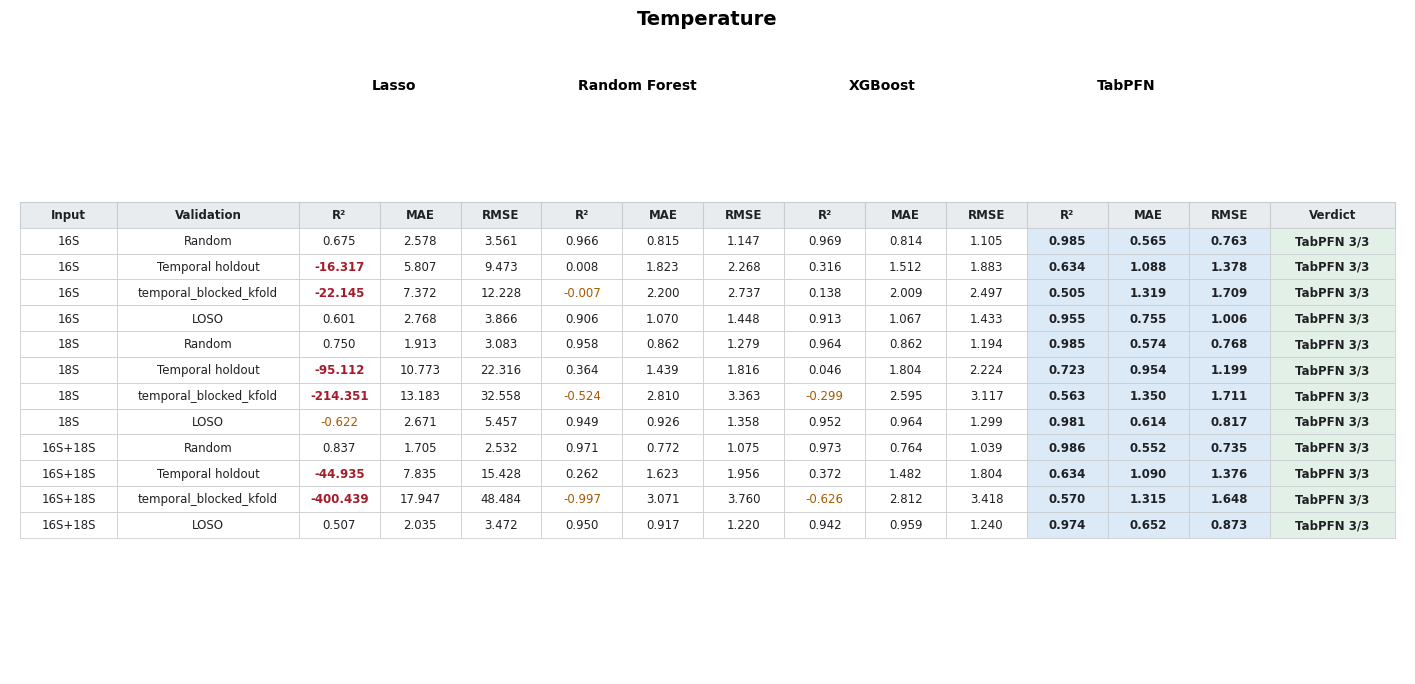

Saved: word_tables/temperature_metrics_table.png


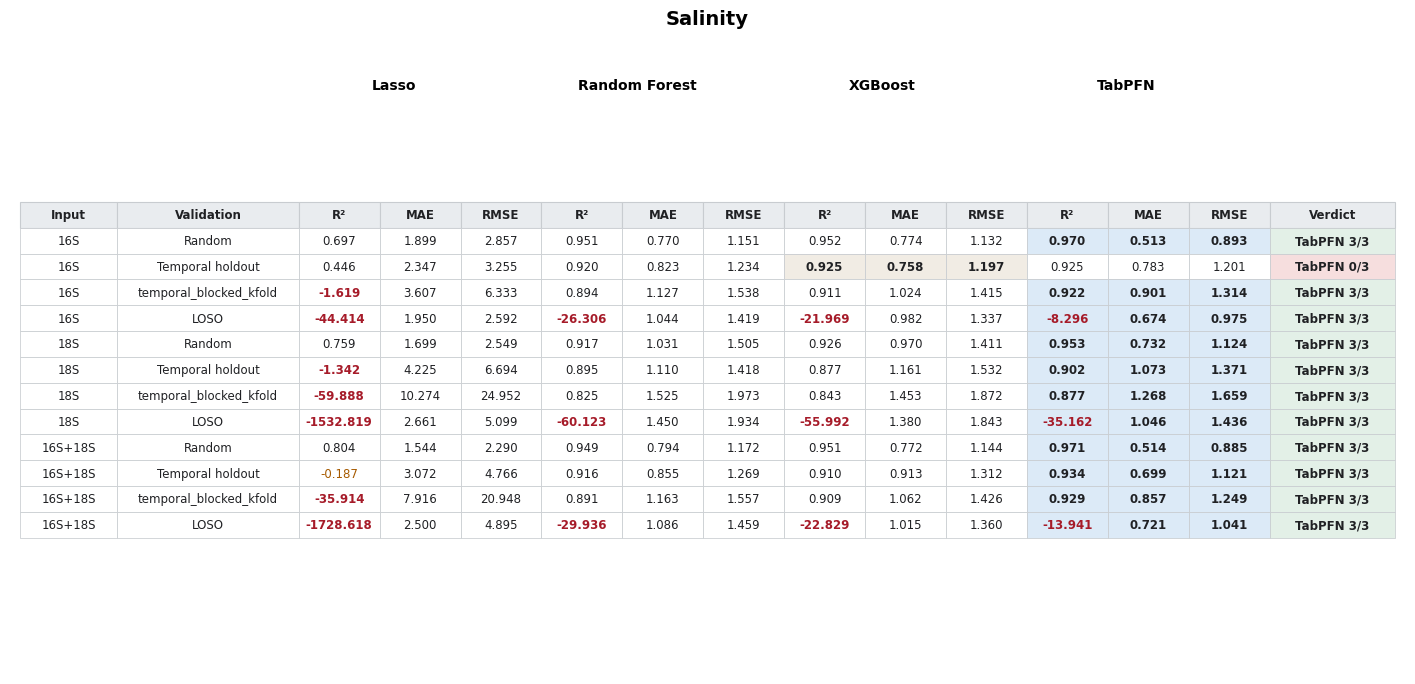

Saved: word_tables/salinity_metrics_table.png


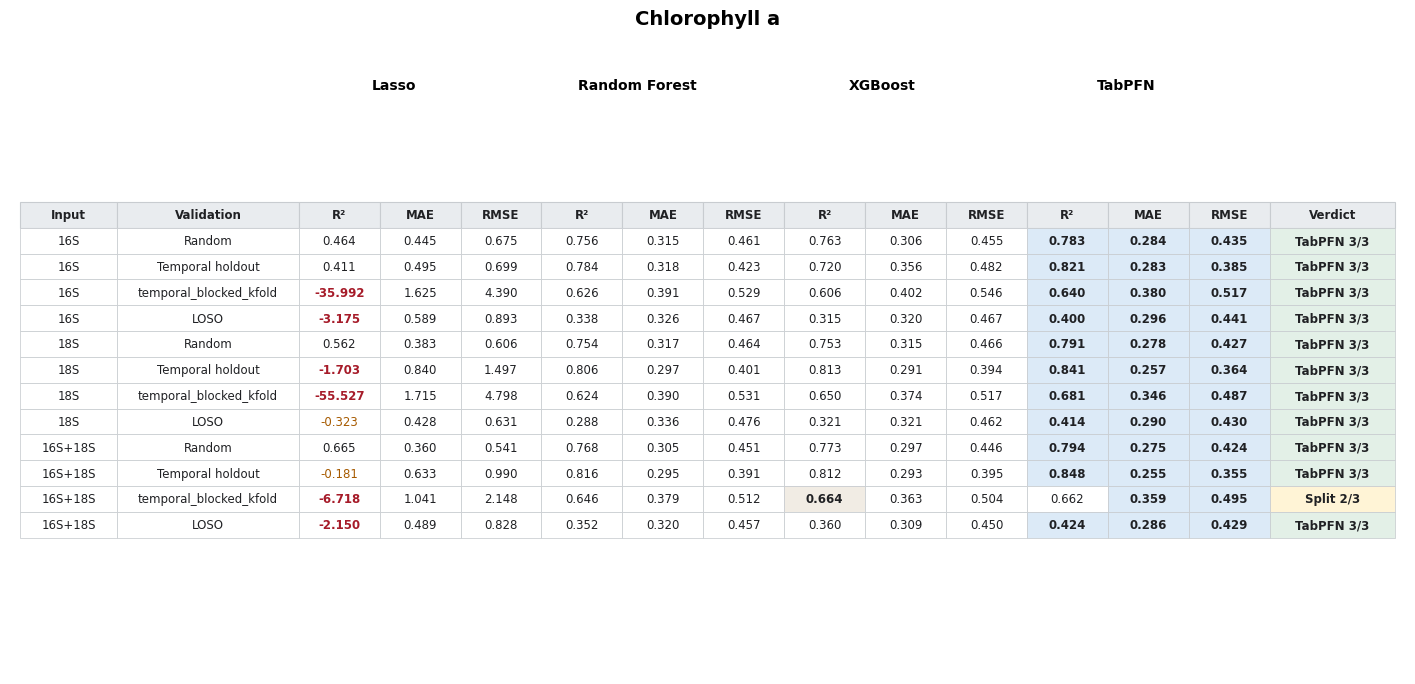

Saved: word_tables/Chl_a_log1p_metrics_table.png


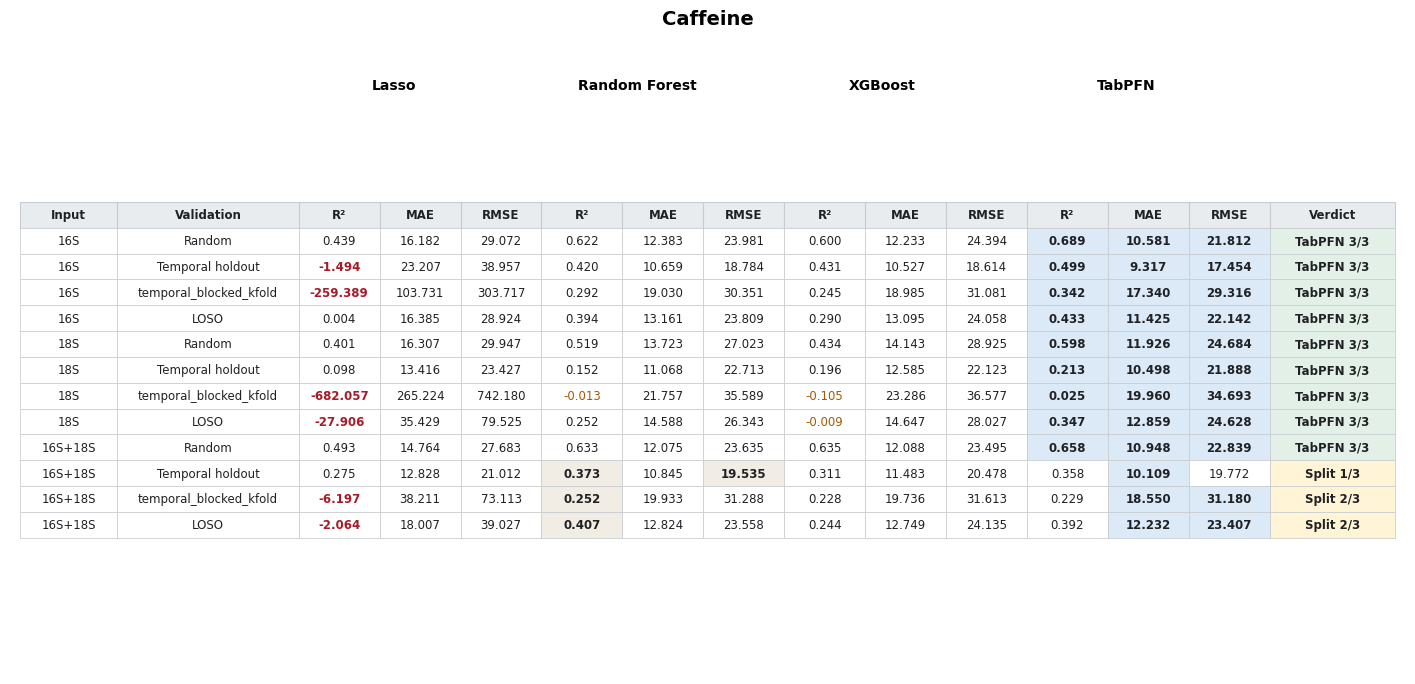

Saved: word_tables/Caffeine_metrics_table.png


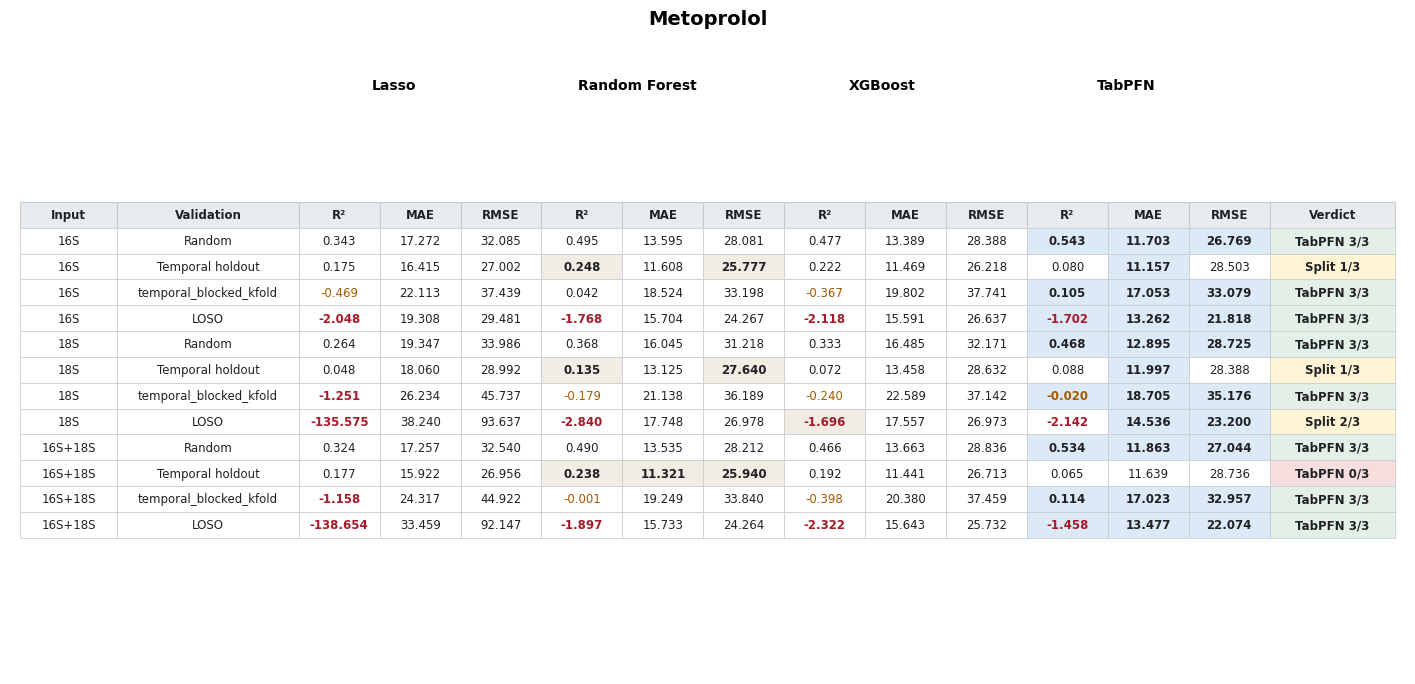

Saved: word_tables/Metoprolol_metrics_table.png


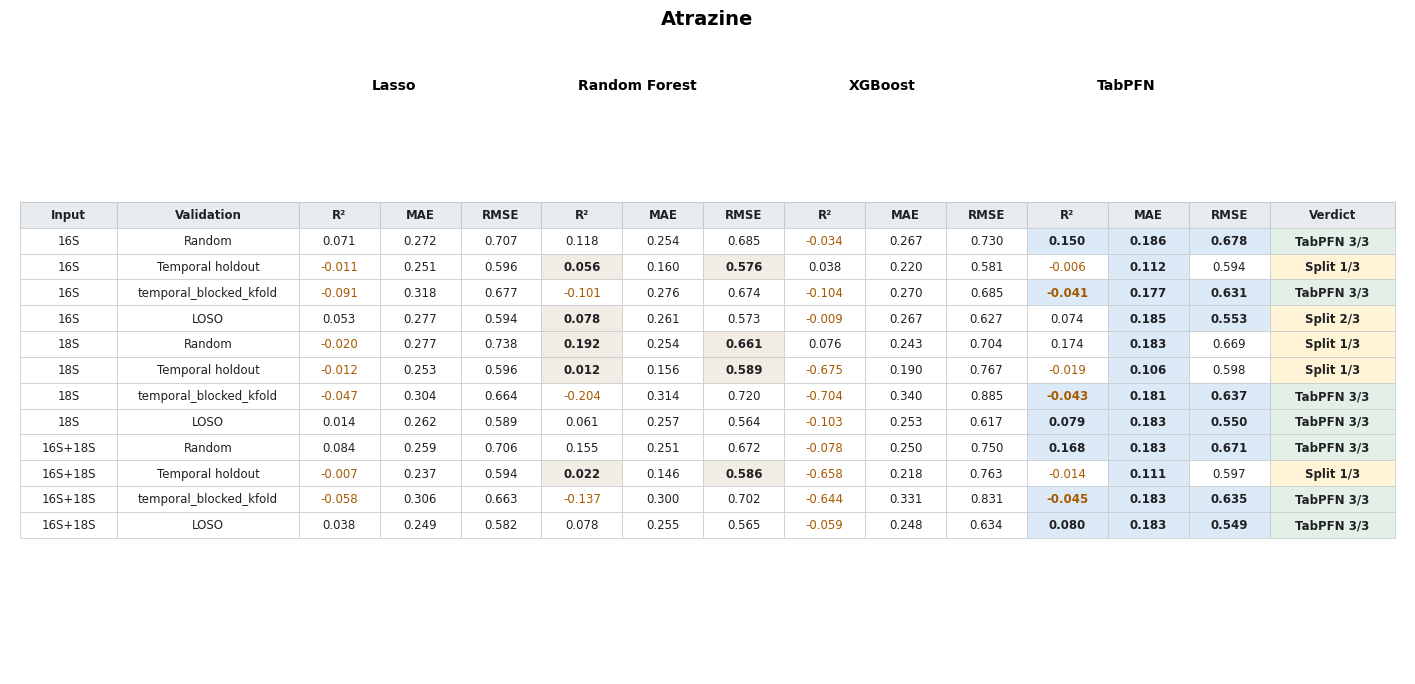

Saved: word_tables/Atrazine_metrics_table.png


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# SETTINGS
# ============================================================

MODELS = ["Lasso", "RF", "XGBoost", "TabPFN"]
MET = ["R2", "MAE", "RMSE"]

v = w.copy()

OUTPUT_DIR = Path("word_tables")
OUTPUT_DIR.mkdir(exist_ok=True)

# ------------------------------------------------------------
# Soft academic colours
# ------------------------------------------------------------
HEADER_COLOR = "#E9ECEF"
TABPFN_COLOR = "#DCEAF7"
CLASSICAL_COLOR = "#F1ECE4"

ALL3_COLOR = "#E3F0E7"
SPLIT_COLOR = "#FFF4D6"
LOST_COLOR = "#F6DEDE"

NEG_R2_COLOR = "#A65A00"
BAD_R2_COLOR = "#A61B29"

GRID_COLOR = "#C8CCD0"
TEXT_COLOR = "#202124"


# ============================================================
# VERDICT
# ============================================================

def get_verdict(r):
    n = sum(r[f"best {metric}"] == "TabPFN" for metric in MET)

    if n == 3:
        return "TabPFN 3/3"
    elif n == 0:
        return "TabPFN 0/3"
    else:
        return f"Split {n}/3"


v["verdict"] = v.apply(get_verdict, axis=1)


# ============================================================
# DISPLAY NAMES
# ============================================================

target_titles = {
    "temperature": "Temperature",
    "salinity": "Salinity",
    "Chl_a_log1p": "Chlorophyll a",
    "Caffeine": "Caffeine",
    "Metoprolol": "Metoprolol",
    "Atrazine": "Atrazine"
}

strategy_names = {
    "random_kfold": "Random",
    "temporal_holdout": "Temporal holdout",
    "temporal_blocked": "Temporal blocked",
    "leave_one_site_out": "LOSO",
    "loso": "LOSO"
}


# ============================================================
# CREATE ONE IMAGE PER TARGET
# ============================================================

def save_target_table(target):

    block = v[v["target"] == target].copy()

    if block.empty:
        print(f"No data found for {target}")
        return

    # --------------------------------------------
    # Construct compact table
    # --------------------------------------------

    rows = []

    for _, r in block.iterrows():

        row = [
            r["input"],
            strategy_names.get(r["strategy"], r["strategy"])
        ]

        for model in MODELS:
            row.extend([
                f'{r[f"{model} R2"]:.3f}',
                f'{r[f"{model} MAE"]:.3f}',
                f'{r[f"{model} RMSE"]:.3f}'
            ])

        row.append(r["verdict"])
        rows.append(row)

    columns = [
        "Input", "Validation",
        "R²", "MAE", "RMSE",
        "R²", "MAE", "RMSE",
        "R²", "MAE", "RMSE",
        "R²", "MAE", "RMSE",
        "Verdict"
    ]

    # --------------------------------------------
    # Figure size
    # --------------------------------------------

    nrows = len(rows)

    fig, ax = plt.subplots(
        figsize=(18, 1.3 + nrows * 0.55)
    )

    ax.axis("off")

    # --------------------------------------------
    # Table
    # --------------------------------------------

    table = ax.table(
        cellText=rows,
        colLabels=columns,
        cellLoc="center",
        colLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(8.5)
    table.scale(1, 1.55)

    # --------------------------------------------
    # Header
    # --------------------------------------------

    for c in range(len(columns)):
        cell = table[(0, c)]

        cell.set_facecolor(HEADER_COLOR)
        cell.set_text_props(
            weight="bold",
            color=TEXT_COLOR
        )

        cell.set_edgecolor(GRID_COLOR)
        cell.set_linewidth(0.8)

    # --------------------------------------------
    # Body formatting
    # --------------------------------------------

    for i, (_, r) in enumerate(block.iterrows(), start=1):

        # borders
        for c in range(len(columns)):
            cell = table[(i, c)]
            cell.set_edgecolor(GRID_COLOR)
            cell.set_linewidth(0.55)
            cell.set_text_props(color=TEXT_COLOR)

        # ----------------------------------------
        # metric winners
        # ----------------------------------------

        for metric_index, metric in enumerate(MET):

            values = {
                model: float(r[f"{model} {metric}"])
                for model in MODELS
            }

            if metric == "R2":
                winner = max(values, key=values.get)
            else:
                winner = min(values, key=values.get)

            for model_index, model in enumerate(MODELS):

                # First metric column starts at 2
                col = 2 + model_index * 3 + metric_index

                cell = table[(i, col)]

                # Winner
                if model == winner:

                    if model == "TabPFN":
                        cell.set_facecolor(TABPFN_COLOR)
                    else:
                        cell.set_facecolor(CLASSICAL_COLOR)

                    cell.set_text_props(
                        weight="bold",
                        color=TEXT_COLOR
                    )

                # --------------------------------
                # Negative R²
                # --------------------------------

                if metric == "R2":

                    value = values[model]

                    if value < -1:
                        cell.set_text_props(
                            color=BAD_R2_COLOR,
                            weight="bold"
                        )

                    elif value < 0:
                        cell.set_text_props(
                            color=NEG_R2_COLOR
                        )

        # ----------------------------------------
        # Verdict
        # ----------------------------------------

        verdict_cell = table[(i, 14)]

        if r["verdict"] == "TabPFN 3/3":

            verdict_cell.set_facecolor(ALL3_COLOR)
            verdict_cell.set_text_props(weight="bold")

        elif r["verdict"] == "TabPFN 0/3":

            verdict_cell.set_facecolor(LOST_COLOR)
            verdict_cell.set_text_props(weight="bold")

        else:

            verdict_cell.set_facecolor(SPLIT_COLOR)
            verdict_cell.set_text_props(weight="bold")

    # --------------------------------------------
    # Column widths
    # --------------------------------------------

    widths = {
        0: 0.07,      # input
        1: 0.13,      # validation
        14: 0.09      # verdict
    }

    for c in range(len(columns)):

        if c in widths:
            width = widths[c]
        else:
            width = 0.058

        for r_idx in range(nrows + 1):
            table[(r_idx, c)].set_width(width)

    # --------------------------------------------
    # Model labels above columns
    # --------------------------------------------

    ax.text(
        0.275, 0.98,
        "Lasso",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=10,
        fontweight="bold"
    )

    ax.text(
        0.45, 0.98,
        "Random Forest",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=10,
        fontweight="bold"
    )

    ax.text(
        0.625, 0.98,
        "XGBoost",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=10,
        fontweight="bold"
    )

    ax.text(
        0.80, 0.98,
        "TabPFN",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=10,
        fontweight="bold"
    )

    # --------------------------------------------
    # Title
    # --------------------------------------------

    ax.set_title(
        target_titles.get(target, target),
        fontsize=14,
        fontweight="bold",
        pad=30
    )

    # --------------------------------------------
    # Save PNG
    # --------------------------------------------

    filename = OUTPUT_DIR / f"{target}_metrics_table.png"

    plt.savefig(
        filename,
        dpi=400,
        bbox_inches="tight",
        facecolor="white",
        pad_inches=0.15
    )

    plt.show()
    plt.close()

    print(f"Saved: {filename}")


# ============================================================
# GENERATE ALL SIX TABLES
# ============================================================

targets = [
    "temperature",
    "salinity",
    "Chl_a_log1p",
    "Caffeine",
    "Metoprolol",
    "Atrazine"
]

for target in targets:
    save_target_table(target)

In [13]:
import pandas as pd, numpy as np
from pathlib import Path
from IPython.display import display, HTML
pd.set_option("display.width", 400); pd.set_option("display.max_columns", 80)

R = Path("/mnt/data/home/tv2414/tabpfn_project/results")

MODELS = ["Lasso", "RF", "XGBoost", "TabPFN"]
MET    = ["R2", "MAE", "RMSE"]
ENV    = ["temperature", "salinity", "Chl_a_log1p"]
CHEM   = ["Caffeine", "Metoprolol", "Atrazine"]

# ============================================================
# 1. LOAD  (environmental + chemical forecasting, same schema)
# ============================================================
f1 = pd.read_csv(R / "phase1_forecasting_shared_mask_splitB.csv")
f3 = pd.read_csv(R / "phase3_forecasting_shared_mask_splitB_unifiedcut.csv")
KEEP = ["model","target","input","horizon_k","n_train","n_test",
        "r2","mae","rmse","per_r2","per_mae"]
f = pd.concat([f1[KEEP], f3[KEEP]], ignore_index=True)

print(f"rows: {len(f)}   ({len(f1)} environmental + {len(f3)} chemical)")
print("models   :", sorted(f['model'].unique()))
print("targets  :", sorted(f['target'].unique()))
print("inputs   :", sorted(f['input'].unique()))
print("horizons :", sorted(f['horizon_k'].unique()))
print("models per cell:",
      f.groupby(['target','input','horizon_k']).size().value_counts().to_dict())
print("NaN:", f[['r2','mae','rmse','per_r2','per_mae']].isna().sum().to_dict())

# normalise model naming if needed
f["model"] = f["model"].replace({
    "lasso": "Lasso",
    "random_forest": "RF",  "randomforest": "RF",
    "Random Forest": "RF",  "RandomForest": "RF",
    "xgboost": "XGBoost",
    "tabpfn":  "TabPFN",
})
assert set(f["model"]) == set(MODELS), sorted(f["model"].unique())

# ============================================================
# 2. DERIVE TEST VARIANCE  ->  persistence RMSE
#    RMSE^2 = (1 - R^2) * var(y_test)   on a shared mask
# ============================================================
f["var_y"] = f["rmse"]**2 / (1 - f["r2"])

chk = f.groupby(["target","input","horizon_k"])["var_y"].agg(["min","max","mean"])
chk["spread"] = (chk["max"] - chk["min"]) / chk["mean"]
bad = chk[chk["spread"] > 0.02]
print(f"\nvariance-recovery check: {len(bad)} of {len(chk)} cells disagree by >2% across models")
if len(bad):
    print("  !! derivation unsafe in these cells, persistence RMSE left blank:")
    print(bad.round(4).to_string())

cellvar = f.groupby(["target","input","horizon_k"])["var_y"].median().rename("var_cell")
f = f.merge(cellvar, on=["target","input","horizon_k"])
f.loc[f.index[f.set_index(["target","input","horizon_k"]).index.isin(bad.index)], "var_cell"] = np.nan
f["per_rmse"] = np.sqrt(np.clip(1 - f["per_r2"], 0, None) * f["var_cell"])

# ============================================================
# 3. LONG -> WIDE   (54 cells x 4 models x 3 metrics)
# ============================================================
w = f.pivot_table(index=["target","horizon_k","input"], columns="model",
                  values=["r2","mae","rmse"], aggfunc="first")
ren = {"r2":"R2","mae":"MAE","rmse":"RMSE"}
w.columns = [f"{mdl} {ren[met]}" for met, mdl in w.columns]
w = w.reset_index()

per = (f.groupby(["target","horizon_k","input"])[["per_r2","per_mae","per_rmse","n_test"]]
         .median().reset_index()
         .rename(columns={"per_r2":"Pers R2","per_mae":"Pers MAE","per_rmse":"Pers RMSE"}))
w = w.merge(per, on=["target","horizon_k","input"])

NUM = [f"{m} {x}" for m in MODELS for x in MET]
w = w[["target","horizon_k","input","n_test"] + NUM + ["Pers R2","Pers MAE","Pers RMSE"]]

# ============================================================
# 4. WINNERS + DOES THE MODEL BEAT PERSISTENCE
# ============================================================
for x, high in [("R2",True), ("MAE",False), ("RMSE",False)]:
    cols = [f"{m} {x}" for m in MODELS]
    idx  = w[cols].idxmax(axis=1) if high else w[cols].idxmin(axis=1)
    w[f"best {x}"] = idx.str.replace(f" {x}", "", regex=False)

w["TabPFN>pers R2"]   = w["TabPFN R2"]   >  w["Pers R2"]
w["TabPFN>pers MAE"]  = w["TabPFN MAE"]  <  w["Pers MAE"]
w["TabPFN>pers RMSE"] = w["TabPFN RMSE"] <  w["Pers RMSE"]

def verdict(r):
    n = sum(r[f"best {x}"] == "TabPFN" for x in MET)
    return {3:"TabPFN — all 3", 0:"LOST — all 3"}.get(n, f"split ({n}/3)")
w["verdict"] = w.apply(verdict, axis=1)

T_ORDER = ENV + CHEM
w["target"] = pd.Categorical(w["target"], categories=T_ORDER, ordered=True)
w["input"]  = pd.Categorical(w["input"], categories=["16S","18S","16S+18S"], ordered=True)
w = w.sort_values(["target","horizon_k","input"]).reset_index(drop=True)
print(f"\nwide table: {w.shape[0]} cells x {w.shape[1]} columns")

# ============================================================
# 5. COLOURED DISPLAY
# ============================================================
def style_row(r):
    css = pd.Series("", index=r.index)
    for x in MET:
        cols = [f"{m} {x}" for m in MODELS]
        vals = r[cols].astype(float)
        win  = vals.idxmax() if x == "R2" else vals.idxmin()
        for c in cols:
            s = ""
            if c == win:
                s += "font-weight:700;"
                s += "background-color:#CFE4F7;" if c.startswith("TabPFN") else "background-color:#FBDFC0;"
            if x == "R2":
                if   vals[c] < -1: s += "color:#B00020;font-weight:700;"
                elif vals[c] <  0: s += "color:#D96C00;"
            css[c] = s
        pc = f"Pers {x}"
        beat = (r["TabPFN "+x] > r[pc]) if x == "R2" else (r["TabPFN "+x] < r[pc])
        css[pc] = "background-color:#EDEDED;" + ("" if beat else "color:#B00020;font-weight:700;")
    vd = r["verdict"]
    css["verdict"] = ("background-color:#D8F0DC;" if vd.startswith("TabPFN")
                      else "background-color:#F8C9C4;font-weight:700;" if vd.startswith("LOST")
                      else "background-color:#FFF3C4;")
    return css

SHOW = ["horizon_k","input","n_test"] + NUM + ["Pers R2","Pers MAE","Pers RMSE","verdict"]
for tgt in T_ORDER:
    blk = w[w["target"] == tgt][SHOW]
    display(blk.style.apply(style_row, axis=1)
        .format({c:"{:,.3f}" for c in NUM + ["Pers R2","Pers MAE","Pers RMSE"]})
        .set_caption(f"<b style='font-size:15px'>{tgt} — forecasting</b>")
        .set_table_styles([
            {"selector":"th","props":[("background-color","#EFEFEF"),("font-size","11px"),("padding","3px 6px")]},
            {"selector":"td","props":[("font-size","11px"),("padding","3px 6px"),("text-align","right")]},
            {"selector":"caption","props":[("caption-side","top"),("text-align","left"),("padding","8px 0 4px")]}])
        .hide(axis="index"))

display(HTML("""
<div style="font-size:12px;line-height:1.7;margin-top:12px;font-family:sans-serif">
<b>Legend</b> &nbsp;
<span style="background:#CFE4F7;padding:1px 8px;font-weight:700">blue</span> TabPFN wins the metric &nbsp;·&nbsp;
<span style="background:#FBDFC0;padding:1px 8px;font-weight:700">orange</span> a classical model wins &nbsp;·&nbsp;
<span style="background:#EDEDED;padding:1px 8px">grey</span> persistence baseline
(<span style="color:#B00020;font-weight:700">red</span> = TabPFN fails to beat it)<br>
<span style="color:#D96C00">orange text</span> R²&lt;0 &nbsp;·&nbsp;
<span style="color:#B00020;font-weight:700">red text</span> R²&lt;−1 &nbsp;·&nbsp;
Persistence RMSE is derived as √((1−R²)·var(y)); it is not stored in the baseline files.
</div>"""))

# ============================================================
# 6. SUMMARIES
# ============================================================
print("\n" + "="*60 + "\nWIN COUNTS ACROSS 54 FORECASTING CELLS\n" + "="*60)
print(pd.DataFrame({x: w[f"best {x}"].value_counts() for x in MET})
        .reindex(MODELS).fillna(0).astype(int).to_string())
print(f"\nall three metrics agree: {int((w['verdict'].str.startswith('TabPFN')).sum())} / {len(w)}")

print("\n" + "="*60 + "\nTabPFN vs PERSISTENCE, by metric\n" + "="*60)
print(pd.DataFrame({
    "beats persistence": [int(w[f"TabPFN>pers {x}"].sum()) for x in MET],
    "of": [len(w)]*3}, index=MET).to_string())

print("\n" + "="*60 + "\nBY TARGET x HORIZON: does R2 and RMSE tell the same story?\n" + "="*60)
agg = (w.groupby(["target","horizon_k"], observed=True)
         .agg(**{"TabPFN R2":("TabPFN R2","median"),
                 "Pers R2":("Pers R2","median"),
                 "TabPFN RMSE":("TabPFN RMSE","median"),
                 "Pers RMSE":("Pers RMSE","median"),
                 "wins R2":("best R2", lambda s:(s=="TabPFN").sum()),
                 "wins RMSE":("best RMSE", lambda s:(s=="TabPFN").sum())})
         .reset_index())
agg["skill R2"]   = agg["TabPFN R2"]   - agg["Pers R2"]
agg["skill RMSE"] = 1 - agg["TabPFN RMSE"] / agg["Pers RMSE"]
print(agg.round(3).to_string(index=False))

w.to_csv(R / "chapter8_forecasting_all_metrics_54cells.csv", index=False)
agg.to_csv(R / "chapter8_forecasting_headline_18cells.csv", index=False)
print("\nwritten -> chapter8_forecasting_all_metrics_54cells.csv, chapter8_forecasting_headline_18cells.csv")

rows: 216   (108 environmental + 108 chemical)
models   : ['lasso', 'random_forest', 'tabpfn', 'xgboost']
targets  : ['Atrazine', 'Caffeine', 'Chl_a_log1p', 'Metoprolol', 'salinity', 'temperature']
inputs   : ['16S', '16S+18S', '18S']
horizons : [np.int64(1), np.int64(2), np.int64(3)]
models per cell: {4: 54}
NaN: {'r2': 0, 'mae': 0, 'rmse': 0, 'per_r2': 0, 'per_mae': 0}

variance-recovery check: 0 of 54 cells disagree by >2% across models

wide table: 54 cells x 26 columns


horizon_k,input,n_test,Lasso R2,Lasso MAE,Lasso RMSE,RF R2,RF MAE,RF RMSE,XGBoost R2,XGBoost MAE,XGBoost RMSE,TabPFN R2,TabPFN MAE,TabPFN RMSE,Pers R2,Pers MAE,Pers RMSE,verdict
1,16S,373.000000,-845.109,15.006,66.134,-0.348,2.259,2.640,-0.456,2.322,2.743,0.135,1.797,2.114,0.783,0.811,1.059,TabPFN — all 3
1,18S,373.000000,-708.976,33.718,60.581,-1.114,2.703,3.306,-0.993,2.645,3.209,0.074,1.922,2.188,0.783,0.811,1.059,TabPFN — all 3
1,16S+18S,373.000000,-5.487,3.677,5.791,-1.505,2.804,3.598,-0.883,2.466,3.120,0.174,1.789,2.067,0.783,0.811,1.059,TabPFN — all 3
2,16S,357.000000,-6.281,4.837,6.199,-0.594,2.491,2.901,-1.621,3.117,3.719,-0.166,2.110,2.480,0.692,1.035,1.274,TabPFN — all 3
2,18S,357.000000,-17.923,5.506,9.994,-1.967,3.275,3.958,-1.937,3.386,3.938,-0.165,2.188,2.480,0.692,1.035,1.274,TabPFN — all 3
2,16S+18S,357.000000,-38.226,6.073,14.389,-1.734,3.005,3.799,-2.266,3.478,4.152,-0.036,2.032,2.338,0.692,1.035,1.274,TabPFN — all 3
3,16S,341.000000,-5.228,4.357,5.691,-0.323,2.238,2.622,-0.985,2.826,3.213,-0.007,1.971,2.288,0.555,1.220,1.522,TabPFN — all 3
3,18S,341.000000,-207.006,14.151,32.887,-2.812,3.916,4.452,-3.002,3.979,4.562,-0.526,2.498,2.817,0.555,1.220,1.522,TabPFN — all 3
3,16S+18S,341.000000,-14.569,5.212,8.998,-1.426,2.931,3.551,-2.279,3.624,4.129,-0.117,2.118,2.410,0.555,1.220,1.522,TabPFN — all 3


horizon_k,input,n_test,Lasso R2,Lasso MAE,Lasso RMSE,RF R2,RF MAE,RF RMSE,XGBoost R2,XGBoost MAE,XGBoost RMSE,TabPFN R2,TabPFN MAE,TabPFN RMSE,Pers R2,Pers MAE,Pers RMSE,verdict
1,16S,374.000000,-4.320,5.591,10.472,0.555,2.278,3.030,0.525,2.411,3.129,0.496,2.446,3.222,0.517,2.285,3.156,LOST — all 3
1,18S,374.000000,-14.630,9.417,17.950,0.534,2.322,3.098,0.496,2.421,3.223,0.618,2.107,2.807,0.517,2.285,3.156,TabPFN — all 3
1,16S+18S,374.000000,-38.056,12.280,28.375,0.557,2.254,3.023,0.550,2.301,3.045,0.559,2.293,3.016,0.517,2.285,3.156,split (2/3)
2,16S,358.000000,-5.436,5.546,11.359,0.526,2.374,3.082,0.430,2.582,3.381,0.431,2.585,3.378,0.429,2.407,3.383,LOST — all 3
2,18S,358.000000,-88.593,13.842,42.383,0.500,2.427,3.167,0.471,2.518,3.256,0.589,2.232,2.872,0.429,2.407,3.383,TabPFN — all 3
2,16S+18S,358.000000,-38.052,12.401,27.982,0.538,2.349,3.043,0.411,2.561,3.435,0.511,2.392,3.132,0.429,2.407,3.383,LOST — all 3
3,16S,342.000000,-10.334,8.887,15.174,0.530,2.378,3.090,0.510,2.381,3.155,0.527,2.345,3.099,0.510,2.247,3.154,split (1/3)
3,18S,342.000000,-71.975,17.893,38.503,0.552,2.272,3.015,0.464,2.453,3.300,0.623,2.133,2.766,0.510,2.247,3.154,TabPFN — all 3
3,16S+18S,342.000000,-89.583,17.710,42.897,0.540,2.365,3.056,0.549,2.366,3.027,0.571,2.261,2.951,0.510,2.247,3.154,TabPFN — all 3


horizon_k,input,n_test,Lasso R2,Lasso MAE,Lasso RMSE,RF R2,RF MAE,RF RMSE,XGBoost R2,XGBoost MAE,XGBoost RMSE,TabPFN R2,TabPFN MAE,TabPFN RMSE,Pers R2,Pers MAE,Pers RMSE,verdict
1,16S,391.000000,0.118,0.636,0.856,0.556,0.464,0.607,0.493,0.490,0.649,0.539,0.457,0.619,0.527,0.450,0.627,split (1/3)
1,18S,391.000000,-1.738,0.891,1.509,0.469,0.493,0.664,0.459,0.499,0.671,0.564,0.448,0.602,0.527,0.450,0.627,TabPFN — all 3
1,16S+18S,391.000000,-1.368,0.878,1.403,0.564,0.456,0.602,0.569,0.444,0.599,0.562,0.444,0.604,0.527,0.450,0.627,LOST — all 3
2,16S,378.000000,0.022,0.640,0.915,0.519,0.485,0.641,0.499,0.499,0.655,0.465,0.508,0.676,0.532,0.453,0.633,LOST — all 3
2,18S,378.000000,-2.223,1.035,1.660,0.539,0.483,0.628,0.429,0.527,0.699,0.566,0.455,0.609,0.532,0.453,0.633,TabPFN — all 3
2,16S+18S,378.000000,0.337,0.557,0.753,0.547,0.469,0.622,0.527,0.478,0.636,0.539,0.466,0.628,0.532,0.453,0.633,split (1/3)
3,16S,365.000000,-15.544,1.801,3.765,0.457,0.510,0.682,0.461,0.501,0.679,0.487,0.495,0.663,0.462,0.489,0.679,TabPFN — all 3
3,18S,365.000000,-76.297,2.665,8.137,0.457,0.523,0.682,0.200,0.632,0.828,0.568,0.446,0.609,0.462,0.489,0.679,TabPFN — all 3
3,16S+18S,365.000000,-108.788,3.495,9.698,0.491,0.497,0.660,0.468,0.511,0.675,0.534,0.468,0.632,0.462,0.489,0.679,TabPFN — all 3


horizon_k,input,n_test,Lasso R2,Lasso MAE,Lasso RMSE,RF R2,RF MAE,RF RMSE,XGBoost R2,XGBoost MAE,XGBoost RMSE,TabPFN R2,TabPFN MAE,TabPFN RMSE,Pers R2,Pers MAE,Pers RMSE,verdict
1,16S,272.000000,0.050,15.085,18.729,0.157,13.564,17.651,-0.195,16.798,21.007,0.123,13.167,17.993,-0.239,13.296,21.393,split (1/3)
1,18S,272.000000,-0.789,18.295,25.707,0.200,12.568,17.187,0.179,11.948,17.411,0.210,11.499,17.086,-0.239,13.296,21.393,TabPFN — all 3
1,16S+18S,272.000000,0.074,13.134,18.496,0.171,13.164,17.498,0.188,12.527,17.318,0.134,13.312,17.886,-0.239,13.296,21.393,LOST — all 3
2,16S,250.000000,-1.333,19.183,29.828,0.186,13.387,17.615,0.166,12.578,17.832,0.228,12.291,17.156,-1.136,15.550,28.538,TabPFN — all 3
2,18S,250.000000,-11.508,26.264,69.065,0.186,12.767,17.618,-0.159,15.005,21.026,0.259,11.394,16.813,-1.136,15.550,28.538,TabPFN — all 3
2,16S+18S,250.000000,-4.532,21.343,45.932,0.201,12.815,17.460,0.105,13.523,18.475,0.233,12.288,17.100,-1.136,15.550,28.538,TabPFN — all 3
3,16S,222.000000,-3.527,18.698,42.604,0.142,14.066,18.544,-0.152,16.640,21.490,0.135,13.347,18.625,-0.960,14.835,28.030,split (1/3)
3,18S,222.000000,"-1,221.085",277.817,700.002,0.235,12.486,17.509,0.144,13.111,18.525,0.225,11.861,17.632,-0.960,14.835,28.030,split (1/3)
3,16S+18S,222.000000,"-1,080.590",259.805,658.536,0.142,13.661,18.546,-0.003,14.056,20.057,0.176,13.319,18.172,-0.960,14.835,28.030,TabPFN — all 3


horizon_k,input,n_test,Lasso R2,Lasso MAE,Lasso RMSE,RF R2,RF MAE,RF RMSE,XGBoost R2,XGBoost MAE,XGBoost RMSE,TabPFN R2,TabPFN MAE,TabPFN RMSE,Pers R2,Pers MAE,Pers RMSE,verdict
1,16S,276.000000,0.164,15.484,26.433,0.157,14.018,26.540,0.133,13.389,26.916,0.021,12.329,28.597,-0.004,9.769,28.963,split (1/3)
1,18S,276.000000,0.045,17.222,28.247,0.105,13.690,27.340,0.114,14.283,27.211,0.079,11.932,27.746,-0.004,9.769,28.963,split (1/3)
1,16S+18S,276.000000,0.122,15.441,27.079,0.147,13.647,26.700,0.163,13.367,26.446,0.064,12.161,27.968,-0.004,9.769,28.963,split (1/3)
2,16S,252.000000,0.066,17.735,28.117,0.161,14.206,26.662,0.102,15.565,27.577,0.075,11.986,27.988,0.039,11.300,28.524,split (1/3)
2,18S,252.000000,0.081,16.495,27.892,0.118,13.993,27.333,0.040,14.118,28.512,0.113,12.548,27.413,0.039,11.300,28.524,split (1/3)
2,16S+18S,252.000000,0.133,15.668,27.098,0.142,13.960,26.953,0.099,14.325,27.622,0.101,11.868,27.595,0.039,11.300,28.524,split (1/3)
3,16S,224.000000,0.100,17.592,29.693,0.107,15.151,29.577,0.073,15.720,30.127,0.033,13.261,30.773,0.346,10.706,25.315,split (1/3)
3,18S,224.000000,0.037,17.857,30.714,0.092,15.189,29.814,0.062,14.324,30.303,0.072,13.298,30.141,0.346,10.706,25.315,split (1/3)
3,16S+18S,224.000000,0.099,17.078,29.696,0.107,15.045,29.566,0.110,15.107,29.528,0.021,13.034,30.967,0.346,10.706,25.315,split (1/3)


horizon_k,input,n_test,Lasso R2,Lasso MAE,Lasso RMSE,RF R2,RF MAE,RF RMSE,XGBoost R2,XGBoost MAE,XGBoost RMSE,TabPFN R2,TabPFN MAE,TabPFN RMSE,Pers R2,Pers MAE,Pers RMSE,verdict
1,16S,272.000000,-0.022,0.171,0.529,-0.030,0.136,0.531,-0.028,0.159,0.531,0.004,0.101,0.522,-1.124,0.160,0.763,TabPFN — all 3
1,18S,272.000000,-0.342,0.153,0.607,-0.111,0.194,0.552,-0.626,0.179,0.668,0.014,0.105,0.520,-1.124,0.160,0.763,TabPFN — all 3
1,16S+18S,272.000000,-0.146,0.118,0.560,-0.068,0.163,0.541,-0.377,0.155,0.614,0.018,0.107,0.519,-1.124,0.160,0.763,TabPFN — all 3
2,16S,250.000000,-0.097,0.185,0.572,-0.025,0.236,0.552,-0.285,0.287,0.618,0.007,0.109,0.544,-0.443,0.120,0.655,TabPFN — all 3
2,18S,250.000000,-0.048,0.247,0.559,0.031,0.179,0.537,-0.037,0.122,0.555,-0.001,0.129,0.546,-0.443,0.120,0.655,LOST — all 3
2,16S+18S,250.000000,-0.036,0.214,0.555,0.023,0.168,0.539,0.017,0.128,0.541,-0.001,0.107,0.546,-0.443,0.120,0.655,split (1/3)
3,16S,222.000000,0.007,0.155,0.534,-0.038,0.170,0.547,-0.224,0.182,0.594,0.009,0.122,0.534,-0.691,0.135,0.698,TabPFN — all 3
3,18S,222.000000,-0.463,0.366,0.649,-0.053,0.250,0.550,-0.148,0.220,0.575,-0.003,0.135,0.537,-0.691,0.135,0.698,TabPFN — all 3
3,16S+18S,222.000000,-0.539,0.352,0.666,-0.003,0.195,0.537,-0.078,0.170,0.557,0.005,0.113,0.535,-0.691,0.135,0.698,TabPFN — all 3



WIN COUNTS ACROSS 54 FORECASTING CELLS
         R2  MAE  RMSE
Lasso     1    0     1
RF       17    5    17
XGBoost   5    3     5
TabPFN   31   46    31

all three metrics agree: 30 / 54

TabPFN vs PERSISTENCE, by metric
      beats persistence  of
R2                   40  54
MAE                  23  54
RMSE                 40  54

BY TARGET x HORIZON: does R2 and RMSE tell the same story?
     target  horizon_k  TabPFN R2  Pers R2  TabPFN RMSE  Pers RMSE  wins R2  wins RMSE  skill R2  skill RMSE
temperature          1      0.135    0.783        2.114      1.059        3          3    -0.648      -0.997
temperature          2     -0.165    0.692        2.480      1.274        3          3    -0.857      -0.946
temperature          3     -0.117    0.555        2.410      1.522        3          3    -0.672      -0.584
   salinity          1      0.559    0.517        3.016      3.156        2          2     0.042       0.045
   salinity          2      0.511    0.429        3.132     

In [14]:
rows = []
for tgt in T_ORDER:
    s = w[w["target"] == tgt]
    r = {"target": tgt, "cells": len(s)}
    for x in MET:
        r[f"beats pers {x}"] = int(s[f"TabPFN>pers {x}"].sum())
    r["wins R2"]   = int((s["best R2"] == "TabPFN").sum())
    r["wins MAE"]  = int((s["best MAE"] == "TabPFN").sum())
    r["wins RMSE"] = int((s["best RMSE"] == "TabPFN").sum())
    rows.append(r)
print(pd.DataFrame(rows).to_string(index=False))

# where do R2/RMSE and MAE disagree about persistence?
w["pers_conflict"] = w["TabPFN>pers RMSE"] != w["TabPFN>pers MAE"]
c = w[w["pers_conflict"]]
print(f"\nRMSE and MAE disagree about persistence in {len(c)} of {len(w)} cells:")
print(c[["target","horizon_k","input",
         "TabPFN MAE","Pers MAE","TabPFN RMSE","Pers RMSE"]].round(3).to_string(index=False))

# ratio of RMSE to MAE — a direct measure of outlier weight
w["pers RMSE/MAE"]   = w["Pers RMSE"]   / w["Pers MAE"]
w["TabPFN RMSE/MAE"] = w["TabPFN RMSE"] / w["TabPFN MAE"]
print("\nerror-shape ratio (higher = more dominated by large errors):")
print(w.groupby("target", observed=True)[["pers RMSE/MAE","TabPFN RMSE/MAE"]]
        .median().round(2).to_string())

     target  cells  beats pers R2  beats pers MAE  beats pers RMSE  wins R2  wins MAE  wins RMSE
temperature      9              0               0                0        9         9          9
   salinity      9              8               4                8        5         5          5
Chl_a_log1p      9              8               4                8        5         7          5
   Caffeine      9              9               8                9        5         8          5
 Metoprolol      9              6               0                6        0         9          0
   Atrazine      9              9               7                9        7         8          7

RMSE and MAE disagree about persistence in 17 of 54 cells:
     target  horizon_k   input  TabPFN MAE  Pers MAE  TabPFN RMSE  Pers RMSE
   salinity          1 16S+18S       2.293     2.285        3.016      3.156
   salinity          2     16S       2.585     2.407        3.378      3.383
   salinity          3     16S

In [16]:
# R2: higher is better, use the absolute difference (R2 is already unitless)
w["margin R2"] = w["TabPFN R2"] - w["Pers R2"]

# MAE / RMSE: lower is better, relative reduction in error
for x in ["MAE", "RMSE"]:
    w[f"margin {x}"] = (w[f"Pers {x}"] - w[f"TabPFN {x}"]) / w[f"Pers {x}"]

# sanity: the sign must agree with the direct comparisons computed earlier
for x in MET:
    ok = ((w[f"margin {x}"] > 0) == w[f"TabPFN>pers {x}"]).all()
    print(f"margin {x} sign matches direct comparison: {ok}")

REL, ABS = 0.05, 0.03          # 5% error reduction, 0.03 R2 points
strong = (w["margin R2"] > ABS) & (w["margin MAE"] > REL) & (w["margin RMSE"] > REL)
any_pos = (w["margin R2"] > 0) & (w["margin MAE"] > 0) & (w["margin RMSE"] > 0)
w["tier"] = np.select([strong, any_pos], ["skill", "marginal"], default="no skill")

print("\n", pd.crosstab(w["target"], w["tier"]).to_string())
print("\nby target x horizon (cells rated 'skill' out of 3 inputs):")
print(w.assign(hit=(w.tier == "skill").astype(int))
       .pivot_table(index="target", columns="horizon_k", values="hit",
                    aggfunc="sum", observed=True).to_string())
print("\nall cells:")
print(w[["target","horizon_k","input","margin R2","margin MAE","margin RMSE","tier"]]
      .round(3).to_string(index=False))

margin R2 sign matches direct comparison: True
margin MAE sign matches direct comparison: True
margin RMSE sign matches direct comparison: True

 tier         marginal  no skill  skill
target                                
temperature         0         9      0
salinity            1         5      3
Chl_a_log1p         3         5      1
Caffeine            1         1      7
Metoprolol          0         9      0
Atrazine            0         2      7

by target x horizon (cells rated 'skill' out of 3 inputs):
horizon_k    1  2  3
target              
temperature  0  0  0
salinity     1  1  1
Chl_a_log1p  0  0  1
Caffeine     1  3  3
Metoprolol   0  0  0
Atrazine     3  2  2

all cells:
     target  horizon_k   input  margin R2  margin MAE  margin RMSE     tier
temperature          1     16S     -0.648      -1.216       -0.997 no skill
temperature          1     18S     -0.709      -1.371       -1.067 no skill
temperature          1 16S+18S     -0.609      -1.206       -0.952 no skil

In [1]:
import pandas as pd, numpy as np
from pathlib import Path
pd.set_option("display.width", 250)

R = Path("/mnt/data/home/tv2414/tabpfn_project/results")

# ---------- current criterion, as it stands in Chapter 8 ----------
cur = pd.read_csv(R / "phase3_tabpfn_vs_modelfree_baselines.csv")
print("=== CURRENT (best-of-three baselines, +0.03 on R2) ===")
print(cur.round(3).to_string(index=False))

mst = pd.read_csv(R / "chapter8_master_forecasting_table.csv")
print("\n=== TABLE 8.2 AS WRITTEN ===")
print(mst.to_string(index=False))

# ---------- merge with the three-metric verdict ----------
# w = the 54-cell table built earlier; collapse to target x horizon
tier = (w.assign(hit=(w.tier == "skill").astype(int))
          .groupby(["target","horizon_k"], observed=True)
          .agg(skill_cells=("hit","sum"),
               marg_R2=("margin R2","median"),
               marg_MAE=("margin MAE","median"),
               marg_RMSE=("margin RMSE","median"))
          .reset_index())
tier["strict verdict"] = np.where(tier.skill_cells >= 2, "skill",
                          np.where(tier.skill_cells == 1, "input-dependent", "no skill"))

cmp = cur.rename(columns={"k":"horizon_k"}).merge(
        tier, on=["target","horizon_k"], how="outer")

cols = [c for c in ["target","horizon_k","tabpfn","best_baseline","r2_best",
                    "skill_vs_best","skill_vs_pers","marg_R2","marg_MAE","marg_RMSE",
                    "skill_cells","strict verdict"] if c in cmp.columns]
print("\n=== SIDE BY SIDE ===")
print(cmp[cols].round(3).to_string(index=False))

# ---------- where do the two criteria disagree? ----------
if "skill_vs_best" in cmp.columns:
    cmp["current verdict"] = np.where(cmp.skill_vs_best > 0.03, "skill", "no skill")
    dis = cmp[cmp["current verdict"] != cmp["strict verdict"]]
    print(f"\n=== THE TWO CRITERIA DISAGREE IN {len(dis)} OF {len(cmp)} HEADLINE CELLS ===")
    print(dis[["target","horizon_k","skill_vs_best","marg_MAE","marg_RMSE",
               "current verdict","strict verdict"]].round(3).to_string(index=False))

=== CURRENT (best-of-three baselines, +0.03 on R2) ===
    target  k   n  tabpfn  r2_persistence  r2_site_mean  r2_global_mean best_baseline  r2_best  skill_vs_best  skill_vs_pers
  Atrazine  1 272   0.004          -1.124        -0.081          -0.042   global_mean   -0.042          0.046          1.128
  Atrazine  2 250   0.007          -0.443        -0.061          -0.034   global_mean   -0.034          0.041          0.450
  Atrazine  3 222   0.009          -0.691        -0.078          -0.038   global_mean   -0.038          0.047          0.700
  Caffeine  1 272   0.123          -0.239         0.043          -0.167     site_mean    0.043          0.081          0.362
  Caffeine  2 250   0.228          -1.136         0.066          -0.145     site_mean    0.066          0.163          1.364
  Caffeine  3 222   0.135          -0.960         0.156          -0.121     site_mean    0.156         -0.021          1.095
Metoprolol  1 276   0.021          -0.004         0.144          -0.11

NameError: name 'w' is not defined

In [2]:
import pandas as pd, numpy as np
from pathlib import Path
from IPython.display import display, HTML

R = Path("/mnt/data/home/tv2414/tabpfn_project/results")
m = pd.read_csv(R / "chapter8_master_forecasting_table.csv")

NUM = ["TabPFN R²", "Baseline R²", "Skill"]

def style_row(r):
    css = pd.Series("", index=r.index)
    v, s = r["Verdict"], float(r["Skill"])

    css["Verdict"] = ("background-color:#D8F0DC;font-weight:700;" if v == "real skill"
                      else "background-color:#F8C9C4;font-weight:700;" if v == "loses to baseline"
                      else "background-color:#FFF3C4;")

    css["Skill"] = "font-weight:700;" + ("color:#1B7A3D;" if s > 0.03
                                         else "color:#B00020;" if s < -0.03
                                         else "color:#8A6D00;")
    # highlight whichever side is actually higher
    if r["TabPFN R²"] > r["Baseline R²"]:
        css["TabPFN R²"] = "background-color:#CFE4F7;font-weight:700;"
    else:
        css["Baseline R²"] = "background-color:#FBDFC0;font-weight:700;"

    for c in ["TabPFN R²", "Baseline R²"]:
        if r[c] < 0:
            css[c] += "color:#B00020;"
    return css

display(m.style.apply(style_row, axis=1)
    .format({c: "{:,.3f}" for c in NUM})
    .set_caption("<b style='font-size:15px'>Table 8.2 — forecasting skill, best-of-three baselines, +0.03 threshold on R²</b>")
    .set_table_styles([
        {"selector":"th","props":[("background-color","#EFEFEF"),("font-size","12px"),("padding","4px 8px")]},
        {"selector":"td","props":[("font-size","12px"),("padding","4px 8px"),("text-align","right")]},
        {"selector":"caption","props":[("caption-side","top"),("text-align","left"),("padding","8px 0 6px")]}])
    .hide(axis="index"))

# --- summary underneath ---
n_skill = (m.Verdict == "real skill").sum()
print(f"\nreal skill: {n_skill} of {len(m)} headline cells")
print(m.groupby("Verdict").size().to_string())
print("\ncells with real skill:")
print(m[m.Verdict == "real skill"][["Target","Horizon k","TabPFN R²","Best baseline","Baseline R²","Skill"]]
      .round(3).to_string(index=False))

# --- the false-skill illustration, straight from the other file ---
b = pd.read_csv(R / "phase3_tabpfn_vs_modelfree_baselines.csv")
print("\nwhy three baselines are needed (skill vs persistence alone would be misleading):")
print(b[["target","k","tabpfn","r2_persistence","best_baseline","r2_best",
         "skill_vs_best","skill_vs_pers"]].round(3).to_string(index=False))

Target,Horizon k,TabPFN R²,Best baseline,Baseline R²,Skill,Verdict
temperature,1,0.135,persistence,0.783,-0.648,loses to baseline
temperature,2,-0.166,persistence,0.692,-0.858,loses to baseline
temperature,3,-0.007,persistence,0.555,-0.562,loses to baseline
salinity,1,0.496,persistence,0.517,-0.020,negligible
salinity,2,0.431,persistence,0.429,0.002,negligible
salinity,3,0.527,persistence,0.510,0.017,negligible
Chl_a,1,0.539,site_mean,0.594,-0.055,loses to baseline
Chl_a,2,0.465,site_mean,0.608,-0.143,loses to baseline
Chl_a,3,0.487,site_mean,0.604,-0.117,loses to baseline
Caffeine,1,0.123,site_mean,0.043,0.081,real skill



real skill: 5 of 18 headline cells
Verdict
loses to baseline    9
negligible           4
real skill           5

cells with real skill:
  Target  Horizon k  TabPFN R² Best baseline  Baseline R²  Skill
Caffeine          1      0.123     site_mean        0.043  0.081
Caffeine          2      0.228     site_mean        0.066  0.163
Atrazine          1      0.004   global_mean       -0.042  0.046
Atrazine          2      0.007   global_mean       -0.034  0.041
Atrazine          3      0.009   global_mean       -0.038  0.047

why three baselines are needed (skill vs persistence alone would be misleading):
    target  k  tabpfn  r2_persistence best_baseline  r2_best  skill_vs_best  skill_vs_pers
  Atrazine  1   0.004          -1.124   global_mean   -0.042          0.046          1.128
  Atrazine  2   0.007          -0.443   global_mean   -0.034          0.041          0.450
  Atrazine  3   0.009          -0.691   global_mean   -0.038          0.047          0.700
  Caffeine  1   0.123      

In [1]:
# ============================================================
# Baseline RMSE / MAE / R2 for the forecasting evaluation.
# Stage 1: reconstruct the test mask and VALIDATE against the
#          known persistence and mean-baseline R2 values.
# Stage 2: only if validation passes, emit the full table.
# READ ONLY with respect to results; writes one new CSV.
# ============================================================
import numpy as np, pandas as pd
from pathlib import Path

ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')
PROC, R = ROOT / 'data' / 'processed', ROOT / 'results'
pd.set_option('display.width', 220, 'display.max_rows', 200)

CUT           = pd.Timestamp('2023-01-19')
MAX_STEP_DAYS = 6
HORIZONS      = [1, 2, 3]

# ---- targets -------------------------------------------------------------
def parse_censored(s):
    s = s.astype(str).str.strip()
    out = pd.to_numeric(s, errors='coerce')
    out.loc[s.str.startswith('<').fillna(False)] = 0.0
    out.loc[s.str.startswith('#').fillna(False)] = 0.0
    return out

meta = pd.read_csv(PROC / 'meta_clean.csv', index_col=0)
meta['date'] = pd.to_datetime(meta['date'], errors='coerce')
h = pd.read_csv(ROOT / 'data' / 'hplc_submission.csv', index_col=0, dtype=str)
h.index = h.index.astype(str).str.strip()
for c in ['Caffeine', 'Metoprolol', 'Atrazine']:
    meta[c] = parse_censored(h[c]).reindex(meta.index)

TARGETS = ['temperature', 'salinity', 'Chl_a_log1p',
           'Caffeine', 'Metoprolol', 'Atrazine']
DISPLAY = {'temperature': 'temperature', 'salinity': 'salinity',
           'Chl_a_log1p': 'Chl_a', 'Caffeine': 'Caffeine',
           'Metoprolol': 'Metoprolol', 'Atrazine': 'Atrazine'}

# ---- ASV completeness: is the sequencing condition ever binding? ----------
o16 = pd.read_csv(PROC / 'otu_16s_clean.csv', index_col=0)
o18 = pd.read_csv(PROC / 'otu_18s_clean.csv', index_col=0)
asv_ok = (o16.notna().all(axis=1) & o18.notna().all(axis=1)).reindex(meta.index)
print(f'rows with complete 16S and 18S: {asv_ok.sum()} of {len(meta)}')

# ---- lagged pairs --------------------------------------------------------
def pairs(k):
    out = []
    for _, g in meta.groupby('location_name'):
        g = g.sort_values('date')
        idx = g.index.to_numpy()
        d   = pd.DatetimeIndex(g['date']).values.astype('datetime64[D]').astype(int)
        gap = np.diff(d)
        for i in range(len(idx) - k):
            if (gap[i:i + k] <= MAX_STEP_DAYS).all():
                out.append((idx[i], idx[i + k]))
    return out
P = {k: pairs(k) for k in HORIZONS}
print('structural pairs:', {k: len(v) for k, v in P.items()})

# ---- split: test needs y(t) and y(t+k); train needs y(t+k) ---------------
def split(tgt, k):
    tr, te = [], []
    for f, t in P[k]:
        if not asv_ok[f] or not asv_ok[t]:
            continue
        yf, yt = meta.at[f, tgt], meta.at[t, tgt]
        if meta.at[t, 'date'] < CUT:
            if np.isfinite(yt):
                tr.append((f, t))
        elif meta.at[f, 'date'] >= CUT:
            if np.isfinite(yf) and np.isfinite(yt):
                te.append((f, t))
    return tr, te

def metrics(y, p):
    y, p = np.asarray(y, float), np.asarray(p, float)
    ss_res = float(((y - p) ** 2).sum())
    ss_tot = float(((y - y.mean()) ** 2).sum())
    return dict(r2=1 - ss_res / ss_tot if ss_tot > 0 else np.nan,
                rmse=float(np.sqrt(((y - p) ** 2).mean())),
                mae=float(np.abs(y - p).mean()))

# ---- three conventions for estimating the training means -----------------
def train_pool(tgt, k, mode):
    if mode == 'pair_targets':          # target values of training pairs
        tr, _ = split(tgt, k)
        return pd.DataFrame({'site': [meta.at[t, 'location_name'] for _, t in tr],
                             'y':    [meta.at[t, tgt] for _, t in tr]})
    if mode == 'all_before_cut':        # every observation before the cutoff
        m = meta[(meta['date'] < CUT) & meta[tgt].notna()]
        return pd.DataFrame({'site': m['location_name'].to_numpy(),
                             'y':    m[tgt].to_numpy(float)})
    raise ValueError(mode)

# ---- Stage 1: validate ---------------------------------------------------
KNOWN = {('temperature', 1, 'persistence'): 0.783,
         ('salinity',    1, 'persistence'): 0.517,
         ('Metoprolol',  3, 'persistence'): 0.346,
         ('Chl_a',       1, 'site_mean'):   0.594,
         ('Caffeine',    1, 'site_mean'):   0.043,
         ('Atrazine',    1, 'global_mean'): -0.042}

def baselines(tgt, k, mode):
    _, te = split(tgt, k)
    if not te:
        return None, 0
    y_now  = np.array([meta.at[f, tgt] for f, _ in te], float)
    y_fut  = np.array([meta.at[t, tgt] for _, t in te], float)
    sites  = [meta.at[f, 'location_name'] for f, _ in te]
    pool   = train_pool(tgt, k, mode)
    g_mean = pool['y'].mean()
    s_mean = pool.groupby('site')['y'].mean()
    pred_site = np.array([s_mean.get(s, g_mean) for s in sites], float)
    return {'persistence': metrics(y_fut, y_now),
            'site_mean':   metrics(y_fut, pred_site),
            'global_mean': metrics(y_fut, np.full(len(y_fut), g_mean))}, len(te)

print('\n' + '=' * 62)
print('VALIDATION against known baseline R2')
print('=' * 62)
best_mode, best_err = None, np.inf
for mode in ('pair_targets', 'all_before_cut'):
    err, lines = 0.0, []
    for (dt, k, b), ref in KNOWN.items():
        tgt = next(t for t in TARGETS if DISPLAY[t] == dt)
        res, n = baselines(tgt, k, mode)
        got = res[b]['r2']
        err += abs(got - ref)
        lines.append(f'   {dt:<12s} k={k} {b:<12s} got {got:+.4f}  '
                     f'expected {ref:+.4f}  diff {got-ref:+.4f}  n_test={n}')
    print(f'\nmode = {mode}   total absolute error = {err:.4f}')
    print('\n'.join(lines))
    if err < best_err:
        best_mode, best_err = mode, err

print(f'\nbest mode: {best_mode}  (total error {best_err:.4f})')
if best_err > 0.01:
    print('\n*** VALIDATION FAILED — mask or training-pool convention differs.')
    print('    No baseline RMSE table written. Send this output.')
else:
    # ---- Stage 2: full baseline table -----------------------------------
    rows = []
    for tgt in TARGETS:
        for k in HORIZONS:
            res, n = baselines(tgt, k, best_mode)
            for b, m in res.items():
                rows.append({'target': DISPLAY[tgt], 'horizon_k': k,
                             'baseline': b, 'n_test': n,
                             'r2': round(m['r2'], 4),
                             'rmse': round(m['rmse'], 4),
                             'mae': round(m['mae'], 4)})
    out = pd.DataFrame(rows)
    out.to_csv(R / 'forecasting_baseline_metrics.csv', index=False)
    print(f'\nwritten: forecasting_baseline_metrics.csv  ({len(out)} rows)')
    print('\n' + out.pivot_table(index=['target', 'horizon_k'],
                                 columns='baseline',
                                 values=['r2', 'rmse']).round(3).to_string())

rows with complete 16S and 18S: 1538 of 1538
structural pairs: {1: 1501, 2: 1468, 3: 1438}

VALIDATION against known baseline R2

mode = pair_targets   total absolute error = 0.0197
   temperature  k=1 persistence  got +0.7831  expected +0.7830  diff +0.0001  n_test=373
   salinity     k=1 persistence  got +0.5168  expected +0.5170  diff -0.0002  n_test=374
   Metoprolol   k=3 persistence  got +0.3456  expected +0.3460  diff -0.0004  n_test=224
   Chl_a        k=1 site_mean    got +0.5940  expected +0.5940  diff -0.0000  n_test=391
   Caffeine     k=1 site_mean    got +0.0617  expected +0.0430  diff +0.0187  n_test=272
   Atrazine     k=1 global_mean  got -0.0422  expected -0.0420  diff -0.0002  n_test=272

mode = all_before_cut   total absolute error = 0.0014
   temperature  k=1 persistence  got +0.7831  expected +0.7830  diff +0.0001  n_test=373
   salinity     k=1 persistence  got +0.5168  expected +0.5170  diff -0.0002  n_test=374
   Metoprolol   k=3 persistence  got +0.3456  expec

In [2]:
# ============================================================
# Table 8.2 with RMSE — TabPFN 16S against the strongest baseline.
# Also computes the RMSE reduction, which is the quantity Stefan
# asked to contrast with R2 in Phase 3.
# ============================================================
import numpy as np, pandas as pd
from pathlib import Path

R = Path('/mnt/data/home/tv2414/tabpfn_project/results')
pd.set_option('display.width', 240, 'display.max_rows', 100)

base = pd.read_csv(R / 'forecasting_baseline_metrics.csv')
chem = pd.read_csv(R / 'phase3_forecasting_shared_mask_splitB_unifiedcut.csv')
env  = pd.read_csv(R / 'phase1_forecasting_shared_mask_splitB.csv')
mod  = pd.concat([chem, env], ignore_index=True)

NAME = {'temperature': 'Temperature', 'salinity': 'Salinity',
        'Chl_a': 'Chlorophyll a', 'Chl_a_log1p': 'Chlorophyll a',
        'Caffeine': 'Caffeine', 'Metoprolol': 'Metoprolol',
        'Atrazine': 'Atrazine'}
BLBL = {'persistence': 'Persistence', 'site_mean': 'Site mean',
        'global_mean': 'Global mean'}
T_ORDER = ['Temperature', 'Salinity', 'Chlorophyll a',
           'Caffeine', 'Metoprolol', 'Atrazine']

base['tgt'] = base['target'].map(NAME)
mod['tgt']  = mod['target'].map(NAME)

# strongest baseline = highest R2 within each target-horizon
best = base.loc[base.groupby(['tgt', 'horizon_k'])['r2'].idxmax()]
best = best.set_index(['tgt', 'horizon_k'])

t16 = mod[(mod.model == 'tabpfn') & (mod.input == '16S')]

rows = []
for r in t16.itertuples():
    b = best.loc[(r.tgt, r.horizon_k)]
    rows.append({
        'Target': r.tgt, 'k': int(r.horizon_k),
        'TabPFN R2': round(r.r2, 3),
        'TabPFN RMSE': round(r.rmse, 3),
        'Baseline': BLBL[b['baseline']],
        'Base R2': round(b['r2'], 3),
        'Base RMSE': round(b['rmse'], 3),
        'Skill (R2)': round(r.r2 - b['r2'], 3),
        'RMSE ratio': round(r.rmse / b['rmse'], 3),
        'RMSE red. %': round(100 * (1 - r.rmse / b['rmse']), 1),
    })
tab = pd.DataFrame(rows)
tab['Target'] = pd.Categorical(tab['Target'], T_ORDER, ordered=True)
tab = tab.sort_values(['Target', 'k']).reset_index(drop=True)

tab.to_csv(R / 'table_8_2_with_rmse.csv', index=False)
print(tab.to_string(index=False))

print('\n' + '=' * 62)
print('R2 SKILL vs RMSE REDUCTION — where do they disagree?')
print('=' * 62)
tab['R2 says'] = np.where(tab['Skill (R2)'] > 0.03, 'better', 'not better')
tab['RMSE says'] = np.where(tab['RMSE red. %'] > 3.0, 'better', 'not better')
dis = tab[tab['R2 says'] != tab['RMSE says']]
print(f'cells where the two metrics disagree: {len(dis)}')
if len(dis):
    print(dis[['Target', 'k', 'Skill (R2)', 'RMSE red. %',
               'R2 says', 'RMSE says']].to_string(index=False))
print(f'\ncells passing BOTH criteria: '
      f'{((tab["R2 says"] == "better") & (tab["RMSE says"] == "better")).sum()}')
print(tab[(tab['R2 says'] == 'better') & (tab['RMSE says'] == 'better')]
      [['Target', 'k', 'Skill (R2)', 'RMSE red. %']].to_string(index=False))

       Target  k  TabPFN R2  TabPFN RMSE    Baseline  Base R2  Base RMSE  Skill (R2)  RMSE ratio  RMSE red. %
  Temperature  1      0.135        2.114 Persistence    0.783      1.059      -0.648       1.997        -99.7
  Temperature  2     -0.166        2.480 Persistence    0.692      1.274      -0.858       1.946        -94.6
  Temperature  3     -0.007        2.288 Persistence    0.555      1.522      -0.562       1.504        -50.4
     Salinity  1      0.496        3.222 Persistence    0.517      3.156      -0.020       1.021         -2.1
     Salinity  2      0.431        3.378 Persistence    0.429      3.383       0.002       0.998          0.2
     Salinity  3      0.527        3.099 Persistence    0.510      3.154       0.017       0.982          1.8
Chlorophyll a  1      0.539        0.619   Site mean    0.594      0.581      -0.055       1.065         -6.5
Chlorophyll a  2      0.465        0.676   Site mean    0.608      0.579      -0.143       1.168        -16.8
Chlorophyl

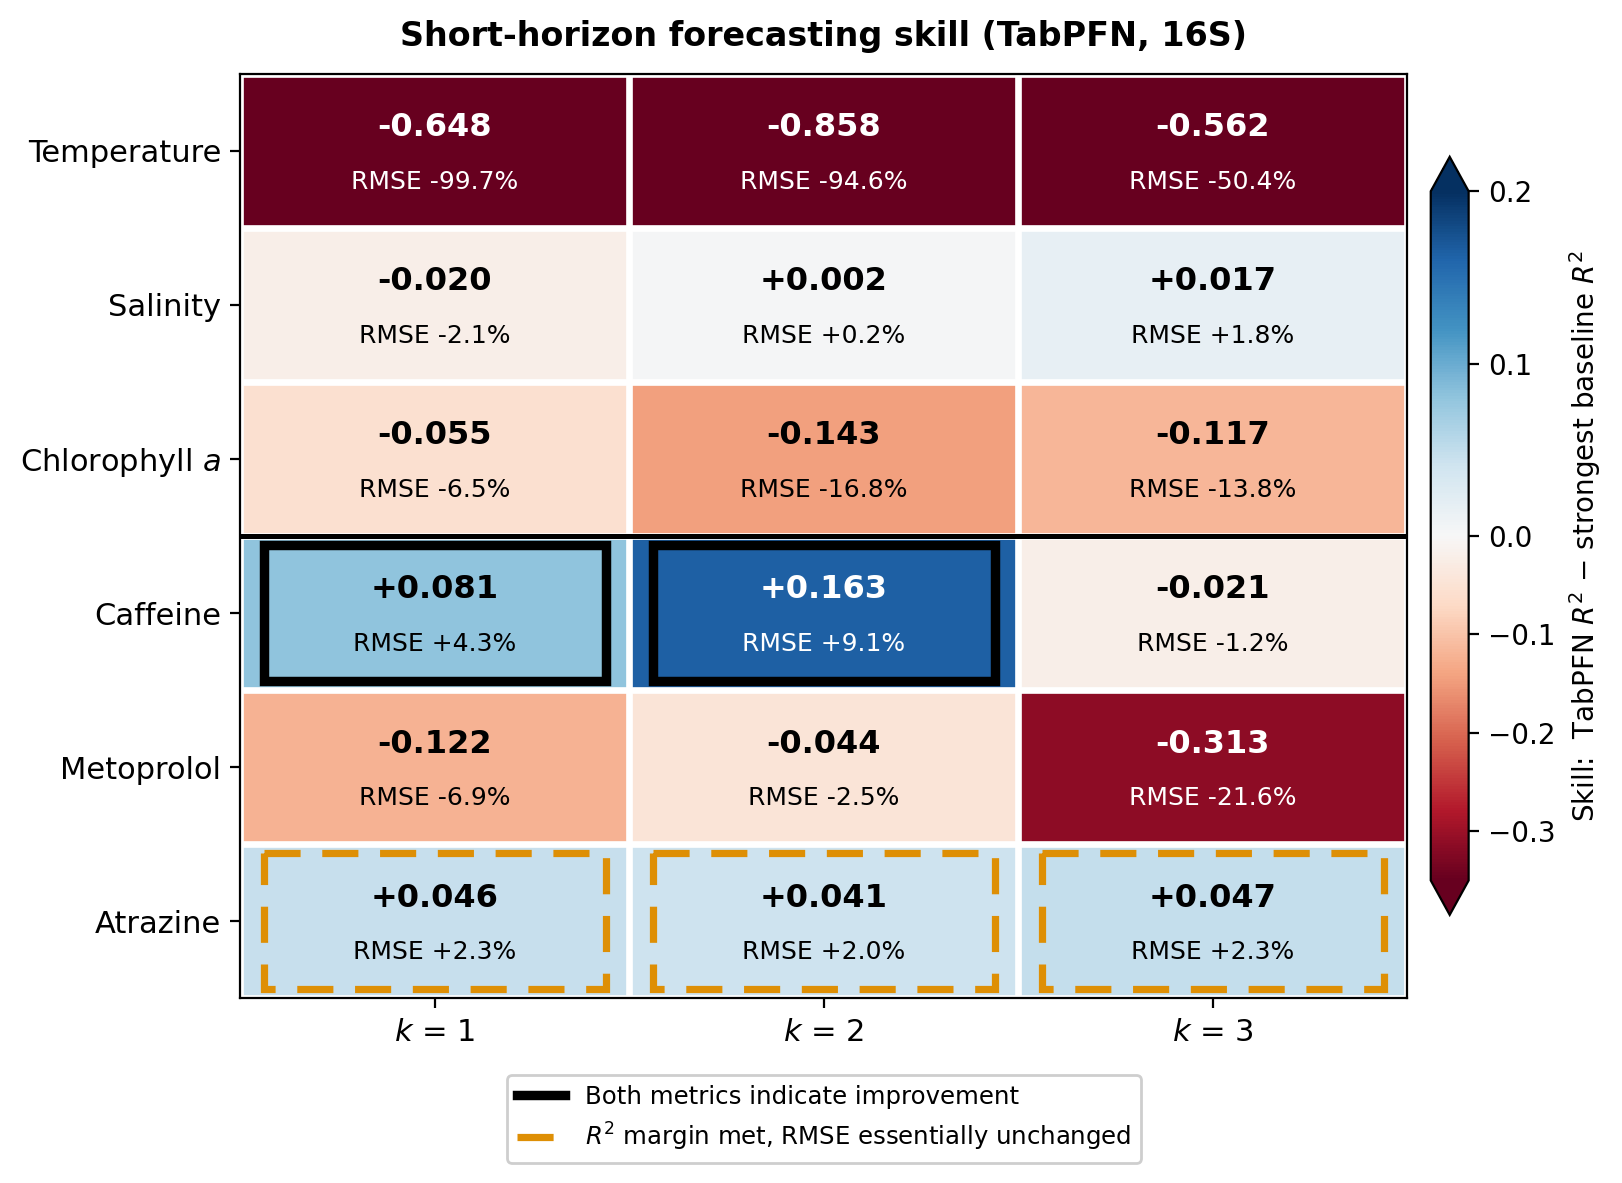

In [6]:
# ============================================================
# Figure 8.1 — forecasting skill, TabPFN 16S.
# Colour: RdBu (colourblind-safe diverging, no red-green pairing).
# Cell outlines: Okabe-Ito blue / orange, never green on blue.
# ============================================================
import matplotlib.pyplot as plt
import numpy as np, pandas as pd
from pathlib import Path
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from IPython.display import Image, display

R = Path('/mnt/data/home/tv2414/tabpfn_project/results')
t = pd.read_csv(R / 'table_8_2_with_rmse.csv')

T_ORDER = ['Temperature', 'Salinity', 'Chlorophyll a',
           'Caffeine', 'Metoprolol', 'Atrazine']
LBL = {'Chlorophyll a': 'Chlorophyll $a$'}
H = [1, 2, 3]

skill = np.array([[t[(t.Target == g) & (t.k == k)]['Skill (R2)'].iloc[0]
                   for k in H] for g in T_ORDER])
rmse  = np.array([[t[(t.Target == g) & (t.k == k)]['RMSE red. %'].iloc[0]
                   for k in H] for g in T_ORDER])

VMIN, VMAX = -0.35, 0.20
norm = TwoSlopeNorm(vcenter=0.0, vmin=VMIN, vmax=VMAX)

OK_BLUE, OK_ORANGE = '#000000', '#DE8F05'

fig, ax = plt.subplots(figsize=(8.0, 5.8), constrained_layout=True)
im = ax.imshow(np.clip(skill, VMIN, VMAX), cmap='RdBu', norm=norm, aspect='auto')

for i, g in enumerate(T_ORDER):
    for j, k in enumerate(H):
        s, rr = skill[i, j], rmse[i, j]
        lum = (np.clip(s, VMIN, VMAX) - VMIN) / (VMAX - VMIN)
        col = 'white' if (lum < 0.22 or lum > 0.86) else 'black'
        ax.text(j, i - 0.15, f'{s:+.3f}', ha='center', va='center',
                fontsize=11.5, fontweight='bold', color=col)
        ax.text(j, i + 0.20, f'RMSE {rr:+.1f}%', ha='center', va='center',
                fontsize=9, color=col)
        # inset the rectangles so adjacent cells stay visually separate
        if s > 0.03 and rr > 3.0:
            ax.add_patch(Rectangle((j - 0.44, i - 0.44), 0.88, 0.88,
                                   fill=False, edgecolor=OK_BLUE,
                                   linewidth=3.4, zorder=5))
        elif s > 0.03:
            ax.add_patch(Rectangle((j - 0.44, i - 0.44), 0.88, 0.88,
                                   fill=False, edgecolor=OK_ORANGE,
                                   linewidth=2.6, linestyle=(0, (5, 3)),
                                   zorder=5))

ax.set_xticks(range(3)); ax.set_xticklabels([f'$k$ = {k}' for k in H], fontsize=11)
ax.set_yticks(range(6))
ax.set_yticklabels([LBL.get(g, g) for g in T_ORDER], fontsize=11)
ax.set_xticks(np.arange(-0.5, 3, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 6, 1), minor=True)
ax.grid(which='minor', color='white', linewidth=2.4)
ax.tick_params(which='minor', length=0)
ax.axhline(2.5, color='black', lw=1.8, zorder=6)   # environmental | chemical

cb = fig.colorbar(im, ax=ax, shrink=0.82, pad=0.02, extend='both',
                  ticks=[-0.3, -0.2, -0.1, 0, 0.1, 0.2])
cb.set_label('Skill:  TabPFN $R^2$ $-$ strongest baseline $R^2$', fontsize=10)

ax.set_title('Short-horizon forecasting skill (TabPFN, 16S)',
             fontsize=12, fontweight='bold', pad=10)

ax.legend(handles=[
    Line2D([], [], color=OK_BLUE, lw=3.4,
           label='Both metrics indicate improvement'),
    Line2D([], [], color=OK_ORANGE, lw=2.6, ls=(0, (5, 3)),
           label='$R^2$ margin met, RMSE essentially unchanged')],
    fontsize=8.8, loc='upper center', bbox_to_anchor=(0.5, -0.07),
    framealpha=0.96)

for ext in ('png', 'pdf'):
    fig.savefig(R / f'fig_8_1_forecasting_skill.{ext}', dpi=200,
                bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(R / 'fig_8_1_forecasting_skill.png')))

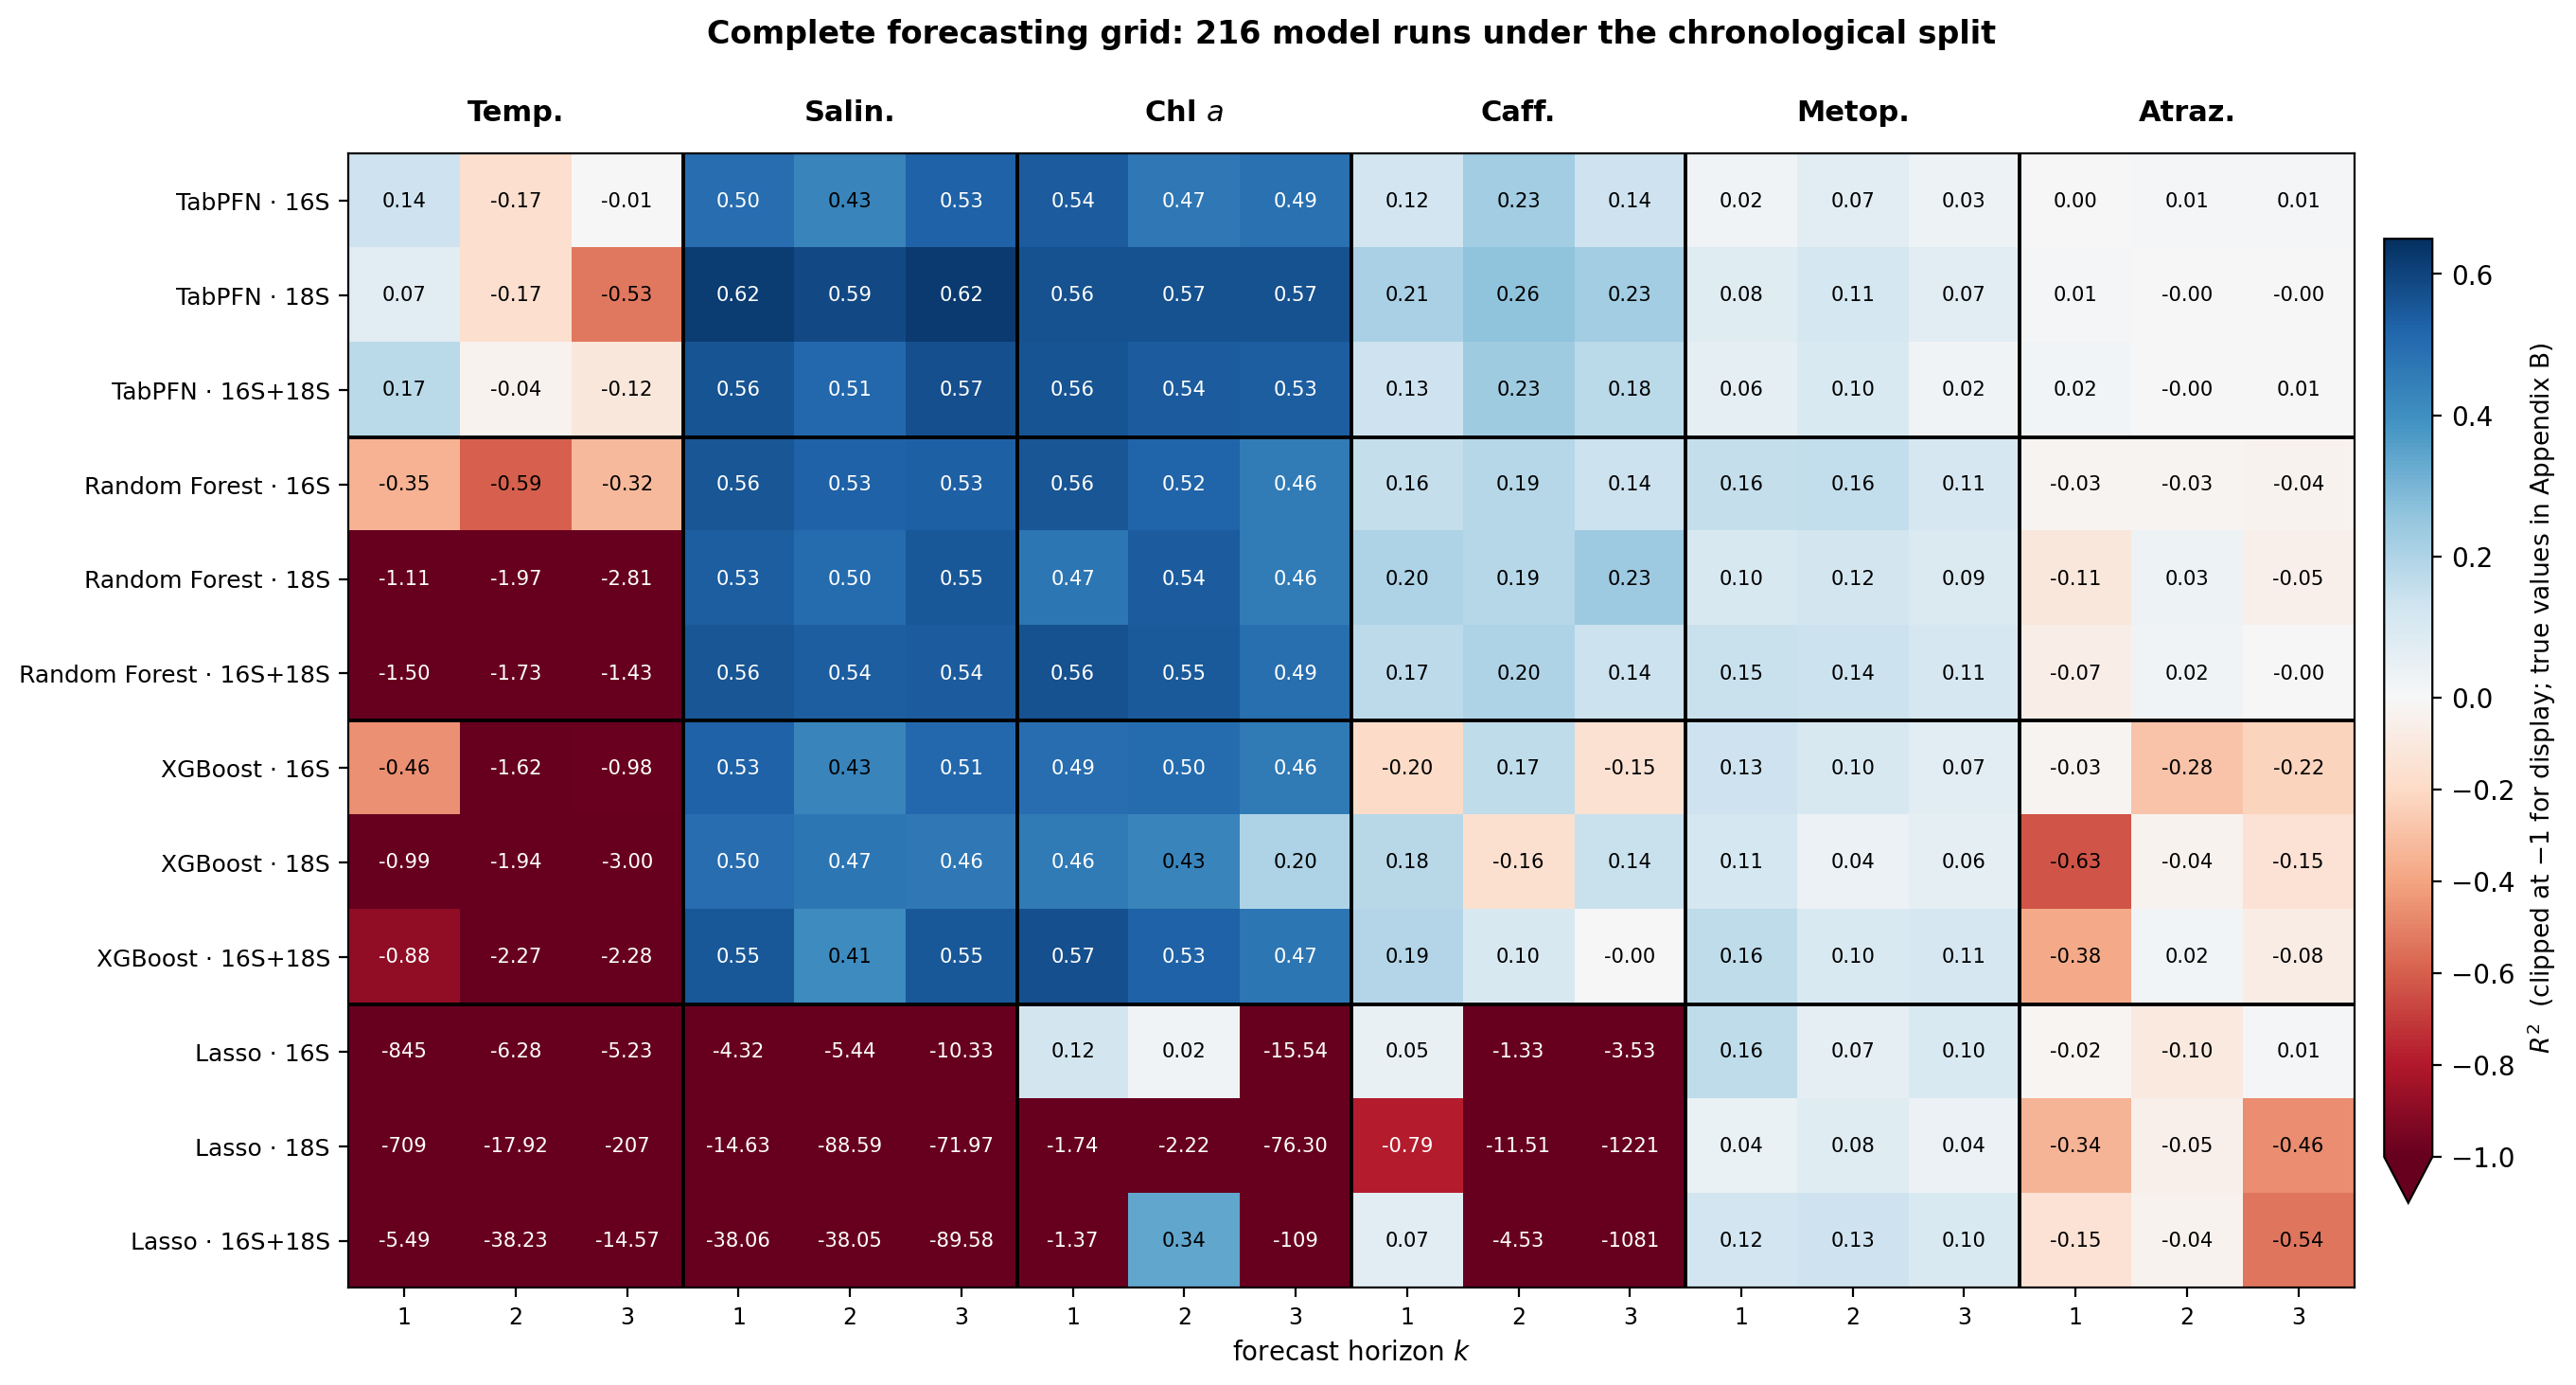

values below -1 (clipped for colour, true value shown):
       Target  k   Input         Model        R2
     Caffeine  3     18S         Lasso -1221.085
     Caffeine  3 16S+18S         Lasso -1080.590
  Temperature  1     16S         Lasso  -845.109
  Temperature  1     18S         Lasso  -708.976
  Temperature  3     18S         Lasso  -207.006
Chlorophyll a  3 16S+18S         Lasso  -108.788
     Salinity  3 16S+18S         Lasso   -89.583
     Salinity  2     18S         Lasso   -88.593
Chlorophyll a  3     18S         Lasso   -76.297
     Salinity  3     18S         Lasso   -71.975
  Temperature  2 16S+18S         Lasso   -38.226
     Salinity  1 16S+18S         Lasso   -38.056
     Salinity  2 16S+18S         Lasso   -38.052
  Temperature  2     18S         Lasso   -17.923
Chlorophyll a  3     16S         Lasso   -15.544
     Salinity  1     18S         Lasso   -14.630
  Temperature  3 16S+18S         Lasso   -14.569
     Caffeine  2     18S         Lasso   -11.508
     Salinity

In [7]:
# ============================================================
# Figure 8.2 — complete forecasting grid, in the style of Figure 6.1.
# Rows: model x input.  Columns: target x horizon.  Colour = R2.
# ============================================================
import matplotlib.pyplot as plt
import numpy as np, pandas as pd
from pathlib import Path
from matplotlib.colors import TwoSlopeNorm
from IPython.display import Image, display

R = Path('/mnt/data/home/tv2414/tabpfn_project/results')
d = pd.read_csv(R / 'appendix_B_forecasting_216.csv')

M_ORDER = ['TabPFN', 'Random Forest', 'XGBoost', 'Lasso']
I_ORDER = ['16S', '18S', '16S+18S']
T_ORDER = ['Temperature', 'Salinity', 'Chlorophyll a',
           'Caffeine', 'Metoprolol', 'Atrazine']
T_SHORT = {'Temperature': 'Temp.', 'Salinity': 'Salin.',
           'Chlorophyll a': 'Chl $a$', 'Caffeine': 'Caff.',
           'Metoprolol': 'Metop.', 'Atrazine': 'Atraz.'}
H = [1, 2, 3]

rk = [(m, i) for m in M_ORDER for i in I_ORDER]
ck = [(t, k) for t in T_ORDER for k in H]
lut = {(r.Model, r.Input, r.Target, r.k): r.R2 for r in d.itertuples()}
mat = np.array([[lut.get((m, i, t, k), np.nan) for (t, k) in ck] for (m, i) in rk])

VMIN, VMAX = -1.0, 0.65
norm = TwoSlopeNorm(vcenter=0.0, vmin=VMIN, vmax=VMAX)
cmap = plt.get_cmap('RdBu').copy(); cmap.set_bad('#FFFFFF')

fig, ax = plt.subplots(figsize=(13.5, 7.2), constrained_layout=True)
im = ax.imshow(np.ma.masked_invalid(np.clip(mat, VMIN, VMAX)),
               cmap=cmap, norm=norm, aspect='auto')

for a in range(mat.shape[0]):
    for b in range(mat.shape[1]):
        v = mat[a, b]
        if not np.isfinite(v):
            continue
        lum = (np.clip(v, VMIN, VMAX) - VMIN) / (VMAX - VMIN)
        col = 'white' if (lum < 0.20 or lum > 0.88) else 'black'
        txt = f'{v:.2f}' if abs(v) < 100 else f'{v:.0f}'
        ax.text(b, a, txt, ha='center', va='center', fontsize=7.6, color=col)

ax.set_yticks(range(len(rk)))
ax.set_yticklabels([f'{m} · {i}' for (m, i) in rk], fontsize=9)
ax.set_xticks(range(len(ck)))
ax.set_xticklabels([f'{k}' for (_, k) in ck], fontsize=8.5)
ax.set_xlabel('forecast horizon $k$', fontsize=10)

for x in range(3, len(ck), 3):
    ax.axvline(x - 0.5, color='black', lw=1.4)
for y in range(3, len(rk), 3):
    ax.axhline(y - 0.5, color='black', lw=1.4)
for n, t in enumerate(T_ORDER):
    ax.text(3 * n + 1, -0.85, T_SHORT[t], ha='center', fontsize=11,
            fontweight='bold')
    
cb = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.015, extend='min')
cb.set_label('$R^2$  (clipped at $-1$ for display; true values in Appendix B)',
             fontsize=9.5)

ax.set_title('Complete forecasting grid: 216 model runs under the '
             'chronological split', fontsize=12, fontweight='bold', pad=42)

for ext in ('png', 'pdf'):
    fig.savefig(R / f'fig_8_2_forecasting_grid.{ext}', dpi=200,
                bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(R / 'fig_8_2_forecasting_grid.png')))
print('values below -1 (clipped for colour, true value shown):')
print(d[d.R2 < -1][['Target', 'k', 'Input', 'Model', 'R2']]
      .sort_values('R2').to_string(index=False))

In [8]:
import pandas as pd
from pathlib import Path
d = pd.read_csv(Path('/mnt/data/home/tv2414/tabpfn_project/results')
                / 'appendix_B_forecasting_216.csv')
print(d[d.R2 < -1].Model.value_counts().to_string())
print('\nTabPFN min R2:', d[d.Model == 'TabPFN'].R2.min())

Model
Lasso            30
Random Forest     6
XGBoost           5

TabPFN min R2: -0.526


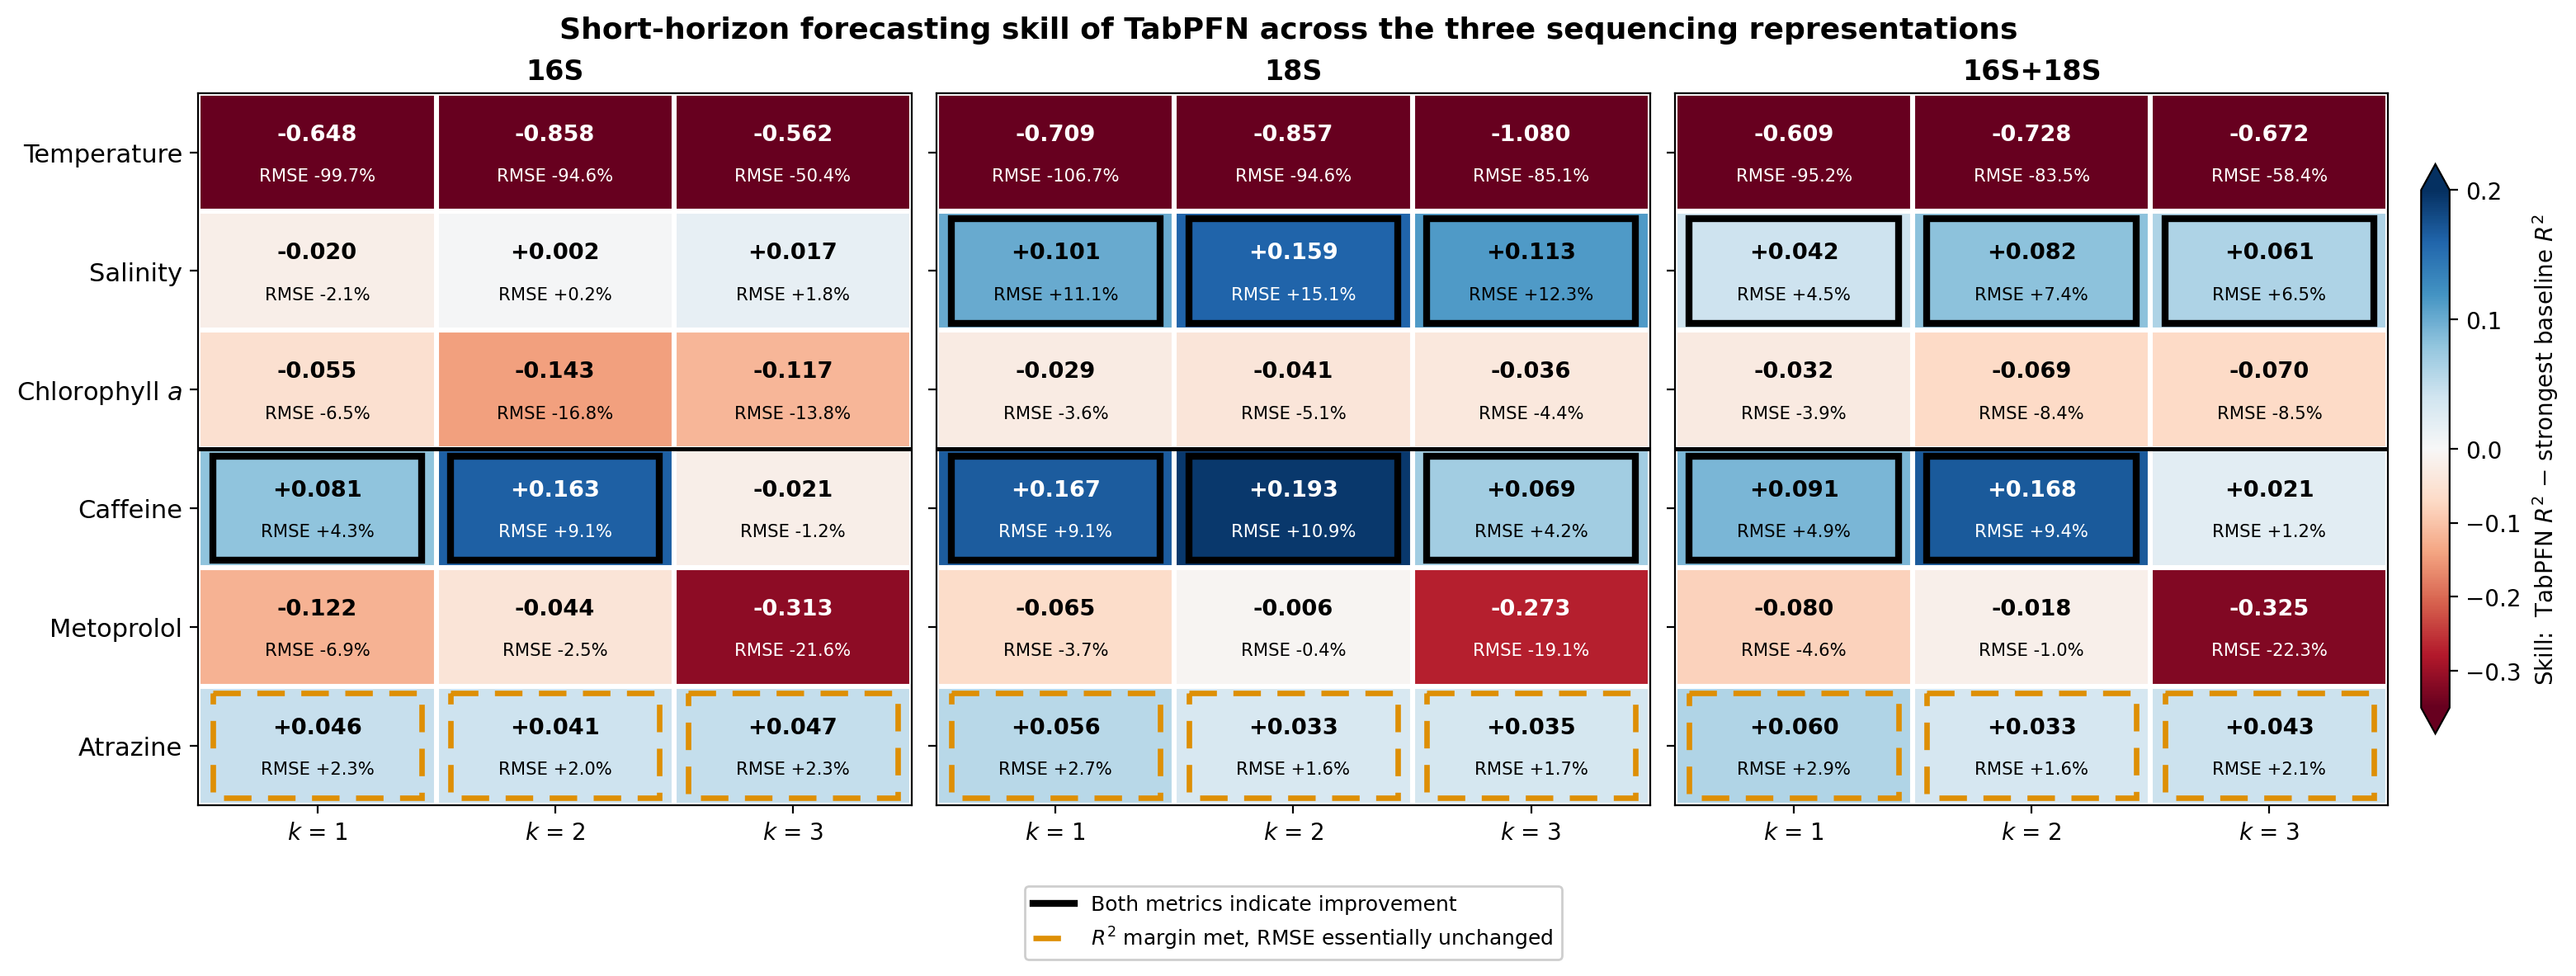

cells where both metrics indicate improvement:
  16S       2
  18S       6
  16S+18S   5


In [9]:
# ============================================================
# Figure 8.1 — forecasting skill for all three sequencing inputs.
# Skill = TabPFN R2 - strongest model-free baseline R2.
# The baseline is a property of the target and horizon, so it is
# identical across the three panels; only the model changes.
# ============================================================
import matplotlib.pyplot as plt
import numpy as np, pandas as pd
from pathlib import Path
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from IPython.display import Image, display

R = Path('/mnt/data/home/tv2414/tabpfn_project/results')

base = pd.read_csv(R / 'forecasting_baseline_metrics.csv')
chem = pd.read_csv(R / 'phase3_forecasting_shared_mask_splitB_unifiedcut.csv')
env  = pd.read_csv(R / 'phase1_forecasting_shared_mask_splitB.csv')
mod  = pd.concat([chem, env], ignore_index=True)

NAME = {'temperature': 'Temperature', 'salinity': 'Salinity',
        'Chl_a': 'Chlorophyll a', 'Chl_a_log1p': 'Chlorophyll a',
        'Caffeine': 'Caffeine', 'Metoprolol': 'Metoprolol',
        'Atrazine': 'Atrazine'}
base['tgt'] = base['target'].map(NAME)
mod['tgt']  = mod['target'].map(NAME)

best = base.loc[base.groupby(['tgt', 'horizon_k'])['r2'].idxmax()] \
           .set_index(['tgt', 'horizon_k'])

T_ORDER = ['Temperature', 'Salinity', 'Chlorophyll a',
           'Caffeine', 'Metoprolol', 'Atrazine']
LBL = {'Chlorophyll a': 'Chlorophyll $a$'}
I_ORDER = ['16S', '18S', '16S+18S']
H = [1, 2, 3]

def grids(inp):
    t = mod[(mod.model == 'tabpfn') & (mod.input == inp)]
    sk = np.full((6, 3), np.nan); rm = np.full((6, 3), np.nan)
    for i, g in enumerate(T_ORDER):
        for j, k in enumerate(H):
            r = t[(t.tgt == g) & (t.horizon_k == k)]
            if not len(r):
                continue
            b = best.loc[(g, k)]
            sk[i, j] = r.r2.iloc[0] - b['r2']
            rm[i, j] = 100 * (1 - r.rmse.iloc[0] / b['rmse'])
    return sk, rm

VMIN, VMAX = -0.35, 0.20
norm = TwoSlopeNorm(vcenter=0.0, vmin=VMIN, vmax=VMAX)

fig, axes = plt.subplots(1, 3, figsize=(15.5, 5.8), sharey=True,
                         constrained_layout=True)
counts = {}
for ax, inp in zip(axes, I_ORDER):
    sk, rm = grids(inp)
    counts[inp] = int(((sk > 0.03) & (rm > 3.0)).sum())
    im = ax.imshow(np.clip(sk, VMIN, VMAX), cmap='RdBu', norm=norm,
                   aspect='auto')
    for i in range(6):
        for j in range(3):
            s, rr = sk[i, j], rm[i, j]
            lum = (np.clip(s, VMIN, VMAX) - VMIN) / (VMAX - VMIN)
            col = 'white' if (lum < 0.22 or lum > 0.86) else 'black'
            ax.text(j, i - 0.15, f'{s:+.3f}', ha='center', va='center',
                    fontsize=9.8, fontweight='bold', color=col)
            ax.text(j, i + 0.20, f'RMSE {rr:+.1f}%', ha='center', va='center',
                    fontsize=7.6, color=col)
            if s > 0.03 and rr > 3.0:
                ax.add_patch(Rectangle((j - 0.44, i - 0.44), 0.88, 0.88,
                                       fill=False, edgecolor='black',
                                       linewidth=3.0, zorder=5))
            elif s > 0.03:
                ax.add_patch(Rectangle((j - 0.44, i - 0.44), 0.88, 0.88,
                                       fill=False, edgecolor='#DE8F05',
                                       linewidth=2.4, linestyle=(0, (5, 3)),
                                       zorder=5))
    ax.set_xticks(range(3)); ax.set_xticklabels([f'$k$ = {k}' for k in H],
                                                fontsize=10)
    ax.set_xticks(np.arange(-0.5, 3, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 6, 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=2.2)
    ax.tick_params(which='minor', length=0)
    ax.axhline(2.5, color='black', lw=1.8, zorder=6)
    ax.set_title(inp, fontsize=12, fontweight='bold')

axes[0].set_yticks(range(6))
axes[0].set_yticklabels([LBL.get(g, g) for g in T_ORDER], fontsize=11)

cb = fig.colorbar(im, ax=axes, shrink=0.80, pad=0.015, extend='both',
                  ticks=[-0.3, -0.2, -0.1, 0, 0.1, 0.2])
cb.set_label('Skill:  TabPFN $R^2$ $-$ strongest baseline $R^2$', fontsize=10)

fig.suptitle('Short-horizon forecasting skill of TabPFN across the three '
             'sequencing representations', fontsize=13, fontweight='bold')

axes[1].legend(handles=[
    Line2D([], [], color='black', lw=3.0,
           label='Both metrics indicate improvement'),
    Line2D([], [], color='#DE8F05', lw=2.4, ls=(0, (5, 3)),
           label='$R^2$ margin met, RMSE essentially unchanged')],
    fontsize=9, loc='upper center', bbox_to_anchor=(0.5, -0.10),
    framealpha=0.96)

for ext in ('png', 'pdf'):
    fig.savefig(R / f'fig_8_1_forecasting_skill_3panels.{ext}', dpi=200,
                bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(R / 'fig_8_1_forecasting_skill_3panels.png')))

print('cells where both metrics indicate improvement:')
for inp, n in counts.items():
    print(f'  {inp:<9s} {n}')

In [10]:
# ============================================================
# Sanity check on the 18S forecasting advantage. READ ONLY.
# ============================================================
import numpy as np, pandas as pd
from pathlib import Path

R = Path('/mnt/data/home/tv2414/tabpfn_project/results')
env  = pd.read_csv(R / 'phase1_forecasting_shared_mask_splitB.csv')
chem = pd.read_csv(R / 'phase3_forecasting_shared_mask_splitB_unifiedcut.csv')
fc = pd.concat([env, chem], ignore_index=True)

# 1. are n_train / n_test identical across inputs within a cell?
print('=== n_train / n_test by input (must be identical within a cell) ===')
g = fc.groupby(['target', 'horizon_k'])[['n_train', 'n_test']].nunique()
bad = g[(g.n_train > 1) | (g.n_test > 1)]
print('cells where sample size differs across inputs:', len(bad))
if len(bad):
    print(bad.to_string())
else:
    print('  none — the shared mask held across all inputs')

# 2. the 18S advantage, per model: is it TabPFN-specific or general?
print('\n=== R2 by input, salinity, all four models ===')
s = fc[fc.target == 'salinity'].pivot_table(
        index=['model', 'horizon_k'], columns='input', values='r2')
print(s.round(3).to_string())

print('\n=== same for caffeine ===')
c = fc[fc.target == 'Caffeine'].pivot_table(
        index=['model', 'horizon_k'], columns='input', values='r2')
print(c.round(3).to_string())

# 3. mean advantage of 18S over 16S, per target, TabPFN only
print('\n=== TabPFN: mean R2 by input and target ===')
t = fc[fc.model == 'tabpfn'].pivot_table(
        index='target', columns='input', values='r2')
t['18S - 16S'] = t['18S'] - t['16S']
print(t.round(3).to_string())

# 4. does the same pattern exist in the contemporaneous Ch6 grid?
p = R / 'ch6_full72_long.csv'
if p.exists():
    ch6 = pd.read_csv(p)
    print('\n=== Chapter 6 contemporaneous: TabPFN R2 by input ===')
    c6 = ch6[ch6.model == 'TabPFN'].pivot_table(
            index=['target', 'strategy'], columns='input', values='r2_mean')
    c6['18S - 16S'] = c6['18S'] - c6['16S']
    print(c6.loc[['salinity', 'Caffeine']].round(3).to_string()
          if 'salinity' in c6.index.get_level_values(0)
          else c6.round(3).to_string())

=== n_train / n_test by input (must be identical within a cell) ===
cells where sample size differs across inputs: 0
  none — the shared mask held across all inputs

=== R2 by input, salinity, all four models ===
input                       16S  16S+18S     18S
model         horizon_k                         
lasso         1          -4.320  -38.056 -14.630
              2          -5.436  -38.052 -88.593
              3         -10.334  -89.583 -71.975
random_forest 1           0.555    0.557   0.534
              2           0.526    0.538   0.500
              3           0.530    0.540   0.552
tabpfn        1           0.496    0.559   0.618
              2           0.431    0.511   0.589
              3           0.527    0.571   0.623
xgboost       1           0.525    0.550   0.496
              2           0.430    0.411   0.471
              3           0.510    0.549   0.464

=== same for caffeine ===
input                      16S   16S+18S       18S
model         horizon_k

In [1]:
# ── STEP 1: how do the evaluators align X and y? ─────────────────────────
import subprocess

def show(cmd):
    r = subprocess.run(cmd, shell=True, capture_output=True,
                       text=True, executable="/bin/bash")
    print(r.stdout or "(no match)")

print("=== alignment / intersection logic in evaluators ===")
show("grep -n 'intersection\\|reindex\\|\\.loc\\[\\|align\\|common\\|dropna' "
     "../src/tabpfn_evaluator.py | head -30")

print("\n=== how the notebook builds the input dict ===")
show("grep -rn 'INPUTS\\|otu_16s\\|otu_18s\\|concat\\|add_prefix' "
     "../notebooks/*.ipynb | grep -v 'output' | head -25")

=== alignment / intersection logic in evaluators ===
98:        OTU/ASV table aligned to `meta` (same row order, same length).


=== how the notebook builds the input dict ===
../notebooks/01_data_exploration copy.ipynb:33:    "otu_16s = pd.read_csv(DATA_DIR + \"otus_16s_filtered.csv\", index_col=0)\n",
../notebooks/01_data_exploration copy.ipynb:34:    "otu_18s = pd.read_csv(DATA_DIR + \"otus_18s_filtered.csv\", index_col=0)\n",
../notebooks/01_data_exploration copy.ipynb:37:    "print(\"16S OTU shape: \", otu_16s.shape)\n",
../notebooks/01_data_exploration copy.ipynb:38:    "print(\"18S OTU shape: \", otu_18s.shape)"
../notebooks/01_data_exploration copy.ipynb:411:    "# (otu_16s == 0).mean().mean() — درصد مقادیر صفر در کل ماتریس (sparsity)\n",
../notebooks/01_data_exploration copy.ipynb:412:    "# otu_16s.sum(axis=1) — مجموع reads برای هر سمپل (یعنی sequencing depth)\n",
../notebooks/01_data_exploration copy.ipynb:416:    "print(f\"  Sparsity: {(otu_16s == 0).mean().mean() * 100:.1f

In [2]:
# ── STEP 2: what sample counts do the RESULT files actually record? ──────
import pandas as pd
from pathlib import Path

RES = Path("../results")

for fname in ["ch6_full72_long.csv",
              "phase1_final_comparison_table_v3.csv"]:
    f = RES / fname
    if not f.exists():
        print(f"!! missing: {fname}\n"); continue
    df = pd.read_csv(f)
    print(f"=== {fname}  shape={df.shape} ===")
    print("columns:", list(df.columns))

    # any column recording sample sizes?
    ncols = [c for c in df.columns
             if any(k in c.lower() for k in
                    ['n_', '_n', 'samples', 'size', 'count'])]
    print("candidate n-columns:", ncols)

    if ncols:
        key = [c for c in df.columns
               if any(k in c.lower() for k in ['input', 'config', 'marker'])]
        tgt = [c for c in df.columns if 'target' in c.lower()]
        if key and tgt:
            sub = df[df[tgt[0]].astype(str).str.contains('temp', case=False)]
            print("\n--- temperature rows, by input ---")
            print(sub[key + tgt + ncols].drop_duplicates().to_string(index=False))
    print()

=== ch6_full72_long.csv  shape=(288, 7) ===
columns: ['target', 'input', 'strategy', 'r2_mean', 'mae_mean', 'rmse_mean', 'model']
candidate n-columns: []

=== phase1_final_comparison_table_v3.csv  shape=(36, 8) ===
columns: ['Target', 'Input', 'Strategy', 'Lasso', 'RF', 'XGBoost', 'TabPFN', 'Best']
candidate n-columns: []



In [3]:
# ── DEFINITIVE: reproduce the master exactly as notebook 01 builds it ────
import pandas as pd, numpy as np

DATA_DIR = "../data/"
meta    = pd.read_csv(DATA_DIR + "combined_meta_data.csv", index_col=0)
otu_16s = pd.read_csv(DATA_DIR + "otus_16s_filtered.csv",  index_col=0)
otu_18s = pd.read_csv(DATA_DIR + "otus_18s_filtered.csv",  index_col=0)

master_ids = sorted(set(meta.index) & set(otu_16s.index) & set(otu_18s.index))
print(f"master_ids (three-way, incl. Heiligendamm): {len(master_ids)}")

meta_m = meta.loc[master_ids]
keep   = meta_m.index[meta_m['location_name'] != 'Heiligendamm']
print(f"after Heiligendamm removal:                 {len(keep)}")

o16 = otu_16s.loc[keep]
o18 = otu_18s.loc[keep]
ocomb = pd.concat([o16.add_prefix('16S_'), o18.add_prefix('18S_')], axis=1)

print("\n=== recomputed on the ACTUAL master ===")
for name, X in [('16S', o16), ('18S', o18), ('16S+18S', ocomb)]:
    print(f"{name:10s} n={X.shape[0]:5d}  p={X.shape[1]:5d}  "
          f"zeros={(X==0).to_numpy().mean()*100:5.1f}%")

m = meta.loc[keep].copy()
m['Chl_a_log1p'] = np.log1p(m['Chl_a'].clip(lower=0))
print("\n=== target n (identical for all three inputs) ===")
for t in ['temperature', 'salinity', 'Chl_a_log1p']:
    print(f"  {t:14s} {int(m[t].notna().sum())}")

master_ids (three-way, incl. Heiligendamm): 1589
after Heiligendamm removal:                 1538

=== recomputed on the ACTUAL master ===
16S        n= 1538  p= 1236  zeros= 56.5%
18S        n= 1538  p= 1054  zeros= 74.1%
16S+18S    n= 1538  p= 2290  zeros= 64.6%

=== target n (identical for all three inputs) ===
  temperature    1223
  salinity       1217
  Chl_a_log1p    1437


In [4]:
# ── DEFINITIVE: reproduce the master exactly as notebook 01 builds it ────
import pandas as pd, numpy as np

DATA_DIR = "../data/"
meta    = pd.read_csv(DATA_DIR + "combined_meta_data.csv", index_col=0)
otu_16s = pd.read_csv(DATA_DIR + "otus_16s_filtered.csv",  index_col=0)
otu_18s = pd.read_csv(DATA_DIR + "otus_18s_filtered.csv",  index_col=0)

master_ids = sorted(set(meta.index) & set(otu_16s.index) & set(otu_18s.index))
print(f"master_ids (three-way, incl. Heiligendamm): {len(master_ids)}")

meta_m = meta.loc[master_ids]
keep   = meta_m.index[meta_m['location_name'] != 'Heiligendamm']
print(f"after Heiligendamm removal:                 {len(keep)}")

o16 = otu_16s.loc[keep]
o18 = otu_18s.loc[keep]
ocomb = pd.concat([o16.add_prefix('16S_'), o18.add_prefix('18S_')], axis=1)

print("\n=== recomputed on the ACTUAL master ===")
for name, X in [('16S', o16), ('18S', o18), ('16S+18S', ocomb)]:
    print(f"{name:10s} n={X.shape[0]:5d}  p={X.shape[1]:5d}  "
          f"zeros={(X==0).to_numpy().mean()*100:5.1f}%")

m = meta.loc[keep].copy()
m['Chl_a_log1p'] = np.log1p(m['Chl_a'].clip(lower=0))
print("\n=== target n (identical for all three inputs) ===")
for t in ['temperature', 'salinity', 'Chl_a_log1p']:
    print(f"  {t:14s} {int(m[t].notna().sum())}")

master_ids (three-way, incl. Heiligendamm): 1589
after Heiligendamm removal:                 1538

=== recomputed on the ACTUAL master ===
16S        n= 1538  p= 1236  zeros= 56.5%
18S        n= 1538  p= 1054  zeros= 74.1%
16S+18S    n= 1538  p= 2290  zeros= 64.6%

=== target n (identical for all three inputs) ===
  temperature    1223
  salinity       1217
  Chl_a_log1p    1437


In [5]:
# trace-substance targets on the true master
hplc = pd.read_csv(DATA_DIR + "hplc_submission.csv", index_col=0)
def zs(s):
    def c(v):
        if pd.isna(v): return np.nan
        v = str(v).strip()
        if v.startswith('<') or v.startswith('#'): return 0.0
        try: return float(v)
        except ValueError: return np.nan
    return s.map(c)
G = ['Caffeine','Metoprolol','Atrazine']
hz = hplc[G].apply(zs)
ids = keep.intersection(hz.index)
print("=== trace-substance targets on the master ===")
for c in G:
    s = hz.loc[ids, c]; n = int(s.notna().sum()); nz = int((s.dropna()>0).sum())
    print(f"  {c:12s} n={n}  n>0={nz}  {100*nz/n:.1f}%")

# Muehlendamm figures — MUST be recomputed on the master, not on raw meta
mu = m[m['location_name']=='Muehlendamm']['salinity'].dropna()
oth = (m[m['location_name']!='Muehlendamm']
         .groupby('location_name')['salinity'].mean())
print(f"\nMuehlendamm: {mu.mean():.2f} ± {mu.std():.2f} PSU, n={len(mu)}")
print(f"13 sites: {oth.min():.2f} – {oth.max():.2f} PSU")

=== trace-substance targets on the master ===
  Caffeine     n=1291  n>0=1291  100.0%
  Metoprolol   n=1293  n>0=387  29.9%
  Atrazine     n=1289  n>0=57  4.4%

Muehlendamm: 0.45 ± 0.27 PSU, n=90
13 sites: 9.05 – 14.85 PSU


In [6]:
print(m['location_name'].value_counts().sort_values().to_string())

location_name
Muehlendamm                109
Warnemuende Strand         109
Schmarl-Dorf / IGA-Park    109
SAB Marina Bramow          109
Elmenhorst Strand          109
Jemnitzschleuse            109
Parkplatz zur Warnow       110
Diedrichshagen             110
Boergerende Strand         110
Steilkueste Nienhagen      110
Neptun-Werft               111
Mittelmole Warnemuende     111
Stadthafen Rostock         111
Schwimmhalle Gehlsdorf     111


In [7]:
import subprocess
r = subprocess.run("grep -rn '8\\.98\\|8,98' ../ --include='*.tex' --include='*.md' --include='*.ipynb' 2>/dev/null | head -20",
                   shell=True, capture_output=True, text=True, executable="/bin/bash")
print(r.stdout or "no match in project files")

../notebooks/01_data_exploration.ipynb:879:      "کم‌ترین:   8.982148384752591\n",
../notebooks/02_preprocessing.ipynb:486:      "     Stadthafen Rostock 54.095242 12.119616  8.982148 112\n",
../notebooks/02_preprocessing.ipynb:1053:      "Stadthafen Rostock          90   8.98  5.56   0.80  19.82\n",
../notebooks/02_preprocessing.ipynb:1569:      "8.98 – 14.85 PSU\n"
../notebooks/02_preprocessing.ipynb:1679:    "ax.axvspan(0.45, 8.98, color='0.92', zorder=0)\n",
../notebooks/02_preprocessing.ipynb:1680:    "ax.text((0.45+8.98)/2, len(stats)-1.3, 'unsampled\\nsalinity range',\n",
../notebooks/02_preprocessing.ipynb:2232:    "ax.axvspan(0.45, 8.98, color='0.94', zorder=0)\n",
../notebooks/02_preprocessing.ipynb:2240:    "ax.text((0.45 + 8.98) / 2, len(stats) - 0.4, 'unsampled\\nsalinity range',\n",
../notebooks/02_preprocessing.ipynb:2450:    "ax.axvspan(0.45, 8.98, color='0.94', zorder=0)\n",
../notebooks/02_preprocessing.ipynb:2459:    "ax.text((0.45 + 8.98) / 2, len(stats) - 0.3, 'uns

In [9]:
from tabpfn import TabPFNRegressor
import inspect, re
src = inspect.getsource(TabPFNRegressor)
for m in re.finditer(r'.{80}(max_num_features|feature.{0,10}limit|500|2000).{80}', src):
    print(m.group(0).replace('\n',' '), '\n')